In [ ]:
%config IPCompleter.use_jedi = False
%pdb off
%load_ext autoreload
%autoreload 3

# required to enable non-blocking interaction:
%gui qt5

import sys
from copy import deepcopy
from typing import Dict, List, Tuple, Optional, Callable, Union, Any
from typing_extensions import TypeAlias
from neuropy.utils.result_context import IdentifyingContext
import nptyping as ND
from nptyping import NDArray
import neuropy.utils.type_aliases as types
from collections import defaultdict
from functools import partial

import numpy as np
import pandas as pd
import re
from pathlib import Path
from datetime import datetime

from neuropy.utils.indexing_helpers import PandasHelpers, NeuroPyDataframeAccessor, UniqueValuesReturnType
from neuropy.utils.result_context import IdentifyingContext

from neuropy.core.user_annotations import UserAnnotationsManager
from pyphocorehelpers.indexing_helpers import partition_df
# Set the maximum number of columns to display
pd.set_option('display.max_columns', 100)

import IPython
from pyphocorehelpers.programming_helpers import IPythonHelpers
from pyphocorehelpers.notebook_helpers import NotebookCellExecutionLogger
from pyphocorehelpers.assertion_helpers import Assert
from pyphocorehelpers.print_helpers import print_keys_if_possible, print_value_overview_only, TypePrintMode

# Jupyter-lab enable printing for any line on its own (instead of just the last one in the cell)
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

_notebook_path:Path = Path(IPythonHelpers.try_find_notebook_filepath(IPython.extract_module_locals())).resolve() # Finds the path of THIS notebook

# Plotting
# import pylustrator # customization of figures
import matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt
_bak_rcParams = mpl.rcParams.copy()

matplotlib.use('Qt5Agg')

# Switch to the desired interactivity mode
plt.interactive(True)

from pyphocorehelpers.preferences_helpers import set_pho_preferences

set_pho_preferences(is_concise=False) ## Sets up clean/meaningful pandas and numpy array display

# set_pho_pandas_display_preferences(is_concise=True)


import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
template: str = 'plotly_dark' # set plotl template
pio.templates.default = template
from pyphocorehelpers.plotting.media_output_helpers import fig_to_clipboard
from pyphocorehelpers.Filesystem.path_helpers import file_uri_from_path, sanitize_filename_for_Windows
from pyphocorehelpers.gui.Jupyter.simple_widgets import fullwidth_path_widget, simple_path_display_widget
from pyphoplacecellanalysis.Pho2D.plotly.Extensions.plotly_helpers import plotly_helper_save_figures, _helper_build_figure, plotly_pre_post_delta_scatter, plot_across_sessions_scatter_results
from pyphocorehelpers.assertion_helpers import Assert

# from ..PendingNotebookCode import plot_across_sessions_scatter_results, plot_histograms, plot_stacked_histograms
from pyphocorehelpers.Filesystem.path_helpers import find_first_extant_path
from pyphoplacecellanalysis.SpecificResults.AcrossSessionResults import find_csv_files, find_HDF5_files, find_most_recent_files
from pyphoplacecellanalysis.Pho2D.statistics_plotting_helpers import plot_histograms_across_sessions, plot_histograms, plot_stacked_histograms

from pyphoplacecellanalysis.General.Pipeline.Stages.ComputationFunctions.MultiContextComputationFunctions.DirectionalPlacefieldGlobalComputationFunctions import DecoderDecodedEpochsResult
from pyphoplacecellanalysis.SpecificResults.AcrossSessionResults import load_across_sessions_exported_files, _process_and_load_exported_file, _common_cleanup_operations

from pyphocorehelpers.programming_helpers import metadata_attributes
from pyphocorehelpers.function_helpers import function_attributes

from pyphoplacecellanalysis.SpecificResults.AcrossSessionResults import AcrossSessionHelpers, build_session_t_delta, _new_process_csv_files
from pyphoplacecellanalysis.SpecificResults.PhoDiba2023Paper import DataFrameFilter
from pyphocorehelpers.plotting.media_output_helpers import figure_to_pil_image, vertical_image_stack, horizontal_image_stack, image_grid
from neuropy.utils.indexing_helpers import flatten, NumpyHelpers, PandasHelpers
from pyphoplacecellanalysis.SpecificResults.PhoDiba2023Paper import DataFrameFilter, InitialSelectionModeEnum

debug_print: bool = True
enable_neptune: bool = False

# _TODAY_DAY_ONLY_DATE: str = "2025-11-20"
_TODAY_DAY_ONLY_DATE: str = "2026-09-25"
TODAY_DAY_DATE: str = f"{_TODAY_DAY_ONLY_DATE}_Apogee"
# TODAY_DAY_DATE: str = f"{_TODAY_DAY_ONLY_DATE}_GL"
# TODAY_DAY_DATE: str = f"{_TODAY_DAY_ONLY_DATE}_Lab"
# TODAY_DAY_DATE: str = f"{_TODAY_DAY_ONLY_DATE}_rMBP"

print(f'TODAY_DAY_DATE: {TODAY_DAY_DATE}')

types.session_str: TypeAlias = str # a unique session identifier

if enable_neptune:
    import neptune # for logging progress and results
    from neptune.types import File
    from pyphoplacecellanalysis.General.Batch.NeptuneAiHelpers import Neptuner, AutoValueConvertingNeptuneRun, set_environment_variables 

    ## Gets the notebook filepath for Neptune:
    import IPython
    from pyphocorehelpers.programming_helpers import IPythonHelpers
    notebook_filepath: str = IPythonHelpers.try_find_notebook_filepath(IPython.extract_module_locals())
    assert Path(notebook_filepath).resolve().exists(), f"found notebook filepath: '{notebook_filepath}' does not exist"
    # notebook_filepath

    neptune_kwargs = {'project':"commander.pho/PhoDibaLongShortAcrossSessions",
    'api_token':"eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiIxOGIxODU2My1lZTNhLTQ2ZWMtOTkzNS02ZTRmNzM5YmNjNjIifQ=="}
            
    neptuner = Neptuner(project_name=neptune_kwargs['project'], api_token=neptune_kwargs['api_token'])


    if neptuner.run is None:
        neptuner.run = AutoValueConvertingNeptuneRun(project=neptuner.project_name, api_token=neptuner.api_token, dependencies="infer", source_files=[notebook_filepath])
        params = {"TODAY_DAY_DATE": TODAY_DAY_DATE, "run_workstation": "Apogee"}
        neptuner.run["parameters"] = params
        neptuner.outputs = neptuner.run['outputs']
        neptuner.figures = neptuner.outputs['figures']

    neptuner_run: AutoValueConvertingNeptuneRun = neptuner.run
    
    # run = neptune.init_run(source_files=["**/*.dvc"])

    # # Pre-execution dataframe view:
    # run["dataset/global_batch_run_progress_df"].upload(File.as_html(global_batch_run.to_dataframe(expand_context=True, good_only=False))) # "path/to/test_preds.csv"

else:
    # no neptune:
    neptuner = None    
    neptuner_run = None



known_bad_sessions: List[IdentifyingContext] = UserAnnotationsManager.get_hardcoded_bad_sessions()
# bad_session_df: pd.DataFrame = pd.DataFrame.from_records([v.to_dict() for v in known_bad_sessions], columns=['format_name', 'animal', 'exper_name', 'session_name'])
# bad_session_df

known_bad_session_strs = [str(v.get_description()) for v in known_bad_sessions]
# known_bad_session_strs

In [ ]:
known_collected_outputs_paths = [Path(v).resolve() for v in ['/Users/pho/data/collected_outputs',
                                                            '/Volumes/SwapSSD/Data/collected_outputs', r"K:/scratch/collected_outputs", '/Users/pho/Dropbox (University of Michigan)/MED-DibaLabDropbox/Data/Pho/Outputs/output/collected_outputs', r'C:/Users/pho/repos/Spike3DWorkEnv/Spike3D/output/collected_outputs',
                                                            '/home/halechr/cloud/turbo/Data/Output/collected_outputs',
                                                            '/home/halechr/cloud/turbo/Pho/Output/collected_outputs',
                                                            '/home/halechr/FastData/collected_outputs/',
                                                            ]]
collected_outputs_directory = find_first_extant_path(known_collected_outputs_paths)
assert collected_outputs_directory.exists(), f"collected_outputs_directory: {collected_outputs_directory} does not exist! Is the right computer's config commented out above?"
# fullwidth_path_widget(scripts_output_path, file_name_label='Scripts Output Path:')
print(f'collected_outputs_directory: {collected_outputs_directory}')


# _active_folder_widget = fullwidth_path_widget(collected_outputs_directory)
# display(_active_folder_widget)

# Create a 'figures' subfolder if it doesn't exist
figures_folder: Path = collected_outputs_directory.joinpath('figures').resolve()
figures_folder.mkdir(parents=False, exist_ok=True)
assert figures_folder.exists()
print(f'\tfigures_folder: {file_uri_from_path(figures_folder)}')

# Create an output path for the across session collected results (like the aggregate CSVs built from the individual session CSVs)
across_sessions_output_folder: Path = collected_outputs_directory.joinpath('../across_sessions').resolve()
across_sessions_output_folder.mkdir(parents=False, exist_ok=True)
assert across_sessions_output_folder.exists()
print(f'\tacross_sessions_output_folder: {file_uri_from_path(across_sessions_output_folder)}')


# ## Find the files:
# csv_files = find_csv_files(collected_outputs_directory)
# h5_files = find_HDF5_files(collected_outputs_directory)

# csv_sessions, most_recent_parsed_csv_files_df  = find_most_recent_files(found_session_export_paths=csv_files, cuttoff_date=cuttoff_date) # #TODO 2024-09-27 02:01: - [ ] Note `csv_sessions` is unused, replaced by `most_recent_parsed_csv_files_df`
# h5_sessions, parsed_h5_files_df = find_most_recent_files(found_session_export_paths=h5_files)


# 2026-09-17 - Contact Sheet generation from individual 'multi' exports

In [ ]:
## All Sessions:
included_session_contexts = [ 
    IdentifyingContext(format_name='kdiba',animal='gor01',exper_name='one',session_name='2006-6-08_14-26-15'), 
    IdentifyingContext(format_name='kdiba',animal='gor01',exper_name='one',session_name='2006-6-09_1-22-43'), 
    IdentifyingContext(format_name='kdiba',animal='gor01',exper_name='one',session_name='2006-6-12_15-55-31'), 
    IdentifyingContext(format_name='kdiba',animal='gor01',exper_name='two',session_name='2006-6-07_16-40-19'), 
    IdentifyingContext(format_name='kdiba',animal='gor01',exper_name='two',session_name='2006-6-08_21-16-25'), 
    IdentifyingContext(format_name='kdiba',animal='gor01',exper_name='two',session_name='2006-6-09_22-24-40'), 
    IdentifyingContext(format_name='kdiba',animal='gor01',exper_name='two',session_name='2006-6-12_16-53-46'),
    IdentifyingContext(format_name='kdiba',animal='vvp01',exper_name='two',session_name='2006-4-09_16-40-54'),
    IdentifyingContext(format_name='kdiba',animal='vvp01',exper_name='two',session_name='2006-4-10_12-58-3'), 
    IdentifyingContext(format_name='kdiba',animal='pin01',exper_name='one',session_name='fet11-01_12-58-54'), 
    IdentifyingContext(format_name='kdiba',animal='pin01',exper_name='one',session_name='11-02_17-46-44'), 
    IdentifyingContext(format_name='kdiba',animal='pin01',exper_name='one',session_name='11-03_12-3-25'), 
]

correctly_produced_multi_sessions = [ 
    IdentifyingContext(format_name='kdiba',animal='gor01',exper_name='one',session_name='2006-6-12_15-55-31'),  
    IdentifyingContext(format_name='kdiba',animal='gor01',exper_name='two',session_name='2006-6-08_21-16-25'),  
    IdentifyingContext(format_name='kdiba',animal='gor01',exper_name='two',session_name='2006-6-12_16-53-46'),
    IdentifyingContext(format_name='kdiba',animal='vvp01',exper_name='two',session_name='2006-4-09_16-40-54'),
    IdentifyingContext(format_name='kdiba',animal='vvp01',exper_name='two',session_name='2006-4-10_12-58-3'), 
    IdentifyingContext(format_name='kdiba',animal='pin01',exper_name='one',session_name='11-02_17-46-44'), 
    IdentifyingContext(format_name='kdiba',animal='pin01',exper_name='one',session_name='11-03_12-3-25'), 
]


incorrectly_produced_multi_sessions = [
    IdentifyingContext(format_name='kdiba',animal='gor01',exper_name='one',session_name='2006-6-08_14-26-15'), 
    IdentifyingContext(format_name='kdiba',animal='gor01',exper_name='one',session_name='2006-6-09_1-22-43'), 
    IdentifyingContext(format_name='kdiba',animal='gor01',exper_name='two',session_name='2006-6-07_16-40-19'),
    IdentifyingContext(format_name='kdiba',animal='gor01',exper_name='two',session_name='2006-6-09_22-24-40'),
    IdentifyingContext(format_name='kdiba',animal='pin01',exper_name='one',session_name='fet11-01_12-58-54'), 
]




In [ ]:
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Union
from PIL import Image
from neuropy.utils.result_context import IdentifyingContext
from pyphocorehelpers.image_helpers import ImageHelpers
from pyphocorehelpers.plotting.media_output_helpers import contact_sheet_concatenation, build_contact_sheets_for_session_contexts


# Usage with your list:
# src_dir = Path(r'K:/scratch/collected_outputs/figures/_temp_individual_posteriors/2026-09-17') # 'gor01_one_2006-6-08_14-26-15/ripple/combined/multi'
src_dir = Path(r'K:/scratch/collected_outputs/figures/_temp_individual_posteriors/2026-09-18') # 'gor01_one_2006-6-09_1-22-43/ripple/combined/multi' 
# out_path = Path(r'E:/Dropbox (Personal)/Active/Kamran Diba Lab/Pho-Kamran-Meetings/2026-08-27 - KDiba Linear Sessions Again/2026-09-15_LinearTrackResults/contact_sheets/raw_rgba') # '_Strip-from-multi_gor01_one_2006-6-08_14-26-15_PBEs.png'
out_path = Path(r'E:/Dropbox (Personal)/Active/Kamran Diba Lab/Pho-Kamran-Meetings/2026-08-27 - KDiba Linear Sessions Again/2026-09-15_LinearTrackResults/contact_sheets/2026-09-18_20ms') # '_Strip-from-multi_gor01_one_2006-6-08_14-26-15_PBEs.png'

included_session_contexts = [
    IdentifyingContext(format_name='kdiba',animal='gor01',exper_name='one',session_name='2006-6-09_1-22-43'),
]

out_paths, out_images = build_contact_sheets_for_session_contexts(included_session_contexts,
                                posteriors_root=src_dir,
                                output_dir=out_path,
                                combined_subdir='combined/multi',
                                # combined_subdir='psuedo2D_ignore/raw_rgba',
                                spacing=(2, 0), fill_mode=True,
                            )
out_paths

In [ ]:
from pathlib import Path
from neuropy.utils.result_context import IdentifyingContext
from pyphocorehelpers.image_helpers import ImageHelpers
from pyphocorehelpers.plotting.media_output_helpers import horizontal_image_stack

src_dir = Path(r'K:/scratch/collected_outputs/figures/_temp_individual_posteriors/2026-09-18')
out_dir = Path(r'E:/Dropbox (Personal)/Active/Kamran Diba Lab/Pho-Kamran-Meetings/2026-08-27 - KDiba Linear Sessions Again/2026-09-15_LinearTrackResults/contact_sheets/2026-09-18_20ms')
out_dir.mkdir(parents=True, exist_ok=True)

included_session_contexts = [
    IdentifyingContext(format_name='kdiba', animal='gor01', exper_name='one', session_name='2006-6-09_1-22-43'),
]

epoch_name = 'ripple'
combined_subdir = 'combined/multi'
# combined_subdir = 'psuedo2D_ignore/raw_rgba'
strip_date_prefix = '2026-09-17'
strip_suffix = 'PBEs'
padding = 4  # minimal fixed spacing between tiles
bg_color = (255, 255, 204, 255)  # contact_sheet_concatenation default
separator_color = (200, 255, 200, 255)

out_paths, out_images = {}, {}
for a_ctxt in included_session_contexts:
    session_folder_name = a_ctxt.get_description(subset_includelist=['animal', 'exper_name', 'session_name'], separator='_')
    multi_dir = src_dir.joinpath(session_folder_name, epoch_name, *Path(combined_subdir).parts)
    out_path = out_dir.joinpath(f'{strip_date_prefix}_HCat-from-multi_{session_folder_name}_{strip_suffix}.png')

    images_dict = ImageHelpers.load_png_images_pathlib(multi_dir, image_glob='*.png')
    imgs = list(images_dict.values())
    print(f'{session_folder_name}: {len(imgs)} images -> "{out_path}"')

    sheet = horizontal_image_stack(imgs, padding=padding, separator_color=separator_color)  # optional: separator_color=(…)
    if bg_color is not None:
        backed = Image.new('RGBA', sheet.size, bg_color)
        backed.paste(sheet, (0, 0), sheet)
        sheet = backed ## overwrite

    sheet.save(out_path, dpi=(600, 600))
    out_paths[a_ctxt] = out_path
    out_images[a_ctxt] = sheet

## END for a_ctxt in included_session_contexts...




In [ ]:
src_dir = Path(r'K:\scratch\collected_outputs\figures\_temp_individual_posteriors\2026-09-17') # 'gor01_one_2006-6-08_14-26-15\ripple\combined\multi'
out_path = Path(r'E:\Dropbox (Personal)\Active\Kamran Diba Lab\Pho-Kamran-Meetings\2026-08-27 - KDiba Linear Sessions Again\2026-09-15_LinearTrackResults\contact_sheets') # '_Strip-from-multi_gor01_one_2006-6-08_14-26-15_PBEs.png'
out_path.mkdir(exist_ok=True)


# Graphics Imports

In [ ]:
import matplotlib
from neuropy.core.user_annotations import UserAnnotationsManager
from pyphocorehelpers.DataStructure.RenderPlots.MatplotLibRenderPlots import MatplotlibRenderPlots
from neuropy.utils.matplotlib_helpers import matplotlib_configuration_update, matplotlib_configuration
# matplotlib.use('Qt5Agg')
from pyphoplacecellanalysis.SpecificResults.AcrossSessionResults import AcrossSessionsResults, AcrossSessionTables, AcrossSessionsVisualizations
from pyphoplacecellanalysis.SpecificResults.PhoDiba2023Paper import PaperFigureTwo

def _save_matplotlib_fig(matplotlib_output_container: MatplotlibRenderPlots):
    """ captures: neptuner_run
    
    """
    a_fig_context = matplotlib_output_container.context
    assert len(matplotlib_output_container.saved_figures) == 1
    a_saved_fig_path = matplotlib_output_container.saved_figures[0][0]
    assert a_saved_fig_path.exists()

    if neptuner_run is not None:
        a_full_figure_path_key: str = a_fig_context.get_description(separator='/', include_property_names=True, key_value_separator=':') # .replace(' ', '_')
        # a_full_figure_path_key: str = a_fig_context.get_description(separator=':', include_property_names=True, key_value_separator='|')
        print(f'a_full_figure_path_key: "{a_full_figure_path_key}"')
        # neptuner_run['outputs']['figures'][f"{a_full_figure_path_key}"].upload(a_fig)
        neptuner_run['outputs']['figures'][f"{a_full_figure_path_key}"].upload(a_saved_fig_path.as_posix())
        # neptuner.figures[f"{a_full_figure_path_key}"].upload(a_fig)
        

# %matplotlib inline


# with matplotlib_configuration_update(is_interactive=False, backend='nbAgg'):
# 'collected_outputs/across_session_result_long_short_recomputed_inst_firing_rate_2024-06-11_GL.pkl'

In [ ]:
import plotly.io as pio
import plotly.graph_objects as go
from pyphoplacecellanalysis.Pho2D.plotly.plotly_templates import PlotlyHelpers
from pyphoplacecellanalysis.Pho2D.statistics_plotting_helpers import plot_histograms_across_sessions, plot_stacked_histograms
from pyphoplacecellanalysis.Pho2D.plotly.Extensions.plotly_helpers import plotly_helper_save_figures, _helper_build_figure, plotly_pre_post_delta_scatter, plot_across_sessions_scatter_results, add_copy_save_action_buttons
from pyphoplacecellanalysis.Pho2D.plotly.plotly_templates import PlotlyHelpers
from pyphoplacecellanalysis.Pho2D.plotly.Extensions.plotly_helpers import PlotlyFigureContainer
from PIL import Image
from pyphocorehelpers.programming_helpers import copy_image_to_clipboard


# fig_size_kwargs = {'width': 1650, 'height': 480}
resolution_multiplier: float = 1
# # fig_size_kwargs = {'width': resolution_multiplier*1650, 'height': resolution_multiplier*480}
#  ## set up figure size
# fig_size_kwargs = {'width': (resolution_multiplier * 1800), 'height': (resolution_multiplier*480)}
# # fig_size_kwargs = {'width': (resolution_multiplier * 1080), 'height': resolution_multiplier*480}
# is_dark_mode, template = PlotlyHelpers.get_plotly_template(is_dark_mode=False)
# pio.templates.default = template

# figure_export_path = Path(r'E:\Dropbox (Personal)\Active\Kamran Diba Lab\Presentations\2024-05-30 - Pho iNAV Poster\Figures').resolve()
# figure_export_path = Path('/Users/pho/Dropbox (Personal)/Active/Kamran Diba Lab/Presentations/2024-05-30 - Pho iNAV Poster/Figures').resolve()

# assert figure_export_path.exists()

plotly_helpers: PlotlyHelpers = PlotlyHelpers(TODAY_DAY_DATE=TODAY_DAY_DATE, figures_folder=figures_folder, is_dark_mode=False, is_publication=True, resolution_multiplier=resolution_multiplier, neptuner_run=neptuner_run,
                                                export_html=False, # PNG only for this notebook session
                                                export_png=True,
                                            )
assert (plotly_helpers.active_template is not None), f"plotly_helpers.active_template is None, should be set by init."
pio.templates.default = plotly_helpers.active_template

# from pyphoplacecellanalysis.Pho2D.plotly.plotly_templates import save_plotly as _library_save_plotly

# def save_plotly(a_fig, a_fig_context):
#     """ 
#     captures: TODAY_DAY_DATE, figures_folder, neptuner_run
#     """
#     return _library_save_plotly(
#         a_fig, a_fig_context,
#         figures_folder=figures_folder,
#         date_prefix=TODAY_DAY_DATE,
#         export_html=False,  # PNG only for this notebook session
#         export_png=True,
#         neptuner_run=neptuner_run,
#     )

# def save_plotly(a_fig, a_fig_context, **kwargs):
#     """ 
#     captures: plotly_helpers
#     """
#     return plotly_helpers.save_plotly(a_fig, a_fig_context, **kwargs)


## OUTPUTS: plotly_helpers, save_plotly


# csv_files

In [ ]:
## Load across session t_delta CSV, which contains the t_delta for each session:

## INPUTS: known_bad_session_strs,

# cuttoff_date = datetime(2024, 12, 6)
# cuttoff_date = datetime(2025, 3, 20)
# cuttoff_date = datetime(2025, 3, 27)
# cuttoff_date = datetime(2025, 4, 17)
# cuttoff_date = datetime(2025, 6, 1)
# cuttoff_date = datetime(2025, 8, 28)
# cuttoff_date = datetime(2025, 9, 2) ## Works seemingly appropriately

# cuttoff_date = datetime(2025, 10, 2) ## Works seemingly appropriately

# cuttoff_date = datetime(2025, 11, 18) ## busted, no 'data_grain' in FAT_df that's constructed.

# cuttoff_date = datetime(2026, 8, 28) #TODO 2026-08-31 12:22: - [ ] Not working
cuttoff_date = datetime(2026, 9, 3) #

# cuttoff_date = datetime(2025, 7, 14)
# cuttoff_date = datetime(2024, 11, 28, 14, 0, 0)

# 2024-11-28 14:00:00
# cuttoff_date = datetime(2024, 11, 24)
# cuttoff_date = datetime(2025, 5, 1)
# cuttoff_date = None


In [ ]:
from pyphoplacecellanalysis.SpecificResults.AcrossSessionResults import ExportValueNameCleaner

new_name_list = ExportValueNameCleaner.clean_all(name_list=all_sessions_MultiMeasure_ripple_df['custom_replay_name'].unique().tolist())
new_name_list

In [ ]:
most_recent_parsed_csv_files_df[most_recent_parsed_csv_files_df['path'].map(lambda a_path: a_path.as_posix()) == Path(r'K:\scratch\collected_outputs\2025-08-29_0410AM-kdiba_gor01_one_2006-6-12_15-55-31__withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 8, 9]-frateThresh_2.0-(FAT)_tbin-0.06.csv').as_posix()]




In [ ]:
from pyphoplacecellanalysis.SpecificResults.AcrossSessionResults import load_across_sessions_exported_files
from pyphoplacecellanalysis.SpecificResults.AcrossSessionResults import AcrossSessionHelpers

final_sessions, sessions_t_delta_tuple, df_results, (most_recent_parsed_csv_files_df, all_parsed_csv_files_df, csv_files, csv_sessions), (most_recent_parsed_h5_files_df, all_parsed_h5_files_df, h5_files, h5_sessions), excluded_or_outdated_files_list = load_across_sessions_exported_files(collected_outputs_directory=collected_outputs_directory, cuttoff_date=cuttoff_date, debug_print=True)
all_sessions_laps_df, all_sessions_ripple_df, all_sessions_laps_time_bin_df, all_sessions_ripple_time_bin_df, all_sessions_MultiMeasure_laps_df, all_sessions_MultiMeasure_ripple_df, all_sessions_all_scores_ripple_df, all_sessions_merged_complete_epoch_stats_df, *final_sessions_loaded_extra_dfs_list = df_results
t_delta_df, t_delta_dict, (earliest_delta_aligned_t_start, latest_delta_aligned_t_end) = sessions_t_delta_tuple ## UNPACK
# df_result_dfs_dict: Dict[str, pd.DataFrame] = {df.attrs.get('file_type', f'MISSING[{i}]'):df for i, df in enumerate(df_results)} ## use `df_results` as a dict, which is much better than how we currently unpack
# final_sessions_loaded_extra_dfs_dict = {df.attrs.get('file_type', f'MISSING[{i}]'):df for i, df in enumerate(final_sessions_loaded_extra_dfs_list)}

## 1.5mins

In [ ]:
all_sessions_laps_df

In [ ]:
## really want a position decoding quality metric as well

# decoded position exhibits theta fluctuations



In [ ]:
all_sessions_laps_time_bin_df['time_bin_size'].value_counts()
all_sessions_ripple_time_bin_df['time_bin_size'].value_counts()

all_sessions_laps_time_bin_df['time_bin_size'].value_counts()
all_sessions_ripple_time_bin_df['time_bin_size'].value_counts()

In [ ]:
# all_sessions_laps_time_bin_df[all_sessions_laps_time_bin_df['time_bin_size'] == "0.05"]
# all_sessions_ripple_time_bin_df[all_sessions_ripple_time_bin_df['time_bin_size'] == "0.05"]

all_sessions_laps_time_bin_df[all_sessions_laps_time_bin_df['time_bin_size'] == 0.05]
all_sessions_ripple_time_bin_df[all_sessions_ripple_time_bin_df['time_bin_size'] == 0.05]

In [ ]:
earliest_delta_aligned_t_start

In [ ]:
# most_recent_parsed_csv_files_df # 2024-11-28 14:00:00
most_recent_parsed_csv_files_df
most_recent_parsed_csv_files_df[most_recent_parsed_csv_files_df['export_datetime'] >= cuttoff_date] # 305 

In [ ]:
most_recent_parsed_csv_files_df.neuropy.constrain_columns[most_recent_parsed_csv_files_df['export_datetime'] >= cuttoff_date]

In [ ]:
# all_parsed_csv_files_df
all_parsed_csv_files_df[all_parsed_csv_files_df['export_datetime'] >= cuttoff_date] # 305 


In [ ]:
all_parsed_csv_files_df = all_parsed_csv_files_df.sort_values(['export_datetime', 'session', 'custom_replay_name', 'file_type'], ascending=[False, True, True, True])
all_parsed_csv_files_df = all_parsed_csv_files_df[all_parsed_csv_files_df['export_datetime'] >= cuttoff_date] # filter by cuttoff_date
# _a_df = most_recent_parsed_csv_files_df[most_recent_parsed_csv_files_df['file_type'] == 'ripple_all_scores_merged_df']
_a_df: pd.DataFrame = all_parsed_csv_files_df[all_parsed_csv_files_df['file_type'] == 'ripple_all_scores_merged_df']
# Sort by columns: 'export_datetime' (descending), 'session' (ascending) and 2 other columns
_a_df

# _a_df['path'].to_list()
# excluded_or_outdated_files_list

In [ ]:
# Adjust column width to fit content
# parsed_filtered_csv_files_df = deepcopy(most_recent_parsed_csv_files_df[most_recent_parsed_csv_files_df['file_type'] == 'ripple_all_scores_merged_df'])
parsed_filtered_csv_files_df = deepcopy(all_parsed_csv_files_df[all_parsed_csv_files_df['file_type'] == 'ripple_all_scores_merged_df'])
parsed_filtered_csv_files_df = parsed_filtered_csv_files_df[parsed_filtered_csv_files_df['export_datetime'] >= cuttoff_date] # filter by cuttoff_date
parsed_filtered_csv_files_df = parsed_filtered_csv_files_df.drop_duplicates(subset=['export_datetime', 'session', 'custom_replay_name', 'file_type', 'path', '_comparable_custom_replay_name'], ignore_index=True)

with pd.option_context('display.max_colwidth', None, 'display.max_rows', 100):
    # display(most_recent_parsed_csv_files_df[most_recent_parsed_csv_files_df['file_type'] == 'ripple_all_scores_merged_df'])
    display(parsed_filtered_csv_files_df)

# The versions without the time suffix (only the day date) do not include the time_bin_size it seems _________________ #
## '/home/halechr/FastData/collected_outputs/2024-11-26_GL-kdiba_gor01_one_2006-6-08_14-26-15__withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 9]-frateThresh_5.0-(ripple_all_scores_merged_df)_tbin-0.025.csv'

# export_datetime	session	custom_replay_name	file_type	decoding_time_bin_size_str	path	_comparable_custom_replay_name
# 913	2024-11-26 00:00:00	kdiba_gor01_one_2006-6-08_14-26-15	withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 9]-frateThresh_5.0	ripple_all_scores_merged_df		/home/halechr/FastData/collected_outputs/2024-11-26_GL-kdiba_gor01_one_2006-6-08_14-26-15__withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 9]-frateThresh_5.0-(ripple_all_scores_merged_df)_tbin-0.025.csv	withNormalComputedReplays-qclu-[1, 2, 4, 6, 7, 9]-frateThresh-5.0
# 903	2024-11-26 00:50:00	kdiba_gor01_one_2006-6-08_14-26-15	withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 9]-frateThresh_5.0	ripple_all_scores_merged_df	0.025	/home/halechr/FastData/collected_outputs/2024-11-26_1250AM-kdiba_gor01_one_2006-6-08_14-26-15__withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 9]-frateThresh_5.0-(ripple_all_scores_merged_df)_tbin-0.025.csv	withNormalComputedReplays-qclu-[1, 2, 4, 6, 7, 9]-frateThresh-5.0
# 909	2024-11-26 00:50:00	kdiba_gor01_one_2006-6-08_14-26-15	withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 9]-frateThresh_5.0	ripple_all_scores_merged_df	0.058	/home/halechr/FastData/collected_outputs/2024-11-26_1250AM-kdiba_gor01_one_2006-6-08_14-26-15__withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 9]-frateThresh_5.0-(ripple_all_scores_merged_df)_tbin-0.058.csv	withNormalComputedReplays-qclu-[1, 2, 4, 6, 7, 9]-frateThresh-5.0

# '/home/halechr/FastData/collected_outputs/2024-11-26_GL-kdiba_gor01_one_2006-6-08_14-26-15__withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 9]-frateThresh_5.0-(ripple_all_scores_merged_df)_tbin-0.025.csv'
# '/home/halechr/FastData/collected_outputs/2024-11-26_1250AM-kdiba_gor01_one_2006-6-08_14-26-15__withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 9]-frateThresh_5.0-(ripple_all_scores_merged_df)_tbin-0.025.csv'

In [ ]:
# 'perfmnc_session' - type
# all_parsed_csv_files_df.file_type.unique()

parsed_filtered_csv_files_df = deepcopy(all_parsed_csv_files_df[all_parsed_csv_files_df['file_type'] == 'perfmnc_session'])
parsed_filtered_csv_files_df = parsed_filtered_csv_files_df[parsed_filtered_csv_files_df['export_datetime'] >= cuttoff_date] # filter by cuttoff_date
parsed_filtered_csv_files_df = parsed_filtered_csv_files_df.drop_duplicates(subset=['export_datetime', 'session', 'custom_replay_name', 'file_type', 'path', '_comparable_custom_replay_name'], ignore_index=True)

with pd.option_context('display.max_colwidth', None, 'display.max_rows', 100):
    display(parsed_filtered_csv_files_df)


In [ ]:
all_sessions_MultiMeasure_ripple_df
all_sessions_merged_complete_epoch_stats_df
all_sessions_ripple_df
all_sessions_all_scores_ripple_df

In [ ]:
print(list(all_sessions_all_scores_ripple_df.columns))


In [ ]:
all_sessions_all_scores_ripple_df['is_valid']

In [ ]:
all_sessions_all_scores_ripple_df
# all_sessions_all_scores_ripple_df['time_bin_size'].unique()
original_n_rows: int = len(all_sessions_all_scores_ripple_df) # 3161 
original_n_rows
# ['longest_sequence_length_ratio_long_LR', 'longest_sequence_length_long_LR', 'longest_sequence_length_ratio_long_LR',]

In [ ]:
all_sessions_all_scores_ripple_df[all_sessions_all_scores_ripple_df['time_bin_size'].notna()] # 1456 

In [ ]:
all_sessions_all_scores_ripple_df[all_sessions_all_scores_ripple_df['time_bin_size'] == 0.025] ## just 934 rows out of 1456
# .unique()


In [ ]:
all_sessions_merged_complete_epoch_stats_df

In [ ]:
## replace inf values with 0.0
all_sessions_all_scores_ripple_df[['ratio_jump_valid_bins_long_LR', 'ratio_jump_valid_bins_long_RL', 'ratio_jump_valid_bins_short_LR', 'ratio_jump_valid_bins_short_RL']] = all_sessions_all_scores_ripple_df[['ratio_jump_valid_bins_long_LR', 'ratio_jump_valid_bins_long_RL', 'ratio_jump_valid_bins_short_LR', 'ratio_jump_valid_bins_short_RL']].replace(np.inf, 0.0)
all_sessions_all_scores_ripple_df['best_overall_ratio_jump_valid_bins'] = np.nanmax(all_sessions_all_scores_ripple_df[['ratio_jump_valid_bins_long_LR', 'ratio_jump_valid_bins_long_RL', 'ratio_jump_valid_bins_short_LR', 'ratio_jump_valid_bins_short_RL']], axis=1) ## is this actually element-wise like I want it to be?
all_sessions_all_scores_ripple_df['best_overall_ratio_jump_valid_bins'].notna().sum()

In [ ]:
## Adds the best_overall_quantile columns in to ['all_sessions_all_scores_ripple_df', 'all_sessions_MultiMeasure_ripple_df']

if all_sessions_merged_complete_epoch_stats_df is not None:
    assert PandasHelpers.require_columns(all_sessions_merged_complete_epoch_stats_df, required_columns=['Long_BestDir_quantile', 'Short_BestDir_quantile'], print_missing_columns=True)
    all_sessions_merged_complete_epoch_stats_df['best_overall_quantile'] = np.nanmax(all_sessions_merged_complete_epoch_stats_df[['Long_BestDir_quantile', 'Short_BestDir_quantile']], axis=1)
    assert PandasHelpers.require_columns(all_sessions_merged_complete_epoch_stats_df, required_columns=['Long_BestDir_quantile', 'Short_BestDir_quantile', 'best_overall_quantile'], print_missing_columns=True)
    all_sessions_merged_complete_epoch_stats_df = all_sessions_merged_complete_epoch_stats_df[all_sessions_merged_complete_epoch_stats_df['custom_replay_name'] != ''] # only non-blank values

    ## Differences in format of 'session_name' for the two dataframes:
    # all_sessions_all_scores_ripple_df['session_name']: 'kdiba_gor01_one_2006-6-08_14-26-15', ...
    # all_sessions_merged_complete_epoch_stats_df['session_name']: 'kdiba-gor01-one-2006-6-08_14-26-15', ...

    assert 'best_overall_quantile' in all_sessions_merged_complete_epoch_stats_df, f'all_sessions_merged_complete_epoch_stats_df is missing "best_overall_quantile"'

    all_sessions_all_scores_ripple_df = AcrossSessionHelpers._subfn_perform_add_merged_complete_epoch_stats_df(a_paired_main_ripple_df=deepcopy(all_sessions_all_scores_ripple_df), an_all_sessions_merged_complete_epoch_stats_df=deepcopy(all_sessions_merged_complete_epoch_stats_df),
                                                                                                            comparison_must_match_column_names = ['custom_replay_name', 'session_name', 'start', 'stop'], comparison_must_match_non_temporal_column_names = ['custom_replay_name', 'session_name'], desired_transfer_col_names = ['Long_BestDir_quantile', 'Short_BestDir_quantile', 'best_overall_quantile'])
    all_sessions_MultiMeasure_ripple_df = AcrossSessionHelpers._subfn_perform_add_merged_complete_epoch_stats_df(a_paired_main_ripple_df=deepcopy(all_sessions_MultiMeasure_ripple_df), an_all_sessions_merged_complete_epoch_stats_df=deepcopy(all_sessions_merged_complete_epoch_stats_df),
                                                                                                                comparison_must_match_column_names = ['custom_replay_name', 'session_name', 'start', 'stop'], comparison_must_match_non_temporal_column_names = ['custom_replay_name', 'session_name'], desired_transfer_col_names = ['Long_BestDir_quantile', 'Short_BestDir_quantile', 'best_overall_quantile'])
    # all_sessions_ripple_df = AcrossSessionHelpers._subfn_perform_add_merged_complete_epoch_stats_df(a_paired_main_ripple_df=deepcopy(all_sessions_ripple_df), an_all_sessions_merged_complete_epoch_stats_df=deepcopy(all_sessions_merged_complete_epoch_stats_df))

    print(f"num non-na 'best_overall_quantile' rows for `all_sessions_all_scores_ripple_df`: {all_sessions_all_scores_ripple_df['best_overall_quantile'].notna().sum()}") ## KeyError: 'best_overall_quantile', why is this happening? Isn't it being setup above?
    print(f"num non-na 'best_overall_quantile' rows for `all_sessions_MultiMeasure_ripple_df`: {all_sessions_MultiMeasure_ripple_df['best_overall_quantile'].notna().sum()}")

    assert PandasHelpers.require_columns(all_sessions_all_scores_ripple_df, required_columns=['Long_BestDir_quantile', 'Short_BestDir_quantile', 'best_overall_quantile'], print_missing_columns=True)
    assert PandasHelpers.require_columns(all_sessions_MultiMeasure_ripple_df, required_columns=['Long_BestDir_quantile', 'Short_BestDir_quantile', 'best_overall_quantile'], print_missing_columns=True)

    ## re-pack `df_results`
    df_results = all_sessions_laps_df, all_sessions_ripple_df, all_sessions_laps_time_bin_df, all_sessions_ripple_time_bin_df, all_sessions_MultiMeasure_laps_df, all_sessions_MultiMeasure_ripple_df, all_sessions_all_scores_ripple_df, all_sessions_merged_complete_epoch_stats_df, *final_sessions_loaded_extra_dfs_list
    df_result_dfs_dict: Dict[str, pd.DataFrame] = {df.attrs.get('file_type', f'MISSING[{i}]'):df for i, df in enumerate(df_results)} ## use `df_results` as a dict, which is much better than how we currently unpack
    final_sessions_loaded_extra_dfs_dict = {df.attrs.get('file_type', f'MISSING[{i}]'):df for i, df in enumerate(final_sessions_loaded_extra_dfs_list)}
    
    ## INPUTS: final_sessions_loaded_extra_dfs_dict
    
    ## Adds the WCorrShuffle columns in to ['all_sessions_all_scores_ripple_df', 'all_sessions_MultiMeasure_ripple_df']
    # df_result_dfs_dict
    ripple_WCorrShuffle_df = final_sessions_loaded_extra_dfs_dict.get('ripple_WCorrShuffle_df', None)
    if ripple_WCorrShuffle_df is not None:
        assert PandasHelpers.require_columns(ripple_WCorrShuffle_df, required_columns=['wcorr_z_long', 'wcorr_z_short'], print_missing_columns=True)
        # ripple_WCorrShuffle_df['custom_replay_name'].unique()

        wcorr_shuffle_time_idx_column_names = ['custom_replay_name', 'session_name', 'start', 'stop', 'time_bin_size'] # , 'time_bin_size'
        wcorr_shuffle_relevent_column_names = ['wcorr_z_long', 'wcorr_z_short', 'best_overall_wcorr_z'] # , 'n_unique_aclus'
        comparison_must_match_non_temporal_column_names = ['custom_replay_name', 'session_name', 'time_bin_size']

        if 'best_overall_wcorr_z' not in ripple_WCorrShuffle_df.columns:
            ripple_WCorrShuffle_df['best_overall_wcorr_z'] = np.nanmax(np.abs(ripple_WCorrShuffle_df[['wcorr_z_long', 'wcorr_z_short']]), axis=1)

        assert PandasHelpers.require_columns(ripple_WCorrShuffle_df, required_columns=wcorr_shuffle_relevent_column_names, print_missing_columns=True)

        all_sessions_all_scores_ripple_df = AcrossSessionHelpers._subfn_perform_add_merged_complete_epoch_stats_df(a_paired_main_ripple_df=deepcopy(all_sessions_all_scores_ripple_df), an_all_sessions_merged_complete_epoch_stats_df=deepcopy(ripple_WCorrShuffle_df),
                                                                                                                comparison_must_match_column_names = wcorr_shuffle_time_idx_column_names, comparison_must_match_non_temporal_column_names=comparison_must_match_non_temporal_column_names, desired_transfer_col_names=wcorr_shuffle_relevent_column_names,
                                                                                                                )

        all_sessions_MultiMeasure_ripple_df = AcrossSessionHelpers._subfn_perform_add_merged_complete_epoch_stats_df(a_paired_main_ripple_df=deepcopy(all_sessions_MultiMeasure_ripple_df), an_all_sessions_merged_complete_epoch_stats_df=deepcopy(ripple_WCorrShuffle_df),
                                                                                                                comparison_must_match_column_names = wcorr_shuffle_time_idx_column_names, comparison_must_match_non_temporal_column_names=comparison_must_match_non_temporal_column_names, desired_transfer_col_names=wcorr_shuffle_relevent_column_names,
                                                                                                                )


        # all_sessions_all_scores_ripple_df
        # all_sessions_MultiMeasure_ripple_df
        print(f"num non-na 'best_overall_wcorr_z' rows for `all_sessions_all_scores_ripple_df`: {all_sessions_all_scores_ripple_df['best_overall_wcorr_z'].notna().sum()}")
        print(f"num non-na 'best_overall_wcorr_z' rows for `all_sessions_MultiMeasure_ripple_df`: {all_sessions_MultiMeasure_ripple_df['best_overall_wcorr_z'].notna().sum()}")

        assert PandasHelpers.require_columns(all_sessions_all_scores_ripple_df, required_columns=wcorr_shuffle_relevent_column_names, print_missing_columns=True)
        assert PandasHelpers.require_columns(all_sessions_MultiMeasure_ripple_df, required_columns=wcorr_shuffle_relevent_column_names, print_missing_columns=True)

        ## re-pack `df_results`
        df_results = all_sessions_laps_df, all_sessions_ripple_df, all_sessions_laps_time_bin_df, all_sessions_ripple_time_bin_df, all_sessions_MultiMeasure_laps_df, all_sessions_MultiMeasure_ripple_df, all_sessions_all_scores_ripple_df, all_sessions_merged_complete_epoch_stats_df, *final_sessions_loaded_extra_dfs_list
        df_result_dfs_dict: Dict[str, pd.DataFrame] = {df.attrs.get('file_type', f'MISSING[{i}]'):df for i, df in enumerate(df_results)} ## use `df_results` as a dict, which is much better than how we currently unpack
        final_sessions_loaded_extra_dfs_dict = {df.attrs.get('file_type', f'MISSING[{i}]'):df for i, df in enumerate(final_sessions_loaded_extra_dfs_list)}


In [ ]:
# all_sessions_all_scores_ripple_df[np.logical_not(all_sessions_all_scores_ripple_df['long_best_jump'].isnull())] ## only 133 events :[
all_sessions_all_scores_ripple_df[np.logical_not(all_sessions_all_scores_ripple_df['short_best_jump'].isnull())] ## only 133 events :[ -- now 412 rows... -- now 3573 rows...
# all_sessions_ripple_df[np.logical_not(all_sessions_ripple_df['short_best_jump'].isnull())] # no 'short_best_jump' col
# all_sessions_merged_complete_epoch_stats_df[np.logical_not(all_sessions_merged_complete_epoch_stats_df['short_best_jump'].isnull())] # no 'short_best_jump' col
# all_sessions_MultiMeasure_ripple_df

In [ ]:
all_sessions_merged_complete_epoch_stats_df

In [ ]:
from pyphoplacecellanalysis.SpecificResults.AcrossSessionResults import AcrossSessionHelpers

'result_t_bin_idx', 'epoch_df_idx', 'parent_epoch_label', 'label'

# epoch_idx_col_name: str = 'epoch_idx'
# epoch_idx_col_name: str = 'label' # for 'all_sessions_all_scores_ripple_df', doesn't quite work
epoch_idx_col_name: str = 'ripple_idx' # for 'all_sessions_MultiMeasure_ripple_df',



an_epoch_time_bin_df = deepcopy(all_sessions_ripple_time_bin_df)
# a_paired_epoch_stats_df = deepcopy(all_sessions_ripple_df)
# a_paired_epoch_stats_df = deepcopy(all_sessions_all_scores_ripple_df)
a_paired_epoch_stats_df = deepcopy(all_sessions_MultiMeasure_ripple_df)




an_epoch_time_bin_df.set_index(['session_name', 'custom_replay_name', 'time_bin_size'], drop=False)

# all_sessions_ripple_time_bin_df = all_sessions_ripple_time_bin_df.groupby(['session_name', 'custom_replay_name', 'time_bin_size']).count().reset_index()[['session_name', 'custom_replay_name', 'time_bin_size']]


# df.groupby(['session_name', 'custom_replay_name', 'time_bin_size']).count().reset_index()[['session_name', 'custom_replay_name', 'time_bin_size']].drop_duplicates()

['epoch_df_idx', 'parent_epoch_label', 'result_t_bin_idx'] ## all seem the same... are they?

# df.groupby(['session_name', 'custom_replay_name', 'time_bin_size']).count().reset_index()[['session_name', 'custom_replay_name', 'time_bin_size', 'parent_epoch_label']] #.drop_duplicates()
# df.groupby(['session_name', 'custom_replay_name', 'time_bin_size']).count().reset_index()[['session_name', 'custom_replay_name', 'time_bin_size', 'epoch_df_idx']]

time_bin_epoch_complete_identifier_uniques_df = an_epoch_time_bin_df.groupby(['session_name', 'custom_replay_name', 'time_bin_size', 'parent_epoch_label']).count().reset_index()[['session_name', 'custom_replay_name', 'time_bin_size', 'parent_epoch_label']].drop_duplicates()

epoch_complete_identifier_uniques_df = a_paired_epoch_stats_df.groupby(['session_name', 'custom_replay_name', 'time_bin_size', epoch_idx_col_name]).count().reset_index()[['session_name', 'custom_replay_name', 'time_bin_size', epoch_idx_col_name]].drop_duplicates()
assert len(time_bin_epoch_complete_identifier_uniques_df) == len(epoch_complete_identifier_uniques_df), f"epoch_complete_identifier_uniques: {len(epoch_complete_identifier_uniques_df)}, time_bin_epoch_complete_identifier_uniques: {len(time_bin_epoch_complete_identifier_uniques_df)}"

In [ ]:
from pyphoplacecellanalysis.SpecificResults.AcrossSessionResults import AcrossSessionHelpers

desired_transfer_col_names = ['Long_BestDir_quantile', 'Short_BestDir_quantile', 'best_overall_quantile', 'wcorr_z_long', 'wcorr_z_short', 'best_overall_wcorr_z']

comparison_must_match_column_names = ['session_name', 'custom_replay_name', 'time_bin_size', epoch_idx_col_name]
an_epoch_time_bin_df = AcrossSessionHelpers._subfn_perform_add_stats_to_time_bins_df(a_paired_epoch_stats_df=deepcopy(all_sessions_MultiMeasure_ripple_df), an_epoch_time_bin_df=deepcopy(all_sessions_ripple_time_bin_df),
                                                                                        comparison_must_match_column_names = comparison_must_match_column_names, comparison_must_match_non_temporal_column_names = comparison_must_match_column_names,
                                                                                         desired_transfer_col_names = desired_transfer_col_names)

an_epoch_time_bin_df

# all_sessions_ripple_time_bin_df = an_epoch_time_bin_df ## assign

## SLOW - took 18m for ~240203 rows
an_epoch_time_bin_df.to_csv(Path('C:/Users/pho/repos/Spike3DWorkEnv/Spike3D/EXTERNAL/PhoDibaPaper2024Book/data').joinpath(f'2024-11-20_full_merged_stats_properties_all_sessions_ripple_time_bin_df.csv'))

# Assert.same_length(all_sessions_ripple_time_bin_df, an_epoch_time_bin_df)
# an_epoch_time_bin_df
all_sessions_ripple_time_bin_df = an_epoch_time_bin_df ## assign

assert PandasHelpers.require_columns(all_sessions_ripple_time_bin_df, required_columns=desired_transfer_col_names, print_missing_columns=True)

## re-pack `df_results`
df_results = all_sessions_laps_df, all_sessions_ripple_df, all_sessions_laps_time_bin_df, all_sessions_ripple_time_bin_df, all_sessions_MultiMeasure_laps_df, all_sessions_MultiMeasure_ripple_df, all_sessions_all_scores_ripple_df, all_sessions_merged_complete_epoch_stats_df, *final_sessions_loaded_extra_dfs_list
df_result_dfs_dict: Dict[str, pd.DataFrame] = {df.attrs.get('file_type', f'MISSING[{i}]'):df for i, df in enumerate(df_results)} ## use `df_results` as a dict, which is much better than how we currently unpack
final_sessions_loaded_extra_dfs_dict = {df.attrs.get('file_type', f'MISSING[{i}]'):df for i, df in enumerate(final_sessions_loaded_extra_dfs_list)}

# all_sessions_ripple_time_bin_df
all_sessions_ripple_time_bin_df

In [ ]:
print(list(all_sessions_ripple_time_bin_df.columns))
# 'result_t_bin_idx', 'epoch_df_idx', 'parent_epoch_label', 'label'
['session_name', 'time_bin_size', 'custom_replay_name']

In [ ]:
all_sessions_all_scores_ripple_df

In [ ]:
most_recent_parsed_csv_files_df[most_recent_parsed_csv_files_df['file_type'] == 'ripple_WCorrShuffle_df']


In [ ]:
all_sessions_all_scores_ripple_df['custom_replay_name'].unique()

In [ ]:
assert 'best_overall_quantile' in all_sessions_all_scores_ripple_df

['best_overall_quantile']
all_sessions_all_scores_ripple_df['best_overall_quantile']

In [ ]:
"2024-11-15_GL-kdiba-gor01-one-2006-6-08_14-26-15__withNormalComputedReplays-frateThresh_5.0-qclu_[1, 2, 4, 6, 7, 9]-(merged_complete_epoch_stats_df).csv"
excluded_or_outdated_files_list

In [ ]:
most_recent_parsed_csv_files_df

In [ ]:
all_sessions_merged_complete_epoch_stats_relevant_df # 'Long_BestDir_quantile', 'Short_BestDir_quantile'

In [ ]:
all_sessions_all_scores_ripple_df['custom_replay_name'].unique()

In [ ]:
# INPUTS: sessions_t_delta_tuple
t_delta_df, t_delta_dict, (earliest_delta_aligned_t_start, latest_delta_aligned_t_end) = sessions_t_delta_tuple ## UNPACK
t_delta_dict

In [ ]:
all_sessions_all_scores_ripple_df

In [ ]:
all_sessions_MultiMeasure_ripple_df

In [ ]:
most_recent_parsed_csv_files_df

In [ ]:
most_recent_parsed_csv_files_df['custom_replay_name'].unique()

In [ ]:
# all_sessions_MultiMeasure_laps_df
all_columns = list(all_sessions_all_scores_ripple_df.columns)
# all_columns
bad_columns = [v for v in all_columns if ('.1' in v)]
bad_columns # ['P_Long.1', 'P_Short.1', 'P_LR.1', 'P_RL.1']

equiv_columns = [v.strip('.1') for v in bad_columns]
equiv_columns # ['P_Long', 'P_Short', 'P_LR', 'P_RL']

equiv_values = all_sessions_all_scores_ripple_df[equiv_columns]
bad_values = all_sessions_all_scores_ripple_df[bad_columns]

equiv_values
bad_values
does_row_have_bad_entry = np.any(np.isclose(equiv_values.to_numpy(), bad_values.to_numpy()), axis=1)
does_row_have_bad_entry

# h5_files

In [ ]:
from pyphoplacecellanalysis.SpecificResults.AcrossSessionResults import load_across_sessions_exported_h5_files

## INPUTS: h5_sessions, session_dict, cuttoff_date, known_bad_session_strs
parsed_h5_files_df, h5_contexts_paths_dict = load_across_sessions_exported_h5_files(collected_outputs_directory=collected_outputs_directory, cuttoff_date=cuttoff_date,
                                                                                    known_bad_session_strs=known_bad_session_strs, debug_print=True)

h5_contexts_paths_dict
h5_session_contexts = list(h5_contexts_paths_dict.keys())
included_h5_paths = list(h5_contexts_paths_dict.values())

if neptuner_run is not None:
    _neptuner_run_parameters = dict(parsed_h5_files_df=parsed_h5_files_df,
                                       )
    for k, v in _neptuner_run_parameters.items():
        neptuner_run[f'parsed/{k}'] = v
    _neptuner_run_parameters = {} # reset after writing

parsed_h5_files_df
# h5_contexts_paths_dict

included_h5_paths


In [ ]:
included_h5_paths

In [ ]:
h5_contexts_paths_dict

In [ ]:
from copy import deepcopy
from pyphoplacecellanalysis.SpecificResults.AcrossSessionResults import AcrossSessionTables
from pyphoplacecellanalysis.SpecificResults.AcrossSessionResults import AcrossSessionsVisualizations
from pyphocorehelpers.indexing_helpers import reorder_columns, reorder_columns_relative

included_session_contexts = deepcopy(h5_session_contexts)
included_h5_paths = deepcopy(included_h5_paths)
num_sessions = len(included_session_contexts)
(neuron_identities_table, long_short_fr_indicies_analysis_table, neuron_replay_stats_table), output_path_dicts = AcrossSessionTables.build_and_save_all_combined_tables(included_session_contexts, included_h5_paths,
                                                                                                                                                    override_output_parent_path=across_sessions_output_folder, output_path_suffix=f'{TODAY_DAY_DATE}',
                                                                                                                                                    should_restore_native_column_types=True, include_csv=True, include_pkl=True)


if neptuner_run is not None:
    _neptuner_run_parameters = dict(neuron_identities_table=neuron_identities_table, long_short_fr_indicies_analysis_table=long_short_fr_indicies_analysis_table, neuron_replay_stats_table=neuron_replay_stats_table,
                                       num_sessions=num_sessions)
    for k, v in _neptuner_run_parameters.items():
        neptuner_run[f'parsed/{k}'] = v
    _neptuner_run_parameters = {} # reset after writing

    for output_name, a_paths_dict in output_path_dicts.items():
        for format_extension, an_output_path in a_paths_dict.items():
            neptuner_run[f"output_files/{format_extension}/{output_name}"].upload(an_output_path.resolve().as_posix())


# {'neuron_identities_table': {'.csv': WindowsPath('K:/scratch/across_sessions/2024-06-05_Apogee/neuron_identities_table.csv'),
#   '.pkl': WindowsPath('K:/scratch/across_sessions/2024-06-05_Apogee/neuron_identities_table.pkl')},
#  'long_short_fr_indicies_analysis_table': {'.csv': WindowsPath('K:/scratch/across_sessions/2024-06-05_Apogee/long_short_fr_indicies_analysis_table.csv'),
#   '.pkl': WindowsPath('K:/scratch/across_sessions/2024-06-05_Apogee/long_short_fr_indicies_analysis_table.pkl')},
#  'neuron_replay_stats_table': {'.csv': WindowsPath('K:/scratch/across_sessions/2024-06-05_Apogee/neuron_replay_stats_table.csv'),
#   '.pkl': WindowsPath('K:/scratch/across_sessions/2024-06-05_Apogee/neuron_replay_stats_table.pkl')}}

output_path_dicts

## Move the "height" columns to the end
neuron_replay_stats_table = reorder_columns_relative(neuron_replay_stats_table, column_names=['neuron_uid', 'format_name', 'animal', 'exper_name', 'session_name', 'neuron_type', 'aclu', 'session_uid', 'session_datetime'], relative_mode='start')

neuron_replay_stats_table


In [ ]:
parsed_h5_files_df['file_type'].unique()

# 2024-11-26 - `decoded_posteriors` from HDF5 files

In [ ]:
from pyphoplacecellanalysis.SpecificResults.AcrossSessionResults import H5FileAggregator
from pyphoplacecellanalysis.Pho2D.data_exporting import PosteriorExporting
from neuropy.utils.result_context import DisplaySpecifyingIdentifyingContext
from pyphoplacecellanalysis.Pho2D.data_exporting import LoadedPosteriorContainer
from neuropy.utils.indexing_helpers import flatten, flatten_dict
from pyphoplacecellanalysis.SpecificResults.AcrossSessionResults import AcrossSessionIdentityDataframeAccessor

## INPUTS: parsed_h5_files_df
decoded_posteriors_parsed_h5_files_df = parsed_h5_files_df[parsed_h5_files_df['file_type'] == 'decoded_posteriors']

print(decoded_posteriors_parsed_h5_files_df['custom_replay_name'].unique())
# matching_custom_replay_name_str: str = "withNormalComputedReplays-frateThresh_5.0-qclu_[1, 2]"
# matching_custom_replay_name_str: str = "withNormalComputedReplays-frateThresh_5.0-qclu_[1, 2, 4, 6, 7, 9]"
# matching_custom_replay_name_str: str = 'withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 9]-frateThresh_5.0'
matching_custom_replay_name_str: str = 'withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 8, 9]-frateThresh_0.2'
decoded_posteriors_parsed_h5_files_df = decoded_posteriors_parsed_h5_files_df[decoded_posteriors_parsed_h5_files_df['custom_replay_name'] == matching_custom_replay_name_str]
decoded_posteriors_parsed_h5_files_df
decoded_posteriors_h5_files = [Path(v.as_posix()).resolve() for v in decoded_posteriors_parsed_h5_files_df['path'].to_list()]
# decoded_posteriors_h5_files
## OUTPUTS: decoded_posteriors_h5_files

all_sessions_exported_posteriors_dict, all_sessions_exported_posteriors_data_only_dict = LoadedPosteriorContainer.load_batch_hdf5_exports(exported_posterior_data_h5_files=decoded_posteriors_h5_files)
## OUTPUTS: all_sessions_exported_posteriors_dict, all_sessions_exported_posteriors_data_only_dict

# 🚧🎯⌚ `first_spike_activity_data` loading and analysis - 2024-11-01

In [ ]:
import pandas as pd
from pathlib import Path
from neuropy.core.neuron_identities import NeuronIdentityDataframeAccessor
from neuropy.core.flattened_spiketrains import SpikesAccessor
from pyphoplacecellanalysis.SpecificResults.PendingNotebookCode import CellsFirstSpikeTimes
from neuropy.utils.result_context import IdentifyingContext


first_spike_activity_parsed_h5_files_df = parsed_h5_files_df[parsed_h5_files_df['file_type'] == 'first_spike_activity_data']

print(first_spike_activity_parsed_h5_files_df['custom_replay_name'].unique())

# matching_custom_replay_name_str: str = "withNormalComputedReplays-frateThresh_5.0-qclu_[1, 2]"
# matching_custom_replay_name_str: str = "withNormalComputedReplays-frateThresh_5.0-qclu_[1, 2, 4, 6, 7, 9]"
matching_custom_replay_name_str: str = 'withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 9]-frateThresh_5.0'
first_spike_activity_parsed_h5_files_df = first_spike_activity_parsed_h5_files_df[first_spike_activity_parsed_h5_files_df['custom_replay_name'] == matching_custom_replay_name_str]
first_spike_activity_parsed_h5_files_df
first_spike_activity_data_h5_files = [v.as_posix() for v in first_spike_activity_parsed_h5_files_df['path'].to_list()]
first_spike_activity_data_h5_files

test_obj: CellsFirstSpikeTimes = CellsFirstSpikeTimes.init_from_batch_hdf5_exports(first_spike_activity_data_h5_files=first_spike_activity_data_h5_files)
test_obj
# INPUTS: sessions_t_delta_tuple
t_delta_df, t_delta_dict, (earliest_delta_aligned_t_start, latest_delta_aligned_t_end) = sessions_t_delta_tuple ## UNPACK
# t_delta_dict
# curr_session_t_delta = t_delta_dict.get(session_name, {}).get('t_delta', None)

# test_obj.all_cells_first_spike_time_df
# test_obj.first_spikes_dict
# test_obj.all_cells_first_spike_time_df.session_name # "kdiba-gor01-one-2006-6-08_14-26-15"
# IdentifyingContext.try_init_from_session_key(session_str="kdiba-gor01-one-2006-6-08_14-26-15", separator='-').get_description(separator='_')

test_obj.add_session_info(t_delta_dict=t_delta_dict)
test_obj.post_init_cleanup()


In [ ]:
post_initial_laps_all_cells_first_spike_time_df = deepcopy(test_obj.all_cells_first_spike_time_df[test_obj.all_cells_first_spike_time_df['lap_spike_lap'] > 4].reset_index(drop=True))
post_initial_laps_all_cells_first_spike_time_df

In [ ]:
from bokeh.plotting import figure, show, output_notebook
from bokeh.models import ColumnDataSource, Span, HoverTool
from bokeh.palettes import Category10
import pandas as pd
from copy import deepcopy

# Enable Bokeh output in the Jupyter notebook
output_notebook()

In [ ]:
spike_width = 0.9
spike_height = 0.8 # Height of the tick mark (can be adjusted)
active_df: pd.DataFrame = deepcopy(post_initial_laps_all_cells_first_spike_time_df)
# active_df: pd.DataFrame = deepcopy(test_obj.all_cells_first_spike_time_df)
enable_aclu_horizontal_trace_lines: bool = False
## INPUTS: spike_width: float, spike_height: float, active_df: pd.DataFrame

# Data preparation (factorize for color)
_temp_active_spikes_df = deepcopy(active_df)[['neuron_uid', 'first_spike_PBE', 'first_spike_lap', 'session_uid']]
_temp_active_spikes_df['lap_spike_relative_first_spike'] = _temp_active_spikes_df['first_spike_PBE'] - _temp_active_spikes_df['first_spike_lap']
_temp_active_spikes_df['aclu'], _ = pd.factorize(_temp_active_spikes_df['neuron_uid'])
_temp_active_spikes_df['aclu'] = _temp_active_spikes_df['aclu'] + 1  # Optionally start aclu from 1

# Add tick_top and tick_bottom columns for short tick representation

_temp_active_spikes_df['tick_bottom'] = _temp_active_spikes_df['aclu'] - spike_height / 2
_temp_active_spikes_df['tick_top'] = _temp_active_spikes_df['aclu'] + spike_height / 2
_temp_active_spikes_df = _temp_active_spikes_df.dropna(subset=['lap_spike_relative_first_spike', 'tick_top', 'tick_bottom'])

# Bokeh specific preparation
source = ColumnDataSource(_temp_active_spikes_df)
unique_sessions = _temp_active_spikes_df['session_uid'].unique()

# Create a wider figure by setting the width to 3x the default
p = figure(title="First PBE Spike Relative to First Lap Spike (t=0)", 
           x_axis_label="First PBE Spike Time (seconds, relative to first lap spike)", 
           y_axis_label="Cell ID", 
           tools="pan,box_zoom,reset",
           width=1300)

colors = Category10[len(unique_sessions)]

# Iterate over sessions to create vertical tick "spikes" for each point
for i, session in enumerate(unique_sessions):
    session_data = _temp_active_spikes_df[_temp_active_spikes_df['session_uid'] == session]
    session_source = ColumnDataSource(session_data)
    # Remove rows with NaN values in critical columns
    
    # Render each spike as a very short vertical bar (like a tick mark)
    _ = p.vbar(x='lap_spike_relative_first_spike', bottom='tick_bottom', 
           top='tick_top', width=spike_width, 
           source=session_source, color=colors[i], legend_label=f"Session: {session}")

# Add a vertical line at x=0 to indicate the first lap spike event
vline = Span(location=0, dimension='height', line_color='red', line_width=2, line_alpha=0.5)
p.add_layout(vline)

if enable_aclu_horizontal_trace_lines:
    # Add grid lines at each aclu value
    unique_aclus = _temp_active_spikes_df['aclu'].unique()
    print(f'unique_aclus: {unique_aclus}')
    for aclu_value in unique_aclus:
        hline = Span(location=aclu_value, dimension='width', line_color='gray', line_width=1, line_dash='dotted')
        p.add_layout(hline)

# Add hover tool for interactivity
hover = HoverTool(tooltips=[("Neuron", "@neuron_uid"), ("Session", "@session_uid"), ("Relative Spike Time", "@lap_spike_relative_first_spike")])
p.add_tools(hover)

# Adjust legend properties
p.legend.click_policy = "hide"
p.legend.background_fill_alpha = 0.3  # Make the legend background more transparent
p.add_layout(p.legend[0], 'right')  # Move the legend outside the plot area to the right

# Show the plot inline in the Jupyter notebook
show(p)


In [ ]:
import altair as alt
import pandas as pd
from copy import deepcopy

# Data preparation
_temp_active_spikes_df = deepcopy(post_initial_laps_all_cells_first_spike_time_df)[['neuron_uid', 'first_spike_PBE', 'first_spike_lap', 'session_uid']]
_temp_active_spikes_df['lap_spike_relative_first_spike'] = _temp_active_spikes_df['first_spike_PBE'] - _temp_active_spikes_df['first_spike_lap']
_temp_active_spikes_df['aclu'], _ = pd.factorize(_temp_active_spikes_df['neuron_uid'])
_temp_active_spikes_df['aclu'] = _temp_active_spikes_df['aclu'] + 1

# Plotting
chart = alt.Chart(_temp_active_spikes_df).mark_circle(size=60).encode(
    x='lap_spike_relative_first_spike',
    y='aclu',
    color='session_uid:N',
    tooltip=['neuron_uid', 'session_uid']
).properties(
    title='First PBE Spike Relative to First Lap Spike (t=0)'
).interactive()

chart.show()


In [ ]:

_out = test_obj.plot_first_lap_spike_relative_first_PBE_spike_scatter_figure()


In [ ]:
test_obj.all_cells_first_spike_time_df['first_spike_lap']



In [ ]:


_out = test_obj.plot_first_lap_spike_relative_first_PBE_spike_scatter_figure()


In [ ]:
# trimmed_result_tuples_dict
# post_initial_laps_result_tuples_dict
_accumulated_global_spikes_df

In [ ]:
test_obj.global_spikes_df # session_uid: "2024|11|05|kdiba-gor01-one-2006-6-08_14-26-15"

In [ ]:
app, win, plots, plots_data = test_obj.plot_first_lap_spike_relative_first_PBE_spike_scatter_figure()


# Across Session CSV Outputs

In [ ]:
## INPUTS: most_recent_parsed_csv_files_df, TODAY_DAY_DATE
display(most_recent_parsed_csv_files_df)

across_sessions_parsed_csv_files_path = across_sessions_output_folder.joinpath(f'{TODAY_DAY_DATE}_parsed_csv_files_df.csv').resolve()
# most_recent_parsed_csv_files_df.to_clipboard(excel=True)
most_recent_parsed_csv_files_df.to_csv(across_sessions_parsed_csv_files_path)
display(fullwidth_path_widget(across_sessions_parsed_csv_files_path, file_name_label='across_sessions_parsed_csv_files_path:'))

In [ ]:
from pyphoplacecellanalysis.SpecificResults.AcrossSessionResults import export_across_session_CSVs

## INPUTS: df_results
all_sessions_laps_df, all_sessions_ripple_df, all_sessions_laps_time_bin_df, all_sessions_ripple_time_bin_df, all_sessions_MultiMeasure_laps_df, all_sessions_MultiMeasure_ripple_df, all_sessions_all_scores_ripple_df, all_sessions_merged_complete_epoch_stats_df, *final_sessions_loaded_extra_dfs_list = df_results
final_across_session_summary_CSVs_output_path = across_sessions_output_folder.resolve()
display(fullwidth_path_widget(final_across_session_summary_CSVs_output_path, file_name_label='final_across_session_summary_CSVs_output_path:'))
final_csv_export_paths = export_across_session_CSVs(final_output_path=final_across_session_summary_CSVs_output_path, TODAY_DAY_DATE=TODAY_DAY_DATE,
                                                    all_sessions_laps_df=all_sessions_laps_df,  all_sessions_ripple_df=all_sessions_ripple_df,
                                                    all_sessions_laps_time_bin_df=all_sessions_laps_time_bin_df, all_sessions_ripple_time_bin_df=all_sessions_ripple_time_bin_df, 
                                                    # all_sessions_simple_pearson_laps_df=all_sessions_simple_pearson_laps_df,  all_sessions_simple_pearson_ripple_df=all_sessions_simple_pearson_ripple_df,
                                                    all_sessions_MultiMeasure_laps_df=all_sessions_MultiMeasure_laps_df,  all_sessions_MultiMeasure_ripple_df=all_sessions_MultiMeasure_ripple_df,
                                                    all_sessions_all_scores_ripple_df=all_sessions_all_scores_ripple_df,  all_sessions_all_scores_laps_df=None,
                                                )

# final_csv_export_paths: {'AcrossSession_Laps_per-Epoch': WindowsPath('K:/scratch/across_sessions/2024-06-05_Apogee_AcrossSession_Laps_per-Epoch.csv'),
#  'AcrossSession_Ripple_per-Epoch': WindowsPath('K:/scratch/across_sessions/2024-06-05_Apogee_AcrossSession_Ripple_per-Epoch.csv'),
#  'AcrossSession_Laps_per-TimeBin': WindowsPath('K:/scratch/across_sessions/2024-06-05_Apogee_AcrossSession_Laps_per-TimeBin.csv'),
#  'AcrossSession_Ripple_per-TimeBin': WindowsPath('K:/scratch/across_sessions/2024-06-05_Apogee_AcrossSession_Ripple_per-TimeBin.csv'),
#  'AcrossSession_SimplePearson_Laps_per-Epoch': WindowsPath('K:/scratch/across_sessions/2024-06-05_Apogee_AcrossSession_SimplePearson_Laps_per-Epoch.csv'),
#  'AcrossSession_SimplePearson_Ripple_per-Epoch': WindowsPath('K:/scratch/across_sessions/2024-06-05_Apogee_AcrossSession_SimplePearson_Ripple_per-Epoch.csv'),
#  'AcrossSession_AllScores_Ripple_per-Epoch': WindowsPath('K:/scratch/across_sessions/2024-06-05_Apogee_AcrossSession_AllScores_Ripple_per-Epoch.csv')}

if neptuner_run is not None:
    _neptuner_run_parameters = dict(across_sessions_parsed_csv_files_path=across_sessions_parsed_csv_files_path.as_posix(), final_across_session_summary_CSVs_output_path=final_across_session_summary_CSVs_output_path.as_posix())
    for k, v in _neptuner_run_parameters.items():
        neptuner_run[f'output_files/{k}'] = v
    _neptuner_run_parameters = {} # reset after writing

    for k, v in final_csv_export_paths.items():
        neptuner_run[f"output_files/{k}"].upload(v.resolve().as_posix())
        
    neptuner_run.sync()
    
final_csv_export_paths

# 2024-03-02 - Get only the user-annotated ripples:

In [ ]:
from pyphoplacecellanalysis.SpecificResults.AcrossSessionResults import _split_user_annotated_ripple_df

## Bump
# input_df = all_sessions_simple_pearson_ripple_df
# input_df = all_sessions_all_scores_ripple_df

all_sessions_all_scores_ripple_df, (valid_ripple_df, invalid_ripple_df), (user_approved_ripple_df, user_rejected_ripple_df) = _split_user_annotated_ripple_df(all_sessions_all_scores_ripple_df)

## 2024-03-14 - 'is_valid_epoch' column
# 'is_valid_epoch'
## OUTPUTS: valid_ripple_df, invalid_ripple_df, user_approved_ripple_df, user_rejected_ripple_df, (user_annotated_epoch_unique_session_names, unannotated_session_names)
user_approved_ripple_df

### 2024-02-29 - 4pm - Filter the events for those meeting wcorr criteria:


In [ ]:
# df: pd.DataFrame = deepcopy(all_sessions_user_annotated_ripple_df)
df: pd.DataFrame = deepcopy(valid_ripple_df) # valid epochs, but not just those that the user approved
# df: pd.DataFrame = deepcopy(user_approved_ripple_df)

## INPUTS: df

min_wcorr_threshold: float = 0.33
min_wcorr_diff_threshold: float = 0.2

# is_included_large_wcorr_diff = np.any((df[['wcorr_abs_diff']].abs() > min_wcorr_diff_threshold), axis=1)
is_included_large_wcorr_diff = np.any((df[['wcorr_diff']].abs() > min_wcorr_diff_threshold), axis=1)
is_included_high_wcorr = np.any((df[['long_best_wcorr', 'short_best_wcorr']].abs() > min_wcorr_threshold), axis=1)

df = df[is_included_high_wcorr]
df

# wcorr_long_LR


In [ ]:
all_sessions_all_scores_ripple_df.time_bin_size.unique() # does not seem to return NaNs

In [ ]:
all_sessions_ripple_time_bin_df.time_bin_size.unique()

In [ ]:
all_sessions_ripple_time_bin_df

# 2024-03-28 - AcrossSessionTable (PhoDibaPaper2023 formats) .h5 and figure exports

neuron_identities_table, long_short_fr_indicies_analysis_table, neuron_replay_stats_table: all tables of the same length, one entry per neuron

In [ ]:
from pyphoplacecellanalysis.SpecificResults.AcrossSessionResults import AcrossSessionTables, AcrossSessionsResults, AcrossSessionsVisualizations
from neuropy.utils.mixins.HDF5_representable import HDF_Converter
from pyphoplacecellanalysis.General.Batch.runBatch import BatchResultDataframeAccessor

# output_path_suffix: str = '2024-09-26'
# output_path_suffix: str = '2024-10-22'
# output_path_suffix: str = '2025-04-17' 
# output_path_suffix: str = '2025-06-11'
output_path_suffix: str = '2025-06-17'
# K:\scratch\collected_outputs\2025-06-17
# output_path_suffix: str = '2024-10-04'
# inst_fr_output_filename: str = f'across_session_result_long_short_recomputed_inst_firing_rate_{output_path_suffix}.pkl'
# inst_fr_output_filename: str = f'across_session_result_long_short_recomputed_inst_firing_rate_{output_path_suffix}_0.0009.pkl' # single time bin size
# inst_fr_output_filename: str = f'across_session_result_long_short_recomputed_inst_firing_rate_{output_path_suffix}_0.0015.pkl' # single time bin size
# inst_fr_output_filename: str = f'across_session_result_long_short_recomputed_inst_firing_rate_{output_path_suffix}_0.0025.pkl' # single time bin size
# inst_fr_output_filename: str = f'across_session_result_long_short_recomputed_inst_firing_rate_{output_path_suffix}_0.025.pkl' # single time bin size
inst_fr_output_filename: str = f'across_session_result_long_short_recomputed_inst_firing_rate_{output_path_suffix}_1000.0.pkl' # single time bin size

## INPUTS: included_session_contexts, included_h5_paths
neuron_identities_table, long_short_fr_indicies_analysis_table, neuron_replay_stats_table = AcrossSessionTables.build_all_known_tables(included_session_contexts, included_h5_paths, should_restore_native_column_types=True)

## different than load_all_combined_tables, which seems to work with `long_short_fr_indicies_analysis_table`
# graphics_output_dict |= AcrossSessionsVisualizations.across_sessions_firing_rate_index_figure(long_short_fr_indicies_analysis_results=long_short_fr_indicies_analysis_table, num_sessions=num_sessions, save_figure=True)

## Load all across-session tables from the pickles:
output_path_suffix: str = f'{output_path_suffix}'
neuron_identities_table, long_short_fr_indicies_analysis_table, neuron_replay_stats_table = AcrossSessionTables.load_all_combined_tables(override_output_parent_path=collected_outputs_directory, output_path_suffix=output_path_suffix) # output_path_suffix=f'2023-10-04-GL-Recomp'
# num_sessions = len(neuron_replay_stats_table.session_uid.unique().to_numpy())
# print(f'num_sessions: {num_sessions}')
num_sessions: int = len(long_short_fr_indicies_analysis_table['session_uid'].unique())
print(f'num_sessions: {num_sessions}')

inst_fr_output_load_filepath: Path = collected_outputs_directory.joinpath(inst_fr_output_filename).resolve() # single time bin size # non-instantaneous version
assert inst_fr_output_load_filepath.exists()
# inst_fr_output_filename: str = inst_fr_output_load_filepath.name
# across_session_inst_fr_computation, across_sessions_instantaneous_fr_dict, across_sessions_instantaneous_frs_list = AcrossSessionsResults.load_across_sessions_data(global_data_root_parent_path=global_data_root_parent_path, inst_fr_output_filename=inst_fr_output_filename)
across_session_inst_fr_computation, across_sessions_instantaneous_fr_dict, across_sessions_instantaneous_frs_list = AcrossSessionsResults.load_across_sessions_data(global_data_root_parent_path=inst_fr_output_load_filepath.parent, inst_fr_output_filename=inst_fr_output_filename)

graphics_output_dict = AcrossSessionsResults.post_compute_all_sessions_processing(global_data_root_parent_path=collected_outputs_directory, output_path_suffix=output_path_suffix, plotting_enabled=False, output_override_path=Path('../../output'), inst_fr_output_filename=inst_fr_output_filename)

num_sessions = len(across_sessions_instantaneous_fr_dict)
print(f'num_sessions: {num_sessions}')

# Convert byte strings to regular strings
neuron_replay_stats_table = neuron_replay_stats_table.applymap(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)
neuron_replay_stats_table

In [ ]:
across_session_inst_fr_computation

### Figure Generation

In [ ]:
long_short_fr_indicies_analysis_table

In [ ]:
neuron_identities_table

In [ ]:
neuron_replay_stats_table

In [ ]:
from pyphoplacecellanalysis.SpecificResults.PhoDiba2023Paper import pho_stats_bar_graph_t_tests

LxC_Laps_T_result, SxC_Laps_T_result, LxC_Replay_T_result, SxC_Replay_T_result = pho_stats_bar_graph_t_tests(across_session_inst_fr_computation)

# LxC_Laps_T_result: TtestResult(statistic=5.550057784140024, pvalue=4.394229331160663e-05, df=16)
# SxC_Laps_T_result: TtestResult(statistic=-4.50982955925142, pvalue=0.001125880142367611, df=10)
# LxC_Replay_T_result: TtestResult(statistic=-0.4086778656072959, pvalue=0.6881937588138113, df=16)
# SxC_Replay_T_result: TtestResult(statistic=-3.551930809035679, pvalue=0.0052513298000637825, df=10)



# LxC_Replay_T_result is NOT p<0.05 significant (pvalue=0.6882)
# SxC_Replay_T_result IS NOT p<0.05 significant (pvalue=0.0052513298000637825)

In [ ]:
from pyphoplacecellanalysis.SpecificResults.PhoDiba2023Paper import PaperFigureTwo
from pyphoplacecellanalysis.SpecificResults.AcrossSessionResults import AcrossSessionsVisualizations

# %matplotlib inline 
# %matplotlib qt5
## Plotting:
graphics_output_dict = {}

matplotlib_configuration_update(is_interactive=True, backend='Qt5Agg')

## 2023-10-04 - Run `AcrossSessionsVisualizations` corresponding to the PhoDibaPaper2023 figures for all sessions
## Hacks the `PaperFigureTwo` and `InstantaneousSpikeRateGroupsComputation`
global_multi_session_context, _out_aggregate_fig_2 = AcrossSessionsVisualizations.across_sessions_bar_graphs(across_session_inst_fr_computation, num_sessions=num_sessions, enable_tiny_point_labels=False, enable_hover_labels=False, enabled_point_connection_lines=True, save_figure=False)


In [ ]:
plt.show()


In [ ]:
across_session_inst_fr_computation.get_summary_dataframe()

### 2024-09-10 - TODO: Filter out the datapoints from the bar plot corresponding to the novel vs. non-novel sessions

In [ ]:
import re
from typing import List, Tuple
from pyphoplacecellanalysis.SpecificResults.AcrossSessionResults import ConciseSessionIdentifiers

# `across_session_inst_fr_computation.Fig2_Replay_FR`

novel_Fig2_Replay_FR = deepcopy(across_session_inst_fr_computation.Fig2_Replay_FR)
non_novel_Fig2_Replay_FR = deepcopy(across_session_inst_fr_computation.Fig2_Replay_FR)

# [0] and [1] both only use LxC_aclus
LxC_aclus = deepcopy(across_session_inst_fr_computation.Fig2_Replay_FR[0].LxC_aclus.tolist()) # ['a0s0_109', 'a0s1_3', 'a0s1_29', 'a0s1_103', 'a0s3_90', 'a0s4_91', 'a0s4_95', 'a1s1_23', 'a1s2_25', 'a1s3_14', 'a1s3_30', 'a1s3_32', 'a2s0_8', 'a2s0_27', 'a2s1_27']
_LxC_aclus_alt = deepcopy(across_session_inst_fr_computation.Fig2_Replay_FR[1].LxC_aclus.tolist()) # ['a0s0_109', 'a0s1_3', 'a0s1_29', 'a0s1_103', 'a0s3_90', 'a0s4_91', 'a0s4_95', 'a1s1_23', 'a1s2_25', 'a1s3_14', 'a1s3_30', 'a1s3_32', 'a2s0_8', 'a2s0_27', 'a2s1_27']
assert _LxC_aclus_alt == LxC_aclus

# [2] and [3] both only use SxC_aclus
SxC_aclus = deepcopy(across_session_inst_fr_computation.Fig2_Replay_FR[2].SxC_aclus.tolist()) # ['a0s0_109', 'a0s1_3', 'a0s1_29', 'a0s1_103', 'a0s3_90', 'a0s4_91', 'a0s4_95', 'a1s1_23', 'a1s2_25', 'a1s3_14', 'a1s3_30', 'a1s3_32', 'a2s0_8', 'a2s0_27', 'a2s1_27']
_SxC_aclus_alt = deepcopy(across_session_inst_fr_computation.Fig2_Replay_FR[3].SxC_aclus.tolist()) # ['a0s0_109', 'a0s1_3', 'a0s1_29', 'a0s1_103', 'a0s3_90', 'a0s4_91', 'a0s4_95', 'a1s1_23', 'a1s2_25', 'a1s3_14', 'a1s3_30', 'a1s3_32', 'a2s0_8', 'a2s0_27', 'a2s1_27']
assert _SxC_aclus_alt == SxC_aclus

parsed_LxC_aclus_df: pd.DataFrame = ConciseSessionIdentifiers.parse_concise_abbreviated_neuron_identifying_strings(LxC_aclus)
# parsed_LxC_aclus_df

parsed_SxC_aclus_df: pd.DataFrame = ConciseSessionIdentifiers.parse_concise_abbreviated_neuron_identifying_strings(SxC_aclus)
# parsed_SxC_aclus_df

# novel_LxC_indicies, non_novel_LxC_indicies = 
# partition_df(parsed_LxC_aclus_df, partitionColumn='is_session_novel')
# partition_df(parsed_SxC_aclus_df, partitionColumn='is_session_novel')

novel_LxC_indicies = np.where(parsed_LxC_aclus_df['is_session_novel'])[0]
non_novel_LxC_indicies = np.where(np.logical_not(parsed_LxC_aclus_df['is_session_novel']))[0]

(novel_LxC_indicies, non_novel_LxC_indicies)

novel_SxC_indicies = np.where(parsed_SxC_aclus_df['is_session_novel'])[0]
non_novel_SxC_indicies = np.where(np.logical_not(parsed_SxC_aclus_df['is_session_novel']))[0]

(novel_SxC_indicies, non_novel_SxC_indicies)

## OUTPUTS: (novel_LxC_indicies, non_novel_LxC_indicies), (novel_SxC_indicies, non_novel_SxC_indicies)
curr_idx: int = 0
novel_Fig2_Replay_FR[curr_idx].LxC_aclus = novel_Fig2_Replay_FR[curr_idx].LxC_aclus[novel_LxC_indicies]
novel_Fig2_Replay_FR[curr_idx].values = novel_Fig2_Replay_FR[curr_idx].values[novel_LxC_indicies]
curr_idx: int = 1
novel_Fig2_Replay_FR[curr_idx].LxC_aclus = novel_Fig2_Replay_FR[curr_idx].LxC_aclus[novel_LxC_indicies]
novel_Fig2_Replay_FR[curr_idx].values = novel_Fig2_Replay_FR[curr_idx].values[novel_LxC_indicies]
curr_idx: int = 2
novel_Fig2_Replay_FR[curr_idx].SxC_aclus = novel_Fig2_Replay_FR[curr_idx].SxC_aclus[novel_SxC_indicies]
novel_Fig2_Replay_FR[curr_idx].values = novel_Fig2_Replay_FR[curr_idx].values[novel_SxC_indicies]
curr_idx: int = 3
novel_Fig2_Replay_FR[curr_idx].SxC_aclus = novel_Fig2_Replay_FR[curr_idx].SxC_aclus[novel_SxC_indicies]
novel_Fig2_Replay_FR[curr_idx].values = novel_Fig2_Replay_FR[curr_idx].values[novel_SxC_indicies]

across_session_inst_fr_computation.Fig2_Replay_FR = novel_Fig2_Replay_FR

In [ ]:
global_multi_session_context, _out_aggregate_fig_2 = AcrossSessionsVisualizations.across_sessions_bar_graphs(across_session_inst_fr_computation, num_sessions=num_sessions, enable_tiny_point_labels=True, enable_hover_labels=False, save_figure=False)

In [ ]:
## group by 'is_novel_exposure'
## for `long_short_fr_indicies_analysis_table`
is_novel_partitioned_dfs = dict(zip(*partition_df(long_short_fr_indicies_analysis_table, partitionColumn='is_novel_exposure')))
novel_session_uids = is_novel_partitioned_dfs[True]['session_uid'].unique().tolist()
non_novel_session_uids = is_novel_partitioned_dfs[False]['session_uid'].unique().tolist()
## build dicts:
novel_only_inst_fr_dict = {k:v for k, v in across_sessions_instantaneous_fr_dict.items() if k.get_description(separator='|') in novel_session_uids}
non_novel_inst_fr_dict = {k:v for k, v in across_sessions_instantaneous_fr_dict.items() if k.get_description(separator='|') not in novel_session_uids}
# novel_only_inst_fr_dict

In [ ]:
# all
# graphics_output_dict |= AcrossSessionsVisualizations.across_sessions_firing_rate_index_figure(long_short_fr_indicies_analysis_results=long_short_fr_indicies_analysis_table, num_sessions=num_sessions, save_figure=False)
# split based on session novelty:
graphics_output_dict |= AcrossSessionsVisualizations.across_sessions_firing_rate_index_figure(long_short_fr_indicies_analysis_results=is_novel_partitioned_dfs[True], num_sessions=len(novel_session_uids), save_figure=False)
graphics_output_dict |= AcrossSessionsVisualizations.across_sessions_firing_rate_index_figure(long_short_fr_indicies_analysis_results=is_novel_partitioned_dfs[False], num_sessions=len(non_novel_session_uids), save_figure=False)


In [ ]:
graphics_output_dict |= AcrossSessionsVisualizations.across_sessions_long_and_short_firing_rate_replays_v_laps_figure(neuron_replay_stats_table=neuron_replay_stats_table, num_sessions=num_sessions, save_figure=True)


In [ ]:
## Aggregate across all of the sessions to build a new combined `InstantaneousSpikeRateGroupsComputation`, which can be used to plot the "PaperFigureTwo", bar plots for many sessions.
global_multi_session_context = IdentifyingContext(format_name='kdiba', num_sessions=num_sessions) # some global context across all of the sessions, not sure what to put here.



In [ ]:
_restore_previous_matplotlib_settings_callback = matplotlib_configuration_update(is_interactive=True, backend='Qt5Agg')
# _restore_previous_matplotlib_settings_callback = matplotlib_configuration_update(is_interactive=False, backend='AGG')

plt.show()


In [ ]:
plt.close('all')    

In [ ]:
np.sqrt(2)

In [ ]:
max_num_bins = np.max(diagonal_hist_artist[0])
max_num_bins
# diagonal_hist_artist[1]

In [ ]:

matplotlib_configuration_update(is_interactive=True, backend='Qt5Agg')
matplotlib_output_container: MatplotlibRenderPlots = AcrossSessionsVisualizations.across_sessions_firing_rate_index_figure(long_short_fr_indicies_analysis_results=long_short_fr_indicies_analysis_table, num_sessions=num_sessions, save_figure=False)

In [ ]:
duplicates = long_short_fr_indicies_analysis_table[['x_frs_index', 'y_frs_index']].duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")


In [ ]:
print(long_short_fr_indicies_analysis_table[['x_frs_index', 'y_frs_index']].std())


In [ ]:

# long_short_fr_indicies_analysis_table[['x_frs_index']].corrwith(long_short_fr_indicies_analysis_table['y_frs_index']) # long_short_fr_indicies_analysis_table[['x_frs_index']].corrwith(long_short_fr_indicies_analysis_table['y_frs_index'])
# Compute correlation and p-value
df_cleaned: pd.DataFrame = long_short_fr_indicies_analysis_table[['x_frs_index', 'y_frs_index']].dropna()
df_cleaned

print(df_cleaned.shape)
corr, p_value = pearsonr(df_cleaned['x_frs_index'], df_cleaned['y_frs_index'])
print(f"Correlation: {corr}, P-value: {p_value}")
# Correlation: 0.48548405144431905, P-value: 1.0243398539233502e-48



In [ ]:
plt.close('all')

In [ ]:
graphics_output_dict.saved_figures[0][0] #.plot_data['saved_figures']

In [ ]:
from pyphocorehelpers.plotting.media_output_helpers import fig_to_clipboard

fig_to_clipboard(fig)


In [ ]:
# copy_image_to_clipboard(graphics_output_dict['figures'][0])
fig_to_clipboard(matplotlib_output_container.figures[0])

In [ ]:
matplotlib_configuration_update(is_interactive=True, backend='Qt5Agg')
graphics_output_dict = AcrossSessionsVisualizations.across_sessions_long_and_short_firing_rate_replays_v_laps_figure(neuron_replay_stats_table=neuron_replay_stats_table, num_sessions=num_sessions)

In [ ]:
_save_matplotlib_fig(graphics_output_dict)


In [ ]:
## Load the saved across-session results:
# Outputs: across_session_inst_fr_computation, across_sessions_instantaneous_fr_dict, across_sessions_instantaneous_frs_list, neuron_identities_table, long_short_fr_indicies_analysis_table, neuron_replay_stats_table

BATCH_DATE_TO_USE = f'2024-10-22'
inst_fr_output_filename: str = f'across_session_result_long_short_recomputed_inst_firing_rate_{BATCH_DATE_TO_USE}.pkl'

inst_fr_output_file = collected_outputs_directory.joinpath(inst_fr_output_filename).resolve()
Assert.path_exists(inst_fr_output_file)

across_session_inst_fr_computation, across_sessions_instantaneous_fr_dict, across_sessions_instantaneous_frs_list = AcrossSessionsResults.load_across_sessions_data(global_data_root_parent_path=collected_outputs_directory, inst_fr_output_filename=inst_fr_output_filename)
# across_sessions_instantaneous_fr_dict = loadData(global_batch_result_inst_fr_file_path)
num_sessions = len(across_sessions_instantaneous_fr_dict)
print(f'num_sessions: {num_sessions}')

## Load all across-session tables from the pickles:
output_path_suffix: str = f'{BATCH_DATE_TO_USE}'
neuron_identities_table, long_short_fr_indicies_analysis_table, neuron_replay_stats_table = AcrossSessionTables.load_all_combined_tables(override_output_parent_path=collected_outputs_directory, output_path_suffix=output_path_suffix) # output_path_suffix=f'2023-10-04-GL-Recomp'
num_sessions = len(neuron_replay_stats_table.session_uid.unique().to_numpy())
print(f'num_sessions: {num_sessions}')
# neuron_replay_stats_table


In [ ]:
neptuner.stop()

## 2024-09-04 - Batch Output Files

In [ ]:
from neuropy.core.user_annotations import UserAnnotationsManager
from pyphocorehelpers.Filesystem.metadata_helpers import FilesystemMetadata, get_file_metadata
from pyphocorehelpers.Filesystem.path_helpers import discover_data_files, generate_copydict, copy_movedict, copy_file, save_copydict_to_text_file, read_copydict_from_text_file, invert_filedict
from pyphoplacecellanalysis.General.Batch.runBatch import get_file_str_if_file_exists
from pyphoplacecellanalysis.SpecificResults.AcrossSessionResults import check_output_h5_files, copy_files_in_filelist_to_dest
from pyphoplacecellanalysis.General.Batch.runBatch import ConcreteSessionFolder, BackupMethods

debug_print = False
known_global_data_root_parent_paths = [Path(r'/nfs/turbo/umms-kdiba/Data'), Path(r'H:\Data'), Path(r'W:\Data'), Path(r'/home/halechr/cloud/turbo/Data'), Path(r'/media/halechr/MAX/Data'), Path(r'/Volumes/MoverNew/data')] # , Path(r'/home/halechr/FastData'), Path(r'/home/halechr/turbo/Data'), Path(r'W:\Data'), Path(r'/home/halechr/cloud/turbo/Data')
global_data_root_parent_path = find_first_extant_path(known_global_data_root_parent_paths)
assert global_data_root_parent_path.exists(), f"global_data_root_parent_path: {global_data_root_parent_path} does not exist! Is the right computer's config commented out above?"
## Build Pickle Path:
# Hardcoded included_session_contexts:
included_session_contexts = UserAnnotationsManager.get_hardcoded_good_sessions()
good_session_concrete_folders = ConcreteSessionFolder.build_concrete_session_folders(global_data_root_parent_path, included_session_contexts)

# Output Paths:
included_h5_paths = [get_file_str_if_file_exists(v.pipeline_results_h5) for v in good_session_concrete_folders]
# copy_dict = ConcreteSessionFolder.build_backup_copydict(good_session_concrete_folders, backup_mode=BackupMethods.RenameInSourceDirectory, only_include_file_types=['local_pkl', 'global_pkl'])
check_output_h5_files(included_h5_paths)

## OUTPUTS: included_h5_paths, included_session_contexts, good_session_concrete_folders

included_h5_paths

# included_file_types_paths_dict = {'h5': included_h5_paths, 'recomputed_inst_fr_comps': []}
# included_file_types_paths_dict['recomputed_inst_fr_comps'] = [get_file_path_if_file_exists(v.output_folder.joinpath(f'{RESULT_DATE_TO_USE}_recomputed_inst_fr_comps_0.0005.h5').resolve()) for v in good_session_concrete_folders]
# included_file_types_paths_dict


# Plotting via Plotly
`!pip install kaleido=="v0.1.0.post1" `

In [ ]:
from functools import partial
from pyphoplacecellanalysis.Pho2D.plotly.Extensions.plotly_helpers import add_copy_save_action_buttons
from pyphoplacecellanalysis.Pho2D.plotly.Extensions.plotly_helpers import plotly_pre_post_delta_scatter
from neuropy.utils.result_context import DisplaySpecifyingIdentifyingContext
from pyphoplacecellanalysis.Pho2D.plotly.Extensions.plotly_helpers import PlotlyFigureContainer

## INPUTS: plotly_helpers, earliest_delta_aligned_t_start, latest_delta_aligned_t_end

# should_save: bool = True
should_save: bool = False

## INPUTS: plotly_helpers
plotly_helpers.is_dark_mode = False
plotly_helpers.should_save = should_save

plotly_helpers.earliest_delta_aligned_t_start = earliest_delta_aligned_t_start
plotly_helpers.latest_delta_aligned_t_end = latest_delta_aligned_t_end
plotly_helpers.legend_groups_to_hide = ['0.03', '0.044',]

# ## captures: earliest_delta_aligned_t_start, latest_delta_aligned_t_end, fig_size_kwargs, is_dark_mode, save_plotly
# _perform_plot_pre_post_delta_scatter = partial(
#     _helper_perform_plot_pre_post_delta_scatter,
#     time_delta_tuple=(earliest_delta_aligned_t_start, 0.0, latest_delta_aligned_t_end),
#     fig_size_kwargs=plotly_helpers.fig_size_kwargs,
#     is_dark_mode=plotly_helpers.is_dark_mode,
#     save_plotly=plotly_helpers.save_plotly,
#     legend_groups_to_hide=['0.03', '0.044',],
# )

# _perform_plot_pre_post_delta_scatter_with_embedded_context = partial(
#     _perform_plot_pre_post_delta_scatter,
#     data_context=None,
# )

## Set dataframe context metadata

def _perform_update_df_context_metadata(data_context: IdentifyingContext, concatenated_ripple_df: pd.DataFrame):
    """ sets the metadata in-place for the dataframe """
    if concatenated_ripple_df is None:
        print(f'WARN: dataframe passed is None! Attempted context: {data_context}. Skipping.')
        return
    concatenated_ripple_df.attrs.update(**dict(data_context=deepcopy(data_context)))
    

_perform_update_df_context_metadata(data_context = IdentifyingContext(epochs_name='laps', data_grain='per_epoch', title_prefix="Lap Per Epoch", dataframe_name='df'), concatenated_ripple_df=all_sessions_laps_df)
_perform_update_df_context_metadata(data_context = IdentifyingContext(epochs_name='laps', data_grain='per_time_bin', title_prefix="Lap Individual Time Bins", dataframe_name='time_bin_df'), concatenated_ripple_df=all_sessions_laps_time_bin_df)
_perform_update_df_context_metadata(data_context = IdentifyingContext(epochs_name='PBE', data_grain='per_epoch', title_prefix="PBE Per Epoch", dataframe_name='df'), concatenated_ripple_df = all_sessions_ripple_df)
_perform_update_df_context_metadata(data_context = IdentifyingContext(epochs_name='PBE', data_grain='per_time_bin', title_prefix="PBE Individual Time Bins", dataframe_name='time_bin_df'), concatenated_ripple_df = all_sessions_ripple_time_bin_df)
_perform_update_df_context_metadata(data_context = IdentifyingContext(epochs_name='PBE', data_grain='per_epoch', dataframe_name='MultiMeasure_ripple_df', title_prefix="multiMeasure - PBE Per Epoch"), concatenated_ripple_df = all_sessions_MultiMeasure_ripple_df)
_perform_update_df_context_metadata(data_context = IdentifyingContext(epochs_name='PBE', data_grain='per_epoch', dataframe_name='all_scores_ripple_df', title_prefix="allScores - PBE Per Epoch"), concatenated_ripple_df = all_sessions_all_scores_ripple_df)
_perform_update_df_context_metadata(data_context = IdentifyingContext(epochs_name='laps', data_grain='per_epoch', dataframe_name='MultiMeasure_laps_df', title_prefix="multiMeasure - Lap Per Epoch"), concatenated_ripple_df = all_sessions_MultiMeasure_laps_df)


# all_sessions_MultiMeasure_ripple_df.attrs


In [ ]:
all_sessions_laps_df ## NONE

In [ ]:
all_sessions_laps_time_bin_df # GOOD

In [ ]:
# all_sessions_ripple_df ## NONE
# all_sessions_ripple_time_bin_df ## NONE
# all_sessions_MultiMeasure_ripple_df ## NONE
# all_sessions_all_scores_ripple_df ## NONE
# all_sessions_MultiMeasure_laps_df ## NONE

In [ ]:
all_sessions_laps_time_bin_df['is_trackbody_aclus_only'] = all_sessions_laps_time_bin_df['custom_replay_name'].str.contains('variant_trackBodyPeakOnly')

# Unfiltered

In [ ]:
all_sessions_laps_time_bin_df

In [ ]:


# grainularity_desc: str = 'by-time-bin'
# laps_df: pd.DataFrame = all_sessions_laps_time_bin_df
# ripple_df: pd.DataFrame = all_sessions_ripple_time_bin_df
# _laps_histogram_out, _ripple_histogram_out = _perform_plot_pre_post_delta_scatter(grainularity_desc='by-time-bin', laps_df=all_sessions_laps_time_bin_df, ripple_df=all_sessions_ripple_time_bin_df)

# ==================================================================================================================== #
# Produces all four hist/scatter/hist plotly figures with clear labels in one call                                     #
# ==================================================================================================================== #


nrows = all_sessions_laps_df['session_name'].nunique()
px_scatter_kwargs = {
    'facet_row': 'session_name',
    'facet_row_spacing': min(0.01, 1.0/(max(nrows-1,1)) - 1e-4),  # e.g. ~0.01
    'height': 60 * nrows,  # optional: make tall enough
}
# px_scatter_kwargs = {'facet_row': 'session_name'}

active_extra_kwargs = {}
active_extra_kwargs = active_extra_kwargs | dict(px_scatter_kwargs=px_scatter_kwargs)

## extra context constraints:
active_extra_data_context = dict(
        # included_qclu_values='[1, 2]',
        included_qclu_values='[1, 2, 4, 6, 7, 8, 9]',
        minimum_inclusion_fr_Hz=2.0, trained_compute_epochs='laps',
        decoder_identifier='pseudo2D',
        # masked_time_bin_fill_type='ignore',
        masked_time_bin_fill_type='dropped',
        is_trackbody_aclus_only=True,
        # is_trackbody_aclus_only=False,
)

# custom_replay_name_options = ['withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 8, 9]-frateThresh_2.0-variant_trackBodyPeakOnly', 'withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 8, 9]-frateThresh_2.0']
# custom_replay_name_options = ['variant_trackBodyPeakOnly', 'withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 8, 9]-frateThresh_2.0']

## add a 'is_trackbody_aclus_only' column that reflects whether only aclus that had a peak on the track body were used for decoding (False -> all relevant aclus were used) 
# is_trackbody_aclus_only=True: FAT_df['is_trackbody_aclus_only']

# BEGIN CALL _________________________________________________________________________________________________________ #
# new_fig, new_fig_context, _extras_output_dict, figure_out_paths = _perform_plot_pre_post_delta_scatter(data_context=IdentifyingContext(epochs_name='laps', data_grain='per_epoch', title_prefix="Lap Per Epoch", dataframe_name='df'), concatenated_ripple_df=deepcopy(all_sessions_laps_df).pho.constrain_df_cols(**active_extra_data_context), **active_extra_kwargs)
# new_fig
new_fig, new_fig_context, _extras_output_dict, figure_out_paths = plotly_helpers._perform_plot_pre_post_delta_scatter(data_context=IdentifyingContext(epochs_name='laps', data_grain='per_time_bin', title_prefix="Lap Individual Time Bins", dataframe_name='time_bin_df', **active_extra_data_context), concatenated_ripple_df=deepcopy(all_sessions_laps_time_bin_df).pho.constrain_df_cols(**active_extra_data_context), **active_extra_kwargs)
new_fig
# new_fig, new_fig_context, _extras_output_dict, figure_out_paths = _perform_plot_pre_post_delta_scatter(data_context = IdentifyingContext(epochs_name='PBE', data_grain='per_epoch', title_prefix="PBE Per Epoch", dataframe_name='df'), concatenated_ripple_df = deepcopy(all_sessions_ripple_df).pho.constrain_df_cols(**active_extra_data_context), **active_extra_kwargs)
# new_fig
new_fig, new_fig_context, _extras_output_dict, figure_out_paths = plotly_helpers._perform_plot_pre_post_delta_scatter(data_context = IdentifyingContext(epochs_name='PBE', data_grain='per_time_bin', title_prefix="PBE Individual Time Bins", dataframe_name='time_bin_df', **active_extra_data_context), concatenated_ripple_df = deepcopy(all_sessions_ripple_time_bin_df).pho.constrain_df_cols(**active_extra_data_context), **active_extra_kwargs)
new_fig

In [ ]:
# all_sessions_laps_time_bin_df[all_sessions_laps_time_bin_df['is_trackbody_aclus_only'] == True]

all_sessions_laps_time_bin_df.pho.constrain_df_cols(
        included_qclu_values='[1, 2]', minimum_inclusion_fr_Hz=2.0, trained_compute_epochs='laps',
        decoder_identifier='pseudo2D', masked_time_bin_fill_type='dropped',
        is_trackbody_aclus_only=True,
)

all_sessions_laps_time_bin_df.pho.constrain_df_cols(
        included_qclu_values='[1, 2]', minimum_inclusion_fr_Hz=2.0, trained_compute_epochs='laps',
        decoder_identifier='pseudo2D', masked_time_bin_fill_type='dropped',
        is_trackbody_aclus_only=False,
)

In [ ]:
active_extra_kwargs = dict(
        is_trackbody_aclus_only=False,
    )
active_extra_kwargs = active_extra_kwargs | dict(px_scatter_kwargs=px_scatter_kwargs)
active_extra_kwargs

# custom_replay_name_options = ['withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 8, 9]-frateThresh_2.0-variant_trackBodyPeakOnly', 'withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 8, 9]-frateThresh_2.0']
# custom_replay_name_options = ['variant_trackBodyPeakOnly', 'withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 8, 9]-frateThresh_2.0']

## add a 'is_trackbody_aclus_only' column that reflects whether only aclus that had a peak on the track body were used for decoding (False -> all relevant aclus were used) 
# is_trackbody_aclus_only=True: FAT_df['is_trackbody_aclus_only']

# BEGIN CALL _________________________________________________________________________________________________________ #
# new_fig, new_fig_context, _extras_output_dict, figure_out_paths = _perform_plot_pre_post_delta_scatter(data_context=IdentifyingContext(epochs_name='laps', data_grain='per_epoch', title_prefix="Lap Per Epoch", dataframe_name='df'), concatenated_ripple_df=deepcopy(all_sessions_laps_df), **active_extra_kwargs)
# new_fig
new_fig, new_fig_context, _extras_output_dict, figure_out_paths = plotly_helpers._perform_plot_pre_post_delta_scatter(data_context=IdentifyingContext(epochs_name='laps', data_grain='per_time_bin', title_prefix="Lap Individual Time Bins", dataframe_name='time_bin_df'), concatenated_ripple_df=deepcopy(all_sessions_laps_time_bin_df), **active_extra_kwargs)
new_fig
# new_fig, new_fig_context, _extras_output_dict, figure_out_paths = _perform_plot_pre_post_delta_scatter(data_context = IdentifyingContext(epochs_name='PBE', data_grain='per_epoch', title_prefix="PBE Per Epoch", dataframe_name='df'), concatenated_ripple_df = deepcopy(all_sessions_ripple_df), **active_extra_kwargs)
# new_fig
new_fig, new_fig_context, _extras_output_dict, figure_out_paths = plotly_helpers._perform_plot_pre_post_delta_scatter(data_context = IdentifyingContext(epochs_name='PBE', data_grain='per_time_bin', title_prefix="PBE Individual Time Bins", dataframe_name='time_bin_df'), concatenated_ripple_df = deepcopy(all_sessions_ripple_time_bin_df), **active_extra_kwargs)
new_fig


In [ ]:
all_sessions_all_scores_ripple_df # 3161 x 175 (good) vs. 24142 rows × 188 column (bad)

In [ ]:
all_sessions_all_scores_ripple_df['long_best_continuous_seq_sort'].notna().sum() ## 412 good events, that seems very low


# 🟢 Filtered (for specific qclus/firing_Hz/replays

In [ ]:
from pyphoplacecellanalysis.SpecificResults.AcrossSessionResults import AcrossSessionIdentityDataframeAccessor

# # df_results = [_add_animal_name_to_session_key(df=deepcopy(v)) for v in df_results]

# df = df.across_session_identity.split_session_key_col_to_fmt_animal_exper_cols(session_key_col='session_name')
# all_sessions_laps_time_bin_df

# df_results = [_add_animal_name_to_session_key(df=deepcopy(v)) for v in df_results]

# all_sessions_all_scores_ripple_df, all_sessions_MultiMeasure_ripple_df, all_sessions_ripple_df, all_sessions_ripple_time_bin_df, all_sessions_laps_df, all_sessions_laps_time_bin_df = [    
#     df.across_session_identity.split_session_key_col_to_fmt_animal_exper_cols(session_key_col='session_name')
#     for df in [all_sessions_all_scores_ripple_df, all_sessions_MultiMeasure_ripple_df, all_sessions_ripple_df, all_sessions_ripple_time_bin_df, all_sessions_laps_df, all_sessions_laps_time_bin_df]]


all_sessions_all_scores_ripple_df = all_sessions_all_scores_ripple_df.across_session_identity.split_session_key_col_to_fmt_animal_exper_cols(session_key_col='session_name')

all_sessions_all_scores_ripple_df
# all_sessions_all_scores_ripple_df = _add_animal_name_to_session_key(df=deepcopy(all_sessions_all_scores_ripple_df))
# all_sessions_MultiMeasure_ripple_df = _add_animal_name_to_session_key(df=deepcopy(all_sessions_MultiMeasure_ripple_df))
# all_sessions_ripple_df = _add_animal_name_to_session_key(df=deepcopy(all_sessions_ripple_df))
# all_sessions_ripple_time_bin_df = _add_animal_name_to_session_key(df=deepcopy(all_sessions_ripple_time_bin_df))
# all_sessions_laps_df = _add_animal_name_to_session_key(df=deepcopy(all_sessions_laps_df))
# all_sessions_laps_time_bin_df = _add_animal_name_to_session_key(df=deepcopy(all_sessions_laps_time_bin_df))
# # # all_sessions_all_scores_ripple_df

In [ ]:
df = deepcopy(all_sessions_all_scores_ripple_df)
# all_sessions_all_scores_ripple_df['ratio_jump_valid_bins_long_LR'].notna()

## sequentially decoded bins should be offsets of the posterior in the previous time-bin. Find maximal position offset difference of the two posteriors


# df = df[df['best_overall_ratio_jump_valid_bins'] & (df['best_overall_ratio_jump_valid_bins'] >= 0.75)]
df = df[(df['best_overall_ratio_jump_valid_bins'] >= 0.75)]
df




## Get filtered for a particular type of replay:

In [ ]:
# all_sessions_all_scores_ripple_df['time_bin_size']

all_sessions_all_scores_ripple_df
# all_sessions_all_scores_ripple_df['best_overall_ratio_jump_valid_bins']

# all_sessions_all_scores_ripple_df['long_best_continuous_seq_sort'].isna .sum()

In [ ]:
_temp_df = deepcopy(all_sessions_all_scores_ripple_df.dropna(axis='index', subset=['overall_best_continuous_seq_sort'], inplace=False))

_temp_df = _temp_df[_temp_df['overall_best_continuous_seq_sort'] > 0.95] # 274 rows 
_temp_df # 1049

_temp_df['custom_replay_name'].unique() # ['']
_temp_df['time_bin_size'].unique() # ['0.025']


In [ ]:
# pd.options.mode.copy_on_write = False
# pd.options.mode.chained_assignment = 'raise'
# pd.options.mode.chained_assignment = None
from neuropy.utils.indexing_helpers import flatten, NumpyHelpers, PandasHelpers
from pyphoplacecellanalysis.SpecificResults.PhoDiba2023Paper import DataFrameFilter


# if 'has_high_overall_ratio_jump_valid_bins' not in all_sessions_all_scores_ripple_df.columns:
## create the column if needed:
# np.logical_and((df['custom_replay_name'].notna()), (df['time_bin_size'].isin(time_bin_sizes)))

if (all_sessions_all_scores_ripple_df is not None) and ('long_best_continuous_seq_sort' in all_sessions_all_scores_ripple_df) and ('short_best_continuous_seq_sort' in all_sessions_all_scores_ripple_df):
    all_sessions_all_scores_ripple_df['overall_best_continuous_seq_sort'] = all_sessions_all_scores_ripple_df[['long_best_continuous_seq_sort', 'short_best_continuous_seq_sort']].max(axis=1, skipna=True)
else:
    # raise NotImplementedError(f'missing "long_best_continuous_seq_sort" column')
    print(f'missing "long_best_continuous_seq_sort" column')

if (all_sessions_all_scores_ripple_df is not None) and ('best_overall_ratio_jump_valid_bins' in all_sessions_all_scores_ripple_df):
    all_sessions_all_scores_ripple_df['best_overall_ratio_jump_valid_bins'] = all_sessions_all_scores_ripple_df['best_overall_ratio_jump_valid_bins'].fillna(0.0)
    all_sessions_all_scores_ripple_df['has_high_overall_ratio_jump_valid_bins'] = np.logical_and((all_sessions_all_scores_ripple_df['best_overall_ratio_jump_valid_bins'].notna()), (all_sessions_all_scores_ripple_df['best_overall_ratio_jump_valid_bins'] >= 0.75))
    # all_sessions_all_scores_ripple_df['has_high_overall_ratio_jump_valid_bins'].replace(np.nan, False) ## replace NaNs
        
    # all_sessions_all_scores_ripple_df['has_high_overall_ratio_jump_valid_bins'].dtype
    assert all_sessions_all_scores_ripple_df['has_high_overall_ratio_jump_valid_bins'].isna().sum() == 0, f"should have NO np.nan values!"
    # assert 'best_overall_ratio_jump_valid_bins' in all_sessions_MultiMeasure_ripple_df

    _temp_filtered_all_sessions_all_scores_ripple_df = deepcopy(all_sessions_all_scores_ripple_df)[all_sessions_all_scores_ripple_df['has_high_overall_ratio_jump_valid_bins']]
    _temp_filtered_all_sessions_all_scores_ripple_df


min_wcorr_threshold: float = 0.7
high_pearsonr_threshold: float = 0.9
high_shuffle_score_threshold: float = 0.9
high_shuffle_wcorr_z_score_threshold: float = 0.9
# minimum_duration_event_threshold: float = 0.025 * 5 # at least 4 time bins
minimum_duration_event_threshold: float = 0.058 * 5 # at least 4 time bins

additional_filter_predicates = {
    # 'high_wcorr': (lambda df: np.any((df[['long_best_wcorr', 'short_best_wcorr']].abs() > min_wcorr_threshold), axis=1)),
    'user_selected': lambda df: np.all((df[['is_user_annotated_epoch', 'is_valid_epoch']]), axis=1),
    # 'high_pearsonr_corr': (lambda df: np.any((df[['long_LR_pf_peak_x_pearsonr', 'long_RL_pf_peak_x_pearsonr', 'short_LR_pf_peak_x_pearsonr', 'short_RL_pf_peak_x_pearsonr']].abs() > high_pearsonr_threshold), axis=1)),
	'is_long_duration':  (lambda df: (df['duration'] >= minimum_duration_event_threshold)),
}


if (all_sessions_all_scores_ripple_df is not None) and ('best_overall_quantile' in all_sessions_all_scores_ripple_df):
    assert 'best_overall_quantile' in all_sessions_all_scores_ripple_df
    assert 'best_overall_quantile' in all_sessions_MultiMeasure_ripple_df

    additional_filter_predicates.update({
        'high_shuffle_percentile_score': (lambda df: (df['best_overall_quantile'].abs() > high_shuffle_score_threshold)),
        'high_shuffle_wcorr_z_score': (lambda df: (df['best_overall_wcorr_z'].abs() > high_shuffle_wcorr_z_score_threshold)),
    })


if (all_sessions_all_scores_ripple_df is not None) and ('best_overall_ratio_jump_valid_bins' in all_sessions_all_scores_ripple_df):
    additional_filter_predicates.update({
        # 'good_jump': (lambda df: (df['overall_best_longest_sequence_length_ratio'].abs() > high_shuffle_score_threshold)),
        # 'good_jump': (lambda df: (df['best_overall_ratio_jump_valid_bins'] >= 0.75)),
        # 'good_jump': (lambda df: (df['has_high_overall_ratio_jump_valid_bins'] == True)), ## boolean
    })
    

# 2024-12-16 - Fix ___________________________________________________________________________________________________ #
filter_thresholds_dict = {'mseq_len_ignoring_intrusions': 5, #'mseq_len_ignoring_intrusions_and_repeats': 4,
    'mseq_tcov': 0.35,
}
    
additional_filter_predicates.update({
    'high_main_seq_len': (lambda df: (NumpyHelpers.logical_and(*[(df[f'overall_best_{a_col_name}'] >= a_thresh) for a_col_name, a_thresh in filter_thresholds_dict.items()]))),
    'low_main_seq_len': (lambda df: np.logical_not(NumpyHelpers.logical_and(*[(df[f'overall_best_{a_col_name}'] >= a_thresh) for a_col_name, a_thresh in filter_thresholds_dict.items()]))),})

    
# ['high_main_seq_len', 'low_main_seq_len']

# 'high_shuffle_percentile_score': (lambda df: (df['best_overall_quantile'].abs() > high_shuffle_score_threshold)),
#     'high_shuffle_wcorr_z_score': (lambda df: (df['best_overall_wcorr_z'].abs() > high_shuffle_wcorr_z_score_threshold)),
# 	# 'good_jump': (lambda df: (df['overall_best_longest_sequence_length_ratio'].abs() > high_shuffle_score_threshold)),
# 	# 'good_jump': (lambda df: (df['best_overall_ratio_jump_valid_bins'] >= 0.75)),
#     # 'good_jump': (lambda df: (df['has_high_overall_ratio_jump_valid_bins'] == True)), ## boolean

## ensure that the qclu is always before the frateThresh, reversing them if needed:
replay_name: str = 'withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 8, 9]-frateThresh_2.0'
# replay_name: str = 'withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 8, 9]-frateThresh_2.0'
# replay_name: str = 'withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 8, 9]-frateThresh_0.2'

# time_bin_size: float = 0.025
# time_bin_size: float = 0.050
# time_bin_size: float = 0.060
time_bin_size: float = 0.075
# time_bin_size: Tuple[float] = (0.025, 0.058)
# time_bin_size: Tuple[float] = (0.025, 0.050)


# split_by_column: str = 'animal'
split_by_kwargs: str = {
    # 'color': 'session_name',
    # 'color': 'animal',
    # 'size': 'session_experience_rank', 'size_max': 10,
    # 'size': 'duration', 'size_max': 10,
}

_build_filter_changed_plotly_plotting_callback_fn = DataFrameFilter._build_plot_callback(earliest_delta_aligned_t_start=earliest_delta_aligned_t_start, latest_delta_aligned_t_end=latest_delta_aligned_t_end, save_plotly=plotly_helpers.save_plotly,
                                                                                          resolution_multiplier=resolution_multiplier,
																						#   px_scatter_kwargs = {'symbol': 'session_name'},
																						# px_scatter_kwargs = {'color': 'session_name', 'facet_row': 'time_bin_size'}, hist_kwargs = {'color': 'session_name', 'facet_row': 'time_bin_size'},
																						# px_scatter_kwargs = {'color': 'session_name'}, hist_kwargs = {'color': 'session_name'}, ## Split by session_name
                                            px_scatter_kwargs = {
                                                # 'color': 'session_name',
    										    # 'size': 'session_experience_rank', 'size_max': 10,
												# 'size': 'duration', 'size_max': 10,
                                                **split_by_kwargs,
											},
											 hist_kwargs = {
												**split_by_kwargs,
                                            }, ## Split by session_name
																						  
)

df_filter: DataFrameFilter = DataFrameFilter(
    # all_sessions_ripple_df=all_sessions_ripple_df,
    # all_sessions_ripple_time_bin_df=all_sessions_ripple_time_bin_df,
    # all_sessions_MultiMeasure_ripple_df=all_sessions_MultiMeasure_ripple_df,
    # all_sessions_all_scores_ripple_df=all_sessions_all_scores_ripple_df,
    # all_sessions_all_scores_ripple_df=_temp_filtered_all_sessions_all_scores_ripple_df,
    # all_sessions_laps_df=all_sessions_laps_df,
    # all_sessions_laps_time_bin_df=all_sessions_laps_time_bin_df,
    # all_sessions_MultiMeasure_laps_df=all_sessions_MultiMeasure_laps_df,
    
	original_df_dict=dict(
        all_sessions_ripple_df=all_sessions_ripple_df,
        all_sessions_ripple_time_bin_df=all_sessions_ripple_time_bin_df,
        all_sessions_MultiMeasure_ripple_df=all_sessions_MultiMeasure_ripple_df,
        all_sessions_all_scores_ripple_df=all_sessions_all_scores_ripple_df,
        # all_sessions_all_scores_ripple_df=_temp_filtered_all_sessions_all_scores_ripple_df,
        all_sessions_laps_df=all_sessions_laps_df,
        all_sessions_laps_time_bin_df=all_sessions_laps_time_bin_df,
        all_sessions_MultiMeasure_laps_df=all_sessions_MultiMeasure_laps_df,
		# all_sessions_nonPBE_endcap_df=all_sessions_nonPBE_endcap_df,
		# all_sessions_nonPBE_endcap_time_bin_df=all_sessions_nonPBE_endcap_time_bin_df, 
    ),

    additional_filter_predicates=additional_filter_predicates,
    on_filtered_dataframes_changed_callback_fns={'build_filter_changed_plotly_plotting_callback_fn': _build_filter_changed_plotly_plotting_callback_fn},
    # active_plot_df_name='filtered_all_sessions_all_scores_ripple_df',
    active_plot_df_name='filtered_all_sessions_ripple_time_bin_df', #TODO 2026-09-15 04:49: - [ ] Default

	# hover_posterior_data=a_posterior_loader,
    # hover_posterior_data=posterior_datasource,
)

# Set initial values: ________________________________________________________________________________________________ #
df_filter.replay_name = replay_name # 'withNormalComputedReplays-frateThresh_5.0-qclu_[1, 2, 4, 6, 7, 8, 9]'
df_filter.time_bin_size = time_bin_size
df_filter.update_filters()
df_filter.display()

# 2025-04-18 - Heuristic-filtered output histograms
```python
INPUTS: df_filter
```

In [ ]:
df_filter.active_plot_df

# 2025-04-17 - TODO Histograms Matrices
- get ['passes_heuristic'] column
- plot participation and duration histograms for both, show no difference
- is there a correlation between number of bins in an event and the abs(per-epoch-P_Short) of the event?

In [ ]:
# ['high_main_seq_len', 'low_main_seq_len']
## INPUTS: df_filter.active_plot_df
is_high_main_seq_len = df_filter.additional_filter_predicates['high_main_seq_len'](df_filter.active_plot_df)
is_low_main_seq_len = df_filter.additional_filter_predicates['low_main_seq_len'](df_filter.active_plot_df)

test_df = deepcopy(df_filter.active_plot_df)
test_df['is_high_main_seq_len'] = is_high_main_seq_len
test_df['is_low_main_seq_len'] = is_low_main_seq_len
test_df


# test_df.pho.partition_df('is_high_main_seq_len')

# test_df.plot.hist('is_high_main_seq_len')
# ['duration']


In [ ]:
print(list(test_df.columns))

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Example: df with 'value' and 'group' columns
hist_var_name: str = 'duration'
# test_df[test_df['is_high_main_seq_len'] == True][hist_var_name].hist(alpha=0.5, label='trajectory')
# test_df[test_df['is_high_main_seq_len'] == False][hist_var_name].hist(alpha=0.5, label='non-trajectory')
plt.hist([test_df[test_df['is_high_main_seq_len'] == True][hist_var_name], test_df[test_df['is_high_main_seq_len'] == False][hist_var_name]], label=['trajectory', 'non-trajectory'], alpha=0.8, bins=25, density=True)
plt.xlabel('duration')
plt.ylabel('Density')
plt.title(f'Distribution of {hist_var_name} Trajectory vs. non-Trajectory PBEs (~6 sessions)')
plt.legend()
plt.show()

In [ ]:
# test_df['magnitude_P_short'] = np.abs(test_df['P_Short']-0.5)
test_df['magnitude_P_short'] = 2.0*(test_df['P_Short']-0.5)
test_df

fig = plt.figure(num='magnitude_P_short', clear=True)


# plt.scatter(test_df['duration'], test_df['magnitude_P_short']) 

trajectory_df = test_df[test_df['is_high_main_seq_len'] == True]
non_trajectory_df = test_df[test_df['is_high_main_seq_len'] == False]

plt.scatter(trajectory_df['duration'], trajectory_df['magnitude_P_short'], label='trajectory', alpha=0.5)
plt.scatter(non_trajectory_df['duration'], non_trajectory_df['magnitude_P_short'], label='non-trajectory', alpha=0.5)

plt.xlabel('duration')
plt.ylabel('magnitude_P_short')
plt.title(f'Distribution of {hist_var_name} Trajectory vs. non-Trajectory PBEs (~6 sessions)')
plt.legend()
fig.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Example: df with 'value' and 'group' columns
hist_var_name: str = 'duration'
# test_df[test_df['is_high_main_seq_len'] == True][hist_var_name].hist(alpha=0.5, label='trajectory')
# test_df[test_df['is_high_main_seq_len'] == False][hist_var_name].hist(alpha=0.5, label='non-trajectory')
plt.hist([test_df[test_df['is_high_main_seq_len'] == True][hist_var_name], test_df[test_df['is_high_main_seq_len'] == False][hist_var_name]], label=['trajectory', 'non-trajectory'], alpha=0.8, bins=25)

plt.legend()
plt.show()

In [ ]:
is_high_main_seq_len

In [ ]:
# df_filter.active_plot_df['label']
# df_filter.active_plot_df.index
# df_filter.selected_points
# df_filter.hover_posterior_preview_figure_widget.update_layout(mini
															  
# Set minimum width and height via CSS
df_filter.hover_posterior_preview_figure_widget.layout.width = 600  # Minimum width
df_filter.hover_posterior_preview_figure_widget.layout.height = 400  # Minimum height


In [ ]:
# 292.623670976609,
df_filter.selected_points

In [ ]:
df_filter.figure_widget.get_state()

In [ ]:
active_filter_predicates = {k:df_filter.additional_filter_predicates[k] for k in df_filter.active_filter_predicate_selector_widget.value}
active_filter_predicates

In [ ]:
active_filter_predicates['good_jump'](deepcopy(df_filter.all_sessions_all_scores_ripple_df))



In [ ]:
# df_filter.all_sessions_all_scores_ripple_df[df_filter.all_sessions_all_scores_ripple_df['best_overall_ratio_jump_valid_bins']]
df_filter.all_sessions_all_scores_ripple_df[df_filter.all_sessions_all_scores_ripple_df['best_overall_ratio_jump_valid_bins'] >= 0.75]


In [ ]:
df_filter.filtered_all_sessions_all_scores_ripple_df['custom_replay_name'].unique()
parts = 'withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 9]-frateThresh_5.0'.split('-')
[v.split('_', maxsplit=1) for v in parts]

In [ ]:
df_filter.active_plot_df.attrs

# {v.split('_', maxsplit=1)[0]:v.split('_', maxsplit=1)[1] for v in parts}


In [ ]:
# Saving the DataFrameFilter instance to an HDF5 file
dataframe_filter_obj_out_path = Path(r'C:\Users\pho\repos\Spike3DWorkEnv\Spike3D\EXTERNAL\PhoDibaPaper2024Book\data').joinpath('dataframe_filter_data.hdf5')
df_filter.save_to_hdf(dataframe_filter_obj_out_path)
print(f'dataframe_filter_obj_out_path: "{dataframe_filter_obj_out_path}"')

### 2024-11-15 - Next Steps after shuffles

In [ ]:
# high_percentile_score_df: pd.DataFrame = deepcopy(all_sessions_merged_complete_epoch_stats_relevant_df[all_sessions_merged_complete_epoch_stats_relevant_df['best_overall_quantile'] >= 0.9]) ## TODO: make a filter okay? Handle NaNs
# high_percentile_score_df: pd.DataFrame = deepcopy(df_filter.all_sessions_all_scores_ripple_df) # [df_filter.all_sessions_all_scores_ripple_df['best_overall_quantile'] >= 0.9] ## TODO: make a filter okay? Handle NaNs
# high_percentile_score_df: pd.DataFrame = deepcopy(df_filter.all_sessions_all_scores_ripple_df)[df_filter.all_sessions_all_scores_ripple_df['best_overall_quantile'] >= 0.9] ## TODO: make a filter okay? Handle NaNs
high_percentile_score_df: pd.DataFrame = deepcopy(df_filter.filtered_all_sessions_all_scores_ripple_df)[df_filter.filtered_all_sessions_all_scores_ripple_df['best_overall_quantile'] >= 0.9] ## TODO: make a filter okay? Handle NaNs
high_percentile_score_df
# df_filter.filtered_all_sessions_all_scores_ripple_df

# high_percentile_score_df['start']


In [ ]:

# new_fig, new_fig_context, _extras_output_dict, figure_out_paths = _perform_plot_pre_post_delta_scatter(data_context=IdentifyingContext(epochs_name='PBEs', data_grain='per_epoch', title_prefix="PBEs Per Epoch", dataframe_name='df'),
# 																									    concatenated_ripple_df=deepcopy(high_percentile_score_df), variable_name='best_overall_quantile')
new_fig, new_fig_context, _extras_output_dict, figure_out_paths = plotly_helpers._perform_plot_pre_post_delta_scatter(data_context=IdentifyingContext(epochs_name='PBEs', data_grain='per_epoch', title_prefix="PBEs Per Epoch", dataframe_name='df'),
                                                                                                        concatenated_ripple_df=deepcopy(high_percentile_score_df), variable_name='P_Short')
new_fig



In [ ]:
## Sub-select for high-shuffle score events (0.9 or higher), use as a filter
## Plot these bad boys on the scatter

## Look at Long-like events on the filtered df that occur after delta, these should be the good examples of long-like after delta.
## Confirm that I'm shuffling appropriately for the 


In [ ]:
# df_filter.all_sessions_MultiMeasure_ripple_df
fig, new_fig_context, _extras_output_dict, figure_out_paths = plotly_helpers._perform_plot_pre_post_delta_scatter_with_embedded_context(concatenated_ripple_df=deepcopy(df_filter.filtered_all_sessions_MultiMeasure_ripple_df), is_dark_mode=False, should_save=False)

In [ ]:
fig, new_fig_context, _extras_output_dict, figure_out_paths = plotly_helpers._perform_plot_pre_post_delta_scatter_with_embedded_context(concatenated_ripple_df=deepcopy(df_filter.filtered_all_sessions_MultiMeasure_ripple_df), is_dark_mode=False, should_save=should_save)


In [ ]:

n_events: int = len(df_filter.filtered_all_sessions_MultiMeasure_ripple_df)
df: pd.DataFrame = df_filter.filtered_all_sessions_MultiMeasure_ripple_df

df.attrs.update(**dict(data_context = IdentifyingContext(epochs_name='PBE', data_grain='per_epoch', dataframe_name='MultiMeasure_ripple_df', filter='user-annotated', n_events=f'{n_events} events',
                                            title_prefix=f"<b>user-annotated FILTERED</b> MultiMeasure_ripple_df - <b>PBE</b> <i>Per <b>Epoch</b></i>"),
                        ))


fig, new_fig_context, _extras_output_dict, figure_out_paths = plotly_helpers._perform_plot_pre_post_delta_scatter_with_embedded_context(concatenated_ripple_df=deepcopy(df_filter.filtered_all_sessions_MultiMeasure_ripple_df), is_dark_mode=False, should_save=should_save)

In [ ]:
min_wcorr_threshold: float = 0.7

df_filter.additional_filter_predicates = {
    'high_wcorr': (lambda df: np.any((df[['long_best_wcorr', 'short_best_wcorr']].abs() > min_wcorr_threshold), axis=1)),
    # 'user_selected': lambda df: np.all((df[['is_user_annotated_epoch', 'is_valid_epoch']]), axis=1),
}
df_filter.update_filters()

# df_filter.update_filtered_dataframes
fig, new_fig_context, _extras_output_dict, figure_out_paths = plotly_helpers._perform_plot_pre_post_delta_scatter(data_context = IdentifyingContext(epochs_name='PBE', data_grain='per_epoch', dataframe_name='MultiMeasure_ripple_df', filter='high-wcorr', title_prefix="<b>high-wcorr FILTERED</b> MultiMeasure_ripple_df - <b>PBE</b> <i>Per <b>Epoch</b></i>"),
                                                                                                concatenated_ripple_df = deepcopy(df_filter.filtered_all_sessions_MultiMeasure_ripple_df), is_dark_mode=False)

In [ ]:
df_filter.time_bin_size
df_filter.replay_name

filter_context = df_filter.filter_context # IdentifyingContext(time_bin_sizes=df_filter.time_bin_size, custom_suffix=df_filter.replay_name)
filter_context

_out_figs_dict = {}

## INPUTS: df_filter

# BEGIN CALL _________________________________________________________________________________________________________ #
new_fig, new_fig_context, _extras_output_dict, figure_out_paths = plotly_helpers._perform_plot_pre_post_delta_scatter(data_context=IdentifyingContext(epochs_name='laps', data_grain='per_epoch', title_prefix="FILTERED Lap Per Epoch", dataframe_name='df', **filter_context.to_dict()), concatenated_ripple_df=deepcopy(df_filter.filtered_all_sessions_laps_df))
_out_figs_dict[new_fig_context] = new_fig


new_fig, new_fig_context, _extras_output_dict, figure_out_paths = plotly_helpers._perform_plot_pre_post_delta_scatter(data_context=IdentifyingContext(epochs_name='laps', data_grain='per_time_bin', title_prefix="FILTERED Lap Individual Time Bins", dataframe_name='time_bin_df', **filter_context.to_dict()), concatenated_ripple_df=deepcopy(df_filter.filtered_all_sessions_laps_time_bin_df))
_out_figs_dict[new_fig_context] = new_fig


new_fig, new_fig_context, _extras_output_dict, figure_out_paths = plotly_helpers._perform_plot_pre_post_delta_scatter(data_context = IdentifyingContext(epochs_name='PBE', data_grain='per_epoch', title_prefix="FILTERED PBE Per Epoch", dataframe_name='df', **filter_context.to_dict()), concatenated_ripple_df = deepcopy(df_filter.filtered_all_sessions_ripple_df))
_out_figs_dict[new_fig_context] = new_fig

new_fig, new_fig_context, _extras_output_dict, figure_out_paths = plotly_helpers._perform_plot_pre_post_delta_scatter(data_context = IdentifyingContext(epochs_name='PBE', data_grain='per_time_bin', title_prefix="FILTERED PBE Individual Time Bins", dataframe_name='time_bin_df', **filter_context.to_dict()), concatenated_ripple_df = deepcopy(df_filter.filtered_all_sessions_ripple_time_bin_df))
_out_figs_dict[new_fig_context] = new_fig


new_fig, new_fig_context, _extras_output_dict, figure_out_paths = plotly_helpers._perform_plot_pre_post_delta_scatter(data_context = IdentifyingContext(epochs_name='PBE', data_grain='per_epoch', dataframe_name='all_scores_ripple_df', filter_status='filtered', title_prefix="FILTERED  - Filtered PBE Per Epoch"),
                                                                                                        concatenated_ripple_df = deepcopy(df_filter.filtered_all_sessions_all_scores_ripple_df))
_out_figs_dict[new_fig_context] = new_fig

# new_fig, new_fig_context, _extras_output_dict, figure_out_paths = _perform_plot_pre_post_delta_scatter(data_context = IdentifyingContext(epochs_name='PBE', data_grain='per_epoch', dataframe_name='all_scores_ripple_df', filter_status='filtered', title_prefix="filtered_all_sessions_all_scores_ripple_df - Filtered PBE Per Epoch"),
# 																										concatenated_ripple_df = deepcopy(df_filter.filtered_all_sessions_all_scores_ripple_df))
# _out_figs_dict[new_fig_context] = new_fig



# OUTPUTS: _out_figs_dict

In [ ]:
## INPUTS: _out_figs_dict
all_img_list = []
laps_list = []
PBEs_list = []

for a_context, a_fig in _out_figs_dict.items():
    fig_img = figure_to_pil_image(a_fig=a_fig)
    epochs_name: str = a_context.epochs_name

    if 'laps' in epochs_name:
        laps_list.append(fig_img)
        
    if 'PBE' in epochs_name:
        PBEs_list.append(fig_img)
        
    
# all_img_list
## OUTPUTS: laps_list, PBEs_list

In [ ]:

PBEs_img = vertical_image_stack(PBEs_list)
PBEs_img
copy_image_to_clipboard(combined_all_img)


In [ ]:
laps_img = vertical_image_stack(laps_list)
laps_img
copy_image_to_clipboard(laps_img)


In [ ]:
# # combined_all_img = horizontal_image_stack([figure_to_pil_image(a_fig=a_fig) for a_fig in [fig_laps, fig_ripples]])
# combined_all_img = vertical_image_stack([
# 	horizontal_image_stack([fig_laps, fig_ripples]),
# 	# horizontal_image_stack(PBEs_list)
# ])
# combined_all_img

copy_image_to_clipboard(combined_all_img)

In [ ]:

# Example usage:
# main_plot_mode: str = 'default'
main_plot_mode: str = 'separate_row_per_session'
# main_plot_mode: str = 'separate_facet_row_per_session'
all_session_figures = plot_across_sessions_scatter_results(collected_outputs_directory, concatenated_laps_df=deepcopy(active_all_sessions_laps_time_bin_df), concatenated_ripple_df=deepcopy(active_all_sessions_ripple_time_bin_df),
                                                           enabled_time_bin_sizes=df_filter.time_bin_size,
                                                           earliest_delta_aligned_t_start=earliest_delta_aligned_t_start, latest_delta_aligned_t_end=latest_delta_aligned_t_end, main_plot_mode=main_plot_mode,
                                                           laps_title_prefix=f"FILTERED_Laps", ripple_title_prefix=f"FILTERED_Ripples", save_figures=True, figure_save_extension=['.html','.png'], is_dark_mode=is_dark_mode)
fig_laps, fig_ripples = all_session_figures[0]
# fig_laps.update_layout(fig_size_kwargs)
# fig_ripples.update_layout(fig_size_kwargs)

fig = fig_ripples


# 2025-11-06 - Paginated version


In [ ]:
@function_attributes(short_name=None, tags=['scatter', 'multi-session', 'plot', 'figure', 'plotly', 'IMPORTANT'], input_requires=[], output_provides=[], uses=['_helper_build_figure'], used_by=[], creation_date='2024-01-29 20:47', related_items=[])
def plot_across_sessions_scatter_results(
    directory: Union[Path, str],
    concatenated_laps_df: pd.DataFrame,
    concatenated_ripple_df: pd.DataFrame,
    earliest_delta_aligned_t_start: float = 0.0,
    latest_delta_aligned_t_end: float = 666.0,
    enabled_time_bin_sizes=None,
    main_plot_mode: str = 'separate_row_per_session',
    laps_title_prefix: str = f"Laps",
    ripple_title_prefix: str = f"Ripples",
    variable_name: str = 'P_Short',
    save_figures: bool = False,
    figure_save_extension='.png',
    is_dark_mode: bool = False,
    debug_print: bool = False,
    sessions_per_page: int = 10  # 🔹 new argument
):
    """Paginated multi-session plotting function.

    Creates a series of figures, each containing up to `sessions_per_page` sessions.
    Saves each page separately if `save_figures=True`.
    """
    from pyphocorehelpers.Filesystem.path_helpers import file_uri_from_path
    import math

    # --- setup ---
    if not isinstance(directory, Path):
        directory = Path(directory).resolve()
    assert directory.exists()
    print(f'plot_across_sessions_results(directory: {directory})')

    if save_figures:
        figures_folder = Path(directory, 'figures')
        figures_folder.mkdir(parents=False, exist_ok=True)
        print(f'\tfigures_folder: {file_uri_from_path(figures_folder)}')

    all_figures = []

    # Helper to handle one dataset (laps or ripples)
    def _paginate_and_build(concatenated_df, title_prefix: str):
        """Chunk df by session_name and build paginated figures."""
        if concatenated_df is None or concatenated_df.empty:
            return []

        unique_sessions = concatenated_df.session_name.dropna().unique().tolist()
        num_sessions = len(unique_sessions)
        num_pages = math.ceil(num_sessions / sessions_per_page)
        print(f"\tBuilding {num_pages} pages ({sessions_per_page} sessions/page, total {num_sessions}) for {title_prefix}...")

        page_figs = []

        for page_idx in range(num_pages):
            start = page_idx * sessions_per_page
            end = start + sessions_per_page
            page_sessions = unique_sessions[start:end]
            page_df = concatenated_df[concatenated_df['session_name'].isin(page_sessions)]

            title_suffix = f"{len(page_sessions)} Sessions (Page {page_idx+1}/{num_pages})"
            page_title = f"{title_prefix} - {title_suffix}"

            # 🔹 Call your original helper
            fig, context = _helper_build_figure(
                data_results_df=page_df,
                histogram_bins=25,
                earliest_delta_aligned_t_start=earliest_delta_aligned_t_start,
                latest_delta_aligned_t_end=latest_delta_aligned_t_end,
                enabled_time_bin_sizes=enabled_time_bin_sizes,
                main_plot_mode=main_plot_mode,
                title=page_title,
                variable_name=variable_name,
                is_dark_mode=is_dark_mode
            )

            # Save each page if requested
            if save_figures:
                assert figure_save_extension is not None
                extensions = [figure_save_extension] if isinstance(figure_save_extension, str) else figure_save_extension
                for ext in extensions:
                    if ext.lower() == '.html':
                        save_fn = lambda f, n: f.write_html(n)
                    else:
                        save_fn = lambda f, n: f.write_image(n)

                    safe_title = f"{title_prefix.lower()}_{page_idx+1:02d}_of_{num_pages}{ext}"
                    save_path = Path(figures_folder, safe_title).resolve()
                    print(f'\tSaving: {file_uri_from_path(save_path)}')
                    save_fn(fig, save_path)

            page_figs.append(fig)

        return page_figs

    # Build both paginated sets
    laps_figs = _paginate_and_build(concatenated_laps_df, laps_title_prefix)
    ripple_figs = _paginate_and_build(concatenated_ripple_df, ripple_title_prefix)

    # Return a structured result: list of tuples [(laps_fig_page, ripple_fig_page), ...]
    max_pages = max(len(laps_figs), len(ripple_figs))
    all_figures = []
    for i in range(max_pages):
        laps_fig = laps_figs[i] if i < len(laps_figs) else None
        ripple_fig = ripple_figs[i] if i < len(ripple_figs) else None
        all_figures.append((laps_fig, ripple_fig))

    return all_figures


In [ ]:

# Example usage:
# main_plot_mode: str = 'default'
main_plot_mode: str = 'separate_row_per_session'
# main_plot_mode: str = 'separate_facet_row_per_session'
all_session_figures = plot_across_sessions_scatter_results(collected_outputs_directory, concatenated_laps_df=deepcopy(active_all_sessions_laps_time_bin_df), concatenated_ripple_df=deepcopy(active_all_sessions_ripple_time_bin_df),
                                                           enabled_time_bin_sizes=df_filter.time_bin_size,
                                                           earliest_delta_aligned_t_start=earliest_delta_aligned_t_start, latest_delta_aligned_t_end=latest_delta_aligned_t_end, main_plot_mode=main_plot_mode,
                                                           laps_title_prefix=f"FILTERED_Laps", ripple_title_prefix=f"FILTERED_Ripples", save_figures=True, figure_save_extension=['.html','.png'], is_dark_mode=is_dark_mode)
fig_laps, fig_ripples = all_session_figures[0]
# fig_laps.update_layout(fig_size_kwargs)
# fig_ripples.update_layout(fig_size_kwargs)

fig = fig_ripples


In [ ]:
import math

@function_attributes(short_name=None, tags=['pagination'], input_requires=[], output_provides=[], uses=[], used_by=[], creation_date='2025-11-06 16:55', related_items=[])
def build_paginated_session_figures(all_session_ids, sessions_per_page=10):
    num_pages = math.ceil(len(all_session_ids) / sessions_per_page)
    page_figs = []

    for page_idx in range(num_pages):
        start = page_idx * sessions_per_page
        end = start + sessions_per_page
        curr_sessions = all_session_ids[start:end]

        # 🧠 Call your existing build function, but pass only this subset:
        fig = _helper_build_figure_for_sessions(curr_sessions)  # modify to accept a list
        fig.update_layout(title_text=f"Sessions {start + 1}-{min(end, len(all_session_ids))}")
        page_figs.append(fig)

    return page_figs


In [ ]:
plot_across_sessions_scatter_results

In [ ]:
df_filter.time_bin_size
df_filter.replay_name

filter_context = df_filter.filter_context # IdentifyingContext(time_bin_sizes=df_filter.time_bin_size, custom_suffix=df_filter.replay_name)
filter_context

footer_text: str = filter_context.get_description(separator='|', subset_excludelist=['time_bin_sizes'])

print(f'footer_text: "{footer_text}"')

# Add footer annotation
fig = fig.update_layout(
    annotations=[
        dict(
            text=footer_text,
            **{'x': 0.5, 'y': -0.19, 'xref': 'paper', 'yref': 'paper', 'showarrow': False, 'font': {'size': 11, 'color': 'gray'}, 'textangle': 0, 'xanchor': 'center', 'yanchor': 'middle'},
        )
    ],
    margin=dict(b=60)  # Increase bottom margin to accommodate the footer
)


# fig_laps.show()
# fig_ripples.show()
# fig_laps.write_html(f"../output/{TODAY_DAY_DATE}_AcrossSession_fig_laps.html")
# fig_ripples.write_html(f"../output/{TODAY_DAY_DATE}_AcrossSession_fig_ripples.html")
full_fig = fig.full_figure_for_development()
full_fig.to_json(collected_outputs_directory.joinpath('figures/11-Sessions_filtered_ripples_marginal.json'))


In [ ]:
# variable_name = 'short_best_direction_change_bin_ratio'
# variable_name = 'long_best_congruent_dir_bins_ratio'
variable_name = 'short_best_wcorr'
# 'color':'is_user_annotated_epoch'
# 'color': 'is_user_annotated_epoch', 
px_scatter_kwargs = {'x': 'delta_aligned_start_t', 'y': variable_name, 'title': f"'{variable_name}'"} # , 'color': 'time_bin_size', 'range_y': [-1.0, 1.0], , 'labels': {'session_name': 'Session', 'time_bin_size': 'tbin_size', 'is_user_annotated_epoch':'user_sel'}
# hist_kwargs = dict(color="time_bin_size")
hist_kwargs = dict(color="pre_post_delta_category") # , histnorm='probability density'
new_fig_ripples, figure_context = plotly_pre_post_delta_scatter(data_results_df=concatenated_ripple_df, out_scatter_fig=None, histogram_bins=histogram_bins,
                        px_scatter_kwargs=px_scatter_kwargs, histogram_variable_name=variable_name, hist_kwargs=hist_kwargs, forced_range_y=None,
                        time_delta_tuple=(earliest_delta_aligned_t_start, 0.0, latest_delta_aligned_t_end), is_dark_mode=is_dark_mode)
_extras_output_dict = {}
_extras_output_dict["y_mid_line"] = new_fig_ripples.add_hline(y=0.0, line=dict(color="rgba(0.8,0.8,0.8,.75)", width=2), row='all', col='all')
new_fig_ripples.update_layout(plotly_helpers.fig_size_kwargs)
new_fig_ripples.show()
figure_out_paths = plotly_helpers.save_plotly(a_fig=new_fig_ripples, a_fig_context=figure_context)


In [ ]:
# variable_name = 'total_congruent_direction_change_diff'
# variable_name = 'long_best_congruent_dir_bins_ratio'
# variable_name = 'long_best_total_congruent_direction_change'
variable_name = 'wcorr_diff'
# variable_name = 'long_best_wcorr'
# 'color':'is_user_annotated_epoch'
# 'color': 'is_user_annotated_epoch', 
px_scatter_kwargs = {'x': 'delta_aligned_start_t', 'y': variable_name, 'color':"is_user_annotated_epoch", 'title': f"'{variable_name}'", 'labels': {'session_name': 'Session', 'time_bin_size': 'tbin_size', 'is_user_annotated_epoch':'user_sel'}} # , 'color': 'time_bin_size', 'range_y': [-1.0, 1.0], 
# hist_kwargs = dict(color="time_bin_size")
hist_kwargs = dict(color="is_user_annotated_epoch") # , histnorm='probability density'
new_fig_ripples, figure_context = plotly_pre_post_delta_scatter(data_results_df=concatenated_ripple_df, out_scatter_fig=None, histogram_bins=histogram_bins,
                        px_scatter_kwargs=px_scatter_kwargs, histogram_variable_name=variable_name, hist_kwargs=hist_kwargs, forced_range_y=None,
                        time_delta_tuple=(earliest_delta_aligned_t_start, 0.0, latest_delta_aligned_t_end), is_dark_mode=is_dark_mode)
_extras_output_dict = {}
_extras_output_dict["y_mid_line"] = new_fig_ripples.add_hline(y=0.0, line=dict(color="rgba(0.8,0.8,0.8,.75)", width=2), row='all', col='all')
new_fig_ripples.update_layout(plotly_helpers.fig_size_kwargs)
new_fig_ripples.show()

figure_context = figure_context.adding_context_if_missing(num_sessions=num_sessions, plot_type='scatter+hist', comparison='pre-post-delta', variable_name=variable_name)
figure_out_paths = plotly_helpers.save_plotly(a_fig=new_fig_ripples, a_fig_context=figure_context)


## Stats Tests

In [ ]:
from pyphoplacecellanalysis.Pho2D.statistics_plotting_helpers import _perform_stats_tests

stats_variable_name: str = 'P_Short'
# stats_variable_name: str = 'short_best_direction_change_bin_ratio'
# stats_variable_name: str = 'short_best_wcorr'

shuffle_results, shuffle_result_distributions, p_value, f_value, (dof1, dof2), (variance1, variance2) = _perform_stats_tests(deepcopy(concatenated_ripple_df), stats_variable_name=stats_variable_name)


In [ ]:
# Show that wcorr in both periods is higher than shuffles

stats_variable_name: str = 'P_Short'
stats_variable_name = 'short_best_wcorr'
# stats_variable_name = 'long_best_wcorr'
# stats_variable_name = 'long_best_wcorr'

shuffle_results, p_value, f_value, (dof1, dof2), (variance1, variance2) = _perform_stats_tests(deepcopy(concatenated_ripple_df), stats_variable_name=stats_variable_name)


# stats_variable_name: "short_best_wcorr" -- actual_diff_means: -0.00983910691641765
# stats_variable_name: short_best_wcorr
# Statistics=72308.00, p=0.73
# Do not Reject Null Hypothesis (No significant difference between two samples)
# Variance 1: 0.1395112660465373
# Variance 2: 0.18436187114204847
# Degree of freedom 1: 395
# Degree of freedom 2: 359
# F-statistic: 0.756725157877388
# p-value: 0.003419223265796241

# stats_variable_name: "long_best_wcorr" -- actual_diff_means: -0.0028337579937901397
# stats_variable_name: long_best_wcorr
# Statistics=71529.00, p=0.93
# Do not Reject Null Hypothesis (No significant difference between two samples)
# Variance 1: 0.1659575407149896
# Variance 2: 0.20687539745971859
# Degree of freedom 1: 395
# Degree of freedom 2: 359
# F-statistic: 0.8022101359215698
# p-value: 0.016221081810852238

In [ ]:
## User non-selected:
scatter_title = f'user_approved_ripple_df Several Sessions {variable_name}'
# variable_name = 'wcorr_abs_diff'
px_scatter_kwargs = {'x': 'delta_aligned_start_t', 'y': variable_name, 'title': scatter_title, 'range_y': [0.0, 1.0], 'labels': {'session_name': 'Session', 'time_bin_size': 'tbin_size'}} # , 'color': 'time_bin_size'
new_fig_ripples, figure_context = plotly_pre_post_delta_scatter(data_results_df=deepcopy(user_approved_ripple_df), out_scatter_fig=None, histogram_bins=histogram_bins,
                        px_scatter_kwargs=px_scatter_kwargs, histogram_variable_name=variable_name, forced_range_y=None,
                        time_delta_tuple=(earliest_delta_aligned_t_start, 0.0, latest_delta_aligned_t_end), is_dark_mode=is_dark_mode)
_extras_output_dict["y_mid_line"] = new_fig_ripples.add_hline(y=0.5, line=dict(color="rgba(0.8,0.8,0.8,.75)", width=2), row='all', col='all')
new_fig_ripples.update_layout(plotly_helpers.fig_size_kwargs)
new_fig_ripples

In [ ]:
# IDEA: The ones with clear replays (diagonal sequences in the decoded posteriors) are by definiition ambiguous, because there's not much difference between the long/short decoders.


In [ ]:
## User non-selected:
scatter_title = f'Non-selected Several Sessions {variable_name}'
# variable_name = 'wcorr_abs_diff'
px_scatter_kwargs = {'x': 'delta_aligned_start_t', 'y': variable_name, 'title': scatter_title, 'range_y': [0.0, 1.0], 'labels': {'session_name': 'Session', 'time_bin_size': 'tbin_size'}} # , 'color': 'time_bin_size'
new_fig_ripples, figure_context = plotly_pre_post_delta_scatter(data_results_df=deepcopy(user_rejected_ripple_df), out_scatter_fig=None, histogram_bins=histogram_bins,
                        px_scatter_kwargs=px_scatter_kwargs, histogram_variable_name=variable_name, forced_range_y=None,
                        time_delta_tuple=(earliest_delta_aligned_t_start, 0.0, latest_delta_aligned_t_end))
new_fig_ripples.update_layout(plotly_helpers.fig_size_kwargs)
new_fig_ripples


In [ ]:
# Laps test
concatenated_ripple_df = deepcopy(all_sessions_MultiMeasure_laps_df)

scatter_title = 'Several Sessions'
variable_name = 'wcorr_abs_diff'
px_scatter_kwargs = {'x': 'delta_aligned_start_t', 'y': variable_name, 'title': scatter_title, 'range_y': [0.0, 1.0], 'labels': {'session_name': 'Session', 'time_bin_size': 'tbin_size'}} 
new_fig_ripples, figure_context = plotly_pre_post_delta_scatter(data_results_df=deepcopy(concatenated_ripple_df), out_scatter_fig=None, histogram_bins=histogram_bins,
                        px_scatter_kwargs=px_scatter_kwargs, histogram_variable_name=variable_name, forced_range_y=None,
                        time_delta_tuple=(earliest_delta_aligned_t_start, 0.0, latest_delta_aligned_t_end))
new_fig_ripples.update_layout(plotly_helpers.fig_size_kwargs)
new_fig_ripples


In [ ]:
num_unique_sessions: int = len(all_sessions_laps_df['session_name'].unique())
num_unique_sessions


In [ ]:
num_unique_sessions: int = len(all_sessions_ripple_df['session_name'].unique())
num_unique_sessions

# Plotting functions

In [ ]:
from pyphoplacecellanalysis.General.Model.Configs.LongShortDisplayConfig import PlottingHelpers
# from pyphoplacecellanalysis.SpecificResults.AcrossSessionResults import plot_across_sessions_scatter_results

# Example usage:
all_session_figures = plot_across_sessions_scatter_results(collected_outputs_directory, concatenated_laps_df=all_sessions_laps_df, concatenated_ripple_df=all_sessions_ripple_df,
                                                           enabled_time_bin_sizes=[0.025, 0.050, 0.075], # 0.03, 0.10
                                                           earliest_delta_aligned_t_start=earliest_delta_aligned_t_start, latest_delta_aligned_t_end=latest_delta_aligned_t_end,
                                                           laps_title_prefix=f"Laps", ripple_title_prefix=f"Ripples", save_figures=False, figure_save_extension=['.html','.png'], is_dark_mode=is_dark_mode)
fig_laps, fig_ripples = all_session_figures[0]
# fig_laps.update_layout(fig_size_kwargs)
# fig_ripples.update_layout(fig_size_kwargs)

fig_laps.show()
fig_ripples.show()
# fig_laps.write_html(f"../output/{TODAY_DAY_DATE}_AcrossSession_fig_laps.html")
# fig_ripples.write_html(f"../output/{TODAY_DAY_DATE}_AcrossSession_fig_ripples.html")


In [ ]:
figure_context = figure_context.adding_context_if_missing(num_sessions=num_sessions, plot_type='scatter+hist', comparison='pre-post-delta', variable_name=variable_name)



In [ ]:
fig_to_clipboard(fig_ripples)

In [ ]:

## INPUTS: all_sessions_laps_time_bin_df

In [ ]:
## time_bin version:
all_time_bin_session_figures = plot_across_sessions_scatter_results(collected_outputs_directory, concatenated_laps_df=all_sessions_laps_time_bin_df, concatenated_ripple_df=all_sessions_ripple_time_bin_df,
                                                        #    enabled_time_bin_sizes=[0.03, 0.10],
                                                           earliest_delta_aligned_t_start=earliest_delta_aligned_t_start, latest_delta_aligned_t_end=latest_delta_aligned_t_end,
                                                           main_plot_mode='separate_row_per_session',
                                                           laps_title_prefix=f"Laps_per_time_bin", ripple_title_prefix=f"Ripples_per_time_bin", save_figures=False, figure_save_extension=['.html','.png'], is_dark_mode=is_dark_mode)
fig_time_bin_laps, fig_time_bin_ripples = all_time_bin_session_figures[0]
fig_time_bin_laps.show()
fig_time_bin_ripples.show()

In [ ]:
from pyphoplacecellanalysis.Pho2D.plotly.Extensions.plotly_helpers import plot_across_sessions_scatter_results

## Test collapsed histograms-only results:
histograms_only_all_time_bin_session_figures = plot_across_sessions_scatter_results(collected_outputs_directory, concatenated_laps_df=all_sessions_laps_time_bin_df, concatenated_ripple_df=all_sessions_ripple_time_bin_df,
                                                        #    enabled_time_bin_sizes=[0.03, 0.10],
                                                            # enabled_time_bin_sizes=[0.03, 0.058, 0.10], # [0.03 , 0.044, 0.058, 0.072, 0.086, 0.1]
                                                           earliest_delta_aligned_t_start=earliest_delta_aligned_t_start, latest_delta_aligned_t_end=latest_delta_aligned_t_end,
                                                           main_plot_mode='default',
                                                           laps_title_prefix=f"Laps_per_time_bin", ripple_title_prefix=f"Ripples_per_time_bin", save_figures=False, figure_save_extension=['.html','.png'])
histograms_only_fig_time_bin_laps, histograms_only_fig_time_bin_ripples = histograms_only_all_time_bin_session_figures[0]
# histograms_only_fig_time_bin_laps.show()
histograms_only_fig_time_bin_ripples.show()

## 2025-03-26 Hand-filtered versions

In [ ]:
from neuropy.utils.indexing_helpers import NeuroPyDataframeAccessor

# end_kwargs = dict(trained_compute_epochs='laps')
end_kwargs = dict(trained_compute_epochs='non_pbe')

## INPUTS: all_sessions_laps_time_bin_df, all_sessions_ripple_time_bin_df
filtered_all_sessions_laps_time_bin_df = deepcopy(all_sessions_laps_time_bin_df)
filtered_all_sessions_laps_time_bin_df: pd.DataFrame = filtered_all_sessions_laps_time_bin_df.neuropy.constrain_df_cols(decoder_identifier='pseudo2D', masked_time_bin_fill_type='dropped', **end_kwargs) # long_RL=0, short_LR=0, short_RL=0, known_named_decoding_epochs_type='laps'
filtered_all_sessions_laps_time_bin_df

filtered_all_sessions_ripple_time_bin_df = deepcopy(all_sessions_ripple_time_bin_df)
filtered_all_sessions_ripple_time_bin_df: pd.DataFrame = filtered_all_sessions_ripple_time_bin_df.neuropy.constrain_df_cols(decoder_identifier='pseudo2D', masked_time_bin_fill_type='dropped', **end_kwargs) # long_RL=0, short_LR=0, short_RL=0, known_named_decoding_epochs_type='laps'
filtered_all_sessions_ripple_time_bin_df


## OUTPUTS: filtered_all_sessions_laps_time_bin_df, filtered_all_sessions_ripple_time_bin_df

In [ ]:
# filtered_all_sessions_laps_time_bin_df

# filtered_all_sessions_laps_time_bin_df.plot.scatter(x='t', y='P_Short')

filtered_all_sessions_laps_time_bin_df.dropna(how='index', subset=['delta_aligned_start_t'], inplace=False)
# filtered_all_sessions_laps_time_bin_df.plot.scatter(x='delta_aligned_start_t', y='P_Short')

In [ ]:
# filtered_all_sessions_ripple_time_bin_df = None
## time_bin version:
all_time_bin_session_figures = plot_across_sessions_scatter_results(collected_outputs_directory, concatenated_laps_df=filtered_all_sessions_laps_time_bin_df, concatenated_ripple_df=filtered_all_sessions_ripple_time_bin_df,
                                                        #    enabled_time_bin_sizes=[0.03, 0.10],
                                                           earliest_delta_aligned_t_start=earliest_delta_aligned_t_start, latest_delta_aligned_t_end=latest_delta_aligned_t_end,
                                                           main_plot_mode='separate_row_per_session',
                                                           laps_title_prefix=f"Laps_per_time_bin", ripple_title_prefix=f"Ripples_per_time_bin", save_figures=True, figure_save_extension=['.html','.png'], is_dark_mode=is_dark_mode)
fig_time_bin_laps, fig_time_bin_ripples = all_time_bin_session_figures[0]
fig_time_bin_laps.show()
# fig_time_bin_ripples.show()

In [ ]:
from pyphoplacecellanalysis.Pho2D.plotly.Extensions.plotly_helpers import plot_across_sessions_scatter_results

## Test collapsed histograms-only results:
histograms_only_all_time_bin_session_figures = plot_across_sessions_scatter_results(collected_outputs_directory, concatenated_laps_df=filtered_all_sessions_laps_time_bin_df, concatenated_ripple_df=filtered_all_sessions_ripple_time_bin_df,
                                                        #    enabled_time_bin_sizes=[0.03, 0.10],
                                                            # enabled_time_bin_sizes=[0.03, 0.058, 0.10], # [0.03 , 0.044, 0.058, 0.072, 0.086, 0.1]
                                                           earliest_delta_aligned_t_start=earliest_delta_aligned_t_start, latest_delta_aligned_t_end=latest_delta_aligned_t_end,
                                                           main_plot_mode='default',
                                                           laps_title_prefix=f"Laps_per_time_bin", ripple_title_prefix=f"Ripples_per_time_bin", save_figures=False, figure_save_extension=['.html','.png'])
histograms_only_fig_time_bin_laps, histograms_only_fig_time_bin_ripples = histograms_only_all_time_bin_session_figures[0]
histograms_only_fig_time_bin_laps.show()
histograms_only_fig_time_bin_ripples.show()

# Matplotlib-based versions:

In [ ]:
from pyphoplacecellanalysis.GUI.PyQtPlot.Widgets.ContainerBased.PhoContainerTool import GenericMatplotlibContainer
from pyphoplacecellanalysis.Pho2D.statistics_plotting_helpers import plot_histograms_across_sessions, plot_stacked_histograms
from pyphoplacecellanalysis.Pho2D.statistics_plotting_helpers import plot_pre_scatter_post_matplotlib

from pyphoplacecellanalysis.SpecificResults.PhoDiba2023Paper import _perform_dual_hist_plot, _perform_matplotlib_pre_post_scatter
matplotlib.use('Qt5Agg')

_perform_dual_hist_plot = partial(
    _perform_dual_hist_plot,
    # time_delta_tuple=(earliest_delta_aligned_t_start, 0.0, latest_delta_aligned_t_end),
    # legend_groups_to_solo=[0.025, 0.058], legend_groups_to_hide=None,
    legend_groups_to_solo=[0.075], legend_groups_to_hide=None,
    # legend_groups_to_solo=None, legend_groups_to_hide=[0.03, 0.0444, 0.05],
)


_perform_matplotlib_pre_post_scatter = partial(
	_perform_matplotlib_pre_post_scatter,
    # time_delta_tuple=(earliest_delta_aligned_t_start, 0.0, latest_delta_aligned_t_end),
    # legend_groups_to_solo=[0.025, 0.058], legend_groups_to_hide=None,
    legend_groups_to_solo=[0.075], legend_groups_to_hide=None,
    # legend_groups_to_solo=None, legend_groups_to_hide=[0.03, 0.0444, 0.05],
)



## 2024-09-27 - Really good Matplotlib plotting code
![image.png](attachment:image.png)

In [ ]:
matplotlib.use('Qt5Agg')
# grainularity_desc: str = 'by-time-bin'
# laps_df: pd.DataFrame = all_sessions_laps_time_bin_df
# ripple_df: pd.DataFrame = all_sessions_ripple_time_bin_df
_out_figs_dict = {}
_laps_histogram_out, _ripple_histogram_out = _perform_dual_hist_plot(grainularity_desc='by-time-bin', laps_df=all_sessions_laps_time_bin_df, ripple_df=all_sessions_ripple_time_bin_df,
                                                                    #   legend_groups_to_solo=[0.025], legend_groups_to_hide=None,
                                                                    #   legend_groups_to_solo=None, legend_groups_to_hide=[0.03, 0.0444, 0.05],
                                                                    )

_out_figs_dict[_laps_histogram_out.context.descriptor_str] = _laps_histogram_out.fig
_out_figs_dict[_ripple_histogram_out.context.descriptor_str] = _ripple_histogram_out.fig

# grainularity_desc: str = 'by-epoch'
# laps_df: pd.DataFrame = all_sessions_laps_df
# ripple_df: pd.DataFrame = all_sessions_ripple_df
_laps_histogram_out, _ripple_histogram_out = _perform_dual_hist_plot(grainularity_desc='by-epoch', laps_df=all_sessions_laps_df, ripple_df=all_sessions_ripple_df)
_out_figs_dict[_laps_histogram_out.context.descriptor_str] = _laps_histogram_out.figures[0]
_out_figs_dict[_ripple_histogram_out.context.descriptor_str] = _ripple_histogram_out.figures[0]
_out_figs_dict

In [ ]:
_laps_histogram_out.plots_data


In [ ]:

# display(_laps_histogram_out)
# display(_ripple_histogram_out)
fig_to_clipboard(_laps_histogram_out.figures[0], bbox_inches='tight')


In [ ]:
fig_to_clipboard(_ripple_histogram_out.figures[0], bbox_inches='tight')

In [ ]:

fig_to_clipboard(_laps_histogram_out.figures[0], bbox_inches='tight')

In [ ]:
fig_to_clipboard(_ripple_histogram_out.figures[0], bbox_inches='tight')

In [ ]:
from pyphocorehelpers.plotting.media_output_helpers import figure_to_pil_image, vertical_image_stack, horizontal_image_stack, image_grid

# fig_img = figure_to_pil_image(a_fig=_ripple_histogram_out.figures[0])
# fig_img

all_img_list = []
laps_list = []
PBEs_list = []

for a_key, a_fig in _out_figs_dict.items():
    fig_img = figure_to_pil_image(a_fig=a_fig)

    if 'Laps' in a_key:
        laps_list.append(fig_img)
        
    if 'PBEs' in a_key:
        PBEs_list.append(fig_img)
        
    all_img_list.append(fig_img)
    
# all_img_list

# vertical_image_stack(laps_list)
combined_all_img = vertical_image_stack([
    horizontal_image_stack(laps_list),
    horizontal_image_stack(PBEs_list)
])
combined_all_img

copy_image_to_clipboard(combined_all_img)

## 2025-07-29 - Including Scatter

In [ ]:
# np.unique(all_sessions_ripple_time_bin_df['time_bin_size'])
# np.unique(all_sessions_laps_time_bin_df['time_bin_size'])

list(all_sessions_ripple_time_bin_df.columns)
all_sessions_ripple_time_bin_df


In [ ]:
from pyphoplacecellanalysis.SpecificResults.PhoDiba2023Paper import _perform_matplotlib_SINGLE_SERIES_pre_post_scatter
matplotlib.use('Qt5Agg')

_perform_matplotlib_SINGLE_SERIES_pre_post_scatter = partial(
	_perform_matplotlib_SINGLE_SERIES_pre_post_scatter,
    legend_groups_to_solo=[0.075], legend_groups_to_hide=None,
)

# grainularity_desc: str = 'by-time-bin'
# laps_df: pd.DataFrame = all_sessions_laps_time_bin_df
# ripple_df: pd.DataFrame = all_sessions_ripple_time_bin_df
# grainularity_desc: str = 'by-epoch'
grainularity_desc: str = 'by-time-bin'
# laps_df: pd.DataFrame = deepcopy(all_sessions_laps_df)
# ripple_df: pd.DataFrame = deepcopy(all_sessions_ripple_df)
laps_df: pd.DataFrame = deepcopy(df_filter.filtered_df_dict['filtered_all_sessions_laps_time_bin_df'])
ripple_df: pd.DataFrame = deepcopy(df_filter.filtered_df_dict['filtered_all_sessions_ripple_time_bin_df'])

# _out_figs_dict = {}
_ripple_histogram_out = _perform_matplotlib_SINGLE_SERIES_pre_post_scatter(grainularity_desc=grainularity_desc, epochs_df=ripple_df,
                                                                    # include_scatterplot=True,
																	time_column='t_bin_center',
                                                                    #   legend_groups_to_solo=[0.025], legend_groups_to_hide=None,
                                                                    #   legend_groups_to_solo=None, legend_groups_to_hide=[0.03, 0.0444, 0.05],
                                                                    )


# _out_figs_dict[_laps_histogram_out.context.descriptor_str] = _laps_histogram_out.fig
# _out_figs_dict[_ripple_histogram_out.context.descriptor_str] = _ripple_histogram_out.fig


In [ ]:
# grainularity_desc: str = 'by-epoch'
grainularity_desc: str = 'by-time-bin'
# laps_df: pd.DataFrame = deepcopy(all_sessions_laps_df)
# ripple_df: pd.DataFrame = deepcopy(all_sessions_ripple_df)
laps_df: pd.DataFrame = deepcopy(df_filter.filtered_df_dict['filtered_all_sessions_laps_time_bin_df'])
ripple_df: pd.DataFrame = deepcopy(df_filter.filtered_df_dict['filtered_all_sessions_ripple_time_bin_df'])

_laps_histogram_out, _ripple_histogram_out = _perform_matplotlib_pre_post_scatter(grainularity_desc=grainularity_desc, laps_df=all_sessions_laps_df, ripple_df=all_sessions_ripple_df, include_scatterplot=True)
# _out_figs_dict[_laps_histogram_out.context.descriptor_str] = _laps_histogram_out.fig
# _out_figs_dict[_ripple_histogram_out.context.descriptor_str] = _ripple_histogram_out.fig
_out_figs_dict['Laps'] = _laps_histogram_out.fig
_out_figs_dict['PBEs'] = _ripple_histogram_out.fig

_out_figs_dict


In [ ]:
plt.close('all')

# 2024-11-18 - Collecting wcorr results from session_data folders:

In [ ]:
from pyphoplacecellanalysis.General.Batch.runBatch import get_file_path_if_file_exists
# from pyphoplacecellanalysis.SpecificResults.AcrossSessionResults import copy_session_folder_files_to_target_dir
from pyphocorehelpers.Filesystem.path_helpers import copy_movedict
from neuropy.core.user_annotations import UserAnnotationsManager
from pyphoplacecellanalysis.SpecificResults.AcrossSessionResults import AcrossSessionHelpers

copy_dict, moved_files_dict_files = AcrossSessionHelpers._copy_exported_files_from_session_folder_to_collected_outputs(BATCH_DATE_TO_USE='2024-11-19', cuttoff_date=datetime(2024, 11, 16), target_dir=collected_outputs_directory, is_dry_run=True)
# copy_dict, moved_files_dict_files = AcrossSessionHelpers._copy_exported_files_from_session_folder_to_collected_outputs(BATCH_DATE_TO_USE='2024-11-19', cuttoff_date=datetime(2024, 11, 16), target_dir=collected_outputs_directory, is_dry_run=False)
copy_dict
    

In [ ]:
len(all_found_parsed_csv_files_df_dict[a_session_basedir])
all_found_parsed_csv_files_df_dict[a_session_basedir]['_comparable_custom_replay_name'].unique()
all_found_parsed_csv_files_df_dict[a_session_basedir]['custom_replay_name'].unique()
len(all_found_parsed_csv_files_df_dict[a_session_basedir]['_comparable_custom_replay_name'].unique()), len(all_found_parsed_csv_files_df_dict[a_session_basedir]['custom_replay_name'].unique())
all_found_parsed_csv_files_df_dict[a_session_basedir]['path'].unique()

8, (7, 7) # compare_custom_replay_name_col_name: str = '_comparable_custom_replay_name' ## fewer total entries
9, (7, 8) # compare_custom_replay_name_col_name: str = 'custom_replay_name'

# "2024-11-18_1210PM-kdiba_gor01_one_2006-6-09_1-22-43__withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 9]-frateThresh_1.0-(ripple_WCorrShuffle_df)_tbin-0.025.csv" # "-" separator
# "2024-11-18_1210PM-kdiba_gor01_one_2006-6-09_1-22-43__withNormalComputedReplays_qclu_[1, 2, 4, 6, 7, 9]_frateThresh_1.0-(ripple_WCorrShuffle_df)_tbin-0.025.csv" # "_" separator

test_path: Path = Path('W:/Data/KDIBA/gor01/one/2006-6-09_1-22-43/output/2024-11-18_1020PM-kdiba_gor01_one_2006-6-09_1-22-43__withNormalComputedReplays_qclu_[1, 2, 4, 6, 7, 9]_frateThresh_1.0-(ripple_WCorrShuffle_df)_tbin-0.025.csv').resolve()
test_path

collected_outputs_directory.joinpath(test_path.name)

# 2025-03-17 - Collecting Final `FAT_CSV` Results

In [ ]:
FAT_df = None

In [ ]:
from pyphoplacecellanalysis.SpecificResults.AcrossSessionResults import AcrossSessionIdentityDataframeAccessor
from neuropy.utils.indexing_helpers import NeuroPyDataframeAccessor
from pyphocorehelpers.indexing_helpers import PhoDataframeAccessor

## INPUTS: all_sessions_laps_time_bin_df
# # df_results = [_add_animal_name_to_session_key(df=deepcopy(v)) for v in df_results]


most_recent_parsed_FAT_csv_files_df: pd.DataFrame = deepcopy(most_recent_parsed_csv_files_df[most_recent_parsed_csv_files_df['export_datetime'] >= cuttoff_date].pho.constrain_df_cols(file_type='FAT')) # , known_named_decoding_epochs_type='pbe')
# Filter rows based on column: 'decoding_time_bin_size_str'
# most_recent_parsed_FAT_csv_files_df = most_recent_parsed_FAT_csv_files_df[most_recent_parsed_FAT_csv_files_df['decoding_time_bin_size_str'] == "0.025"] ## NOTE: HARDCODED STRING
# Sort by column: 'export_datetime' (descending)
most_recent_parsed_FAT_csv_files_df = most_recent_parsed_FAT_csv_files_df.sort_values(['export_datetime'], ascending=[False])
print(f'================== Most Recent FAT .csv files:')
most_recent_parsed_FAT_csv_files_df ## This isn't even used here, why is it defined here?!?!

# df = df.across_session_identity.split_session_key_col_to_fmt_animal_exper_cols(session_key_col='session_name')
# FAT_df: pd.DataFrame = deepcopy(all_sessions_laps_time_bin_df) ## UNCOMMENT THIS LINE WHEN NEED TO UPDATE
# Initialize FAT_df only if it doesn't exist yet
if 'FAT_df' not in locals() or FAT_df is None:
    FAT_df = deepcopy(all_sessions_laps_time_bin_df) ## why is this the one used?
    print("FAT_df initialized from all_sessions_laps_time_bin_df")
else:
    print("Using existing FAT_df")
    
## when is 'custom_replay_name' set?

# Always apply the transformation
FAT_df = FAT_df.across_session_identity.split_session_key_col_to_fmt_animal_exper_cols(session_key_col='session_name')
# FAT_df = FAT_df.across_session_identity.split_session_key_col_to_fmt_animal_exper_cols(session_key_col='session_name')

## add a 'session_novelty_rank' that's inversely weighted with experience (newer experence == bigger numbers):
max_experience_idx: int = np.nanmax(FAT_df['session_experience_rank'])
FAT_df['session_novelty_rank'] = np.nanmax(FAT_df['session_experience_rank']) - FAT_df['session_experience_rank'].map(dict(zip(np.arange(max_experience_idx+1), reversed(np.arange(max_experience_idx+1))))) ## reverse 

## add a 'is_trackbody_aclus_only' column that reflects whether only aclus that had a peak on the track body were used for decoding (False -> all relevant aclus were used) 
FAT_df['is_trackbody_aclus_only'] = FAT_df['custom_replay_name'].str.contains('variant_trackBodyPeakOnly')

print(f'================== FAT_df:')
FAT_df

In [ ]:
all_sessions_laps_time_bin_df

In [ ]:
excluded_or_outdated_files_list


In [ ]:

exported_session_csvs_list: List[str] = np.unique(most_recent_parsed_FAT_csv_files_df[['session']]).tolist()
print(f'n_exported_session_csvs_list: {len(exported_session_csvs_list)}')
print(exported_session_csvs_list)
## 12 sessions, something is DROPPING THEM:
# ['kdiba_gor01_one_2006-6-08_14-26-15', 'kdiba_gor01_one_2006-6-09_1-22-43', 'kdiba_gor01_one_2006-6-12_15-55-31', 'kdiba_gor01_two_2006-6-07_16-40-19', 'kdiba_gor01_two_2006-6-08_21-16-25', 'kdiba_gor01_two_2006-6-09_22-24-40', 'kdiba_gor01_two_2006-6-12_16-53-46', 'kdiba_pin01_one_11-02_17-46-44', 'kdiba_pin01_one_11-03_12-3-25', 'kdiba_pin01_one_fet11-01_12-58-54', 'kdiba_vvp01_two_2006-4-09_16-40-54', 'kdiba_vvp01_two_2006-4-10_12-58-3'] 
# ['kdiba_gor01_one_2006-6-08_14-26-15', 'kdiba_gor01_one_2006-6-09_1-22-43', 'kdiba_gor01_one_2006-6-12_15-55-31', 'kdiba_gor01_two_2006-6-07_16-40-19', 'kdiba_gor01_two_2006-6-08_21-16-25', 'kdiba_gor01_two_2006-6-09_22-24-40', 'kdiba_gor01_two_2006-6-12_16-53-46', 'kdiba_pin01_one_11-02_17-46-44', 'kdiba_pin01_one_11-03_12-3-25', 'kdiba_pin01_one_fet11-01_12-58-54', 'kdiba_vvp01_two_2006-4-09_16-40-54', 'kdiba_vvp01_two_2006-4-10_12-58-3']

In [ ]:
loaded_FAT_df_session_list: List[str] = np.unique(FAT_df[['session_name']]).tolist()
print(f'n_loaded_FAT_df_session_list: {len(loaded_FAT_df_session_list)}')
print(loaded_FAT_df_session_list)

# ['kdiba_gor01_one_2006-6-08_14-26-15', 'kdiba_gor01_one_2006-6-09_1-22-43', 'kdiba_gor01_one_2006-6-12_15-55-31', 'kdiba_gor01_two_2006-6-07_16-40-19', 'kdiba_gor01_two_2006-6-12_16-53-46', 'kdiba_pin01_one_11-03_12-3-25', 'kdiba_vvp01_two_2006-4-09_16-40-54'] ## 7 sessions
# ['kdiba_gor01_one_2006-6-08_14-26-15', 'kdiba_gor01_one_2006-6-09_1-22-43', 'kdiba_gor01_one_2006-6-12_15-55-31', 'kdiba_gor01_two_2006-6-07_16-40-19', 'kdiba_gor01_two_2006-6-12_16-53-46', 'kdiba_pin01_one_11-03_12-3-25', 'kdiba_vvp01_two_2006-4-09_16-40-54'] ## #TODO 2026-09-14 16:45: - [ ] 7 sessions still, only one each from ['pin01', 'vvp01']

# FAT_df

In [ ]:
## has 'session_experience_rank', 'session_experience_orientation_rank', 'is_novel_exposure'
num_ranks = np.nanmax(FAT_df['session_experience_rank']) 
dict(zip(np.arange(num_ranks+1), reversed(np.arange(num_ranks+1))))
unique_values_dict = FAT_df.neuropy.get_column_unique_values_dict(columns_include_subset=['known_named_decoding_epochs_type', 'trained_compute_epochs', 'masked_time_bin_fill_type', 'time_bin_size'])
unique_values_dict
a_df_dict: Dict[str, pd.DataFrame] = FAT_df.pho.partition_df_dict(partitionColumn='known_named_decoding_epochs_type')
list(a_df_dict.keys())

## 💯🚧 IMPORTANT NOTE on FAT dfs: 'generalized_decode_epochs_dict_and_export_results_completion_function' is not sufficient to generate the full FAT df -- it will be **MISSING TIME BINS** back to the last time that:
    - 'perform_sweep_decoding_time_bin_sizes_marginals_dfs_completion_function' or 'compute_and_export_decoders_epochs_decoding_and_evaluation_dfs_completion_function' (I'm not sure which) was last ran.
    - the files will show up and be parsed in `most_recent_parsed_FAT_csv_files_df` but `FAT_df['time_bin_size'].value_counts()` will be missing those time bin values.
    - I think this has something to do with the base dicts that are used to load the FAT df: namely `all_sessions_laps_time_bin_df`
    - 2025-09-03 - this is solved by running the ['perform_sweep_decoding_time_bin_sizes_marginals_dfs_completion_function', 'compute_and_export_decoders_epochs_decoding_and_evaluation_dfs_completion_function', 'generalized_decode_epochs_dict_and_export_results_completion_function'] user functions, which must update (and fill out) the same `*_(FAT_df)_*.csv` files that 'generalized_decode_epochs_dict_and_export_results_completion_function' operates on, but now they're complete. 

#### Extract required dataframes for `DataFrameFilter`

In [ ]:
from neuropy.utils.indexing_helpers import PandasHelpers

required_columns = ['data_grain', 'animal']
all_have_all_required_columns, debug_tuple = PandasHelpers.check_columns(dfs=[FAT_df], required_columns=required_columns, return_only_dfs_missing_columns=True)
print(f'all_have_all_required_columns: {all_have_all_required_columns}, debug_tuple: {debug_tuple}')
if debug_tuple is not None:
    num_missing_columns, missing_columns, found_columns, all_df_columns = debug_tuple

if not all_have_all_required_columns:
    print(f'FAT_df column error:\n\tmissing_columns: {missing_columns[0]}\n\tall_df_columns: {all_df_columns[0]}\n')
    print(f'\tcutoff_date: {cuttoff_date}')
    print(f'\tmost_recent_parsed_FAT_csv_files_df: {most_recent_parsed_FAT_csv_files_df}')
    save_file_list_path = Path(f'{TODAY_DAY_DATE}_cutoff_date-{cuttoff_date.date()}_MISSING_COLUMNS_csv_files_list.csv').resolve()
    most_recent_parsed_FAT_csv_files_df.to_csv(save_file_list_path)
    print(f'\twrote to {save_file_list_path.as_posix()}')
else:
    print(f'ALL GOOD!')
    print(f'\tcutoff_date: {cuttoff_date}')
    print(f'\tmost_recent_parsed_FAT_csv_files_df: {most_recent_parsed_FAT_csv_files_df}')
    save_file_list_path = Path(f'{TODAY_DAY_DATE}_cutoff_date-{cuttoff_date.date()}_ALL_GOOD_csv_files_list.csv').resolve()
    most_recent_parsed_FAT_csv_files_df.to_csv(save_file_list_path)
    print(f'\twrote to {save_file_list_path.as_posix()}')


# FAT_df # no 'data_grain' column!?!?

# has_all_required_columns: bool = Assert.require_columns(FAT_df, required_columns=)
# if 'data_grain' not in FAT_df:


In [ ]:
# all_sessions_laps_time_bin_df
all_sessions_laps_time_bin_df

### Extract specific dataframes from `FAT_df`

In [ ]:
all_sessions_ripple_df = deepcopy(FAT_df.pho.constrain_df_cols(data_grain='per_epoch', known_named_decoding_epochs_type='pbe')) # , decoder_identifier='pseudo2D', masked_time_bin_fill_type=['ignore'], trained_compute_epochs='laps'
all_sessions_ripple_time_bin_df = deepcopy(FAT_df.pho.constrain_df_cols(data_grain='per_time_bin', known_named_decoding_epochs_type='pbe'))

all_sessions_laps_df = deepcopy(FAT_df.pho.constrain_df_cols(data_grain='per_epoch', known_named_decoding_epochs_type='laps'))
all_sessions_laps_time_bin_df = deepcopy(FAT_df.pho.constrain_df_cols(data_grain='per_time_bin', known_named_decoding_epochs_type='laps'))

all_sessions_nonPBE_endcap_df = deepcopy(FAT_df.pho.constrain_df_cols(data_grain='per_epoch', known_named_decoding_epochs_type='non_pbe_endcaps')) # , decoder_identifier='pseudo2D', masked_time_bin_fill_type=['ignore'], trained_compute_epochs='laps'
all_sessions_nonPBE_endcap_time_bin_df = deepcopy(FAT_df.pho.constrain_df_cols(data_grain='per_time_bin', known_named_decoding_epochs_type='non_pbe_endcaps'))


_perform_update_df_context_metadata(data_context = IdentifyingContext(epochs_name='laps', data_grain='per_epoch', title_prefix="Lap Per Epoch", dataframe_name='df'), concatenated_ripple_df=all_sessions_laps_df)
_perform_update_df_context_metadata(data_context = IdentifyingContext(epochs_name='laps', data_grain='per_time_bin', title_prefix="Lap Individual Time Bins", dataframe_name='time_bin_df'), concatenated_ripple_df=all_sessions_laps_time_bin_df)
_perform_update_df_context_metadata(data_context = IdentifyingContext(epochs_name='PBE', data_grain='per_epoch', title_prefix="PBE Per Epoch", dataframe_name='df'), concatenated_ripple_df = all_sessions_ripple_df)
_perform_update_df_context_metadata(data_context = IdentifyingContext(epochs_name='PBE', data_grain='per_time_bin', title_prefix="PBE Individual Time Bins", dataframe_name='time_bin_df'), concatenated_ripple_df = all_sessions_ripple_time_bin_df)
_perform_update_df_context_metadata(data_context = IdentifyingContext(epochs_name='PBE', data_grain='per_epoch', dataframe_name='MultiMeasure_ripple_df', title_prefix="multiMeasure - PBE Per Epoch"), concatenated_ripple_df = all_sessions_MultiMeasure_ripple_df) ## NOTE: these are not extract from `FAT_df` and are passed in separately
_perform_update_df_context_metadata(data_context = IdentifyingContext(epochs_name='PBE', data_grain='per_epoch', dataframe_name='all_scores_ripple_df', title_prefix="allScores - PBE Per Epoch"), concatenated_ripple_df = all_sessions_all_scores_ripple_df) ## NOTE: these are not extract from `FAT_df` and are passed in separately
_perform_update_df_context_metadata(data_context = IdentifyingContext(epochs_name='laps', data_grain='per_epoch', dataframe_name='MultiMeasure_laps_df', title_prefix="multiMeasure - Lap Per Epoch"), concatenated_ripple_df = all_sessions_MultiMeasure_laps_df) ## NOTE: these are not extract from `FAT_df` and are passed in separately

_perform_update_df_context_metadata(data_context = IdentifyingContext(epochs_name='non_pbe_endcaps', data_grain='per_epoch', title_prefix="ENDCAPs Per Epoch", dataframe_name='df'), concatenated_ripple_df = all_sessions_nonPBE_endcap_df)
_perform_update_df_context_metadata(data_context = IdentifyingContext(epochs_name='non_pbe_endcaps', data_grain='per_time_bin', title_prefix="ENDCAPs Individual Time Bins", dataframe_name='time_bin_df'), concatenated_ripple_df = all_sessions_nonPBE_endcap_time_bin_df)

_perform_update_df_context_metadata(data_context = IdentifyingContext(title_prefix="FAT df", dataframe_name='FAT_df'), concatenated_ripple_df=FAT_df)


## OUTPUTS: all_sessions_nonPBE_endcap_df, all_sessions_nonPBE_endcap_time_bin_df, 

In [ ]:
FAT_df

In [ ]:
all_sessions_laps_time_bin_df
all_sessions_ripple_time_bin_df

In [ ]:
all_sessions_ripple_time_bin_df

## 2025-08-27 - ✅ 'perfmc_session' df - determine which sessions to use based on their decoding performance on-laps

In [ ]:
from pyphoplacecellanalysis.SpecificResults.AcrossSessionResults import PerfmncMeasures

# perfmnc_csv_cuttoff_date = datetime(2025, 8, 28, 12, 16, 9, 845898) # datetime.now()
# perfmnc_csv_cuttoff_date = datetime(2025, 10, 21, 0, 0, 0, 845898)
# perfmnc_csv_cuttoff_date = datetime(2025, 11, 18, 0, 0, 0, 845898)
# perfmnc_csv_cuttoff_date = datetime(2026, 8, 28, 0, 0, 0, 845898)
perfmnc_csv_cuttoff_date = datetime(2026, 9, 3, 0, 0, 0, 845898)

perfmnc_per_session_df, perfmnc_per_indv_epochs_df = PerfmncMeasures.find_and_load_most_recent_parsed_csv_files_df(most_recent_parsed_csv_files_df=most_recent_parsed_csv_files_df, cuttoff_date=perfmnc_csv_cuttoff_date)
perfmnc_per_indv_epochs_df

In [ ]:
['is_most_likely_decoder_Long']


In [ ]:
perfmnc_per_session_df

### Main Filtering by quality

In [ ]:
%xmode Plain

In [ ]:
good_only_perfmnc_per_session_df

In [ ]:
active_min_worse_percent_correct: float = 0.6 # 0.51
# active_time_bin_size: float = 0.050 # 50 ms
active_time_bin_size: float = 0.075 # 75ms

## INPUTS: perfmnc_per_session_df
good_only_perfmnc_per_session_df = perfmnc_per_session_df[perfmnc_per_session_df['worse_percent_correct'] > active_min_worse_percent_correct].pho.partition_df_dict('time_bin_size')
# good_only_perfmnc_per_session_df
good_only_perfmnc_per_session_df = {k:v.pho.partition_df_dict('animal') for k, v in good_only_perfmnc_per_session_df.items()}


_single_t_bin_size_df = good_only_perfmnc_per_session_df[active_time_bin_size]
# _single_t_bin_size_df
_single_t_bin_size_good_only_animal_sess_dict = {k:v['session_name'].to_list() for k, v in _single_t_bin_size_df.items()}

print(f'_single_t_bin_size_good_only_animal_sess_dict: {_single_t_bin_size_good_only_animal_sess_dict}')

_single_t_bin_size_good_only_sess_names: List[str] =  flatten(list(_single_t_bin_size_good_only_animal_sess_dict.values()))

print(f'_single_t_bin_size_good_only_sess_names: {_single_t_bin_size_good_only_sess_names}')

# {'gor01': ['2006-6-08_14-26-15',
#   '2006-6-08_21-16-25',
#   '2006-6-09_1-22-43',
#   '2006-6-09_22-24-40',
#   '2006-6-12_15-55-31',
#   '2006-6-12_16-53-46'],
#  'pin01': ['11-02_17-46-44', '11-02_19-28-0'],
#  'vvp01': ['2006-4-09_16-40-54', '2006-4-10_12-25-50', '2006-4-10_12-58-3']}

## constrain `perfmnc_per_session_df` and `perfmnc_per_indv_epochs_df` to sessions in `_single_t_bin_size_good_only_animal_sess_dict`

perfmnc_per_session_df = perfmnc_per_session_df.pho.constrain_df_cols(session_name=_single_t_bin_size_good_only_sess_names)
perfmnc_per_indv_epochs_df = perfmnc_per_indv_epochs_df.pho.constrain_df_cols(session_name=_single_t_bin_size_good_only_sess_names)
# UPDATES: perfmnc_per_session_df, perfmnc_per_indv_epochs_df
perfmnc_per_indv_epochs_df


In [ ]:
## find points just for a specific time_bin_size
## INPUTS: perfmnc_per_session_df

# probe_time_bin_size: float = 0.050 # 50ms
active_time_bin_size: float = 0.075 # 50ms
# probe_time_bin_size: float = 0.250 # 250ms
probe_qclu = '[1, 2, 4, 6, 7, 8, 9]'

# minimum_worst_percent_corr: float = 0.55 ## minimum correctly decoded time bins to include that session
active_min_worse_percent_correct: float = 0.60 ## minimum correctly decoded time bins to include that session
# minimum_worst_percent_corr: float = 0.70 ## minimum correctly decoded time bins to include that session
# maximum_allowed_pre_post_pct_corr_diff: float = 0.15 # maximum systematic difference between pre-/post-, suggesting an intrinsic bias
maximum_allowed_pre_post_pct_corr_diff: float = 0.95 # maximum systematic difference between pre-/post-, suggesting an intrinsic bias


# def _find_good_performance_sessions(
## INPUTS: probe_time_bin_size, probe_qclu, minimum_worst_percent_corr
active_df = deepcopy(perfmnc_per_session_df)
if probe_qclu is not None:
    active_df = active_df.pho.constrain_df_cols(qclu=probe_qclu)

active_df = active_df.pho.constrain_df_cols(time_bin_size=active_time_bin_size) ## already starts by constraining to a single time_bin_size, this would mess up the output filters tho because they aren't ran on all data
## Show all
# active_df

all_session_names: List[str] = np.unique(active_df['session_name'].to_list()).tolist()
num_total_sessions: int = len(all_session_names)

print(f'all_session_names: {all_session_names}\n\tnum_total_sessions: {num_total_sessions}')

print(f'\tfiltering...')
is_session_sufficient_minimum_pct_corr = (active_df['worse_percent_correct'] >= active_min_worse_percent_correct) ## if True, indicates the session's context decoding is sufficiently good during laps (meeting thresh)
is_session_low_pct_corr_diff = (np.abs(active_df['percent_correct_diff']) <= maximum_allowed_pre_post_pct_corr_diff) ## if False, indicates low bias between pre-/post- delta during laps

# active_df[is_session_sufficient_minimum_pct_corr]
# active_df[~is_session_sufficient_minimum_pct_corr]

# active_df[is_session_low_pct_corr_diff]
# active_df[~is_session_low_pct_corr_diff]

low_pct_corr_session_names = active_df[~is_session_sufficient_minimum_pct_corr]['session_name'].to_list() ## session's context decoding does not meet the min threshold during laps
excessive_pct_corr_diff_session_names = active_df[~is_session_low_pct_corr_diff]['session_name'].to_list() ## indicates low bias between pre-/post- delta during laps
# low_pct_corr_session_names # ['2006-6-07_16-40-19']
# excessive_pct_corr_diff_session_names # ['2006-6-07_16-40-19', '2006-6-09_22-24-40']

# session_shortname_to_full_name_dict: Dict[str, str] = {a_ctxt.session_name:a_ctxt.get_description(subset_includelist=a_ctxt._get_session_context_keys(), separator='_') for a_ctxt in UserAnnotationsManager.get_all_known_sessions() if (a_ctxt.session_name in short_session_names) } # {'2006-6-07_16-40-19': 'kdiba_gor01_two_2006-6-07_16-40-19'}
session_shortname_to_full_name_dict: Dict[str, str] = {a_ctxt.session_name:a_ctxt.get_description(subset_includelist=['animal','exper_name', 'session_name'], separator='_') for a_ctxt in UserAnnotationsManager.get_all_known_sessions()} 
# session_shortname_to_full_name_dict

low_pct_corr_session_names = [session_shortname_to_full_name_dict[k] for k in low_pct_corr_session_names]
excessive_pct_corr_diff_session_names = [session_shortname_to_full_name_dict[k] for k in excessive_pct_corr_diff_session_names]

# low_pct_corr_session_names # ['kdiba_gor01_two_2006-6-07_16-40-19']
# excessive_pct_corr_diff_session_names # ['kdiba_gor01_two_2006-6-07_16-40-19', 'kdiba_gor01_two_2006-6-09_22-24-40']


# low_pct_corr_session_names # ['kdiba_pin01_one_11-03_12-3-25', 'kdiba_gor01_two_2006-6-07_16-40-19', 'kdiba_gor01_one_2006-6-08_14-26-15', 'kdiba_gor01_two_2006-6-08_21-16-25', 'kdiba_gor01_two_2006-6-09_22-24-40', 'kdiba_gor01_one_2006-6-12_15-55-31', 'kdiba_gor01_two_2006-6-12_16-53-46']
# excessive_pct_corr_diff_session_names # ['kdiba_pin01_one_11-03_12-3-25', 'kdiba_gor01_two_2006-6-07_16-40-19', 'kdiba_gor01_one_2006-6-08_14-26-15', 'kdiba_gor01_one_2006-6-09_1-22-43', 'kdiba_gor01_two_2006-6-09_22-24-40', 'kdiba_gor01_one_2006-6-12_15-55-31', 'kdiba_gor01_two_2006-6-12_16-53-46']

## OUTPUTS: low_pct_corr_session_names, excessive_pct_corr_diff_session_names
all_good_names = active_df[np.logical_and(is_session_sufficient_minimum_pct_corr, is_session_low_pct_corr_diff)]['session_name'].to_list()
# all_good_names

# all_good_names = ['pin01_one_11-02_17-46-44',
#  'pin01_one_11-02_19-28-0',
#  'vvp01_two_2006-4-09_16-40-54',
#  'vvp01_one_2006-4-10_12-25-50',
#  'vvp01_two_2006-4-10_12-58-3',
#  'gor01_two_2006-6-08_21-16-25',
#  'gor01_one_2006-6-09_1-22-43',
#  'gor01_one_2006-6-12_15-55-31',
#  'gor01_two_2006-6-12_16-53-46']

## OUTPUTS: all_good_names
all_good_session_names = [session_shortname_to_full_name_dict[k] for k in all_good_names]
# all_good_session_names = [k.split('_', maxsplit=2)[-1] for k in all_good_names] # ['11-02_17-46-44', '11-02_19-28-0', '2006-4-09_16-40-54', '2006-4-10_12-25-50', '2006-4-10_12-58-3', '2006-6-08_21-16-25', '2006-6-09_1-22-43', '2006-6-12_15-55-31', '2006-6-12_16-53-46']

print(f'all_good_names: {all_good_names}')
print(f'all_good_session_names: {all_good_session_names}')
# all_good_session_names
## OUTPUTS: all_good_session_names, (low_pct_corr_session_names, excessive_pct_corr_diff_session_names)
# ['kdiba_pin01_one_11-02_17-46-44', 'kdiba_vvp01_two_2006-4-09_16-40-54', 'kdiba_vvp01_one_2006-4-10_12-25-50', 'kdiba_vvp01_two_2006-4-10_12-58-3', 'kdiba_gor01_one_2006-6-09_1-22-43']
print(f'Excluding {len(low_pct_corr_session_names)}/{num_total_sessions} total sessions due to low percent correct time bins during laps\n\tlow_pct_corr_session_names: {low_pct_corr_session_names}') ## have {'pin01': 1, 'vvp01': 3, 'gor01': 4}

# return all_good_names, all_good_session_names, (low_pct_corr_session_names, excessive_pct_corr_diff_session_names)


# all_good_names, all_good_session_names, (low_pct_corr_session_names, excessive_pct_corr_diff_session_names) = 
active_df

### Other MISC

In [ ]:
# Performed 2 aggregations grouped on columns: 'trained_compute_epochs', 'pfND_ndim' and 11 other columns
perfmnc_per_indv_epochs_df = perfmnc_per_indv_epochs_df.groupby(['trained_compute_epochs', 'pfND_ndim', 'decoder_identifier', 'time_bin_size', 'masked_time_bin_fill_type', 'data_grain', 'pre_post_delta_category', 'parent_epoch_id', 'record_type', 'session_name', 'replayMethod', 'qclu', 'frateThresh']).agg(percent_correct_mean=('percent_correct', 'mean'), percent_correct_min=('percent_correct', 'min')).reset_index()

# Performed 2 aggregations grouped on columns: 'trained_compute_epochs', 'pfND_ndim' and 10 other columns
# perfmnc_per_indv_epochs_df = perfmnc_per_indv_epochs_df.groupby(['trained_compute_epochs', 'pfND_ndim', 'decoder_identifier', 'time_bin_size', 'masked_time_bin_fill_type', 'data_grain', 'pre_post_delta_category', 'record_type', 'session_name', 'replayMethod', 'qclu', 'frateThresh']).agg(percent_correct_mean_mean=('percent_correct_mean', 'mean'), percent_correct_mean_min=('percent_correct_mean', 'min')).reset_index()

In [ ]:
# Performed 2 aggregations grouped on columns: 'trained_compute_epochs', 'pfND_ndim' and 9 other columns
perfmnc_per_indv_epochs_df = perfmnc_per_indv_epochs_df.groupby(['trained_compute_epochs', 'pfND_ndim', 'decoder_identifier', 'time_bin_size', 'masked_time_bin_fill_type', 'data_grain', 'record_type', 'session_name', 'replayMethod', 'qclu', 'frateThresh']).agg(percent_correct_mean=('percent_correct', 'mean'), percent_correct_min=('percent_correct', 'min')).reset_index()

In [ ]:
perfmnc_per_indv_epochs_df['animal'] = perfmnc_per_indv_epochs_df['session_name'].map(lambda x: session_shortname_to_full_name_dict[x].split('_')[0])
perfmnc_per_indv_epochs_df


In [ ]:
import itertools

a_subplots_spec = [['animal'], ['session_name']]
a_subplots_spec_values = []
a_subplot_spec_flat_keys = []

for a_cols_list in a_subplots_spec:
	a_df_dict = perfmnc_per_indv_epochs_df.pho.partition_df_dict(a_cols_list[0])
	
	a_unique_values = np.unique(perfmnc_per_indv_epochs_df[a_cols_list])
	a_subplots_spec_values.append(a_unique_values)
	
# Convert the iterator to a list to view all combinations
cartesian_product_list = list(itertools.product(*a_subplots_spec_values))
cartesian_product_list

# a_subplots_spec_values


In [ ]:
a_perfmnc_per_indv_epochs_df = deepcopy(perfmnc_per_indv_epochs_df).set_index(['animal', 'session_name'])



# for a_row in a_perfmnc_per_indv_epochs_df.itertuples():
	# a_row


### Plotting/Inspecting individual sessions

In [ ]:
import plotly.io as pio
import plotly.express as px
from pyphoplacecellanalysis.SpecificResults.AcrossSessionResults import PerfmncMeasures
# from pyphoplacecellanalysis.Pho2D.plotly.Extensions.plotly_helpers import PlotlyFigureContainer
from pyphoplacecellanalysis.Pho2D.plotly.plotly_templates import PlotlyHelpers


## INPUTS: earliest_delta_aligned_t_start, latest_delta_aligned_t_end
is_dark_mode, template = PlotlyHelpers.get_plotly_template(is_dark_mode=False, is_publication=False)

pio.renderers.default = "browser"  # or "browser"
# pio.renderers.default = "notebook"  # or "browser"

# active_time_bin_sizes = [0.025, 0.075] # , 0.050, 0.060

active_time_bin_sizes = [0.025, 0.075] # , 0.050, 0.060

active_perfmnc_per_indv_epochs_df = deepcopy(perfmnc_per_indv_epochs_df).pho.constrain_df_cols(time_bin_size=active_time_bin_sizes, should_drop_constrained_columns=False)

fig = PerfmncMeasures.plot_per_indiv(perfmnc_per_indv_epochs_df=active_perfmnc_per_indv_epochs_df, time_bin_size=active_time_bin_sizes)
# fig = PerfmncMeasures.plot_per_indiv(perfmnc_per_indv_epochs_df=perfmnc_per_indv_epochs_df, time_bin_size=[0.025, 0.050, 0.060, 0.25, 0.50, 1.0, 1.25, 1.5])
fig


In [ ]:
# fig.for_each_trace(lambda t: print(t.name, t.y.max()))
# active_df.groupby(['session_name', 'parent_epoch_id']).size().sort_values(ascending=False).head()
active_df.groupby(['session_name','parent_epoch_id']).size().value_counts().head()


In [ ]:
# plot histogram (WHOOO)

## INPUTS: perfmnc_session_df, perfmnc_per_session_df, perfmnc_per_indv_epochs_df

# perfmnc_per_session_df[['worse_percent_correct', 'time_bin_size', 'session_name']].plot.scatter(x='time_bin_size', y='worse_percent_correct', c='session_name') # 
# import plotly.express as px

perfmnc_per_session_df['animal'] = perfmnc_per_session_df['session_name'].map(lambda x: session_shortname_to_full_name_dict[x].split('_')[1])
perfmnc_per_session_df['session_name'] = perfmnc_per_session_df['session_name'].map(lambda x: '_'.join(session_shortname_to_full_name_dict[x].split('_')[1:]))
perfmnc_per_session_df

# fig = px.scatter(perfmnc_per_session_df, x='time_bin_size', y='worse_percent_correct', color='session_name')
fig_per_session = PerfmncMeasures.plot_per_session(perfmnc_per_session_df=perfmnc_per_session_df, time_bin_size=None)

fig_per_session.show()


In [ ]:
# all_sessions_nonPBE_endcap_df ## empty
all_sessions_nonPBE_endcap_time_bin_df
# all_sessions_nonPBE_endcap_time_bin_df['P_Short']

# 2025-04-21 - ⚓🟢 Proper matching

In [ ]:
## INPUTS: FAT_df, all_sessions_ripple_time_bin_df
## INPUTS: all_sessions_all_scores_ripple_df, all_sessions_ripple_time_bin_df
# FAT_df
all_sessions_all_scores_ripple_df

In [ ]:
print(list(all_sessions_ripple_df.columns))

In [ ]:
## ULTIMATELY ADD TO THIS ONE: all_sessions_ripple_time_bin_df
# all_sessions_ripple_time_bin_df

# time_bin_size = 0.025
time_bin_size = 0.05
# custom_replay_name = 'withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 8, 9]-frateThresh_5.0'
custom_replay_name = 'withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 8, 9]-frateThresh_2.0'
# custom_replay_name = 'withNormalComputedReplays-qclu_[1, 2]-frateThresh_5.0'

_common_filter_dict = dict(custom_replay_name=custom_replay_name, time_bin_size=time_bin_size, )
_extended_common_filter_dict = dict(trained_compute_epochs='laps', masked_time_bin_fill_type='ignore', epochs_source='_withNormalComputedReplays')


# _CONSTRAINED_FAT_df: pd.DataFrame = deepcopy(all_sessions_ripple_time_bin_df).pho.constrain_df_cols(custom_replay_name=custom_replay_name, time_bin_size=time_bin_size, **_extended_common_filter_dict)
# _CONSTRAINED_FAT_df = _CONSTRAINED_FAT_df.dropna(axis=1, how='all', inplace=False)
# _CONSTRAINED_FAT_df

_CONSTRAINED_FAT_all_sessions_ripple_by_epoch_df: pd.DataFrame = deepcopy(all_sessions_ripple_df).pho.constrain_df_cols(**_common_filter_dict, **_extended_common_filter_dict)
if 'duration' not in _CONSTRAINED_FAT_all_sessions_ripple_by_epoch_df:
    _CONSTRAINED_FAT_all_sessions_ripple_by_epoch_df['duration'] = _CONSTRAINED_FAT_all_sessions_ripple_by_epoch_df['stop'] - _CONSTRAINED_FAT_all_sessions_ripple_by_epoch_df['start']
_CONSTRAINED_FAT_all_sessions_ripple_by_epoch_df = _CONSTRAINED_FAT_all_sessions_ripple_by_epoch_df.dropna(axis=1, how='all', inplace=False)
_CONSTRAINED_FAT_all_sessions_ripple_by_epoch_df


_CONSTRAINED_FAT_all_sessions_ripple_time_bin_df: pd.DataFrame = deepcopy(all_sessions_ripple_time_bin_df).pho.constrain_df_cols(**_common_filter_dict, **_extended_common_filter_dict)
_CONSTRAINED_FAT_all_sessions_ripple_time_bin_df = _CONSTRAINED_FAT_all_sessions_ripple_time_bin_df.dropna(axis=1, how='all', inplace=False)
_CONSTRAINED_FAT_all_sessions_ripple_time_bin_df


# _CONSTRAINED_FAT_df: pd.DataFrame = deepcopy(FAT_df).pho.constrain_df_cols(custom_replay_name='withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 8, 9]-frateThresh_5.0', time_bin_size=0.05, **_extended_common_filter_dict)
# _CONSTRAINED_FAT_df = _CONSTRAINED_FAT_df.dropna(axis=1, how='all', inplace=False)
# _CONSTRAINED_FAT_df

_CONSTRAINED_all_sessions_ripple_by_epoch_df: pd.DataFrame = deepcopy(all_sessions_all_scores_ripple_df).pho.constrain_df_cols(**_common_filter_dict) # , **_extended_common_filter_dict
_CONSTRAINED_all_sessions_ripple_by_epoch_df = _CONSTRAINED_all_sessions_ripple_by_epoch_df.dropna(axis=1, how='all', inplace=False)
if 'duration' not in _CONSTRAINED_all_sessions_ripple_by_epoch_df:
    _CONSTRAINED_all_sessions_ripple_by_epoch_df['duration'] = _CONSTRAINED_all_sessions_ripple_by_epoch_df['stop'] - _CONSTRAINED_all_sessions_ripple_by_epoch_df['start']
_CONSTRAINED_all_sessions_ripple_by_epoch_df

# _CONSTRAINED_all_sessions_ripple_time_bin_df: pd.DataFrame = deepcopy(all_sessions_all_scores_ripple_df).pho.constrain_df_cols(custom_replay_name=custom_replay_name, time_bin_size=time_bin_size) # , **_extended_common_filter_dict
# _CONSTRAINED_all_sessions_ripple_time_bin_df = _CONSTRAINED_all_sessions_ripple_time_bin_df.dropna(axis=1, how='all', inplace=False)
# _CONSTRAINED_all_sessions_ripple_time_bin_df


## OUTPUTS: ['parent_epoch_label']



### Enumerating Available Values

In [ ]:
unique_values_dict = FAT_df.neuropy.get_column_unique_values_dict(columns_include_subset=['custom_replay_name', 'included_qclu_values', 'minimum_inclusion_fr_Hz', 'time_bin_size']) # , 'masked_time_bin_fill_type'
unique_values_dict
unique_values_dict = FAT_df.neuropy.get_flat_unique_values(columns_include_subset=['custom_replay_name', 'included_qclu_values', 'minimum_inclusion_fr_Hz', 'time_bin_size']) # , 'masked_time_bin_fill_type'
unique_values_dict

# {Context(custom_replay_name= 'withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 8, 9]-frateThresh_5.0', included_qclu_values= '[1, 2, 4, 6, 7, 8, 9]', minimum_inclusion_fr_Hz= 5.0, time_bin_size= 0.05): 2355955,
#  Context(custom_replay_name= 'withNormalComputedReplays-qclu_[1, 2]-frateThresh_5.0', included_qclu_values= '[1, 2]', minimum_inclusion_fr_Hz= 5.0, time_bin_size= 0.05): 2291178,
#  Context(custom_replay_name= 'withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 9]-frateThresh_5.0', included_qclu_values= '[1, 2, 4, 6, 7, 9]', minimum_inclusion_fr_Hz= 5.0, time_bin_size= 0.05): 998617,
#  Context(custom_replay_name= 'withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 9]-frateThresh_5.0', included_qclu_values= '[1, 2, 4, 6, 7, 9]', minimum_inclusion_fr_Hz= 5.0, time_bin_size= 0.025): 633693}

unique_values_dict = FAT_df.neuropy.get_hierarchical_counts(columns_include_subset=['custom_replay_name', 'included_qclu_values', 'minimum_inclusion_fr_Hz', 'time_bin_size']) # , 'masked_time_bin_fill_type'
unique_values_dict


# {'withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 8, 9]-frateThresh_5.0': {'[1, 2, 4, 6, 7, 8, 9]': {5.0: {0.025: 4573952}}},
#  'withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 9]-frateThresh_5.0': {'[1, 2, 4, 6, 7, 9]': {5.0: {0.025: 1331618}}},
#  'withNormalComputedReplays-qclu_[1, 2]-frateThresh_5.0': {'[1, 2]': {5.0: {0.025: 884945}}}}






### Trying to combine the scores and the epochs

In [ ]:
## look up the value of the ['start', 'stop', 'duration'] columns in `_CONSTRAINED_FAT_all_sessions_ripple_by_epoch_df` based on the _CONSTRAINED_FAT_all_sessions_ripple_by_epoch_df['label'] that matches `_CONSTRAINED_FAT_all_sessions_ripple_time_bin_df['parent_epoch_label']`. Add the ['start', 'stop', 'duration'] values to `_CONSTRAINED_FAT_all_sessions_ripple_time_bin_df` as columns ['parent_epoch_start', 'parent_epoch_stop', 'parent_epoch_duration'] 
# _CONSTRAINED_FAT_all_sessions_ripple_time_bin_df['parent_epoch_label'].map(_CONSTRAINED_FAT_all_sessions_ripple_by_epoch_df['label'])
# Create a mapping dictionary from label to the required columns
# epoch_mapping = _CONSTRAINED_FAT_all_sessions_ripple_by_epoch_df.set_index('label')[['start', 'stop', 'duration']].to_dict('index')
epoch_mapping = _CONSTRAINED_FAT_all_sessions_ripple_by_epoch_df.set_index('label')[['session_name', 'start', 'stop', 'duration']].to_dict('index')

# Add the parent epoch information to the time bin DataFrame
_CONSTRAINED_FAT_all_sessions_ripple_time_bin_df['parent_epoch_start'] = _CONSTRAINED_FAT_all_sessions_ripple_time_bin_df['parent_epoch_label'].map(lambda x: epoch_mapping.get(x, {}).get('start'))
_CONSTRAINED_FAT_all_sessions_ripple_time_bin_df['parent_epoch_stop'] = _CONSTRAINED_FAT_all_sessions_ripple_time_bin_df['parent_epoch_label'].map(lambda x: epoch_mapping.get(x, {}).get('stop'))
_CONSTRAINED_FAT_all_sessions_ripple_time_bin_df['parent_epoch_duration'] = _CONSTRAINED_FAT_all_sessions_ripple_time_bin_df['parent_epoch_label'].map(lambda x: epoch_mapping.get(x, {}).get('duration'))
_CONSTRAINED_FAT_all_sessions_ripple_time_bin_df



In [ ]:
# Create a composite key in both DataFrames for mapping
# First, ensure both DataFrames have the required columns
# required_columns = ['custom_replay_name', 'session_name', 'label']
required_columns = ['session_name', 'label']

# Create a mapping dictionary using multiple columns as a composite key
# First, create a tuple of the key columns for each row
_CONSTRAINED_FAT_all_sessions_ripple_by_epoch_df['composite_key'] = _CONSTRAINED_FAT_all_sessions_ripple_by_epoch_df.apply(
    lambda row: (row['session_name'], row['label']), axis=1
)

# _CONSTRAINED_FAT_all_sessions_ripple_by_epoch_df['composite_key'] = _CONSTRAINED_FAT_all_sessions_ripple_by_epoch_df.apply(
#     lambda row: (row['custom_replay_name'], row['session_name'], row['label']), axis=1
# )

# Create the mapping dictionary
epoch_mapping = dict(zip(
    _CONSTRAINED_FAT_all_sessions_ripple_by_epoch_df['composite_key'],
    _CONSTRAINED_FAT_all_sessions_ripple_by_epoch_df[['start', 'stop', 'duration']].to_dict('records')
))

# Create the same composite key in the target DataFrame
# _CONSTRAINED_FAT_all_sessions_ripple_time_bin_df['composite_key'] = _CONSTRAINED_FAT_all_sessions_ripple_time_bin_df.apply(
#     lambda row: (row['custom_replay_name'], row['session_name'], row['parent_epoch_label']), axis=1
# )

_CONSTRAINED_FAT_all_sessions_ripple_time_bin_df['composite_key'] = _CONSTRAINED_FAT_all_sessions_ripple_time_bin_df.apply(
    lambda row: (row['session_name'], row['parent_epoch_label']), axis=1
)

# Map the values using the composite key
_CONSTRAINED_FAT_all_sessions_ripple_time_bin_df['parent_epoch_start'] = _CONSTRAINED_FAT_all_sessions_ripple_time_bin_df['composite_key'].map(
    lambda x: epoch_mapping.get(x, {}).get('start')
)
_CONSTRAINED_FAT_all_sessions_ripple_time_bin_df['parent_epoch_stop'] = _CONSTRAINED_FAT_all_sessions_ripple_time_bin_df['composite_key'].map(
    lambda x: epoch_mapping.get(x, {}).get('stop')
)
_CONSTRAINED_FAT_all_sessions_ripple_time_bin_df['parent_epoch_duration'] = _CONSTRAINED_FAT_all_sessions_ripple_time_bin_df['composite_key'].map(
    lambda x: epoch_mapping.get(x, {}).get('duration')
)

# Optionally, remove the temporary composite_key column
_CONSTRAINED_FAT_all_sessions_ripple_time_bin_df.drop('composite_key', axis=1, inplace=True)
_CONSTRAINED_FAT_all_sessions_ripple_by_epoch_df.drop('composite_key', axis=1, inplace=True)

## OUTPUTS: _CONSTRAINED_FAT_all_sessions_ripple_time_bin_df
_CONSTRAINED_FAT_all_sessions_ripple_time_bin_df
_CONSTRAINED_FAT_all_sessions_ripple_by_epoch_df

In [ ]:
_CONSTRAINED_FAT_all_sessions_ripple_time_bin_df

In [ ]:
from neuropy.core.epoch import find_epochs_overlapping_other_epochs

## INPUTS: _CONSTRAINED_FAT_all_sessions_ripple_time_bin_df, _CONSTRAINED_all_sessions_ripple_by_epoch_df, 
# _CONSTRAINED_FAT_df['parent_epoch_label']

# continuous_time_binned_computation_epochs_df: pd.DataFrame = pd.DataFrame({'start': left_edges, 'stop': right_edges, 'label': np.arange(len(left_edges))})

continuous_time_binned_computation_epochs_df: pd.DataFrame = _CONSTRAINED_FAT_all_sessions_ripple_time_bin_df[['start', 'stop', 'label']]

_CONSTRAINED_FAT_all_sessions_ripple_time_bin_df['is_all_scores_epoch_included'] = False
is_timebin_included: NDArray = find_epochs_overlapping_other_epochs(epochs_df=continuous_time_binned_computation_epochs_df, epochs_df_required_to_overlap=deepcopy(_CONSTRAINED_all_sessions_ripple_by_epoch_df))
_CONSTRAINED_FAT_all_sessions_ripple_time_bin_df['is_all_scores_epoch_included'] = is_timebin_included

In [ ]:
_CONSTRAINED_FAT_all_sessions_ripple_time_bin_df

In [ ]:
np.sum(_CONSTRAINED_FAT_all_sessions_ripple_time_bin_df['is_all_scores_epoch_included'])

### IDK, exploration?


In [ ]:
from pyphocorehelpers.indexing_helpers import get_dict_subset

# column_constraints = {'masked_time_bin_fill_type': 'ignore'}
# matching_column_names = ['session_name', 'time_bin_size', 'trained_compute_epochs', 'format_name', 'animal', 'exper_name', 'epochs_source', 'included_qclu_values', 'minimum_inclusion_fr_Hz', 't_bin_center']  # ['start', 'stop']
matching_column_names = ['session_name', 'format_name', 'animal', 'exper_name', 'included_qclu_values', 'minimum_inclusion_fr_Hz', 'result_t_bin_idx', 'epoch_df_idx']

# matching_column_names
# all_sessions_ripple_df
# FAT_df

# # all_sessions_all_scores_ripple_df
# ## MATCH ON THIS ONE: all_sessions_ripple_df
_CONSTRAINED_all_sessions_ripple_df = deepcopy(all_sessions_ripple_df).pho.constrain_df_cols(custom_replay_name='withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 8, 9]-frateThresh_5.0', time_bin_size=0.05, trained_compute_epochs='laps', masked_time_bin_fill_type='ignore', epochs_source='_withNormalComputedReplays')
_CONSTRAINED_all_sessions_ripple_df['duration'] = _CONSTRAINED_all_sessions_ripple_df['stop'] - _CONSTRAINED_all_sessions_ripple_df['start']
_CONSTRAINED_all_sessions_ripple_df

_EPOCH_to_df_MAP = {tuple(get_dict_subset(an_epoch_tuple._asdict(), included_keys=matching_column_names, require_all_keys=True).values()):an_epoch_tuple.duration  for an_epoch_tuple in _CONSTRAINED_all_sessions_ripple_df.itertuples(name='EpochResultTuple')}
# _EPOCH_to_df_MAP = {an_epoch_tuple.t_bin_center:an_epoch_tuple.duration  for an_epoch_tuple in EPOCH_VER_df.itertuples(name='EpochResultTuple')}
_EPOCH_to_df_MAP

# Performed 3 aggregations grouped on columns: 'animal', 'format_name' and 8 other columns
# FAT_df = FAT_df.groupby(['animal', 'format_name', 'exper_name', 'epochs_source', 'session_name', 'time_bin_size', 'minimum_inclusion_fr_Hz', 'included_qclu_values', 'result_t_bin_idx', 'epoch_df_idx']).agg(start_first=('start', 'first'), stop_last=('stop', 'last'), t_count=('t', 'count')).reset_index()
FAT_df

# _CONSTRAINED_all_sessions_ripple_time_bin_df['parent_epoch_duration'] = 
# _CONSTRAINED_all_sessions_ripple_time_bin_df.applymap(lambda x: _EPOCH_to_df_MAP.get(x, None))
# _CONSTRAINED_all_sessions_ripple_time_bin_df

In [ ]:
all_sessions_all_scores_ripple_df

In [ ]:
print(list(_CONSTRAINED_all_sessions_ripple_df.columns))

['result_t_bin_idx', 'epoch_df_idx', 'parent_epoch_label', 'label']

In [ ]:
from neuropy.utils.mixins.indexing_helpers import get_dict_subset

### GET THE EPOCH version's data mapping
## INPUTS: df_filter
EPOCH_VER_df: pd.DataFrame = deepcopy(df_filter.active_plot_df)
is_high_main_seq_len = df_filter.additional_filter_predicates['high_main_seq_len'](df_filter.active_plot_df)
is_low_main_seq_len = df_filter.additional_filter_predicates['low_main_seq_len'](df_filter.active_plot_df)

EPOCH_VER_df['is_high_main_seq_len'] = is_high_main_seq_len
EPOCH_VER_df['is_low_main_seq_len'] = is_low_main_seq_len
EPOCH_VER_df
# get_dict_subset(a_dict: dict, subset_includelist=None, subset_excludelist=None)

_EPOCH_to_df_MAP = {tuple(get_dict_subset(an_epoch_tuple._asdict(), subset_includelist=['session_name', 'time_bin_size', 'trained_compute_epochs', 'format_name', 'animal', 'exper_name', 'epochs_source', 'included_qclu_values', 'minimum_inclusion_fr_Hz', 'start', 'stop']).values()):an_epoch_tuple.duration  for an_epoch_tuple in EPOCH_VER_df.itertuples(name='EpochResultTuple')}
# _EPOCH_to_df_MAP = {an_epoch_tuple.t_bin_center:an_epoch_tuple.duration  for an_epoch_tuple in EPOCH_VER_df.itertuples(name='EpochResultTuple')}
_EPOCH_to_df_MAP


# # all_sessions_ripple_df = deepcopy(FAT_df.pho.constrain_df_cols(data_grain='per_epoch', known_named_decoding_epochs_type='pbe')) # , decoder_identifier='pseudo2D', masked_time_bin_fill_type=['ignore'], trained_compute_epochs='laps'



In [ ]:
unique_values_dict = FAT_df.neuropy.get_column_unique_values_dict(columns_include_subset=['custom_replay_name', 'included_qclu_values', 'minimum_inclusion_fr_Hz', 'time_bin_size']) # , 'masked_time_bin_fill_type'
unique_values_dict

In [ ]:
unique_values_dict = all_sessions_all_scores_ripple_df.neuropy.get_column_unique_values_dict(columns_include_subset=['custom_replay_name', 'time_bin_size']) # , 'masked_time_bin_fill_type', 'included_qclu_values', 'minimum_inclusion_fr_Hz'
unique_values_dict

In [ ]:
unique_values_dict = FAT_df.neuropy.get_column_unique_values_dict(columns_include_subset=['custom_replay_name', 'known_named_decoding_epochs_type', 'trained_compute_epochs', 'masked_time_bin_fill_type', 'time_bin_size'])
unique_values_dict

# 2025-03-17 `DataFrameFilter` with FAT result

In [ ]:
## Save out all final dfs to CSV
## INPUTS: all_sessions_ripple_time_bin_df
# export_path = Path(r'C:\Users\pho\repos\Spike3DWorkEnv\Spike3D\data\FAT_df_result_CSVs')
export_path = Path('data', 'FAT_df_result_CSVs').resolve()
export_path.mkdir(parents=False, exist_ok=True)
Assert.path_exists(export_path)

all_sessions_laps_df.to_csv(f'{export_path}/all_sessions_laps_df.csv', index=True)
all_sessions_laps_time_bin_df.to_csv(f'{export_path}/all_sessions_laps_time_bin_df.csv', index=True)
all_sessions_ripple_df.to_csv(f'{export_path}/all_sessions_ripple_df.csv', index=True)
all_sessions_ripple_time_bin_df.to_csv(f'{export_path}/all_sessions_ripple_time_bin_df.csv', index=True)
FAT_df.to_csv(f'{export_path}/FAT_df.csv', index=True)

# Publication Figures

#### 2025-06-09 - Loading Across Session Tables for fig gen
Loads the new unified "neuron_replay_stats_df.csv" files for each session, which contain the 3 old tables combined

In [ ]:
# 2025-11-20 - HACK because 'animal' missing from loaded perfmnc CSVs
_single_t_bin_size_good_only_sess_names = None

In [ ]:
from neuropy.core.user_annotations import UserAnnotationsManager, SessionCellExclusivityRecord
from neuropy.utils.result_context import IdentifyingContext
from pyphoplacecellanalysis.SpecificResults.PhoDiba2023Paper import pho_stats_perform_diagonal_line_binomial_test, pho_stats_bar_graph_t_tests

from pyphoplacecellanalysis.General.Mixins.ExportHelpers import FigureOutputLocation, ContextToPathMode, FileOutputManager # used in post_compute_all_sessions_processing
from pyphoplacecellanalysis.SpecificResults.PhoDiba2023Paper import PaperFigureTwo # used in post_compute_all_sessions_processing
from pyphoplacecellanalysis.SpecificResults.AcrossSessionResults import InstantaneousFiringRatesDataframeAccessor
from pyphoplacecellanalysis.General.Pipeline.Stages.ComputationFunctions.MultiContextComputationFunctions.LongShortTrackComputations import SingleBarResult
from pyphoplacecellanalysis.General.Pipeline.Stages.ComputationFunctions.MultiContextComputationFunctions.LongShortTrackComputations import InstantaneousSpikeRateGroupsComputation
from pyphoplacecellanalysis.SpecificResults.AcrossSessionResults import AcrossSessionsVisualizations
from pyphoplacecellanalysis.SpecificResults.PhoDiba2023Paper import PaperFigureTwo

from pyphoplacecellanalysis.SpecificResults.AcrossSessionResults import AcrossSessionsResults, AcrossSessionTables, AcrossSessionsVisualizations
from pyphocorehelpers.plotting.media_output_helpers import PDFHelpers
from neuropy.utils.indexing_helpers import flatten
from neuropy.utils.mixins.indexing_helpers import pop_dict_subset, get_dict_subset
#TODO 2025-06-12 07:57: - [ ] Currently the files are manually copied to a new folder so we don't have to deal with CSV versioning: "K:/scratch/collected_outputs/2025-06-11"

# ==================================================================================================================================================================================================================================================================================== #
# IMPORTANT! Set up matplotlib's rcParameters                                                                                                                                                                                                                                          #
# ==================================================================================================================================================================================================================================================================================== #
import matplotlib as mpl
from neuropy.plotting.figure import Fig

mpl_rcParams_style_dict = Fig.get_mpl_style(style='figPublish')
mpl.rcParams.update(mpl_rcParams_style_dict)
mpl.rcParams.update(**{'savefig.transparent': True, 'ps.fonttype': 42, 'pdf.fonttype': 42, })
# Set default font to Arial
plt.rcParams['font.family'] = 'Arial'
label_size = 6
mpl.rcParams['xtick.labelsize'] = label_size 
mpl.rcParams['ytick.labelsize'] = label_size 

# tables_load_path = Path(r'K:\scratch\across_sessions\2024-09-26_Apogee').resolve()
# override_output_parent_path = Path(r'K:\scratch\across_sessions').resolve()

## OUTPUTS: all_neuron_stats_table

# load_path = Path(r'C:/Users/pho/repos/Spike3DWorkEnv/Spike3D/output/collected_outputs').resolve()
# load_path = Path(r'K:/scratch/collected_outputs/2025-06-11_GL').resolve()



# load_path = collected_outputs_directory.joinpath('2025-07-08_GL').resolve()
# load_path = collected_outputs_directory.joinpath('2025-08-08_GL').resolve()
# load_path = collected_outputs_directory.joinpath('2025-08-11_GL').resolve()
# load_path = collected_outputs_directory.joinpath('2025-08-20_GL').resolve()
# load_path = collected_outputs_directory.joinpath('2025-10-17_GL').resolve()
load_path = collected_outputs_directory.joinpath('2025-11-04_GL').resolve()

# load_path = Path('/home/halechr/FastData/collected_outputs/2025-06-11_GL').resolve() # Lab

# K:/scratch/collected_outputs/2025-06-10
Assert.path_exists(load_path)

override_output_parent_path = deepcopy(load_path.parent)
# override_output_parent_path = Path(r'K:\scratch\collected_outputs').resolve()
Assert.path_exists(override_output_parent_path)
output_path_suffix: str = load_path.name
# output_path_suffix: str = '2024-09-26_Apogee'
# output_path_suffix: str = '2025-04-17'
# output_path_suffix: str = '2025-06-11'
# output_path_suffix: str = '2025-06-11_Apogee'

## OUTPUTS: override_output_parent_path, output_path_suffix


# ==================================================================================================================================================================================================================================================================================== #
# TODO 2025-08-29 06:43: - [ ] NOTE IMPORTANT HARDCODED SESSION NAMES!!                                                                                                                                                                                                                #
# ==================================================================================================================================================================================================================================================================================== #
high_anticipation_sessions = ['kdiba_vvp01_two_2006-4-10_12-58-3', 'kdiba_gor01_two_2006-6-12_16-53-46']
moderate_anticipation_sessions = ['kdiba_gor01_one_2006-6-08_14-26-15', 'kdiba_gor01_one_2006-6-09_1-22-43', ]
## OUTPUTS: low_pct_corr_session_names, excessive_pct_corr_diff_session_names
# low_pct_corr_session_names = ['kdiba_gor01_two_2006-6-07_16-40-19']
# excessive_pct_corr_diff_session_names = ['kdiba_gor01_two_2006-6-07_16-40-19', 'kdiba_gor01_two_2006-6-09_22-24-40']


## Predicates provided here:
# additional_filter_predicates = {}
additional_filter_predicates.update({
    'has_ml_positions': lambda df: (np.logical_not(df['most_likely_positions_1D'].isna())),
	'is_early_session': lambda df: (df['session_experience_orientation_rank'] < 2),	
	'is_later_session': lambda df: (df['session_experience_orientation_rank'] >= 2),	
	'is_high_anticp_session': lambda df: (np.isin(df['session_name'], high_anticipation_sessions, invert=False)),
    'is_NOT_high_anticp_session': lambda df: (np.isin(df['session_name'], high_anticipation_sessions, invert=True)),
    # 'is_track_body': lambda df: df[['is_decoded_pos_either_track_body']],
    # 'is_long_track_body': lambda df: (df[['is_decoded_pos_long_track_body']] == True),
    # 'is_short_track_body': lambda df: (df[['is_decoded_pos_long_track_body']] == True),

	'is_low_pct_corr_session': lambda df: (np.isin(df['session_name'], low_pct_corr_session_names, invert=False)),
	'is_NOT_low_pct_corr_session': lambda df: (np.isin(df['session_name'], low_pct_corr_session_names, invert=True)),
	
	'is_excessive_pct_corr_diff_session': lambda df: (np.isin(df['session_name'], excessive_pct_corr_diff_session_names, invert=False)),
	'is_NOT_excessive_pct_corr_diff_session': lambda df: (np.isin(df['session_name'], excessive_pct_corr_diff_session_names, invert=True)),

})


# Build from 3 separate exports ______________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________ #
# neuron_identities_table, long_short_fr_indicies_analysis_table, neuron_replay_stats_table = AcrossSessionTables.load_all_combined_tables(override_output_parent_path=override_output_parent_path, output_path_suffix=output_path_suffix) # output_path_suffix=f'2023-10-04-GL-Recomp' ## Load all across-session tables from the pickles
# ## Combine all unique columns from the three loaded dataframes: [neuron_identities_table, long_short_fr_indicies_analysis_table, neuron_replay_stats_table], into a merged df `all_neuron_stats_table`
# ## All dataframes have the same number of rows and are uniquely indexed by their 'neuron_uid' column. Add the additional columns from `long_short_fr_indicies_analysis_table` to `all_neuron_stats_table`
# all_neuron_stats_table: pd.DataFrame = deepcopy(neuron_identities_table)
# all_neuron_stats_table = pd.merge(all_neuron_stats_table, long_short_fr_indicies_analysis_table[['neuron_uid'] + [col for col in long_short_fr_indicies_analysis_table.columns if col not in all_neuron_stats_table.columns and col != 'neuron_uid']], on='neuron_uid')
# all_neuron_stats_table = pd.merge(all_neuron_stats_table, neuron_replay_stats_table[['neuron_uid'] + [col for col in neuron_replay_stats_table.columns if col not in all_neuron_stats_table.columns and col != 'neuron_uid']], on='neuron_uid') ## merge in `neuron_replay_stats_table`'s columns
# all_neuron_stats_table

# 2025-06-10 - Single load combined tables output ____________________________________________________________________________________________________________________________________________________________________________________________________________________________________ #
# "2025-06-11_GL-2006-4-09_16-40-54_neuron_replay_stats_df.csv" -- exported by `compute_and_export_session_extended_placefield_peak_information_completion_function`
all_neuron_stats_table, all_loaded_csv_dfs = AcrossSessionsResults.load_all_neuron_identities_CSV(override_output_parent_path=override_output_parent_path, output_path_suffix=output_path_suffix)
num_sessions: int = len(all_neuron_stats_table.session_uid.unique())
print(f'num_sessions: {num_sessions}')


# cell_LS_fr_percent_change_eXclusivity_threshold: bool = 5.0
# # #TODO 2025-07-08 13:01: - [ ] Temp fixup
# all_neuron_stats_table = all_neuron_stats_table
# all_neuron_stats_table['pct_LS_fr_Hz'] = (all_neuron_stats_table['short_fr_Hz'] - all_neuron_stats_table['long_fr_Hz']) / all_neuron_stats_table['long_fr_Hz']
# ## negative if LONG is bigger:
# all_neuron_stats_table['is_fr_Hz_LxC'] = all_neuron_stats_table['pct_LS_fr_Hz'] <= -cell_LS_fr_percent_change_eXclusivity_threshold
# all_neuron_stats_table['is_fr_Hz_SxC'] = all_neuron_stats_table['pct_LS_fr_Hz'] >= cell_LS_fr_percent_change_eXclusivity_threshold
# all_neuron_stats_table


# publication_figures_export_folder = Path(r"E:/Dropbox (Personal)/Active/Kamran Diba Lab/Pho-Kamran-Meetings/2025-06-06 - EXPORTS FOR PUBLICATION").resolve() # APOGEEe
# publication_figures_export_folder = Path(r"E:/Dropbox (Personal)/Active/Kamran Diba Lab/Pho-Kamran-Meetings/2025-07-03 - EXPORTS FOR PUBLICATION").resolve() # APOGEEe


publication_figures_export_folder = find_first_extant_path([Path("E:/Dropbox (Personal)/Active/Kamran Diba Lab/Pho-Kamran-Meetings/Pho Diba Paper 2023/Figures/UneditedSources").resolve(),
															# Path(r"E:/Dropbox (Personal)/Active/Kamran Diba Lab/Pho-Kamran-Meetings/2025-07-03 - EXPORTS FOR PUBLICATION").resolve(), # APOGEEe
															Path('/media/halechr/MAX/cloud/University of Michigan Dropbox/Pho Hale/Pho-Kamran-Meetings/2025-07-03 - EXPORTS FOR PUBLICATION').resolve(), # LAB
])
print(f'publication_figures_export_folder: "{publication_figures_export_folder.as_posix()}"')

Assert.path_exists(publication_figures_export_folder)
fig1_export_folder = publication_figures_export_folder.joinpath("Figure 1 - Overview").resolve()
fig1_export_folder.mkdir(exist_ok=True)
Assert.path_exists(fig1_export_folder)

fig2_export_folder = publication_figures_export_folder.joinpath("Figure 2 - XxC Bar").resolve()
fig2_export_folder.mkdir(exist_ok=True)
Assert.path_exists(fig2_export_folder)

fig3_export_folder = publication_figures_export_folder.joinpath("Figure 3 - FRI Scatter").resolve()
fig3_export_folder.mkdir(exist_ok=True)
Assert.path_exists(fig3_export_folder)
fig3_export_folder_temp = fig3_export_folder.joinpath('_TEMP').resolve()
fig3_export_folder_temp.mkdir(exist_ok=True)

fig4_export_folder = publication_figures_export_folder.joinpath("Figure 4 - P_Short Scatter over Time").resolve()
fig4_export_folder.mkdir(exist_ok=True)
Assert.path_exists(fig4_export_folder)

fig5_export_folder = publication_figures_export_folder.joinpath("Figure 5 - Measured v Decoded Occupancy").resolve()
fig5_export_folder.mkdir(exist_ok=True)
Assert.path_exists(fig5_export_folder)
fig5_export_folder_temp = fig5_export_folder.joinpath('_TEMP').resolve()
fig5_export_folder_temp.mkdir(exist_ok=True)

## OUTPUTS: all_neuron_stats_table, num_sessions
# Keep only the rows with valid sessions:
all_neuron_stats_table: pd.DataFrame = all_neuron_stats_table.drop_duplicates(subset=['neuron_uid'], keep='last', inplace=False)

# included_session_contexts
# valid_session_names_list = [c.session_name for c in included_session_contexts]
## INPUTS: _single_t_bin_size_good_only_sess_names
if _single_t_bin_size_good_only_sess_names is not None:
	print(f'2025-10-17 - OVERRIDING WITH _single_t_bin_size_good_only_sess_names: {_single_t_bin_size_good_only_sess_names}.')
	valid_session_names_list = deepcopy(_single_t_bin_size_good_only_sess_names)
else:
	included_session_contexts = UserAnnotationsManager.get_hardcoded_good_sessions()
	valid_session_names_list = [c.session_name for c in included_session_contexts]
	

num_valid_sessions: int = len(valid_session_names_list)
print(f'num_valid_sessions: {num_valid_sessions} VALID sessions (of {num_sessions} total).')
all_neuron_stats_table = all_neuron_stats_table[[(a_sess_name in valid_session_names_list) for a_sess_name in all_neuron_stats_table['session_name']]]
all_neuron_stats_table

In [ ]:
all_neuron_stats_table.value_counts('animal')

### OLD

In [ ]:
all_neuron_stats_table[all_neuron_stats_table['custom_frs_index']]

all_neuron_stats_table['']

In [ ]:
cell_LS_eXclusivity_threshold: bool = 0.85

all_neuron_stats_table['is_n_spikes_LxC'] = all_neuron_stats_table['pct_long_n_spikes'] >= cell_LS_eXclusivity_threshold
all_neuron_stats_table['is_n_spikes_SxC'] = all_neuron_stats_table['pct_short_n_spikes'] >= cell_LS_eXclusivity_threshold
all_neuron_stats_table

In [ ]:
deepcopy(all_neuron_stats_table[all_neuron_stats_table['is_n_spikes_LxC']]).sort_values('aclu').reset_index(drop=True)
deepcopy(all_neuron_stats_table[all_neuron_stats_table['is_n_spikes_SxC']]).sort_values('aclu').reset_index(drop=True)


In [ ]:
all_neuron_stats_table[all_neuron_stats_table['is_fr_Hz_LxC']].sort_index()
all_neuron_stats_table[all_neuron_stats_table['is_fr_Hz_SxC']]


In [ ]:
# all_neuron_stats_table[all_neuron_stats_table['is_n_spikes_LxC']]
# all_neuron_stats_table[all_neuron_stats_table['is_n_spikes_SxC']]
all_neuron_stats_table[np.logical_and(all_neuron_stats_table['is_rate_extrema'], all_neuron_stats_table['is_n_spikes_LxC'])]
all_neuron_stats_table[np.logical_and(all_neuron_stats_table['is_rate_extrema'], all_neuron_stats_table['is_n_spikes_SxC'])]



In [ ]:
all_neuron_stats_table[all_neuron_stats_table['is_rate_extrema']]

In [ ]:
# all_neuron_stats_table[all_neuron_stats_table['is_refined_exclusive']] # #TODO 2025-07-08 09:14: - [ ] 1 cell?!?!?
# all_neuron_stats_table[all_neuron_stats_table['is_refined_LxC']] # #TODO 2025-07-08 09:14: - [ ] No cells!
# all_neuron_stats_table[all_neuron_stats_table['is_refined_SxC']] # #TODO 2025-07-08 09:14: - [ ] 1 cell?!?!?



In [ ]:
print(all_neuron_stats_table.columns.to_list()) 
# [ 'aclu', 'shank', 'cluster', 'qclu', 'neuron_type', 'format_name', 'animal', 'exper_name', 'session_name', 'session_uid', 'neuron_uid', 'long_pf_peak_x', 'has_long_pf', 'short_pf_peak_x', 'has_short_pf', 'has_na', 'track_membership', 'long_non_replay_mean', 'short_non_replay_mean', 'non_replay_diff', 'long_replay_mean', 'short_replay_mean', 'replay_diff', 'long_mean', 'short_mean', 'mean_diff', 'neuron_IDX', 
# 												 'num_replays', 'long_num_replays', 'short_num_replays', 'custom_frs_index',
# 												 'is_rate_extrema', 'is_refined_exclusive', 'is_refined_LxC', 'is_refined_SxC',
# 												 'is_long_peak_left_cap', 'is_long_peak_right_cap', 'is_long_peak_either_cap', 'LS_pf_peak_x_diff', 'long_LR_pf1D_peak', 'long_RL_pf1D_peak', 'short_LR_pf1D_peak', 'short_RL_pf1D_peak', 'peak_diff_LR_pf1D_peak', 'peak_diff_RL_pf1D_peak',
# 												 'x_frs_index', 'y_frs_index', 'laps', 'replays', 'skew', 'max_axis_distance_from_center', 'distance_from_center', 'has_considerable_remapping',
# 												  'session_experience_rank', 'session_experience_orientation_rank', 'is_novel_exposure']


In [ ]:
all_neuron_stats_table['has_long_pf']

## Figure 1 - Intro and Overview

### Neuron Track Remapping

In [ ]:
all_neuron_stats_table

# ['long_pf_peak_x', 'short_pf_peak_x']
# ['long_LR_pf1D_peak', 'long_RL_pf1D_peak', 'short_LR_pf1D_peak', 'short_RL_pf1D_peak']


In [ ]:
print(list(all_neuron_stats_table['session_uid'].unique())) # ['kdiba|pin01|one|fet11-01_12-58-54', 'kdiba|pin01|one|11-03_12-3-25', 'kdiba|vvp01|two|2006-4-09_16-40-54', 'kdiba|vvp01|one|2006-4-10_12-25-50', 'kdiba|vvp01|two|2006-4-10_12-58-3', 'kdiba|gor01|two|2006-6-07_16-40-19', 'kdiba|gor01|one|2006-6-08_14-26-15', 'kdiba|gor01|one|2006-6-09_1-22-43', 'kdiba|gor01|one|2006-6-12_15-55-31', 'kdiba|gor01|two|2006-6-12_16-53-46']

In [ ]:
from neuropy.utils.indexing_helpers import NeuroPyDataframeAccessor
from pyphoplacecellanalysis.Pho2D.track_shape_drawing import TrackRemappingDiagramFigure

_restore_previous_matplotlib_settings_callback = matplotlib_configuration_update(is_interactive=True, backend='Qt5Agg')

# use_considerable_remapping_cells_only: bool = True
use_considerable_remapping_cells_only: bool = False
active_scatter_all_neuron_stats_table: pd.DataFrame = deepcopy(all_neuron_stats_table)

active_session_uid: str = 'kdiba|gor01|one|2006-6-09_1-22-43'

## Filter:
active_scatter_all_neuron_stats_table: pd.DataFrame = active_scatter_all_neuron_stats_table.pho.constrain_df_cols(session_uid=active_session_uid) #, decoder_identifier='pseudo2D', masked_time_bin_fill_type=['ignore'], trained_compute_epochs='laps', known_named_decoding_epochs_type=['laps']) # long_RL=0, short_LR=0, short_RL=0

_fig_container = TrackRemappingDiagramFigure.plot_publication_bidirectional_track_remapping_diagram(all_neuron_stats_table=active_scatter_all_neuron_stats_table,
    use_considerable_remapping_cells_only=use_considerable_remapping_cells_only,
    common_circle_points_kwargs = dict(alpha=0.9, picker=False, plotnonfinite=False),
    common_BOTH_only_circle_points_kwargs = dict(alpha=0.6, picker=False, plotnonfinite=False, marker='o', zorder=9),	
    arrowprops_kwargs = dict(arrowstyle="fancy, head_length=0.25, head_width=0.25, tail_width=0.05", alpha=0.6, zorder=1),
)
_fig_container

### 2025-06-17 - Simplified figure

In [ ]:
from pyphoplacecellanalysis.Pho2D.track_shape_drawing import create_long_v_short_track_plot_figure_from_loaded_track_limits
from pyphoplacecellanalysis.Pho2D.track_shape_drawing import LinearTrackInstance

loaded_track_limits = {'long_xlim': np.array([59.0774, 228.69]),
 'long_unit_xlim': np.array([0.205294, 0.794698]),
 'short_xlim': np.array([94.0156, 193.757]),
 'short_unit_xlim': np.array([0.326704, 0.673304]),
 'long_ylim': np.array([138.164, 146.12]),
 'long_unit_ylim': np.array([0.48012, 0.507766]),
 'short_ylim': np.array([138.021, 146.263]),
 'short_unit_ylim': np.array([0.479622, 0.508264])
}

fig, ax_dict, long_inst, short_inst, long_out, short_out = create_long_v_short_track_plot_figure_from_loaded_track_limits(loaded_track_limits=loaded_track_limits)
# fig.show()
ax_dict
active_scatter_all_neuron_stats_table: pd.DataFrame = deepcopy(all_neuron_stats_table)

# active_all_neuron_stats_table: pd.DataFrame = deepcopy(all_neuron_stats_table)[all_neuron_stats_table['has_considerable_remapping']] ## Only the considerably remapping cells
# active_all_neuron_stats_table

## Build two colors to denote "considerable_remapping" aclus vs. others.
active_scatter_all_neuron_stats_table['color'] = 'black'
active_scatter_all_neuron_stats_table.loc[active_scatter_all_neuron_stats_table['has_considerable_remapping'], 'color'] = 'red'

# active_scatter_all_neuron_stats_table = active_scatter_all_neuron_stats_table[['long_pf_peak_x', 'short_pf_peak_x']].dropna(axis='index', how='any')
# active_scatter_all_neuron_stats_table

_scatter_out = active_scatter_all_neuron_stats_table.plot.scatter(x='long_pf_peak_x', y='short_pf_peak_x', c='color', ax=ax_dict['ax_main'])

## plot central y=x line
ax_dict['ax_main'].axline((0, 0), slope=1)
# ax_dict['ax_main'].plot(

In [ ]:
from pyphoplacecellanalysis.GUI.PyQtPlot.Widgets.ContainerBased.PhoContainerTool import GenericMatplotlibContainer
from matplotlib.gridspec import GridSpec
from neuropy.utils.matplotlib_helpers import build_or_reuse_figure, perform_update_title_subtitle
from pyphoplacecellanalysis.Pho2D.track_shape_drawing import TrackRemappingDiagramFigure
from pyphoplacecellanalysis.Pho2D.track_shape_drawing import AclusYOffsetMode
from neuropy.core.user_annotations import UserAnnotationsManager

_restore_previous_matplotlib_settings_callback = matplotlib_configuration_update(is_interactive=True, backend='Qt5Agg')

## INPUTS: all_neuron_stats_table

active_all_neuron_stats_table: pd.DataFrame = deepcopy(all_neuron_stats_table)[all_neuron_stats_table['has_considerable_remapping']] ## Only the considerably remapping cells


# ['track_membership'] # SHARED, LEFT_ONLY, RIGHT_ONLY
# LR_only_column_names = ['long_LR_pf1D_peak', 'short_LR_pf1D_peak']
# RL_only_column_names = ['long_RL_pf1D_peak', 'short_RL_pf1D_peak']

LR_only_column_names = ['long_LR', 'short_LR']
RL_only_column_names = ['long_RL', 'short_RL']

long_short_any_column_names = ['long_pf_peak_x', 'short_pf_peak_x']

# long_LR_pf2D_peak_x, 

# any_1D_column_names = ['long_LR_pf1D_peak', 'long_RL_pf1D_peak', 'short_LR_pf1D_peak', 'short_RL_pf1D_peak']
# any_1D_column_names = ['long_LR_pf1D_peak', 'long_RL_pf1D_peak', 'short_LR_pf1D_peak', 'short_RL_pf1D_peak']

decoder_name_suffix: str = 'pf1D_peak'
# decoder_name_suffix: str = 'pf2D_peak_x'

LR_only_column_names = [f"{a_name}_{decoder_name_suffix}" for a_name in LR_only_column_names]
RL_only_column_names = [f"{a_name}_{decoder_name_suffix}" for a_name in RL_only_column_names]
any_1D_column_names = [f"{a_name}_{decoder_name_suffix}" for a_name in ('long_LR', 'long_RL', 'short_LR', 'short_RL')]
any_1D_column_names
global_min_x: float = np.nanmin(active_all_neuron_stats_table[any_1D_column_names].min(axis='columns', skipna=True).values)
global_max_x: float = np.nanmax(active_all_neuron_stats_table[any_1D_column_names].max(axis='columns', skipna=True).values)

global_min_y: float = np.nanmin(active_all_neuron_stats_table[any_1D_column_names].min(axis='columns', skipna=True).values)
global_max_y: float = np.nanmax(active_all_neuron_stats_table[any_1D_column_names].max(axis='columns', skipna=True).values)

# (global_min_x, global_max_x)

# global_most_extreme_track_grid_bin_bounds = ((global_min_x, global_max_x), (global_min_y, global_min_y), )
# OUTPUTS: global_most_extreme_track_grid_bin_bounds, (global_min_x, global_max_x)
# global_most_extreme_track_grid_bin_bounds


## Get grid_bin_bounds for drawing of the track outlines
_out_user_annotations_add_code_lines, loaded_configs = UserAnnotationsManager.batch_build_user_annotation_grid_bin_bounds_from_exported_position_info_mat_files(search_parent_path=Path(r'W:/Data/Kdiba'), print_user_annotations_lines_to_add=False, debug_print=False)
# loaded_configs_dict = {v['session_context']:v for k, v in loaded_configs.items()}

# per_session_loaded_configs_dict: Dict[IdentifyingContext, Dict] = {v['session_context']:v for k, v in loaded_configs.items()}
per_session_uid_loaded_configs_dict: Dict[str, Dict] = {v['session_context'].get_description(separator='|'):v for k, v in loaded_configs.items()} # indexed by session_uid like 'kdiba|gor01|one|2006-6-07_11-26-53'
# per_session_uid_loaded_configs_dict

grid_bin_bounds_key_name: str = 'new_cm_grid_bin_bounds'
# grid_bin_bounds_key_name: str = 'real_cm_grid_bin_bounds'
# grid_bin_bounds_key_name: str = 'grid_bin_bounds'

per_session_uid_loaded_grid_bin_bounds_cm_dict = {session_uid:deepcopy(a_session_config[grid_bin_bounds_key_name]) for session_uid, a_session_config in per_session_uid_loaded_configs_dict.items()}
# per_session_uid_loaded_grid_bin_bounds_cm_dict
grid_bin_bounds_col_names = ['grid_bin_bounds_' + part_name for part_name in ('x0', 'x1', 'y0', 'y1')] # ['grid_bin_bounds_x0', 'grid_bin_bounds_x1', 'grid_bin_bounds_y0', 'grid_bin_bounds_y1']
print(grid_bin_bounds_col_names)
session_loaded_grid_bin_bounds_cm_df: pd.DataFrame = pd.DataFrame([(session_uid, *deepcopy(a_session_config[grid_bin_bounds_key_name])) for session_uid, a_session_config in per_session_uid_loaded_configs_dict.items()], columns=['session_uid', *grid_bin_bounds_col_names])
session_loaded_grid_bin_bounds_cm_df ## all the same for each session unfortunately

global_most_extreme_track_grid_bin_bounds = ((session_loaded_grid_bin_bounds_cm_df.grid_bin_bounds_x0.min(), session_loaded_grid_bin_bounds_cm_df.grid_bin_bounds_x1.max()), (session_loaded_grid_bin_bounds_cm_df.grid_bin_bounds_y0.min(), session_loaded_grid_bin_bounds_cm_df.grid_bin_bounds_y1.max()), )
# global_most_extreme_track_grid_bin_bounds # ((37.0773897438341, 250.69004399129707), (106.80073123839011, 151.15367504603452))


## Add in the grid_bin_bounds from the configs to `active_all_neuron_stats_table`
## INPUTS: per_session_uid_loaded_configs_dict, active_all_neuron_stats_table



In [ ]:
## INPUTS: active_all_neuron_stats_table
per_session_all_neuron_stats_table = active_all_neuron_stats_table.pho.partition_df_dict(partitionColumn='session_uid')
# per_session_all_neuron_stats_table

## Make a single figure for both LR/RL remapping cells:
kwargs = dict(is_dark_mode=False, enable_interactivity=False, defer_render=True,
              aclus_y_offset_mode=AclusYOffsetMode.RandomJitter,
              )
fig = build_or_reuse_figure(fignum='Track Remapping', fig=kwargs.pop('fig', None), fig_idx=kwargs.pop('fig_idx', 0), figsize=kwargs.pop('figsize', (10, 4)), dpi=kwargs.pop('dpi', None), constrained_layout=True, clear=True) # , clear=True
gs = GridSpec(2, 1, figure=fig)
ax_LR = plt.subplot(gs[0])
ax_RL = plt.subplot(gs[1])

_fig_container: GenericMatplotlibContainer = GenericMatplotlibContainer(name='across-session-neuron-remapping-diagram')
_fig_container.fig = fig
_fig_container.plots.gs = gs
_fig_container.axes = [ax_LR, ax_RL]
# _fig_container.plots

_extant_plot_container_LR = None
_extant_plot_container_RL = None

included_session_uids = None
# included_session_uids = ['kdiba|gor01|two|2006-6-07_16-40-19']
# included_session_uids = ['kdiba|gor01|one|2006-6-09_1-22-43']

if included_session_uids is None:
    included_session_uids = list(per_session_all_neuron_stats_table.keys())

## All included_session_uids
included_session_uids

_fig_container.params.included_session_uids = deepcopy(included_session_uids)
_fig_container.plots_data.all_neuron_stats_table = deepcopy(all_neuron_stats_table)
_fig_container.plots_data.per_session_all_neuron_stats_table = deepcopy(per_session_all_neuron_stats_table)
_fig_container.plots_data.per_session_uid_loaded_configs_dict = deepcopy(per_session_uid_loaded_configs_dict)


In [ ]:
## All on the same plot:

## INPUTS: global_most_extreme_track_grid_bin_bounds

# a_df: pd.DataFrame = deepcopy(all_neuron_stats_table)
a_df: pd.DataFrame = deepcopy(active_all_neuron_stats_table)

# a_session_config = per_session_uid_loaded_configs_dict[session_uid]
grid_bin_bounds = deepcopy(global_most_extreme_track_grid_bin_bounds)

## ['long_LR_pf1D_peak', 'long_RL_pf1D_peak', 'short_LR_pf1D_peak', 'short_RL_pf1D_peak']

LR_only_column_names = ['long_LR_pf1D_peak', 'short_LR_pf1D_peak']
RL_only_column_names = ['long_RL_pf1D_peak', 'short_RL_pf1D_peak']

# INPUTS: any_1D_column_names

# neuron_id_col_name: str = 'aclu'
# neuron_id_col_name: str = 'neuron_uid'
# neuron_IDs_lists = [deepcopy(a_df[[neuron_id_col_name, a_column_name]]).dropna(axis=0, how='any')[neuron_id_col_name].to_numpy() for a_column_name in any_1D_column_names] # [A, B, C, D, ...]
# neuron_IDs_lists

# LR_only_decoder_aclu_MAX_peak_maps_df = deepcopy(a_df[LR_only_column_names]).dropna(axis=0, how='any') # 266
# RL_only_decoder_aclu_MAX_peak_maps_df = deepcopy(a_df[RL_only_column_names]).dropna(axis=0, how='any') # 262

LR_only_decoder_aclu_MAX_peak_maps_df = deepcopy(a_df[LR_only_column_names]).dropna(axis=0, how='all') # 266
RL_only_decoder_aclu_MAX_peak_maps_df = deepcopy(a_df[RL_only_column_names]).dropna(axis=0, how='all') # 262

# LR_only_decoder_aclu_MAX_peak_maps_df = deepcopy(a_df[LR_only_column_names])
# RL_only_decoder_aclu_MAX_peak_maps_df = deepcopy(a_df[RL_only_column_names])


## OUTPUTS: LR_only_decoder_aclu_MAX_peak_maps_df, RL_only_decoder_aclu_MAX_peak_maps_df
LR_only_decoder_aclu_MAX_peak_maps_df # 266
RL_only_decoder_aclu_MAX_peak_maps_df # 262


In [ ]:
# fig_LR_RL, ax_LR, _outputs_tuple_LR = TrackRemappingDiagramFigure._plot_track_remapping_diagram(LR_only_decoder_aclu_MAX_peak_maps_df, grid_bin_bounds=grid_bin_bounds, long_column_name=LR_only_column_names[0], short_column_name=LR_only_column_names[1], ax=ax_LR, **kwargs)
# perform_update_title_subtitle(fig=fig_LR_RL, ax=ax_LR, title_string=None, subtitle_string=f"LR Track Remapping - {len(LR_only_decoder_aclu_MAX_peak_maps_df)} aclus")
# fig_LR_RL, ax_RL, _outputs_tuple_RL = TrackRemappingDiagramFigure._plot_track_remapping_diagram(RL_only_decoder_aclu_MAX_peak_maps_df, grid_bin_bounds=grid_bin_bounds, long_column_name=RL_only_column_names[0], short_column_name=RL_only_column_names[1], ax=ax_RL, **kwargs)
# perform_update_title_subtitle(fig=fig_LR_RL, ax=ax_RL, title_string=None, subtitle_string=f"RL Track Remapping - {len(RL_only_decoder_aclu_MAX_peak_maps_df)} aclus")

fig_LR_RL, ax_LR, _extant_plot_container_LR = TrackRemappingDiagramFigure._plot_track_remapping_diagram(LR_only_decoder_aclu_MAX_peak_maps_df, grid_bin_bounds=grid_bin_bounds, long_column_name=LR_only_column_names[0], short_column_name=LR_only_column_names[1], ax=ax_LR, extant_plot_container=_extant_plot_container_LR, **kwargs)
perform_update_title_subtitle(fig=fig_LR_RL, ax=ax_LR, title_string=None, subtitle_string=f"LR Track Remapping - {len(LR_only_decoder_aclu_MAX_peak_maps_df)} aclus")
fig_LR_RL, ax_RL, _extant_plot_container_RL = TrackRemappingDiagramFigure._plot_track_remapping_diagram(RL_only_decoder_aclu_MAX_peak_maps_df, grid_bin_bounds=grid_bin_bounds, long_column_name=RL_only_column_names[0], short_column_name=RL_only_column_names[1], ax=ax_RL, extant_plot_container=_extant_plot_container_RL, **kwargs)
perform_update_title_subtitle(fig=fig_LR_RL, ax=ax_RL, title_string=None, subtitle_string=f"RL Track Remapping - {len(RL_only_decoder_aclu_MAX_peak_maps_df)} aclus")


In [ ]:
output_override_path = None
plotting_enabled = True


## Figure 2 - Bar Graph

In [ ]:
from pyphoplacecellanalysis.SpecificResults.AcrossSessionResults import AcrossSessionsVisualizations
from pyphoplacecellanalysis.SpecificResults.PhoDiba2023Paper import PaperFigureTwo
from pyphoplacecellanalysis.General.Pipeline.Stages.ComputationFunctions.MultiContextComputationFunctions.LongShortTrackComputations import SingleBarResult, InstantaneousSpikeRateGroupsComputation
from pyphoplacecellanalysis.General.Pipeline.Stages.ComputationFunctions.SpikeAnalysis import SpikeRateTrends

# target_folder_date_name: str = '2025-07-29'
# target_folder_date_name: str = '2025-08-08'
target_folder_date_name: str = '2025-08-20'

# across_session_inst_fr_path = Path('/home/halechr/FastData/collected_outputs/2025-08-01_GL/across_session_result_long_short_recomputed_inst_firing_rate_2025-08-01_1000.0.pkl').resolve()
# across_session_inst_fr_path = Path(f'/home/halechr/FastData/collected_outputs/{target_folder_date_name}_GL/across_session_result_long_short_recomputed_inst_firing_rate_{target_folder_date_name}_1000.0.pkl').resolve()


curr_daily_export_folder = collected_outputs_directory.joinpath(f'{target_folder_date_name}_GL').resolve()
# curr_daily_export_folder = Path(r"K:/scratch/collected_outputs/2025-07-29_GL")
# curr_daily_export_folder = Path(r"K:/scratch/collected_outputs/{{target_folder_date_name}}_GL") ## APOGEE
# curr_daily_export_folder = Path(f'/home/halechr/FastData/collected_outputs/{target_folder_date_name}_GL').resolve() ## Lab
# curr_daily_export_folder = Path('/home/halechr/FastData/collected_outputs/2025-08-01_GL').resolve() ## Lab

# across_session_inst_fr_path = Path(r"K:\scratch\collected_outputs\across_session_result_long_short_recomputed_inst_firing_rate_2025-06-11_1000.0.pkl").resolve()
# across_session_inst_fr_path = Path(r"K:/scratch/collected_outputs/2025-07-29_GL/across_session_result_long_short_recomputed_inst_firing_rate_2025-07-29_1000.0.pkl").resolve()
# across_session_inst_fr_path = curr_daily_export_folder.joinpath("across_session_result_long_short_recomputed_inst_firing_rate_2025-07-29_1000.0.pkl").resolve()
# across_session_inst_fr_path = curr_daily_export_folder.joinpath("across_session_result_long_short_recomputed_inst_firing_rate_2025-08-01_1000.0.pkl").resolve()

# across_session_inst_fr_path = Path(r"/home/halechr/FastData/collected_outputs/2025-07-29_GL/across_session_result_long_short_recomputed_inst_firing_rate_2025-07-29_1000.0.pkl").resolve()
across_session_inst_fr_path = curr_daily_export_folder.joinpath(f"across_session_result_long_short_recomputed_inst_firing_rate_{target_folder_date_name}_1000.0.pkl").resolve() # 1ms
inst_time_bin_seconds: float = 1000.0
# across_session_inst_fr_path = curr_daily_export_folder.joinpath(f"across_session_result_long_short_recomputed_inst_firing_rate_{target_folder_date_name}_0.001.pkl").resolve() # 1ms
# inst_time_bin_seconds: float = 0.001 # 1ms
# across_session_inst_fr_path = Path(r"K:\scratch\collected_outputs\2025-07-29_GL\across_session_result_long_short_recomputed_inst_firing_rate_2025-07-29_0.02.pkl").resolve() # 1ms
# across_session_inst_fr_path = Path(r"/home/halechr/FastData/collected_outputs/2025-07-29_GL/across_session_result_long_short_recomputed_inst_firing_rate_2025-07-29_0.02.pkl").resolve()
# inst_time_bin_seconds: float = 0.020 # 20ms
Assert.path_exists(across_session_inst_fr_path)
across_session_inst_fr_computation_dict: Dict[IdentifyingContext, InstantaneousSpikeRateGroupsComputation] = {k:v[1] for k, v in InstantaneousSpikeRateGroupsComputation.from_file(across_session_inst_fr_path).items()}
# for a_session_ctxt, a_inst_fr_grou_comp in across_session_inst_fr_computation_dict.items():
# 	a_inst_fr_grou_comp.recompute_on_update() ## force recomputing

across_session_inst_fr_computation_df: pd.DataFrame = pd.concat([v.get_summary_dataframe(should_add_participation=True) for v in across_session_inst_fr_computation_dict.values()], axis='index', ignore_index=True)
across_session_inst_fr_computation_df['aclu'] = across_session_inst_fr_computation_df['aclu'].astype(int)
across_session_inst_fr_computation_df['inst_time_bin_seconds'] = inst_time_bin_seconds
across_session_inst_fr_computation_df


#### 2025-08-08 - New Pho-Kamran XdC selections from `UserAnnotationsManager` -- Add to working df

In [ ]:
from neuropy.core.user_annotations import UserAnnotationsManager, SessionCellExclusivityRecord

## INPUTS: included_session_contexts, across_session_inst_fr_computation_df, all_neuron_stats_table
annotation_man = UserAnnotationsManager()
across_session_inst_fr_computation_df = annotation_man.add_neuron_exclusivity_column(across_session_inst_fr_computation_df, included_session_contexts=included_session_contexts,
                                                                            neuron_uid_column_name='neuron_uid', neuron_added_XdC_column_name='active_set_membership_from_user_annotations')


# Skip the hopefully now irrelevant `all_neuron_stats_table`
all_neuron_stats_table = annotation_man.add_neuron_exclusivity_column(all_neuron_stats_table, included_session_contexts=included_session_contexts,
                                                                            neuron_uid_column_name='neuron_uid', neuron_added_XdC_column_name='active_set_membership_from_user_annotations')


# across_session_inst_fr_computation_df
# all_neuron_stats_table

#### Validation/Debugging

In [ ]:
['ThetaDeltaMinus_n_participating_epochs', 'ThetaDeltaPlus_n_participating_epochs', 'ReplayDeltaMinus_n_participating_epochs', 'ReplayDeltaPlus_n_participating_epochs']

In [ ]:
from neuropy.core.neuron_identities import NeuronIdentityDataframeAccessor
from pyphoplacecellanalysis.General.Pipeline.Stages.ComputationFunctions.SpikeAnalysis import SpikeRateTrends
from pyphoplacecellanalysis.SpecificResults.PhoDiba2023Paper import DebuggingHelpers

_out_new_dfs = DebuggingHelpers._compute_participation_and_n_spike_fr_stats(across_session_inst_fr_computation_dict=across_session_inst_fr_computation_dict)
_out_new_dfs

In [ ]:
from pyphoplacecellanalysis.SpecificResults.PhoDiba2023Paper import DebuggingHelpers

## INPUTS: _out_temp_df
_out_temp_df: pd.DataFrame = deepcopy(across_session_inst_fr_computation_df)

shared_kwargs = dict(active_set_membership_variable_col_name='active_set_membership_from_stability')
# variable_name: str = 'n_participating_epochs'
variable_name: str = 'ratio_participating_epochs'

subplot_name: str = 'Laps'
x_var_name: str = f'ThetaDeltaMinus_{variable_name}'
y_var_name: str = f'ThetaDeltaPlus_{variable_name}'
_out_plot_ax_laps = DebuggingHelpers._plot_debug_scatter(_out_temp_df=_out_temp_df, variable_name=variable_name, subplot_name=subplot_name, x_var_name=x_var_name, y_var_name=y_var_name, **shared_kwargs)

subplot_name: str = 'PBEs'
x_var_name: str = f'ReplayDeltaMinus_{variable_name}'
y_var_name: str = f'ReplayDeltaPlus_{variable_name}'
_out_plot_ax_PBEs = DebuggingHelpers._plot_debug_scatter(_out_temp_df=_out_temp_df, variable_name=variable_name, subplot_name=subplot_name, x_var_name=x_var_name, y_var_name=y_var_name, **shared_kwargs)


In [ ]:
across_session_inst_fr_computation_df['active_set_membership'] = 'none' ## set to None to make sure it isn't used
across_session_inst_fr_computation_df

In [ ]:
## Keep only cells that are stable on one of the context:
stability_threshold: float = 0.8
if 'stability_ANY_best' not in all_neuron_stats_table:
    all_neuron_stats_table['stability_ANY_best'] = all_neuron_stats_table[['stability_long_LR', 'stability_long_RL', 'stability_short_LR', 'stability_short_RL']].max(axis=1, skipna=True)
    
all_neuron_stats_table['stability_is_ANY_stable'] = (all_neuron_stats_table['stability_ANY_best'] > stability_threshold)

stable_neuron_stats_table: pd.DataFrame = deepcopy(all_neuron_stats_table)[all_neuron_stats_table['stability_is_ANY_stable']]
stable_neuron_stats_table

# plt.figure('stability_ANY_best_HIST')
# all_neuron_stats_table['stability_ANY_best'].hist()

In [ ]:
from pyphoplacecellanalysis.General.Pipeline.Stages.ComputationFunctions.MultiContextComputationFunctions.DirectionalPlacefieldGlobalComputationFunctions import TrialByTrialActivityResult

## INPUTS: all_neuron_stats_table
contra_period_max_permitted_stability = 0.1
dominant_period_min_stability = 0.8
all_neuron_stats_table, (appearing_stability_df, disappearing_stability_df, appearing_or_disappearing_stability_df, stable_both_stability_df, stable_neither_stability_df, stable_long_stability_df, stable_short_stability_df) = TrialByTrialActivityResult.determine_neuron_group_from_stability(stability_df=all_neuron_stats_table, contra_period_max_permitted_stability=contra_period_max_permitted_stability, dominant_period_min_stability=dominant_period_min_stability)

ax, plots_dict = TrialByTrialActivityResult.plot_stability_group_diagnostics(stability_df=all_neuron_stats_table, contra_period_max_permitted_stability=contra_period_max_permitted_stability, dominant_period_min_stability=dominant_period_min_stability, enable_hover_labels=True)

In [ ]:
across_session_inst_fr_computation_df['active_set_membership_from_stability']

In [ ]:
## NOTE: uses the values in `all_neuron_stats_table` but actually updates (adding columns ['active_set_membership_from_stability']) to both `all_neuron_stats_table` AND `across_session_inst_fr_computation_df`
## INPUTS: all_neuron_stats_table, across_session_inst_fr_computation_df
## UPDATES: all_neuron_stats_table, across_session_inst_fr_computation_df, 
contra_period_max_permitted_stability: float = 0.2 ## don't allow more than 0.2 stability for the opposite period
dominant_period_min_stability: float = 0.8 ## how much stability is required for the cell's dominant period

stability_df = all_neuron_stats_table
## find effectively zero (unstable/no-pf) cells:    
is_unstable_long = (all_neuron_stats_table['long_best'] <= contra_period_max_permitted_stability)
is_unstable_short = (all_neuron_stats_table['short_best'] <= contra_period_max_permitted_stability)

## NOTE that `stable_*` is not the negation of `unstable_*` because they require a minimum `one_point_stability`
is_stable_long = (all_neuron_stats_table['long_best'] >= dominant_period_min_stability)
is_stable_short = (all_neuron_stats_table['short_best'] >= dominant_period_min_stability)


is_stability_LdC = np.logical_and(is_stable_long, is_unstable_short)
is_stability_SdC = np.logical_and(is_stable_short, is_unstable_long)

# all_neuron_stats_table.loc[is_stability_LdC, 'neuron_uid']

stability_LdC_neuron_uids: List[str] = all_neuron_stats_table['neuron_uid'][is_stability_LdC].tolist()
stability_SdC_neuron_uids: List[str] = all_neuron_stats_table['neuron_uid'][is_stability_SdC].tolist()

## Adds the 'active_set_membership_from_stability' col directly to this df
all_neuron_stats_table['active_set_membership_from_stability'] = 'AnyC'
all_neuron_stats_table.loc[is_stability_LdC, 'active_set_membership_from_stability'] = 'LxC'
all_neuron_stats_table.loc[is_stability_SdC, 'active_set_membership_from_stability'] = 'SxC'

# all_neuron_stats_table

neuron_uid_to_active_set_membership_from_stability_dict = deepcopy(all_neuron_stats_table[['neuron_uid', 'active_set_membership_from_stability']]).set_index('neuron_uid', drop=True).to_dict()['active_set_membership_from_stability']

## Actually apply changes to `across_session_inst_fr_computation_df`
## backup across_session_inst_fr_computation_df
if 'active_set_membership_BAK' not in across_session_inst_fr_computation_df:
    across_session_inst_fr_computation_df['active_set_membership_BAK'] = deepcopy(across_session_inst_fr_computation_df['active_set_membership'])

# across_session_inst_fr_computation_df['active_set_membership_from_stability'] = across_session_inst_fr_computation_df['neuron_uid'].map(lambda x: neuron_uid_to_active_set_membership_from_stability_dict.get(x, 'AnyC'))
across_session_inst_fr_computation_df['active_set_membership_from_stability'] = across_session_inst_fr_computation_df['neuron_uid'].map(lambda x: neuron_uid_to_active_set_membership_from_stability_dict.get(x, 'none'))

# ## Finally set the relevant column to be used by the Figure 2 plotter
# across_session_inst_fr_computation_df['active_set_membership'] = deepcopy(across_session_inst_fr_computation_df['active_set_membership_from_stability']) ## override to stability

## OUTPUTS: across_session_inst_fr_computation_df
across_session_inst_fr_computation_df

In [ ]:
## Add XxC Constraints from `ratio_participating_epochs` columns
variable_name: str = 'ratio_participating_epochs'

# subplot_name: str = 'Laps'
# # x_var_name: str = f'ThetaDeltaMinus_n_participating_epochs'
# # y_var_name: str = f'ThetaDeltaPlus_n_participating_epochs'
x_var_name: str = f'ThetaDeltaMinus_{variable_name}'
y_var_name: str = f'ThetaDeltaPlus_{variable_name}'



## NOTE: uses the values in `all_neuron_stats_table` but actually updates (adding columns ['active_set_membership_from_stability']) to both `all_neuron_stats_table` AND `across_session_inst_fr_computation_df`
## INPUTS: all_neuron_stats_table, across_session_inst_fr_computation_df
## UPDATES: all_neuron_stats_table, across_session_inst_fr_computation_df, 
contra_period_max_participating_epochs_ratio: float = 0.6 ## don't allow more than 0.2 stability for the opposite period
dominant_period_min_participating_epochs_ratio: float = 0.3 ## allow this to be low and we'll control for this by requiring stability. how much stability is required for the cell's dominant period - #TODO 2025-08-06 08:20: - [ ] Note this has to be less than 0.5 because of directionality

# participation_df = all_neuron_stats_table
participation_df = across_session_inst_fr_computation_df
## find effectively zero (unstable/no-pf) cells:    
is_not_participating_long = (participation_df[x_var_name] <= contra_period_max_participating_epochs_ratio)
is_not_participating_short = (participation_df[y_var_name] <= contra_period_max_participating_epochs_ratio)

## NOTE that `stable_*` is not the negation of `unstable_*` because they require a minimum `one_point_stability`
is_participating_long = (participation_df[x_var_name] >= dominant_period_min_participating_epochs_ratio)
is_participating_short = (participation_df[y_var_name] >= dominant_period_min_participating_epochs_ratio)

is_participation_LdC = np.logical_and(is_participating_long, is_not_participating_short)
is_participation_SdC = np.logical_and(is_participating_short, is_not_participating_long)

# all_neuron_stats_table.loc[is_participation_LdC, 'neuron_uid']

# stability_LdC_neuron_uids: List[str] = participation_df['neuron_uid'][is_participation_LdC].tolist()
# stability_SdC_neuron_uids: List[str] = participation_df['neuron_uid'][is_participation_SdC].tolist()


## Adds the 'active_set_membership_from_stability' col directly to this df
participation_df['active_set_membership_from_participation'] = 'AnyC'
participation_df.loc[is_participation_LdC, 'active_set_membership_from_participation'] = 'LxC'
participation_df.loc[is_participation_SdC, 'active_set_membership_from_participation'] = 'SxC'

# participation_df

## Map new column to other dataframes:
neuron_uid_to_active_set_membership_from_participation_dict = deepcopy(participation_df[['neuron_uid', 'active_set_membership_from_participation']]).set_index('neuron_uid', drop=True).to_dict()['active_set_membership_from_participation']

across_session_inst_fr_computation_df['active_set_membership_from_participation'] = across_session_inst_fr_computation_df['neuron_uid'].map(lambda x: neuron_uid_to_active_set_membership_from_participation_dict.get(x, 'none')) ## Actually apply changes to `across_session_inst_fr_computation_df`
all_neuron_stats_table['active_set_membership_from_participation'] = all_neuron_stats_table['neuron_uid'].map(lambda x: neuron_uid_to_active_set_membership_from_participation_dict.get(x, 'none')) ## Actually apply changes to `all_neuron_stats_table`

## OUTPUTS: across_session_inst_fr_computation_df
across_session_inst_fr_computation_df

In [ ]:
across_session_inst_fr_computation_df, all_neuron_stats_table, (is_not_participating_long, is_not_participating_short, is_participating_long, is_participating_short, is_participation_LdC, is_participation_SdC) = DebuggingHelpers._compute_active_set_membership_from_participation(across_session_inst_fr_computation_df=across_session_inst_fr_computation_df,
																																																																					   all_neuron_stats_table=all_neuron_stats_table)
## OUTPUTS: across_session_inst_fr_computation_df
across_session_inst_fr_computation_df


In [ ]:
included_session_contexts

In [ ]:
active_notebook_session_uids: set[str] = set([v.get_description_as_session_global_uid() for v in included_session_contexts])



In [ ]:
table_unique_sess = set(np.unique(all_neuron_stats_table['session_uid']).tolist())
table_unique_sess

In [ ]:
active_notebook_session_uids.intersection(table_unique_sess)

###### (Checking) Pho-Kamran Annotations -- Add to working df

In [ ]:
## Build UIDs
def build_neuron_uid_XxCs(session_cell_exclusivity_annotations):
    """ Usage:
    
    LxCs, SxCs = build_neuron_uid_XxCs(session_cell_exclusivity_annotations)
    
    """
    LxCs = []
    SxCs = []
    for k, v in session_cell_exclusivity_annotations.items():
        sess_uid: str = k.get_description_as_session_global_uid()
        LxCs.extend([f"{sess_uid}|{aclu}" for aclu in v.LxC])
        SxCs.extend([f"{sess_uid}|{aclu}" for aclu in v.SxC])

    return LxCs, SxCs



OLD_session_cell_exclusivity_annotations: Dict[IdentifyingContext, SessionCellExclusivityRecord] = {
    IdentifyingContext(format_name='kdiba',animal='gor01',exper_name='one',session_name='2006-6-08_14-26-15'): SessionCellExclusivityRecord(LxC=[109], LpC=[], Others=[], SpC=[67, 52], SxC=[23, 4, 58]),
    IdentifyingContext(format_name='kdiba',animal='gor01',exper_name='one',session_name='2006-6-09_1-22-43'): SessionCellExclusivityRecord(LxC=[3, 29, 103], LpC=[], Others=[], SpC=[33, 35, 58], SxC=[55]),
    IdentifyingContext(format_name='kdiba',animal='gor01',exper_name='one',session_name='2006-6-12_15-55-31'): SessionCellExclusivityRecord(LxC=[], LpC=[2, 3, 34], Others=[], SpC=[31, 33, 53], SxC=[30]),
    IdentifyingContext(format_name='kdiba',animal='gor01',exper_name='two',session_name='2006-6-07_16-40-19'): SessionCellExclusivityRecord(LxC=[], LpC=[], Others=[], SpC=[18, 65], SxC=[3, 19]),
    IdentifyingContext(format_name='kdiba',animal='gor01',exper_name='two',session_name='2006-6-08_21-16-25'): SessionCellExclusivityRecord(LxC=[90], LpC=[23, 73], Others=[], SpC=[4, 16, 82], SxC=[8]),
    IdentifyingContext(format_name='kdiba',animal='gor01',exper_name='two',session_name='2006-6-09_22-24-40'): SessionCellExclusivityRecord(LxC=[91, 95], LpC=[15, 16, 32], Others=[], SpC=[11], SxC=[]),
    IdentifyingContext(format_name='kdiba',animal='gor01',exper_name='two',session_name='2006-6-12_16-53-46'): SessionCellExclusivityRecord(LxC=[38, 59], LpC=[51, 60], Others=[], SpC=[7], SxC=[8]),
    IdentifyingContext(format_name='kdiba',animal='vvp01',exper_name='one',session_name='2006-4-09_17-29-30'): SessionCellExclusivityRecord(LxC=[], LpC=[4, 6, 17, 28, 12], Others=[], SpC=[21, 31], SxC=[41]),
    IdentifyingContext(format_name='kdiba',animal='vvp01',exper_name='one',session_name='2006-4-10_12-25-50'): SessionCellExclusivityRecord(LxC=[23], LpC=[19], Others=[], SpC=[36], SxC=[29]),
    IdentifyingContext(format_name='kdiba',animal='vvp01',exper_name='two',session_name='2006-4-09_16-40-54'): SessionCellExclusivityRecord(LxC=[25], LpC=[12, 14, 17], Others=[], SpC=[30], SxC=[]),
    IdentifyingContext(format_name='kdiba',animal='vvp01',exper_name='two',session_name='2006-4-10_12-58-3'): SessionCellExclusivityRecord(LxC=[14, 30, 32], LpC=[40], Others=[], SpC=[42], SxC=[]),
    IdentifyingContext(format_name='kdiba',animal='pin01',exper_name='one',session_name='11-02_17-46-44'): SessionCellExclusivityRecord(LxC=[8, 27], LpC=[10], Others=[], SpC=[18, 20, 40], SxC=[17]),
    IdentifyingContext(format_name='kdiba',animal='pin01',exper_name='one',session_name='11-02_19-28-0'): SessionCellExclusivityRecord(LxC=[27], LpC=[8, 13], Others=[], SpC=[], SxC=[]),
    IdentifyingContext(format_name='kdiba',animal='pin01',exper_name='one',session_name='11-03_12-3-25'): SessionCellExclusivityRecord(LxC=[], LpC=[], Others=[], SpC=[13, 22, 28], SxC=[]),
    IdentifyingContext(format_name='kdiba',animal='pin01',exper_name='one',session_name='fet11-01_12-58-54'): SessionCellExclusivityRecord(LxC=[], LpC=[6, 10, 16, 19], Others=[], SpC=[24], SxC=[]),
}

OLD_LxCs, OLD_SxCs = build_neuron_uid_XxCs(OLD_session_cell_exclusivity_annotations)
# OLD_LxCs
# OLD_SxCs


## Defined based on 2nd wave of Kamran + Pho Hand-labeling cells - 2025-08-06 15:12 
## Computed using `print(',\n'.join([': '.join([k.get_initialization_code_string(), str(v)]) for k, v in session_cell_exclusivity_annotations.items()]))`
session_cell_exclusivity_annotations: Dict[IdentifyingContext, SessionCellExclusivityRecord] = {
    IdentifyingContext(format_name='kdiba',animal='gor01',exper_name='one',session_name='2006-6-08_14-26-15'): SessionCellExclusivityRecord(LxC=[8, 97, 109], LpC=[], Others=[], SpC=[67, 52, 60], SxC=[4, 13, 23, 58]),
    IdentifyingContext(format_name='kdiba',animal='gor01',exper_name='one',session_name='2006-6-09_1-22-43'): SessionCellExclusivityRecord(LxC=[3, 5, 29, 103], LpC=[23, 38, 63], Others=[], SpC=[33, 58, 62, 69, 100], SxC=[16, 35, 55]),
    IdentifyingContext(format_name='kdiba',animal='gor01',exper_name='one',session_name='2006-6-12_15-55-31'): SessionCellExclusivityRecord(LxC=[3, 34], LpC=[2, 3, 34], Others=[], SpC=[27, 31, 53], SxC=[30, 33]),
    IdentifyingContext(format_name='kdiba',animal='gor01',exper_name='two',session_name='2006-6-07_16-40-19'): SessionCellExclusivityRecord(LxC=[], LpC=[], Others=[], SpC=[], SxC=[3, 18, 19, 65]),
    IdentifyingContext(format_name='kdiba',animal='gor01',exper_name='two',session_name='2006-6-08_21-16-25'): SessionCellExclusivityRecord(LxC=[90], LpC=[23, 73], Others=[], SpC=[4, 16, 82], SxC=[8]),
    IdentifyingContext(format_name='kdiba',animal='gor01',exper_name='two',session_name='2006-6-09_22-24-40'): SessionCellExclusivityRecord(LxC=[91, 95], LpC=[15, 16, 32], Others=[], SpC=[11], SxC=[]),
    IdentifyingContext(format_name='kdiba',animal='gor01',exper_name='two',session_name='2006-6-12_16-53-46'): SessionCellExclusivityRecord(LxC=[38, 59], LpC=[51, 60], Others=[], SpC=[40], SxC=[7, 8]),
    IdentifyingContext(format_name='kdiba',animal='vvp01',exper_name='one',session_name='2006-4-09_17-29-30'): SessionCellExclusivityRecord(LxC=[], LpC=[4, 6, 17, 28, 12], Others=[], SpC=[21, 31], SxC=[41]),
    IdentifyingContext(format_name='kdiba',animal='vvp01',exper_name='one',session_name='2006-4-10_12-25-50'): SessionCellExclusivityRecord(LxC=[19, 23], LpC=[20], Others=[], SpC=[], SxC=[29, 36]),
    IdentifyingContext(format_name='kdiba',animal='vvp01',exper_name='two',session_name='2006-4-09_16-40-54'): SessionCellExclusivityRecord(LxC=[12, 14, 25, 17], LpC=[], Others=[], SpC=[], SxC=[30]),
    IdentifyingContext(format_name='kdiba',animal='vvp01',exper_name='two',session_name='2006-4-10_12-58-3'): SessionCellExclusivityRecord(LxC=[14, 30, 32], LpC=[40], Others=[], SpC=[42], SxC=[]),
    IdentifyingContext(format_name='kdiba',animal='pin01',exper_name='one',session_name='11-02_17-46-44'): SessionCellExclusivityRecord(LxC=[8, 27], LpC=[10], Others=[], SpC=[18, 20, 40], SxC=[17]),
    IdentifyingContext(format_name='kdiba',animal='pin01',exper_name='one',session_name='11-02_19-28-0'): SessionCellExclusivityRecord(LxC=[27], LpC=[8, 13], Others=[], SpC=[], SxC=[]),
    IdentifyingContext(format_name='kdiba',animal='pin01',exper_name='one',session_name='11-03_12-3-25'): SessionCellExclusivityRecord(LxC=[25, 8, 24], LpC=[], Others=[], SpC=[], SxC=[13, 22, 28]),
    IdentifyingContext(format_name='kdiba',animal='pin01',exper_name='one',session_name='fet11-01_12-58-54'): SessionCellExclusivityRecord(LxC=[6, 10, 16, 19], LpC=[14, 31], Others=[], SpC=[24], SxC=[]),
}



NEW_LxCs, NEW_SxCs = build_neuron_uid_XxCs(session_cell_exclusivity_annotations)
# NEW_LxCs
# NEW_SxCs


# set(OLD_LxCs).intersection(NEW_LxCs)
# set(OLD_SxCs).intersection(NEW_SxCs)

In [ ]:
across_session_inst_fr_computation_df

##### 2025-08-07 - Check against the actual dataframe

In [ ]:
exclusivity_labels_dict = annotation_man.get_hardcoded_specific_session_cell_exclusivity_annotations_dict()
LxC_uids = []
SxC_uids = []

for a_ctxt in included_session_contexts:
    session_uid = a_ctxt.get_description_as_session_global_uid()
    session_cell_exclusivity: SessionCellExclusivityRecord = annotation_man.annotations[a_ctxt].get('session_cell_exclusivity', None)
    if session_cell_exclusivity is None:
        print(f'session: {session_uid} has no user annotations')
        continue
    else:
        print(f'adding session {session_uid} with {len(session_cell_exclusivity.LxC)} LxCs and {len(session_cell_exclusivity.SxC)} SxCs')
        LxC_uids.extend([f"{session_uid}|{aclu}" for aclu in session_cell_exclusivity.LxC])
        SxC_uids.extend([f"{session_uid}|{aclu}" for aclu in session_cell_exclusivity.SxC])
    
# # neuron_indexed_df[neuron_added_XdC_column_name] = 'Shared'
# neuron_indexed_df[neuron_added_XdC_column_name] = 'AnyC'
# neuron_indexed_df.loc[np.isin(neuron_indexed_df[neuron_uid_column_name], LxC_uids), neuron_added_XdC_column_name] = 'LxC'
# neuron_indexed_df.loc[np.isin(neuron_indexed_df[neuron_uid_column_name], SxC_uids), neuron_added_XdC_column_name] = 'SxC'


LxC_uids, SxC_uids

len(LxC_uids)
len(SxC_uids)

In [ ]:
# np.unique(across_session_inst_fr_computation_df['neuron_uid'])

# np.sum(np.isin(across_session_inst_fr_computation_df['neuron_uid'], LxC_uids))


## found members:
LxC_uids_found = np.array(LxC_uids)[np.isin(LxC_uids, across_session_inst_fr_computation_df['neuron_uid'].to_numpy())].tolist()
SxC_uids_found = np.array(SxC_uids)[np.isin(SxC_uids, across_session_inst_fr_computation_df['neuron_uid'].to_numpy())].tolist()

LxC_uids_found
SxC_uids_found


## Find annotations that are missing from the `across_session_inst_fr_computation_df`
LxC_uids_missing = np.array(LxC_uids)[~np.isin(LxC_uids, across_session_inst_fr_computation_df['neuron_uid'].to_numpy())].tolist()
SxC_uids_missing = np.array(SxC_uids)[~np.isin(SxC_uids, across_session_inst_fr_computation_df['neuron_uid'].to_numpy())].tolist()

LxC_uids_missing
SxC_uids_missing



np.sum(np.isin(LxC_uids, across_session_inst_fr_computation_df['neuron_uid'].to_numpy()))

np.sum(np.isin(SxC_uids, across_session_inst_fr_computation_df['neuron_uid'].to_numpy()))




In [ ]:
## Check the real tables:
across_session_inst_fr_computation_df[across_session_inst_fr_computation_df['active_set_membership_from_user_annotations'] == 'LxC']
across_session_inst_fr_computation_df[across_session_inst_fr_computation_df['active_set_membership_from_user_annotations'] == 'SxC']
# all_neuron_stats_table['active_set_membership_from_user_annotations'].value_counts()
across_session_inst_fr_computation_df['active_set_membership_from_user_annotations'].value_counts()

In [ ]:
# 'active_set_membership_from_n_spikes': New measure 2025-08-06 09:07 
# cell_LS_eXclusivity_threshold: bool = 0.85
cell_LS_eXclusivity_threshold: bool = 0.75

all_neuron_stats_table['is_n_spikes_LxC'] = all_neuron_stats_table['pct_long_n_spikes'] >= cell_LS_eXclusivity_threshold
all_neuron_stats_table['is_n_spikes_SxC'] = all_neuron_stats_table['pct_short_n_spikes'] >= cell_LS_eXclusivity_threshold

## Adds the 'active_set_membership_from_stability' col directly to this df
all_neuron_stats_table['active_set_membership_from_n_spikes'] = 'AnyC'
all_neuron_stats_table.loc[all_neuron_stats_table['is_n_spikes_LxC'], 'active_set_membership_from_n_spikes'] = 'LxC'
all_neuron_stats_table.loc[all_neuron_stats_table['is_n_spikes_SxC'], 'active_set_membership_from_n_spikes'] = 'SxC'

# participation_df

## Map new column to other dataframes:
neuron_uid_to_active_set_membership_from_n_spikes_dict = deepcopy(all_neuron_stats_table[['neuron_uid', 'active_set_membership_from_n_spikes']]).set_index('neuron_uid', drop=True).to_dict()['active_set_membership_from_n_spikes']

across_session_inst_fr_computation_df['active_set_membership_from_n_spikes'] = across_session_inst_fr_computation_df['neuron_uid'].map(lambda x: neuron_uid_to_active_set_membership_from_n_spikes_dict.get(x, 'none')) ## Actually apply changes to `across_session_inst_fr_computation_df`
all_neuron_stats_table['active_set_membership_from_n_spikes'] = all_neuron_stats_table['neuron_uid'].map(lambda x: neuron_uid_to_active_set_membership_from_n_spikes_dict.get(x, 'none')) ## Actually apply changes to `all_neuron_stats_table`



all_neuron_stats_table

In [ ]:
# all_neuron_stats_table['long_lap_dur']
# all_neuron_stats_table['short_lap_dur']


for a_decoder_name in ('long_LR', 'long_RL', 'short_LR', 'short_RL'):
    # all_neuron_stats_table['long_LR_n_spikes'] / all_neuron_stats_table['long_LR_lap_dur']
    all_neuron_stats_table[f'{a_decoder_name}_fr_Hz'] = all_neuron_stats_table[f'{a_decoder_name}_n_spikes'] / all_neuron_stats_table[f'{a_decoder_name}_lap_dur']



all_neuron_stats_table['long_best_fr_Hz'] = np.nanmax(all_neuron_stats_table[['long_LR_fr_Hz', 'long_RL_fr_Hz']].to_numpy(), axis=1)
all_neuron_stats_table['short_best_fr_Hz'] = np.nanmax(all_neuron_stats_table[['short_LR_fr_Hz', 'short_RL_fr_Hz']].to_numpy(), axis=1)



all_neuron_stats_table


In [ ]:
all_neuron_stats_table[['short_LR_fr_Hz', 'short_RL_fr_Hz']].to_numpy().shape

In [ ]:
all_neuron_stats_table.plot.scatter(x='long_best_fr_Hz', y='short_best_fr_Hz')

In [ ]:
all_neuron_stats_table['long_n_spikes']
all_neuron_stats_table['short_n_spikes']

all_neuron_stats_table['long_fr_Hz']
all_neuron_stats_table['short_fr_Hz']
all_neuron_stats_table['pct_LS_fr_Hz']


all_neuron_stats_table['is_fr_Hz_LxC']
all_neuron_stats_table['is_fr_Hz_SxC']

In [ ]:
## Combine to get final (conjunction/joint) constraint from the stability and the participation ratio requirements:

# participation_df = all_neuron_stats_table
participation_df = across_session_inst_fr_computation_df

# is_joint_constraint_LdC = np.logical_and((across_session_inst_fr_computation_df['active_set_membership_from_stability'] == 'LxC'), (across_session_inst_fr_computation_df['active_set_membership_from_participation'] == 'LxC'))
# is_joint_constraint_SdC = np.logical_and((across_session_inst_fr_computation_df['active_set_membership_from_stability'] == 'SxC'), (across_session_inst_fr_computation_df['active_set_membership_from_participation'] == 'SxC'))

# ## Relaxed, only requiring no contra activity - 2025-08-06 08:47 Looks better, but not significant
# is_joint_constraint_LdC = np.logical_and(is_not_participating_short, (across_session_inst_fr_computation_df['active_set_membership_from_participation'] == 'LxC'))
# is_joint_constraint_SdC = np.logical_and(is_not_participating_long, (across_session_inst_fr_computation_df['active_set_membership_from_participation'] == 'SxC'))


# ## Relaxed further, only requiring no contra activity from participating and stability for the dominant period - 2025-08-06 09:08 Kamran pointed out that the Laps plot doesn't even show clear dominance, many of them don't change.
# is_joint_constraint_LdC = np.logical_and(is_not_participating_short, is_stable_long)
# is_joint_constraint_SdC = np.logical_and(is_not_participating_long, is_stable_short)


# ## 'active_set_membership_from_n_spikes' - restart with 0.85x rate difference 
# is_joint_constraint_LdC = (across_session_inst_fr_computation_df['active_set_membership_from_n_spikes'] == 'LxC')
# is_joint_constraint_SdC = (across_session_inst_fr_computation_df['active_set_membership_from_n_spikes'] == 'SxC')
# # is_joint_constraint_LdC = np.logical_and(is_joint_constraint_LdC, is_stable_long)
# # is_joint_constraint_SdC = np.logical_and(is_joint_constraint_SdC, is_stable_short)
# is_joint_constraint_LdC = np.logical_and(is_joint_constraint_LdC, is_not_participating_short)
# is_joint_constraint_SdC = np.logical_and(is_joint_constraint_SdC, is_not_participating_long)

# ## Adds the 'active_set_membership_from_stability' col directly to this df
# across_session_inst_fr_computation_df['active_set_membership_from_all'] = 'AnyC'
# across_session_inst_fr_computation_df.loc[is_joint_constraint_LdC, 'active_set_membership_from_all'] = 'LxC'
# across_session_inst_fr_computation_df.loc[is_joint_constraint_SdC, 'active_set_membership_from_all'] = 'SxC'

## Adds the 'active_set_membership_from_stability' col directly to this df
across_session_inst_fr_computation_df['active_set_membership_from_all'] = deepcopy(across_session_inst_fr_computation_df['active_set_membership_from_user_annotations'])

## Map new column to other dataframes:
neuron_uid_to_active_set_membership_from_all_dict = deepcopy(participation_df[['neuron_uid', 'active_set_membership_from_all']]).set_index('neuron_uid', drop=True).to_dict()['active_set_membership_from_all']

# across_session_inst_fr_computation_df['active_set_membership_from_all'] = across_session_inst_fr_computation_df['neuron_uid'].map(lambda x: neuron_uid_to_active_set_membership_from_all_dict.get(x, 'none')) ## Actually apply changes to `across_session_inst_fr_computation_df`
all_neuron_stats_table['active_set_membership_from_all'] = all_neuron_stats_table['neuron_uid'].map(lambda x: neuron_uid_to_active_set_membership_from_all_dict.get(x, 'none')) ## Actually apply changes to `all_neuron_stats_table`


across_session_inst_fr_computation_df

In [ ]:
all_neuron_stats_table['active_set_membership_from_all'].value_counts() # nunique()

In [ ]:
across_session_inst_fr_computation_df['active_set_membership'].value_counts()

In [ ]:
across_session_inst_fr_computation_df['active_set_membership_from_user_annotations'].value_counts() # 3 of each? Confusing.
across_session_inst_fr_computation_df['active_set_membership_from_all'].value_counts()

##### Other Fig 2 Hacking

In [ ]:
# all_neuron_stats_table['stability_class'].unique()

# # all_neuron_stats_table['stability_class']

# is_stable_either = np.logical_not(np.isin(all_neuron_stats_table['stability_class'], ['stable_both', 'stable_neither', 'none']))

# all_neuron_stats_table['stability_is_ANY_stable'] = deepcopy(is_stable_either) ## Use is_stable_either to classify


# stable_neuron_stats_table: pd.DataFrame = deepcopy(all_neuron_stats_table)[all_neuron_stats_table['stability_is_appearing_or_disappearing']]
# stable_neuron_stats_table
# ## Map from the stability class to the active set exclusivity name for use in figure 2
# stability_class_to_active_set_member_dict = {'appearing':'SxC', 'disappearing':'LxC', 'stable_both':'AnyC', 'none':'AnyC', 'stable_neither':'AnyC'}

# ## INPUTS: across_session_inst_fr_computation_df, stable_neuron_stats_table

# all_neuron_stats_table['active_set_membership_from_stability'] = 'AnyC'
# all_neuron_stats_table['active_set_membership_from_stability'] = all_neuron_stats_table['stability_class'].map(stability_class_to_active_set_member_dict)
# # all_neuron_stats_table

# # deepcopy(all_neuron_stats_table[['neuron_uid', 'stability_class']]).set_index('neuron_uid', drop=True).to_dict()
# neuron_uid_to_active_set_membership_from_stability_dict = deepcopy(all_neuron_stats_table[['neuron_uid', 'active_set_membership_from_stability']]).set_index('neuron_uid', drop=True).to_dict()['active_set_membership_from_stability']
# # neuron_uid_to_active_set_membership_from_stability_dict
# ## backup across_session_inst_fr_computation_df
# if 'active_set_membership_BAK' not in across_session_inst_fr_computation_df:
#     across_session_inst_fr_computation_df['active_set_membership_BAK'] = deepcopy(across_session_inst_fr_computation_df['active_set_membership'])

# # across_session_inst_fr_computation_df['active_set_membership_from_stability'] = across_session_inst_fr_computation_df['neuron_uid'].map(lambda x: neuron_uid_to_active_set_membership_from_stability_dict.get(x, 'AnyC'))
# across_session_inst_fr_computation_df['active_set_membership_from_stability'] = across_session_inst_fr_computation_df['neuron_uid'].map(lambda x: neuron_uid_to_active_set_membership_from_stability_dict.get(x, 'none'))
# # ['stability_is_ANY_stable']
# # across_session_inst_fr_computation_df['stability_is_ANY_stable'] = across_session_inst_fr_computation_df['neuron_uid'].map(lambda x: deepcopy(all_neuron_stats_table[['neuron_uid', 'stability_is_ANY_stable']]).set_index('neuron_uid', drop=True).to_dict()['stability_is_ANY_stable'].get(x, False)) ## if it's missing say it isn't stable

# across_session_inst_fr_computation_df['stability_is_ANY_stable'] = across_session_inst_fr_computation_df['neuron_uid'].map(lambda x: (np.isin(x, stable_neuron_stats_table['neuron_uid'].to_numpy()))) ## if it's missing say it isn't stable

# # across_session_inst_fr_computation_df
# across_session_inst_fr_computation_df['active_set_membership'] = deepcopy(across_session_inst_fr_computation_df['active_set_membership_from_stability']) ## override to stability


# ## filter by stability
# stable_across_session_inst_fr_computation_df = deepcopy(across_session_inst_fr_computation_df)[across_session_inst_fr_computation_df['stability_is_ANY_stable']]
# # stable_across_session_inst_fr_computation_df

# ## OUTPUTS: stable_across_session_inst_fr_computation_df
# ## Set up `across_session_inst_fr_computation_df['active_set_membership']` from scratch as desired based on columns of `all_neuron_stats_table`
# ## INPUTS: all_neuron_stats_table, across_session_inst_fr_computation_df
# across_session_inst_fr_computation_df['active_set_membership'] = 'none' ## init to none
# all_neuron_stats_table

# ## LongDominant means => pf on long, stable on long, specifically unstable on short, optimally no pf on short !!! 2025-08-01 05:57 NAH, FORGET THE PF PART OF THINGS ENTIRELY
# all_neuron_stats_table['is_unstable_short'], all_neuron_stats_table['stability_is_stable_long'



In [ ]:
across_session_inst_fr_computation_df['active_set_membership_from_stability'].unique()

In [ ]:
## Want this cell to NOT be an SdC
target_neuron_id = 'kdiba|pin01|one|11-03_12-3-25|11'
all_neuron_stats_table[all_neuron_stats_table['neuron_uid'] == target_neuron_id]

across_session_inst_fr_computation_df[across_session_inst_fr_computation_df['neuron_uid'] == target_neuron_id]


![kdiba|pin01|one|11-03_12-3-25|11](attachment:image.png)

In [ ]:
target_neuron_id = 'kdiba|vvp01|two|2006-4-09_16-40-54|11'
all_neuron_stats_table[all_neuron_stats_table['neuron_uid'] == target_neuron_id]

across_session_inst_fr_computation_df[across_session_inst_fr_computation_df['neuron_uid'] == target_neuron_id]

![kdiba|vvp01|two|2006-4-09_16-40-54|11](image.png)

In [ ]:
target_neuron_id = 'kdiba|gor01|one|2006-6-12_15-55-31|32'
# target_aclu = 32

# all_neuron_stats_table[all_neuron_stats_table['aclu'] == target_aclu]
# across_session_inst_fr_computation_df[across_session_inst_fr_computation_df['aclu'] == target_aclu]

all_neuron_stats_table[all_neuron_stats_table['neuron_uid'] == target_neuron_id]
across_session_inst_fr_computation_df[across_session_inst_fr_computation_df['neuron_uid'] == target_neuron_id]

# 'stability_maze_any' : wrong, gives 0.0 (worst) not best

# '*_n_spikes' seem wrong


![image.png](attachment:image.png)

In [ ]:
plt.close('all')

In [ ]:


LxC_Only_all_neuron_stats_table: pd.DataFrame = all_neuron_stats_table.pho.partition_df_dict(partitionColumn='active_set_membership_from_stability')['LxC']
SxC_Only_all_neuron_stats_table: pd.DataFrame = all_neuron_stats_table.pho.partition_df_dict(partitionColumn='active_set_membership_from_stability')['SxC']

In [ ]:
SxC_Only_all_neuron_stats_table

In [ ]:
active_across_session_inst_fr_computation_df.pho.partition_df_dict(partitionColumn='active_set_membership_from_stability')['LxC']
active_across_session_inst_fr_computation_df.pho.partition_df_dict(partitionColumn='active_set_membership_from_stability')['SxC']


###### 2025-08-07 - Trace the differences between the old/new user annotations

In [ ]:
data_columns = ['lap_delta_minus', 'lap_delta_plus', 'replay_delta_minus', 'replay_delta_plus']
relevant_cols = ['neuron_uid', 'active_set_membership'] + data_columns
# OLD_across_session_inst_fr_computation_df = deepcopy(across_session_inst_fr_computation_df) 
# OLD_across_session_inst_fr_computation_df
# OLD_across_session_inst_fr_computation_df[['neuron_uid', 'active_set_membership'] + data_columns]

OLD_across_session_inst_fr_computation_df[OLD_across_session_inst_fr_computation_df['active_set_membership'] == 'LxC'][relevant_cols]
OLD_across_session_inst_fr_computation_df[OLD_across_session_inst_fr_computation_df['active_set_membership'] == 'SxC'][relevant_cols]

In [ ]:
## INPUTS: NEW_across_session_inst_fr_computation_df, OLD_across_session_inst_fr_computation_df
# NEW_across_session_inst_fr_computation_df

OLD_neuron_uids = set(np.unique(OLD_across_session_inst_fr_computation_df['neuron_uid']).tolist())
NEW_neuron_uids = set(np.unique(NEW_across_session_inst_fr_computation_df['neuron_uid']).tolist())

OLD_neuron_uids.symmetric_difference(NEW_neuron_uids)
XdC_categories = ['LxC', 'SxC']
NEW_XdCs = {an_XdC_type:NEW_across_session_inst_fr_computation_df[NEW_across_session_inst_fr_computation_df['active_set_membership'] == an_XdC_type][relevant_cols] for an_XdC_type in XdC_categories}
OLD_XdCs = {an_XdC_type:OLD_across_session_inst_fr_computation_df[OLD_across_session_inst_fr_computation_df['active_set_membership'] == an_XdC_type][relevant_cols] for an_XdC_type in XdC_categories}

NEW_XdCs
OLD_XdCs

neuron_replay_stats_table
NEW_across_session_inst_fr_computation_df = deepcopy(across_session_inst_fr_computation_df)
# NEW_across_session_inst_fr_computation_df
# NEW_across_session_inst_fr_computation_df[['neuron_uid', 'active_set_membership'] + data_columns]

NEW_across_session_inst_fr_computation_df[NEW_across_session_inst_fr_computation_df['active_set_membership'] == 'LxC'][['neuron_uid', 'active_set_membership'] + data_columns]
NEW_across_session_inst_fr_computation_df[NEW_across_session_inst_fr_computation_df['active_set_membership'] == 'SxC'][['neuron_uid', 'active_set_membership'] + data_columns]


### Resume Fig 2 Body

In [ ]:
active_across_session_inst_fr_computation_df = deepcopy(across_session_inst_fr_computation_df)
# active_across_session_inst_fr_computation_df

## 'kdiba_vvp01_two_2006-4-10_12-58-3'

active_across_session_inst_fr_computation_df = active_across_session_inst_fr_computation_df[np.isin(active_across_session_inst_fr_computation_df['session_uid'].str.replace('|','_'), high_anticipation_sessions, invert=False)] ## need to convert from 'kdiba|vvp01|two|2006-4-10_12-58-3' -> 'kdiba_vvp01_two_2006-4-10_12-58-3'
active_across_session_inst_fr_computation_df

In [ ]:
from pyphoplacecellanalysis.SpecificResults.PhoDiba2023Paper import add_significance_bars
from pyphoplacecellanalysis.SpecificResults.AcrossSessionResults import AcrossSessionsVisualizations
from pyphoplacecellanalysis.SpecificResults.AcrossSessionResults import InstantaneousFiringRatesDataframeAccessor
from pyphoplacecellanalysis.SpecificResults.PhoDiba2023Paper import PaperFigureTwo

matplotlib.use('Qt5Agg')
matplotlib_configuration_update(is_interactive=True, backend='Qt5Agg')

# ['lap_delta_minus', 'lap_delta_plus', 'replay_delta_minus', 'replay_delta_plus']

## NOTE: LxC/SxC groups are determined ONLY by the `across_session_inst_fr_computation_df['active_set_membership']` column, specifically cells that have values of 'LxC' and 'SxC'
# active_set_cell_groups_column_name: str = 'active_set_membership'
# active_set_cell_groups_column_name: str = 'active_set_membership_from_stability'
# active_set_cell_groups_column_name: str = 'active_set_membership_from_participation' # 2025-08-06
active_set_cell_groups_column_name: str = 'active_set_membership_from_user_annotations' # 2025-08-08
# active_set_cell_groups_column_name: str = 'active_set_membership_from_all' # 2025-08-06


# pbe_y_axis_label='PBE-averaged Firing Rates (Hz)'
# PBE_col_variable_names: List[str] = ['replay_delta_minus', 'replay_delta_plus'] 

pbe_y_axis_label='Fraction of Participating PBE Epochs'
PBE_col_variable_names: List[str] = ['ReplayDeltaMinus_ratio_participating_epochs', 'ReplayDeltaPlus_ratio_participating_epochs']


# fig2_export_folder = Path(r"E:/Dropbox (Personal)/Active/Kamran Diba Lab/Pho-Kamran-Meetings/2025-06-06 - EXPORTS FOR PUBLICATION/Figure 2 - XxC Bar").resolve()
# Assert.path_exists(fig2_export_folder)

active_across_session_inst_fr_computation_df = deepcopy(across_session_inst_fr_computation_df)
# active_across_session_inst_fr_computation_df = deepcopy(stable_across_session_inst_fr_computation_df)

## Filter 
# active_across_session_inst_fr_computation_df = active_across_session_inst_fr_computation_df[additional_filter_predicates['is_high_anticp_session'](active_across_session_inst_fr_computation_df)]

# active_across_session_inst_fr_computation_df = active_across_session_inst_fr_computation_df[np.isin(active_across_session_inst_fr_computation_df['session_name'].str.replace('|','_'), high_anticipation_sessions, invert=False)]
# active_across_session_inst_fr_computation_df = active_across_session_inst_fr_computation_df[np.isin(active_across_session_inst_fr_computation_df['session_uid'].str.replace('|','_'), high_anticipation_sessions, invert=False)] ## need to convert from 'kdiba|vvp01|two|2006-4-10_12-58-3' -> 'kdiba_vvp01_two_2006-4-10_12-58-3'
# active_across_session_inst_fr_computation_df



assert active_set_cell_groups_column_name in across_session_inst_fr_computation_df
# active_across_session_inst_fr_computation_df

## Publication
fig2_kwargs = dict(save_figure=True, enable_tiny_point_labels=False, enable_hover_labels=False, write_vector_format=True, prepare_for_publication=True) ## Publication

## Debugging
# fig2_kwargs = dict(save_figure=False, enable_tiny_point_labels=False, enable_hover_labels=True, write_vector_format=False, prepare_for_publication=False) ## Debugging

num_sessions: int = active_across_session_inst_fr_computation_df['session_uid'].nunique(dropna=True)
across_session_inst_fr_computation_shell_obj, visualization_df = InstantaneousFiringRatesDataframeAccessor.build_shell_object_for_plot(loaded_result_df=active_across_session_inst_fr_computation_df,
                                                                                                                                        active_set_cell_groups_column_name=active_set_cell_groups_column_name,
																																		PBE_col_variable_names=PBE_col_variable_names,
																																		)
# Perform the actual plotting:
fig2_ctxt, fig2, _fig_2_output_dict = AcrossSessionsVisualizations.across_sessions_bar_graphs(across_session_inst_fr_computation_shell_obj, num_sessions=num_sessions, pbe_y_axis_label=pbe_y_axis_label, **fig2_kwargs) # fig2_export_folder
fig2

In [ ]:
plt.close('all')

In [ ]:
from pyphocorehelpers.plotting.media_output_helpers import PDFHelpers

# Explicit version showing directory handling
## INPUTS: fig2_export_folder, _fig_2_output_dict
_fig_2_theta_out = _fig_2_output_dict['theta']
_fig_2_replay_out = _fig_2_output_dict['replay']
_fig2_theta_pdf_path = Path(_fig_2_theta_out.saved_figures[0][0])
_fig2_replay_pdf_path = Path(_fig_2_replay_out.saved_figures[0][0])
_fig2_final_combined_output_path = fig2_export_folder / f"figure2_OUT.pdf"

PDFHelpers.concatenate_pdfs_horizontally((_fig2_theta_pdf_path, _fig2_replay_pdf_path), _fig2_final_combined_output_path)

# Scale input.pdf down to 50% size, scaling around the center
PDFHelpers.scale_pdf(input_path=_fig2_final_combined_output_path, output_path=_fig2_final_combined_output_path.with_stem(f"figure2_OUT_SCALED"), scale_factor=0.5)

In [ ]:
plt.close('all')

#### Inst Firing Rate Over Time


In [ ]:
target_folder_date_name: str = '2025-08-05'
# across_session_inst_fr_path = Path('/home/halechr/FastData/collected_outputs/2025-08-01_GL/across_session_result_long_short_recomputed_inst_firing_rate_2025-08-01_1000.0.pkl').resolve()
across_session_inst_fr_path = Path(f'/home/halechr/FastData/collected_outputs/{target_folder_date_name}_GL/across_session_result_long_short_recomputed_inst_firing_rate_{target_folder_date_name}_1000.0.pkl').resolve()

In [ ]:
Assert.path_exists(across_session_inst_fr_path)
across_session_inst_fr_computation_dict: Dict[IdentifyingContext, InstantaneousSpikeRateGroupsComputation] = {k:v[1] for k, v in InstantaneousSpikeRateGroupsComputation.from_file(across_session_inst_fr_path).items()}
# for a_session_ctxt, a_inst_fr_grou_comp in across_session_inst_fr_computation_dict.items():
# 	a_inst_fr_grou_comp.recompute_on_update() ## force recomputing
# across_session_inst_fr_computation_df: pd.DataFrame = pd.concat([v.get_summary_dataframe() for v in across_session_inst_fr_computation_dict.values()], axis='index', ignore_index=True)
# across_session_inst_fr_computation_df['aclu'] = across_session_inst_fr_computation_df['aclu'].astype(int)
# across_session_inst_fr_computation_df['inst_time_bin_seconds'] = inst_time_bin_seconds
# across_session_inst_fr_computation_df


a_session_InstantaneousSpikeRateGroupsComputation: InstantaneousSpikeRateGroupsComputation = deepcopy(across_session_inst_fr_computation_dict[IdentifyingContext(format_name= 'kdiba', animal= 'pin01', exper_name= 'one', session_name= '11-03_12-3-25')])


# across_session_inst_fr_computation_shell_obj.computation_result.Fig2_Laps_FR


In [ ]:
# a_session_InstantaneousSpikeRateGroupsComputation.compute_spike_rate_bars()
# a_session_InstantaneousSpikeRateGroupsComputation.get_comprehensive_dataframe()
# a_session_InstantaneousSpikeRateGroupsComputation.Fig2_Laps_FR
# a_session_InstantaneousSpikeRateGroupsComputation.LxC_ThetaDeltaMinus.epoch_agg_inst_fr_list
a_session_InstantaneousSpikeRateGroupsComputation


# pd.concat(a_session_InstantaneousSpikeRateGroupsComputation.AnyC_ThetaDeltaMinus.epoch_unit_fr_df_list)



## Figure 3 - FRI Scatter

In [ ]:
# long_short_fr_indicies_analysis_table['has_pf_color']
# long_short_fr_indicies_analysis_table


pbe_y_axis_label='PBE-averaged Firing Rates (Hz)'
PBE_col_variable_names: List[str] = ['replay_delta_minus', 'replay_delta_plus'] 

# pbe_y_axis_label='Fraction of Participating PBE Epochs'
# PBE_col_variable_names: List[str] = ['ReplayDeltaMinus_ratio_participating_epochs', 'ReplayDeltaPlus_ratio_participating_epochs']

if PBE_col_variable_names is None:
    PBE_col_variable_names = ['replay_delta_minus', 'replay_delta_plus'] 
    
assert len(PBE_col_variable_names) == 2, f'len(PBE_col_variable_names) must be 2, but is {len(PBE_col_variable_names)}'
PBE_delta_minus_col_name: str = PBE_col_variable_names[0]
PBE_delta_plus_col_name: str = PBE_col_variable_names[1]

## Use the overrides to update the 'y_frs_index' for the column names
across_session_inst_fr_computation_df['x_frs_index'] = (across_session_inst_fr_computation_df['lap_delta_minus'] - across_session_inst_fr_computation_df['lap_delta_plus']) / (across_session_inst_fr_computation_df['lap_delta_minus'] + across_session_inst_fr_computation_df['lap_delta_plus'])
across_session_inst_fr_computation_df['y_frs_index'] = (across_session_inst_fr_computation_df[PBE_delta_minus_col_name] - across_session_inst_fr_computation_df[PBE_delta_plus_col_name]) / (across_session_inst_fr_computation_df[PBE_delta_minus_col_name] + across_session_inst_fr_computation_df[PBE_delta_plus_col_name])
# across_session_inst_fr_computation_df

In [ ]:
## Use the `across_session_inst_fr_computation_df` df instead -- no need to merge anything in
long_short_fr_indicies_analysis_table = deepcopy(across_session_inst_fr_computation_df) # #TODO 2025-07-29 04:58: - [ ] 

## WARNING: fill with some zeros here to prevent issue with linear regression fitting, only ~4 cells affected maybe?
# long_short_fr_indicies_analysis_table = long_short_fr_indicies_analysis_table.fillna(value={'x_frs_index': 0.0, 'y_frs_index': 0.0}, inplace=False)
long_short_fr_indicies_analysis_table = long_short_fr_indicies_analysis_table.dropna(axis='index', how='any', subset=['x_frs_index', 'y_frs_index'], inplace=False)

# long_short_fr_indicies_analysis_table

In [ ]:
# ## Merge in the newly updated frs columns from `across_session_inst_fr_computation_df`
# long_short_fr_indicies_analysis_table = deepcopy(all_neuron_stats_table)  ## DEFAULT INPUT

# long_short_fr_indicies_analysis_table = long_short_fr_indicies_analysis_table.drop(columns=['x_frs_index', 'y_frs_index'])
# pre_merge_length = len(long_short_fr_indicies_analysis_table) 
# ## Ensure the two tables are aligned based on their 'neuron_uid' column:
# long_short_fr_indicies_analysis_table = long_short_fr_indicies_analysis_table.merge(across_session_inst_fr_computation_df[['neuron_uid', 'x_frs_index', 'y_frs_index']], on='neuron_uid', how='left')

# post_merge_length = len(long_short_fr_indicies_analysis_table)
# assert pre_merge_length == post_merge_length, f"AcrossSessionHelpers: The merge operation did not result in the expected number of rows. Expected {pre_merge_length}, got {post_merge_length}."
# # long_short_fr_indicies_analysis_table['x_frs_index'] = (long_short_fr_indicies_analysis_table['lap_delta_minus'] - long_short_fr_indicies_analysis_table['lap_delta_plus']) / (long_short_fr_indicies_analysis_table['lap_delta_minus'] + long_short_fr_indicies_analysis_table['lap_delta_plus'])
# # long_short_fr_indicies_analysis_table['y_frs_index'] = (long_short_fr_indicies_analysis_table[PBE_delta_minus_col_name] - long_short_fr_indicies_analysis_table[PBE_delta_plus_col_name]) / (long_short_fr_indicies_analysis_table[PBE_delta_minus_col_name] + long_short_fr_indicies_analysis_table[PBE_delta_plus_col_name])

active_long_short_fr_indicies_analysis_table = deepcopy(long_short_fr_indicies_analysis_table)
active_long_short_fr_indicies_analysis_table = active_long_short_fr_indicies_analysis_table[np.isin(active_long_short_fr_indicies_analysis_table['session_uid'].str.replace('|','_'), high_anticipation_sessions, invert=False)] ## need to convert from 'kdiba|vvp01|two|2006-4-10_12-58-3' -> 'kdiba_vvp01_two_2006-4-10_12-58-3'
active_long_short_fr_indicies_analysis_table



In [ ]:
from pyphoplacecellanalysis.SpecificResults.AcrossSessionResults import AcrossSessionsVisualizations
from pyphoplacecellanalysis.SpecificResults.PhoDiba2023Paper import pho_stats_linear_regression, LinearRegressionOutput


# _fig3_temp_out_path = fig3_export_folder_temp.joinpath('_TEMP_right.pdf')
# PDFHelpers.concatenate_pdfs_horizontally(graphics_output_dict['across_sessions_long_and_short_firing_rate_replays_v_laps']['saved_figures'], _fig3_temp_out_path)
# _fig3_temp_out_path
# long_short_fr_indicies_analysis_table = deepcopy(all_neuron_stats_table) ## DEFAULT INPUT


# long_short_fr_indicies_analysis_table = deepcopy(across_session_inst_fr_computation_df) # #TODO 2025-07-29 04:58: - [ ] 

# long_short_fr_indicies_analysis_table = deepcopy(all_neuron_stats_table)
# long_short_fr_indicies_analysis_table = deepcopy(stable_neuron_stats_table) ## PREV

# long_short_fr_indicies_analysis_table = deepcopy(stable_across_session_inst_fr_computation_df) # 2025-07-31 17:13 

# Filter rows based on column: 'qclu'
# long_short_fr_indicies_analysis_table = long_short_fr_indicies_analysis_table[long_short_fr_indicies_analysis_table['qclu'] < 3] # qclu: [1, 2]
# long_short_fr_indicies_analysis_table = long_short_fr_indicies_analysis_table[long_short_fr_indicies_analysis_table['qclu'] < 3] # qclu: [1, 2]

# Filter rows based on column: 'exper_name'
# long_short_fr_indicies_analysis_table = long_short_fr_indicies_analysis_table[long_short_fr_indicies_analysis_table['exper_name'] == "one"]

num_sessions: int = active_long_short_fr_indicies_analysis_table['session_uid'].nunique(dropna=True)
print(f'num_sessions: {num_sessions}')

# left_fig_size = (3.3707, 2.875) # (8.5, 7.25)
# right_fig_size = (1.68535, 1.4375) # (3.3707/2.0, 2.875/2.0)

left_fig_size = (4.2, 4.0)  #(4.2, 2.875) # (8.5, 7.25)
right_fig_size = (1.68535, 1.4375) # (3.3707/2.0, 2.875/2.0)

## PUBLICATION MODE:
fig3_common_kwargs = dict(save_figure=True, write_vector_format=True, write_png=False, prepare_for_publication=True, bbox_inches='tight', pad_inches=0, include_linear_regression_line=True, s=5) # , enable_hover_labels=False


## INTERACTIVE DEBUGGING:
# fig3_common_kwargs = dict(save_figure=False, write_vector_format=False, write_png=False, prepare_for_publication=False, enable_hover_labels=True, bbox_inches='tight', pad_inches=0, include_linear_regression_line=True, s=10, enable_tiny_point_labels=False) # , include_axes_lines=True


# with mpl.rc_context({'savefig.transparent': True, 'ps.fonttype': 42, 'pdf.fonttype': 42, }): # 'figure.dpi': '420', 

graphics_output_dict = {}
graphics_output_dict['across_sessions_firing_rate_index_figure'] = AcrossSessionsVisualizations.across_sessions_firing_rate_index_figure(long_short_fr_indicies_analysis_results=active_long_short_fr_indicies_analysis_table, num_sessions=num_sessions, **fig3_common_kwargs, figsize=left_fig_size, include_axes_lines=False)
graphics_output_dict['across_sessions_firing_rate_index_figure']

In [ ]:
import scipy.stats as stats
from pyphoplacecellanalysis.SpecificResults.PhoDiba2023Paper import pho_stats_perform_diagonal_line_binomial_test, pho_stats_bar_graph_t_tests

## INPUTS: long_short_fr_indicies_analysis_table
binom_test_chance_result = pho_stats_perform_diagonal_line_binomial_test(long_short_fr_indicies_analysis_table)
print(f'binom_test_chance_result: {binom_test_chance_result}')

In [ ]:
long_short_fr_indicies_analysis_table

In [ ]:

graphics_output_dict['across_sessions_long_and_short_firing_rate_replays_v_laps'] = AcrossSessionsVisualizations.across_sessions_long_and_short_firing_rate_replays_v_laps_figure(neuron_replay_stats_table=long_short_fr_indicies_analysis_table, num_sessions=num_sessions, **fig3_common_kwargs, figsize=right_fig_size,
																																												#   long_col_names=['long_non_replay_mean', 'long_replay_mean'], short_col_names=['short_non_replay_mean', 'short_replay_mean'],
																																												long_col_names=['lap_delta_minus', 'replay_delta_minus'], short_col_names=['lap_delta_plus', 'replay_delta_plus'],
																		 ) # , write_vector_format=True, write_png=False

# ## Aggregate across all of the sessions to build a new combined `InstantaneousSpikeRateGroupsComputation`, which can be used to plot the "PaperFigureTwo", bar plots for many sessions.
# global_multi_session_context = IdentifyingContext(format_name='kdiba', num_sessions=num_sessions) # some global context across all of the sessions, not sure what to put here.
# 2023-10-10 - Statistics for `across_sessions_bar_graphs`, analysing `across_session_inst_fr_computation`
binom_test_chance_result = pho_stats_perform_diagonal_line_binomial_test(long_short_fr_indicies_analysis_table)
print(f'binom_test_chance_result: {binom_test_chance_result}')

# # Fit linear regression using numpy.polyfit
# reg_x = long_short_fr_indicies_analysis_table['x_frs_index'].to_numpy()
# reg_y = long_short_fr_indicies_analysis_table['y_frs_index'].to_numpy()
# _lin_reg = pho_stats_linear_regression(reg_x, reg_y)
# _out_regression_line_artist = _lin_reg.plot(ax=graphics_output_dict['across_sessions_firing_rate_index_figure'].axes[2])
['long_replay_mean', 'long_non_replay_mean']


In [ ]:
binom_test_chance_result

In [ ]:
_fig3_temp_out_path = fig3_export_folder_temp.joinpath('_TEMP_right.pdf')
PDFHelpers.concatenate_pdfs_vertically(graphics_output_dict['across_sessions_long_and_short_firing_rate_replays_v_laps']['saved_figures'], _fig3_temp_out_path)
figure3_final_out_path: Path = fig3_export_folder.joinpath('figure3_MERGED_ALL.pdf')

PDFHelpers.concatenate_pdfs_horizontally((graphics_output_dict['across_sessions_firing_rate_index_figure']['saved_figures'][0][0], _fig3_temp_out_path), figure3_final_out_path)

## Figure 4 - Scatter P_Short over Time

##### Minor

In [ ]:
from pyphoplacecellanalysis.Pho2D.track_shape_drawing import LinearTrackInstance

loaded_track_limits = {'long_xlim': np.array([59.0774, 228.69]),
 'long_unit_xlim': np.array([0.205294, 0.794698]),
 'short_xlim': np.array([94.0156, 193.757]),
 'short_unit_xlim': np.array([0.326704, 0.673304]),
 'long_ylim': np.array([138.164, 146.12]),
 'long_unit_ylim': np.array([0.48012, 0.507766]),
 'short_ylim': np.array([138.021, 146.263]),
 'short_unit_ylim': np.array([0.479622, 0.508264])
}

long_track_inst, short_track_inst = LinearTrackInstance.init_LS_tracks_from_loaded_track_limits(loaded_track_limits=loaded_track_limits)

track_inst_dict = {'long': long_track_inst, 'short': short_track_inst}

original_df_dict = dict(
    # all_sessions_ripple_df=all_sessions_ripple_df,
    all_sessions_ripple_time_bin_df=all_sessions_ripple_time_bin_df,
    # all_sessions_laps_df=all_sessions_laps_df,
    all_sessions_laps_time_bin_df=all_sessions_laps_time_bin_df,
    # all_sessions_nonPBE_endcap_df=all_sessions_nonPBE_endcap_df,
    # all_sessions_nonPBE_endcap_time_bin_df=all_sessions_nonPBE_endcap_time_bin_df, 
    ## 2026-09-14 - Update FAT_df as well
    # FAT_df=FAT_df, ## TODO: very slow
)

print(f'Adding "most_likely_positions_1D" related track body/endcap columns...')
## Adds 'is_decoded_pos_EITHER_track_body' to `all_sessions_ripple_time_bin_df`
decoded_pos_track_body_column_names = ['is_decoded_pos_long_track_body', 'is_decoded_pos_short_track_body']

for k, active_df in original_df_dict.items():
    print(f'\tupdating "{k}":')
    for track_length_name, a_track_inst in track_inst_dict.items():
        print(f'\t\ttrack_length_name: "{track_length_name}":')

        # track_length_name: str = 'long'
        _a_most_likely_positions_from_most_likely_decoder_classification_df: pd.DataFrame = a_track_inst.build_x_position_classification_df(x_arr=active_df['most_likely_positions_1D']) ## TODO: this is using long/short
        active_df[f'is_decoded_pos_{track_length_name}_track_body'] = np.logical_and(np.logical_not(_a_most_likely_positions_from_most_likely_decoder_classification_df['is_endcap']), _a_most_likely_positions_from_most_likely_decoder_classification_df['is_on_maze'])
        
    ## END for track_length_name, a_track_inst in track_inst_dict...
    active_df = LinearTrackInstance.add_is_track_body_long_smart(a_df=active_df)
    # active_df[f'is_decoded_pos_either_track_body'] = np.logical_or(_a_most_likely_positions_from_most_likely_decoder_classification_df['is_decoded_pos_long_track_body'], _a_most_likely_positions_from_most_likely_decoder_classification_df['is_decoded_pos_short_track_body'])
    active_df['is_decoded_pos_either_track_body'] = np.logical_or(*[active_df[k] for k in decoded_pos_track_body_column_names])



## END for k, active_df in original_df_dict.items()....


## adds ['is_decoded_pos_long_track_body', 'is_decoded_pos_short_track_body', 'is_decoded_pos_either_track_body'] columns to each df
print(f'done.')

additional_filter_predicates = {
    # 'is_track_body': lambda df: df[['is_decoded_pos_track_body']],
    # 'is_track_body': lambda df: df['is_decoded_pos_either_track_body'].astype(bool),
    'is_track_body': lambda df: df['is_track_body'].astype(bool),
    # 'is_either_track_body': lambda df: df['is_decoded_pos_either_track_body'].astype(bool),
    # 'is_long_track_body': lambda df: df['is_decoded_pos_long_track_body'].astype(bool),
    # 'is_short_track_body': lambda df: df['is_decoded_pos_short_track_body'].astype(bool),
}

In [ ]:
for k, active_df in original_df_dict.items():
    v_counts = active_df['is_track_body'].value_counts().to_dict()
    print(f'{k}: is_track_body: {v_counts}')


In [ ]:
all_sessions_ripple_time_bin_df

In [ ]:
all_sessions_laps_time_bin_df

In [ ]:
FAT_df

In [ ]:
# ## HARD FILTER
# all_sessions_ripple_time_bin_df = all_sessions_ripple_time_bin_df[all_sessions_ripple_time_bin_df['is_decoded_pos_short_track_body']]
# all_sessions_laps_time_bin_df = all_sessions_laps_time_bin_df[all_sessions_laps_time_bin_df['is_decoded_pos_short_track_body']]

# all_sessions_ripple_time_bin_df

In [ ]:
all_sessions_ripple_time_bin_df

['is_most_likely_decoder_Long']


In [ ]:
all_sessions_laps_time_bin_df['is_decoded_pos_long_track_body']

In [ ]:
all_sessions_laps_time_bin_df['is_track_body']

In [ ]:
all_sessions_laps_time_bin_df

In [ ]:
# all_sessions_ripple_time_bin_df['session_experience_rank'].value_counts()

# all_sessions_ripple_time_bin_df['session_experience_orientation_rank'].value_counts()

# all_sessions_ripple_time_bin_df['session_novelty_rank'].value_counts()





In [ ]:
# Filter rows based on column: 'time_bin_size'
a_df = deepcopy(all_sessions_laps_time_bin_df)
a_df

In [ ]:
a_filtered_df: pd.DataFrame = a_df[a_df['time_bin_size'] == 0.06]
a_filtered_df['custom_replay_name'].value_counts()

In [ ]:
replay_name: str = 'withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 8, 9]-frateThresh_2.0'

a_filtered_df: pd.DataFrame = a_df[a_df['custom_replay_name'] == replay_name]
a_filtered_df['time_bin_size'].value_counts()


In [ ]:
all_sessions_laps_time_bin_df['time_bin_size'].value_counts()
all_sessions_ripple_time_bin_df['time_bin_size'].value_counts()

In [ ]:
all_sessions_ripple_time_bin_df

### Main

In [ ]:
from pyphoplacecellanalysis.SpecificResults.PhoDiba2023Paper import _helper_perform_plot_pre_post_delta_scatter
from pyphoplacecellanalysis.Pho2D.plotly.Extensions.plotly_helpers import plotly_pre_post_delta_scatter
from pyphoplacecellanalysis.SpecificResults.PhoDiba2023Paper import DataFrameFilter
from neuropy.core.user_annotations import UserAnnotationsManager
import plotly.io as pio
import plotly.express as px
from pyphoplacecellanalysis.SpecificResults.AcrossSessionResults import PerfmncMeasures
# from pyphoplacecellanalysis.Pho2D.plotly.Extensions.plotly_helpers import PlotlyFigureContainer
from pyphoplacecellanalysis.Pho2D.plotly.plotly_templates import PlotlyHelpers


## INPUTS: earliest_delta_aligned_t_start, latest_delta_aligned_t_end
# is_dark_mode, template = PlotlyHelpers.get_plotly_template(is_dark_mode=False, is_publication=False)

# pio.renderers.default = "browser"  # or "browser"

# bad_session_strs: List[str] = [k.get_description(separator='_') for k in UserAnnotationsManager.get_hardcoded_bad_sessions()]


## INPUTS: all_sessions_ripple_df, all_sessions_ripple_time_bin_df, all_sessions_laps_df, all_sessions_laps_time_bin_df, all_sessions_nonPBE_endcap_df, all_sessions_nonPBE_endcap_time_bin_df, 

# is_publication_ready_figure: bool = True
is_publication_ready_figure: bool = False
template = plotly_helpers.update_plotly_template(is_publication=is_publication_ready_figure)
assert (plotly_helpers.active_template is not None), f"plotly_helpers.active_template is None, should be set by init."
pio.templates.default = plotly_helpers.active_template

# # # Laps _______________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________ #
# export_suffix: str = 'Laps'
# active_plot_df_name: str ='filtered_all_sessions_laps_time_bin_df'

# PBEs _______________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________ #
export_suffix: str = 'PBEs'
active_plot_df_name: str ='filtered_all_sessions_ripple_time_bin_df' # all_sessions_ripple_time_bin_df

# ==================================================================================================================================================================================================================================================================================== #
# Begin Function Body                                                                                                                                                                                                                                                                  #
# ==================================================================================================================================================================================================================================================================================== #
# main_title = 'Decoded likelihood that time bins during running occur on the the Short Track'
main_title = f'Short-track Decoded Likelihood during {export_suffix}'

# additional_filter_predicates = {}


high_anticipation_sessions = ['kdiba_vvp01_two_2006-4-10_12-58-3', 'kdiba_gor01_two_2006-6-12_16-53-46']
moderate_anticipation_sessions = ['kdiba_gor01_one_2006-6-08_14-26-15', 'kdiba_gor01_one_2006-6-09_1-22-43', ]
# bad_sessions = deepcopy(bad_session_strs)

# minimum_duration_event_threshold: float = 0.025 * 5 # at least 4 time bins
minimum_duration_event_threshold: float = 0.075 * 5 # at least 5 time bins

# Predicates provided here, used to work:
# additional_filter_predicates = {
additional_filter_predicates.update({
    # 'has_ml_positions': lambda df: (np.logical_not(df['most_likely_positions_1D'].isna())),
    # 'is_early_session': lambda df: (df['session_experience_orientation_rank'] < 2),	
    # 'is_later_session': lambda df: (df['session_experience_orientation_rank'] >= 2),	
    # 'is_high_anticp_session': lambda df: (np.isin(df['session_name'], high_anticipation_sessions, invert=False)),
    # 'is_NOT_high_anticp_session': lambda df: (np.isin(df['session_name'], high_anticipation_sessions, invert=True)),	
    # 'is_bad_session': lambda df: (np.isin(df['session_name'], bad_session_strs, invert=False)),
    # 'is_NOT_bad_session': lambda df: (np.isin(df['session_name'], bad_session_strs, invert=True)),	
    # 'is_track_body': lambda df: df[['is_decoded_pos_either_track_body']],
    # 'is_long_track_body': lambda df: (df[['is_decoded_pos_long_track_body']] == True),
    # 'is_short_track_body': lambda df: (df[['is_decoded_pos_long_track_body']] == True),
    
    # 'is_low_pct_corr_session': lambda df: (np.isin(df['session_name'], low_pct_corr_session_names, invert=False)),
    'is_NOT_low_pct_corr_session': lambda df: (np.isin(df['session_name'], low_pct_corr_session_names, invert=True)),
    
    # 'is_excessive_pct_corr_diff_session': lambda df: (np.isin(df['session_name'], excessive_pct_corr_diff_session_names, invert=False)),
    # 'is_NOT_excessive_pct_corr_diff_session': lambda df: (np.isin(df['session_name'], excessive_pct_corr_diff_session_names, invert=True)),
    # 'is_track_body': lambda df: df[['is_decoded_pos_long_track_body']],
    # 'is_track_body': lambda df: df['is_decoded_pos_long_track_body'].astype(bool),
    'is_track_body': lambda df: df['is_track_body'].astype(bool),
    # 'is_either_track_body': lambda df: df['is_decoded_pos_either_track_body'].astype(bool),
    # 'is_long_track_body': lambda df: df['is_decoded_pos_long_track_body'].astype(bool),
    # 'is_short_track_body': lambda df: df['is_decoded_pos_short_track_body'].astype(bool),

    'is_preplay_like': lambda df: np.logical_and((df['pre_post_delta_category'] == 'pre-delta').astype(bool), (df['P_Short'] > 0.9).astype(bool)), #TODO 2026-09-18 15:41: - [ ] Added check to sub-select just the preplay like bins
	'is_long_duration':  (lambda df: (df['parent_epoch_duration'] >= minimum_duration_event_threshold).astype(bool)),

})

## ensure that the qclu is always before the frateThresh, reversing them if needed:
# replay_name: str = 'withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 8, 9]-frateThresh_5.0'
replay_name: str = 'withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 8, 9]-frateThresh_2.0'
# replay_name: str = 'withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 8, 9]-frateThresh_0.2'
# time_bin_size: float = 0.050
# time_bin_size: float = 0.060
time_bin_size: float = 0.075
# time_bin_size: float = 0.025
# time_bin_size: Tuple[float] = (0.025, 0.058)
# time_bin_size: Tuple[float] = (0.025, 0.050)


# split_by_column: str = 'animal'
split_by_kwargs: str = {
    # 'color': 'session_name', ## Working again
    # 'facet_row': 'session_name',
	# 'facet_row': 'animal',
    # 'color': 'animal',
    # 'color': 'is_track_body',
    # 'size': 'duration', 'size_max': 10,
}

## show number of unique values in 'session_name' for filtered df
## show number of unique values in 'animal' for filtered df


additional_fig_layout_kwargs = None
_build_filter_changed_plotly_plotting_callback_fn = DataFrameFilter._build_plot_callback(earliest_delta_aligned_t_start=earliest_delta_aligned_t_start, latest_delta_aligned_t_end=latest_delta_aligned_t_end, save_plotly=plotly_helpers.save_plotly,
                                                                                          resolution_multiplier=resolution_multiplier,
                                            px_scatter_kwargs = {
                                                'render_mode': 'webgl',  # Add WebGL rendering
                                                # 'render_mode': 'svg',
                                                # 'size_max': 1,
                                                'size_max': 5,
                                                # 'size': 'session_experience_rank', 'size_max': 10,
                                                **split_by_kwargs,
                                            },
                                             hist_kwargs = {
                                                 'nbins': 11, ## number of bins
                                                **split_by_kwargs,
                                            },
                                            common_plot_kwargs = {
                                                # 'color_discrete_sequence': ['black'],
                                                # 'color_discrete_sequence': None,
                                            },
                                            additional_fig_layout_kwargs=additional_fig_layout_kwargs,
                                            is_publication_ready_figure=is_publication_ready_figure, main_title=main_title,
)

df_filter: DataFrameFilter = DataFrameFilter(
    original_df_dict=dict(
        # all_sessions_ripple_df=all_sessions_ripple_df,
        all_sessions_ripple_time_bin_df=all_sessions_ripple_time_bin_df,
        # all_sessions_laps_df=all_sessions_laps_df,
        all_sessions_laps_time_bin_df=all_sessions_laps_time_bin_df,
        # all_sessions_nonPBE_endcap_df=all_sessions_nonPBE_endcap_df,
        # all_sessions_nonPBE_endcap_time_bin_df=all_sessions_nonPBE_endcap_time_bin_df, 
    ),
    # original_df_dict=dict(
    #     FAT_df=FAT_df, # FAT only mode
    # ),
    additional_filter_predicates=additional_filter_predicates,
    initially_is_checked={
        'is_NOT_low_pct_corr_session': False,
        'is_track_body': True, 'is_long_duration': True,
        'is_preplay_like': False,
    },
    on_filtered_dataframes_changed_callback_fns={'build_filter_changed_plotly_plotting_callback_fn': _build_filter_changed_plotly_plotting_callback_fn},
    active_plot_df_name=active_plot_df_name,
    # active_plot_df_name='filtered_FAT_df',
)

# , initial_selection_mode=InitialSelectionModeEnum

# Add additional columns _____________________________________________________________________________________________ #
# _a_time_bin_size_widget = df_filter.build_extra_selectMultiple_widget(a_name='time_bin_size', df_col_name='time_bin_size', a_widget_label='Time Bin Size:')

_a_dropdown = df_filter.build_extra_dropdown_widget(a_name='trained_compute_epochs', df_col_name='trained_compute_epochs', a_widget_label='TrainedComputeEpochs :', custom_initial_selection='laps')
_a_dropdown = df_filter.build_extra_dropdown_widget(a_name='decoder_identifier', df_col_name='decoder_identifier', a_widget_label='decoder_identifier:', custom_initial_selection='pseudo2D')
_a_selectMultiple = df_filter.build_extra_selectMultiple_widget(a_name='masked_time_bin_fill_type', df_col_name='masked_time_bin_fill_type', a_widget_label='masked_time_bin_fill_type:', initial_selection_mode=InitialSelectionModeEnum.FIRST_SELECTED)
# _a_selectMultiple_experience_index = df_filter.build_extra_selectMultiple_widget(a_name='session_experience_rank', df_col_name='session_experience_rank', a_widget_label='session_experience_rank:', initial_selection_mode=InitialSelectionModeEnum.ALL_SELECTED)
# _a_dropdown = df_filter.build_extra_dropdown_widget(a_name='is_long_track_body', df_col_name='is_long_track_body', a_widget_label='is_long_track_body :', custom_initial_selection='True')

# Set initial values: ________________________________________________________________________________________________ #
df_filter.replay_name = replay_name # 'withNormalComputedReplays-frateThresh_5.0-qclu_[1, 2, 4, 6, 7, 9]'
df_filter.time_bin_size = time_bin_size

# df_filter.figure_widget.update_traces(marker=dict(size=30))
df_filter.update_filters()

# ## This block waas tried upon GPT AI's recommendation, but did not seem to actually filter either:
# df_filter.additional_filter_predicates['is_early_session'] = lambda df: (df[['session_experience_orientation_rank']] < 2)
# df_filter._rebuild_predicate_widget(initially_is_checked={'is_early_session': True})
# df_filter.update_filters()

df_filter.display()


# Please select at least one Time Bin Size.
# value: (0.06,) is no in the list of valid options: (0.25, 1.75)


In [ ]:
df['parent_epoch_duration']

# Non-interactive figure outputs

In [ ]:
## Add variables to the unfiltered df variables for iterate plotting:

def _adding_missing_filter_columns(df: pd.DataFrame, additional_filter_predicates = {
        'is_NOT_low_pct_corr_session': lambda df: (np.isin(df['session_name'], low_pct_corr_session_names, invert=True)),
        'is_track_body': lambda df: df['is_track_body'].astype(bool),
        'is_preplay_like': lambda df: np.logical_and((df['pre_post_delta_category'] == 'pre-delta').astype(bool), (df['P_Short'] > 0.9).astype(bool)), #TODO 2026-09-18 15:41: - [ ] Added check to sub-select just the preplay like bins
        'is_long_duration':  (lambda df: (df['parent_epoch_duration'] >= minimum_duration_event_threshold).astype(bool)),
    },
) -> pd.DataFrame:
    ## INPUTS: concatenated_ripple_df
    # for k, fcn in df_filter.additional_filter_predicates.items():
    for k, fcn in additional_filter_predicates.items():
        if k not in df.columns:
            print(f'missing k: "{k}", attempting to add...')
            try:
                df[k] = fcn(df)
                print(f'\tdone.')
            except Exception as e:
                print(f'\tERROR: performing fcn, error: {e}. Skipping.')
                # raise e
    ## END for k, fcn in additional_filter_predicates.items()...
    return df

a_variable_name: str = 'all_sessions_ripple_time_bin_df'
concatenated_ripple_df = deepcopy(df_filter.original_df_dict[a_variable_name])

# a_variable_name = 'filtered_all_sessions_ripple_time_bin_df'
# concatenated_ripple_df = deepcopy(df_filter.get_specific_filtered_df(a_name=a_variable_name))

concatenated_ripple_df = _adding_missing_filter_columns(df=concatenated_ripple_df)
concatenated_ripple_df

#### 2026-09-21 - Sequentially Constrain

In [ ]:
((594 - 446), (240 - 180)) # requested - recieved = (148, 60)


In [ ]:
from copy import deepcopy
from pathlib import Path

import plotly.graph_objects as go
import plotly.io as pio
from pyphoplacecellanalysis.Pho2D.plotly.Extensions.plotly_helpers import PlotlyFigureContainer
from pyphoplacecellanalysis.Pho2D.plotly.plotly_templates import PlotlyHelpers, text_sizes_px

# --- publication export setup -------------------------------------------------
plotly_helpers.export_png = False
plotly_helpers.export_html = False
plotly_helpers.is_publication = True

## INPUTS: earliest_delta_aligned_t_start, latest_delta_aligned_t_end
plotly_helpers.earliest_delta_aligned_t_start = earliest_delta_aligned_t_start
plotly_helpers.latest_delta_aligned_t_end = latest_delta_aligned_t_end

# Match publication canvas used by _build_plot_callback (not the 1800x480 default)
# plotly_helpers.resolution_multiplier = 792.0 / 1800.0  # -> ~792 x ~211; or set explicitly below ## plotly_helpers.resolution_multiplier: 0.44
plotly_helpers.resolution_multiplier = 1.0
print(f'plotly_helpers.resolution_multiplier: {plotly_helpers.resolution_multiplier}')

template = plotly_helpers.update_plotly_template(is_dark_mode=False, is_publication=True)
pio.templates.default = template

PUB_FIG_SIZE = dict(width=792, height=320)  # override PlotlyHelpers.fig_size_kwargs for export -- actual = (594, 240)
# PUB_FIG_SIZE = dict(width=594, height=240) ## actual = (446, 179.4512)
# PUB_FIG_SIZE = dict(width=(594+148), height=(240+60)) ## corrections: (148, 60), PUB_FIG_SIZE: {'width': 742, 'height': 300}, actual = (557, 224.5)
print(f'PUB_FIG_SIZE: {PUB_FIG_SIZE}') 
# PUB_FIG_SIZE = dict() ## NO OVERRIDES

_pub_font = dict(family="Arial", color="black")

figures_parent_folder: Path = Path(r'E:/Dropbox (Personal)/Active/Kamran Diba Lab/Pho-Kamran-Meetings/Pho Diba Paper 2023/Figures/UneditedSources/Figure 4 - P_Short Scatter over Time/2026-09-25').resolve()



def _post_hoc_format_figure(a_fig: go.Figure) -> go.Figure:
    """Force publication fonts onto the figure object (templates are only fallbacks)."""
    a_fig = a_fig.update_layout(
        template=template,
        **PUB_FIG_SIZE,
        paper_bgcolor="white",
        plot_bgcolor="white",
        showlegend=False,
        font=dict(**_pub_font, size=text_sizes_px["insets"]),
        title_font=dict(**_pub_font, size=text_sizes_px["titles"]),
        legend_font=dict(**_pub_font, size=text_sizes_px["axes"]),
        legend_title_font=dict(**_pub_font, size=text_sizes_px["axes"]),
    )
    a_fig = a_fig.update_xaxes(
        title_font=dict(**_pub_font, size=text_sizes_px["axes"]),
        tickfont=dict(**_pub_font, size=text_sizes_px["axes"]),
        linewidth=1,
    )
    a_fig = a_fig.update_yaxes(
        title_font=dict(**_pub_font, size=text_sizes_px["axes"]),
        tickfont=dict(**_pub_font, size=text_sizes_px["axes"]),
        linewidth=1,
    )
    # Annotations (supertitle/footer) hardcode size=25/40 and ignore the template
    if a_fig.layout.annotations:
        a_fig = a_fig.update_annotations(font=dict(**_pub_font, size=text_sizes_px["titles"]))
    return a_fig


# def _save_publication_svg(a_fig: go.Figure, a_fig_context, figures_parent_folder: Path, basename: Optional[str] = None) -> Path:
#     if basename is None:
#         basename = a_fig_context.get_description()
#     image_save_path = figures_parent_folder.joinpath(f"{basename}.svg")
#     a_fig.write_image(image_save_path, engine="kaleido", format="svg")
#     return image_save_path


def _save_publication_figs(a_fig: go.Figure, a_fig_context, figures_parent_folder: Path, export_suffix: str, basename: Optional[str] = None, _out_paths: Optional[Dict]=None,
                            should_export_svg: bool = False,
                          ) -> Path:
    if basename is None:
        basename = a_fig_context.get_description()

    if _out_paths is None:
        _out_paths = {}
    # ## save .pdf
    image_save_path = figures_parent_folder.joinpath(f'{basename}.pdf')
    a_fig.write_image(image_save_path) # , textmode="text"
    _out_paths[f'{export_suffix}/pdf'] = image_save_path

    if should_export_svg:
        ## save .svg
        image_save_path = figures_parent_folder.joinpath(f'{basename}.svg')
        a_fig.write_image(image_save_path, format="svg") # , textmode="text"
        _out_paths[f'{export_suffix}/svg'] = image_save_path

    return _out_paths





## INPUTS: df_filter, plotly_helpers, additional_filter_predicates, figures_parent_folder

def _perform_plot_iteratively_constrained(base_df: pd.DataFrame, additional_filter_predicates, export_suffix: str, constraint_keys=("is_long_duration", "is_track_body"), should_save: bool = True, should_export_initially_filtered: bool = False, should_export_iteratively_constrainted: bool = True):
    """

    """
    predicates = {k: additional_filter_predicates[k] for k in constraint_keys}

    main_title: str = f"Short-track Decoded Likelihood during {export_suffix}" # export_suffix: 'Laps'/'PBEs'

    _plot_kwargs = dict(
        is_publication_ready_figure=True,
        px_scatter_kwargs={"size_max": 2.0},
        # px_scatter_kwargs={"size_max": 3.0}, ## bigger
        should_save=False,  # save AFTER font/size fix (library saves too early)
        main_title=main_title,
        # epoch_label_mode='annotation_above', #TODO 2026-09-24 18:23: - [ ] where the labels sit

    )

    _out_figs_dict = {}
    _out_paths_dict = {}

    plotly_helpers.earliest_delta_aligned_t_start = earliest_delta_aligned_t_start
    plotly_helpers.latest_delta_aligned_t_end = latest_delta_aligned_t_end

    # Unconstrained ______________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________ #
    k = "Initial"
    if should_export_initially_filtered:    
        new_fig, new_fig_context, *_ = plotly_helpers._perform_plot_pre_post_delta_scatter(
            data_context=deepcopy(base_df.attrs["data_context"]).overwriting_context(title_prefix="Initial", filter=k),
            concatenated_ripple_df=base_df,
            **_plot_kwargs,
        )
        new_fig = _post_hoc_format_figure(new_fig)
        # Also force size on the figure the helper already applied (1800x480 unless resolution_multiplier changed)
        new_fig.update_layout(**PUB_FIG_SIZE)
        _out_figs_dict[k] = new_fig
        if should_save:
            basename: str = f'ScatterOverTime_{export_suffix}_{k}'
            if k not in _out_paths_dict:
                _out_paths_dict[k] = {}
            _out_paths_dict[k] = _out_paths_dict[k] | _save_publication_figs(new_fig, new_fig_context, figures_parent_folder, export_suffix=export_suffix, basename=basename, _out_paths=_out_paths_dict[k])

    print(f"after {k}: {len(base_df)} rows")

    ## Constrained

    active = base_df
    for k in constraint_keys:
        mask = predicates[k](active).astype(bool)
        active = deepcopy(active[mask])
        print(f"\tafter {k}: {len(active)} rows")

        if should_export_iteratively_constrainted:
            new_fig, new_fig_context, *_ = plotly_helpers._perform_plot_pre_post_delta_scatter(
                data_context=deepcopy(base_df.attrs["data_context"]).overwriting_context(title_prefix=f"FILTERED | {k}", filter=k),
                concatenated_ripple_df=active,
                **_plot_kwargs,
            )
            new_fig = _post_hoc_format_figure(new_fig)
            new_fig.update_layout(**PUB_FIG_SIZE)
            _out_figs_dict[k] = new_fig
            if should_save:
                # _out_paths_dict[k] = _save_publication_figs(new_fig, new_fig_context, figures_parent_folder)
                if k not in _out_paths_dict:
                    _out_paths_dict[k] = {}
                _out_paths_dict[k] = _out_paths_dict[k] | _save_publication_figs(new_fig, new_fig_context, figures_parent_folder, export_suffix=export_suffix, basename=None, _out_paths=_out_paths_dict[k]) # basename=None ensures that the context is used
    ## END for k in constraint_keys...

    ## Get the FINAL Figure
    # FINAL ______________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________ #
    k = "Final"
    new_fig, new_fig_context, *_ = plotly_helpers._perform_plot_pre_post_delta_scatter(
        data_context=deepcopy(base_df.attrs["data_context"]).overwriting_context(title_prefix="Final", filter=k),
        concatenated_ripple_df=active,
        **_plot_kwargs,
    )
    new_fig = _post_hoc_format_figure(new_fig)
    # Also force size on the figure the helper already applied (1800x480 unless resolution_multiplier changed)
    new_fig.update_layout(**PUB_FIG_SIZE)
    _out_figs_dict[k] = new_fig
    if should_save:
        basename: str = f'ScatterOverTime_{export_suffix}'
        if k not in _out_paths_dict:
            _out_paths_dict[k] = {}
        _out_paths_dict[k] = _out_paths_dict[k] | _save_publication_figs(new_fig, new_fig_context, figures_parent_folder, export_suffix=export_suffix, basename=basename, _out_paths=_out_paths_dict[k])

    print(f"after {k}: {len(base_df)} rows")

    return _out_figs_dict, _out_paths_dict


# ## INPUTS: df_filter, additional_filter_predicates, figures_parent_folder
# export_suffix: str = "Laps"
# base_df = deepcopy(df_filter.original_df_dict["all_sessions_laps_time_bin_df"])

# # keep same column constraints as the widget (replay / tbin / etc.)
# base_df = base_df.pho.constrain_df_cols(**df_filter.get_df_filter_active_constraint_dict())
# _out_figs_dict, _out_paths_dict = _perform_plot_iteratively_constrained(
#     base_df=base_df,
#     additional_filter_predicates=additional_filter_predicates,
# )
# _out_figs_dict["Unfiltered"]


## INPUTS: df_filter, additional_filter_predicates, 
base_df_dict = {'Laps': deepcopy(df_filter.original_df_dict['all_sessions_laps_time_bin_df']).pho.constrain_df_cols(**df_filter.get_df_filter_active_constraint_dict()), # keep same column constraints as the widget (replay / tbin / etc.)
    'PBEs': deepcopy(df_filter.original_df_dict['all_sessions_ripple_time_bin_df']).pho.constrain_df_cols(**df_filter.get_df_filter_active_constraint_dict()), # keep same column constraints as the widget (replay / tbin / etc.)
}

_out_figs_dict_dict = {}
_out_paths = {}

for export_suffix, base_df in base_df_dict.items():
    _out_figs_dict_dict[export_suffix], _out_paths[export_suffix] = _perform_plot_iteratively_constrained(base_df=base_df, additional_filter_predicates=additional_filter_predicates,
                                                                                                    should_export_initially_filtered = True,
                                                                                                    should_export_iteratively_constrainted = False,
                                                                                                    export_suffix=export_suffix,
                                                                                                )
        


# _out_paths
_out_figs_dict_dict['Laps']['Final']
_out_figs_dict_dict['PBEs']['Final']

In [ ]:
from pathlib import Path
from pyphocorehelpers.plotting.media_output_helpers import PDFHelpers

## INPUTS: _out_paths
# pdf_paths = {k: v for mid in _out_paths.values() for leaf in mid.values() for k, v in leaf.items() if (str(k).endswith('/pdf') or Path(v).suffix == '.pdf') }
# pdf_paths = [
#     _out_paths['Laps'][k]['Laps/pdf'],
#     _out_paths['PBEs'][k]['PBEs/pdf'],
# ]

for k in list(_out_paths['Laps'].keys()):
    # k: str = 'Final' or 'Initial'
    pdf_paths = [
        _out_paths['Laps'][k]['Laps/pdf'],
        _out_paths['PBEs'][k]['PBEs/pdf'],
    ]

    _final_fig4_pdf = PDFHelpers.concatenate_pdfs_vertically(
        pdf_paths=pdf_paths,
        output_path=figures_parent_folder.joinpath(f'fig4_Laps_PBEs_{k}.pdf'),
        padding=0,  # points; use e.g. 10 if you want a gap
    )
    
    print(f'\t{k}: "{_final_fig4_pdf.as_posix()}"')


In [ ]:
## Vertically concatenate the images:
_final_fig4_fig = vertical_image_stack([figure_to_pil_image(v) for v in [_out_figs_dict_dict['Laps']['Final'], _out_figs_dict_dict['PBEs']['Final']]]) ## `, format='pdf'` will not work, see next cell for .pdf version
_final_fig4_fig

## INPUTS: figures_parent_folder
basename: str = f'fig4_final'
# _out_paths = {}
image_save_path = figures_parent_folder.joinpath(f'{basename}.png')
print(f'writing image to: "{image_save_path.as_posix()}"...')
_final_fig4_fig.save(image_save_path)
print(f'\tdone.')
# _out_paths['pdf'] = image_save_path


In [ ]:
(_out_figs_dict_dict['Laps']['Unfiltered'].layout.width, _out_figs_dict_dict['Laps']['Unfiltered'].layout.height)


In [ ]:
_out_figs_dict_dict['Laps']['Unfiltered']

In [ ]:
print(list(_out_figs_dict_dict[export_suffix].keys()))

In [ ]:
## Save out `_out_img`
## INPUTS: _out_img, export_suffix
k: str = 'Unfiltered'
a_fig = deepcopy(_out_figs_dict[k])
# export_suffix: str = 'Laps'
# export_suffix: str = 'PBEs'
figures_parent_folder: Path = Path(r'E:/Dropbox (Personal)/Active/Kamran Diba Lab/Pho-Kamran-Meetings/Pho Diba Paper 2023/Figures/UneditedSources/Figure 4 - P_Short Scatter over Time/2026-09-24').resolve()
# _out_paths = df_filter.export_for_publication(figures_parent_folder=figures_parent_folder, export_html=False)
basename: str = f'ScatterOverTime_{export_suffix}'
_out_paths = {}

# image_save_path = figures_parent_folder.joinpath(f'{basename}.pdf')
# a_fig.write_image(image_save_path, engine="kaleido") # , textmode="text"
# _out_paths['pdf'] = image_save_path

image_save_path = figures_parent_folder.joinpath(f'{basename}.svg')
a_fig.write_image(image_save_path, engine="kaleido", format="svg") # , textmode="text"
_out_paths['svg'] = image_save_path
_out_paths


#### 2026-09-22 - Extracting Plotly Figure Sizes for Cropping

In [ ]:
from pyphoplacecellanalysis.Pho2D.plotly.Extensions.plotly_helpers import PlotlyFigureContainer

fig = deepcopy(new_fig)
fig.full_figure_for_development(warn=False).layout.margin # layout.Margin({ 'autoexpand': True, 'b': 80, 'l': 80, 'pad': 0, 'r': 80, 't': 100 })

# fig = fig.full_figure_for_development(warn=False)  # fill auto domains/ranges if missing
boxes_paper = [PlotlyFigureContainer.subplot_box_paper(fig, 1, c) for c in (1, 2, 3)]
boxes_paper
pixel_rects = [PlotlyFigureContainer.subplot_box_pixels(fig, 1, c, scale=1) for c in (1, 2, 3)]
pixel_rects

# center-only crop:
c = pixel_rects[1]
crop_box = (c["x"], c["y"], c["width"], c["height"])
crop_box # (194.4, 0.0, 1411.2, 480.0)


#### 2026-09-22 - Perform Cropping

In [ ]:
from pyphocorehelpers.plotting.media_output_helpers import figure_to_pil_image, vertical_image_stack, crop_xywh
from pyphoplacecellanalysis.Pho2D.plotly.Extensions.plotly_helpers import PlotlyFigureContainer

## Grab just one of the figures to extract the crop info:
## INPUTS: new_fig
fig = deepcopy(new_fig)
pixel_shapes = [PlotlyFigureContainer.shape_to_pixels(s, fig) for s in fig.layout.shapes]
# pixel_shapes
x_values = [v['x'] for v in pixel_shapes if (v['name'] is None) and (v['type'] == 'line')] ## list of the horizontal lines # [(80.0, 240.72), (257.12, 1542.88), (1559.28, 1720.0)]
y_values = [v['y'] for v in pixel_shapes] ## list of the horizontal lines # [(80.0, 240.72), (257.12, 1542.88), (1559.28, 1720.0)]
x_values
y_values
## OUTPUTS: x_values, y_values

# crop_box_xywh = (48, 39, 1752, 386) # (selection_horiz_pos, selection_vert_pos, width, height)
# crop_box_xywh = (109, 39, 1691, 386) # (selection_horiz_pos, selection_vert_pos, width, height)
# crop_box_xywh = (80, 98, 1720, 317) # (selection_horiz_pos, selection_vert_pos, width, height)
# crop_box_xywh = (63, 98, 1720, 317) # (selection_horiz_pos, selection_vert_pos, width, height)

x0_padding: int = -5
y0_padding: int = 10
height_padding: int = 12
width_padding: int = 20

## Dynamic:
## INPUTS: x_values, y_values
x0 = np.min(flatten(x_values))
x0 = x0 + x0_padding
x1 = np.max(flatten(x_values))
width = x1 - x0
width = width + width_padding
print(f'(x0: {x0}, x1: {x1}), width: {width}')

y0 = np.min(flatten(y_values))
y1 = np.max(flatten(y_values))
# y0 = y0 - y0_padding
# y0 = 70 # y0 - y0_padding
height = y1 - y0
height = height + height_padding
print(f'(y0: {y0}, y1: {y1}), height: {height}')

# y0 = 70 # y0 - y0_padding

crop_box_xywh = (int(x0), int(y0), int(width), int(height)) # (selection_horiz_pos, selection_vert_pos, width, height)
print(f'crop_box_xywh: {crop_box_xywh}')
## OUTPUTS: crop_box_xywh
# (x0: 80.0, x1: 1720.0), width: 1640.0
# (y0: 100.0, y1: 400.0), height: 300.0
# crop_box_xywh: (80, 90, 1640, 300)

## cropbox_xywh seems to have xy specified from the top-left corner?

## concatenate 
_out_img = vertical_image_stack(
    # [figure_to_pil_image(a_fig=a_fig) for a_fig in _out_figs_dict.values()],
    [crop_xywh(figure_to_pil_image(a_fig=a_fig), crop_box_xywh=crop_box_xywh) for a_fig in _out_figs_dict.values()],
    padding=10, v_overlap=0, separator_color=None,
)
_out_img

In [ ]:
list(_out_figs_dict.keys()) # ['Unfiltered', 'is_long_duration', 'is_track_body']

In [ ]:
basename: str = f'ScatterOverTime_{export_suffix}_FilterSequence'
_out_paths = {}
image_save_path = figures_parent_folder.joinpath(f'{basename}.png')
print(f'writing image to: "{image_save_path.as_posix()}"...')
_out_img.save(image_save_path)
print(f'\tdone.')
_out_paths['pdf'] = image_save_path



In [ ]:

_out_img = vertical_image_stack(list(_out_figs_dict.values()), padding=10, v_overlap=0, separator_color=None)
_out_img

The result of applying successive filters to the context decoded time bins to validate the effect for traditional replay-like events. (a) unfiltered distribution of short-like time bins during PBE events. (b) filtering points by only those on the proper track body, excluding points that decoded to either of the two reward platforms.


In [ ]:
from copy import deepcopy
from typing import Callable, Dict, List, Optional, Tuple

import numpy as np
import plotly.graph_objects as go
from matplotlib.colors import to_rgba
from neuropy.utils.result_context import IdentifyingContext


ColorSpec = Optional[Tuple[str, float]]  # ('black', 0.85) or None for transparent fill


def _rgba(spec: ColorSpec, default: str = 'black') -> str:
    if spec is None:
        return 'rgba(0,0,0,0)'
    name, alpha = spec
    r, g, b, _ = to_rgba(name)
    return f'rgba({int(r*255)},{int(g*255)},{int(b*255)},{alpha})'


def plot_pre_post_delta_scatter_with_filter_overlays(
    plot_fn: Callable,
    *,
    data_context: IdentifyingContext,
    concatenated_ripple_df,
    constraint_keys: List[str],
    predicates: Dict[str, Callable],
    variable_name: str = 'P_Short',
    filter_stroke: Optional[Dict[str, ColorSpec]] = None,
    both_style: Optional[dict] = None,
    neither_style: Optional[dict] = None,
    only_one_style: Optional[dict] = None,
    should_save: bool = True,
    **plot_kwargs,
):
    """Drop-in around `_perform_plot_pre_post_delta_scatter`.

    Keeps pre/post histograms from `plot_fn`, then replaces the center scatter with:
      - neither: hollow black outline (size 5)
      - only-one: hollow black outline (size 7)
      - both: filled black (size 10)
      - per-filter translucent colored strokes on matching points (overlays on dual-match)
    """
    filter_stroke = filter_stroke or {
        'is_long_duration': ('pink', 0.5),
        'is_track_body': ('limegreen', 0.5),
    }
    both_style = both_style or {'fill': ('black', 0.85), 'stroke': ('black', 0.25), 'stroke_width': 0.1, 'size': 10}
    neither_style = neither_style or {'fill': None, 'stroke': ('black', 0.25), 'stroke_width': 0.1, 'size': 5}
    only_one_style = only_one_style or {'fill': None, 'stroke': ('black', 0.25), 'stroke_width': 0.1, 'size': 7}

    df = deepcopy(concatenated_ripple_df)
    for k in constraint_keys:
        df[k] = predicates[k](df).astype(bool)
        print(f'{k}: {int(df[k].sum())} / {len(df)}')
    ## END for k in constraint_keys...

    df['n_filters_matched'] = df[constraint_keys].sum(axis=1).astype(int)
    df['match_both'] = df['n_filters_matched'] == len(constraint_keys)
    df['match_neither'] = df['n_filters_matched'] == 0
    df['match_only_one'] = (~df['match_neither']) & (~df['match_both'])
    print(f'neither={int(df["match_neither"].sum())}, only_one={int(df["match_only_one"].sum())}, both={int(df["match_both"].sum())}')

    title_bits = '+'.join(constraint_keys)
    ctx = deepcopy(data_context).adding_context_if_missing(
        title_prefix=f"FILTER_OVERLAY_{title_bits}",
        filter='+'.join(constraint_keys),
    )

    # Build normal figure (hists/shading); we will replace center scatters.
    new_fig, new_fig_context, extras, _ = plot_fn(
        data_context=ctx,
        concatenated_ripple_df=df,
        should_save=False,
        variable_name=variable_name,
        is_publication_ready_figure=True,  # monochrome base; we redraw scatter anyway
        **plot_kwargs,
    )

    # Drop existing center scatter traces (keep histograms).
    keep = []
    for tr in new_fig.data:
        is_center_scatter = (getattr(tr, 'type', None) == 'scatter') and (getattr(tr, 'xaxis', 'x') in ('x2', 'x'))
        # With 3-col subplot, center is usually xaxis2; if ambiguous, drop all scatters.
        if getattr(tr, 'type', None) == 'scatter':
            continue
        keep.append(tr)
    ## END for tr in new_fig.data...
    new_fig.data = tuple(keep)

    def _add_layer(sub_df, *, name, fill, stroke, stroke_width, size, legendgroup=None):
        if len(sub_df) == 0:
            return
        new_fig.add_trace(
            go.Scatter(
                x=sub_df['delta_aligned_start_t'],
                y=sub_df[variable_name],
                mode='markers',
                name=name,
                legendgroup=legendgroup or name,
                marker=dict(
                    color=_rgba(fill),
                    size=size,
                    line=dict(color=_rgba(stroke), width=stroke_width),
                ),
            ),
            row=1, col=2,
        )

    # Base membership layers (bottom → top)
    _add_layer(df[df['match_neither']], name='neither',
               fill=neither_style['fill'], stroke=neither_style['stroke'],
               stroke_width=neither_style['stroke_width'], size=neither_style['size'])
    _add_layer(df[df['match_only_one']], name='only_one',
               fill=only_one_style['fill'], stroke=only_one_style['stroke'],
               stroke_width=only_one_style['stroke_width'], size=only_one_style['size'])
    _add_layer(df[df['match_both']], name='both',
               fill=both_style['fill'], stroke=both_style['stroke'],
               stroke_width=both_style['stroke_width'], size=both_style['size'])

    # Per-filter stroke overlays (dual-match gets both colors stacked)
    for k in constraint_keys:
        stroke = filter_stroke.get(k, ('gray', 0.5))
        sub = df[df[k]]
        if len(sub) == 0:
            continue
        sizes = np.where(sub['match_both'].to_numpy(), both_style['size'], only_one_style['size']).astype(float)
        # Slightly larger ring so dual strokes remain readable when stacked
        sizes = sizes + 1.5
        new_fig.add_trace(
            go.Scatter(
                x=sub['delta_aligned_start_t'],
                y=sub[variable_name],
                mode='markers',
                name=f'stroke:{k}',
                legendgroup=k,
                marker=dict(
                    color='rgba(0,0,0,0)',
                    size=sizes,
                    line=dict(color=_rgba(stroke), width=0.25),
                ),
            ),
            row=1, col=2,
        )
    ## END for k in constraint_keys...

    figure_out_paths = None
    if should_save:
        figure_out_paths = plotly_helpers.save_plotly(a_fig=new_fig, a_fig_context=new_fig_context)

    return new_fig, new_fig_context, extras, figure_out_paths


# --- usage (replaces your sequential-filter loop) ---
constraint_keys = ['is_long_duration', 'is_track_body']
predicates = {k: additional_filter_predicates[k] for k in constraint_keys}

base_df = deepcopy(df_filter.original_df_dict['all_sessions_ripple_time_bin_df'])
base_df = base_df.pho.constrain_df_cols(**df_filter.get_df_filter_active_constraint_dict())

new_fig, new_fig_context, *_ = plot_pre_post_delta_scatter_with_filter_overlays(
    plotly_helpers._perform_plot_pre_post_delta_scatter,
    data_context=IdentifyingContext(
        epochs_name='PBE', data_grain='per_time_bin',
        dataframe_name='time_bin_df',
    ),
    concatenated_ripple_df=base_df,
    constraint_keys=constraint_keys,
    predicates=predicates,
    variable_name='P_Short',
    should_save=True,
)
new_fig

In [ ]:
print(list(df_filter.original_df_dict.keys())) # ['all_sessions_ripple_time_bin_df', 'all_sessions_laps_time_bin_df']

In [ ]:
filter_context = df_filter.filter_context # IdentifyingContext(time_bin_sizes=df_filter.time_bin_size, custom_suffix=df_filter.replay_name)
filter_context

In [ ]:
## INPUTS: df_filter
df_filter.time_bin_size
df_filter.replay_name

filter_context = df_filter.filter_context # IdentifyingContext(time_bin_sizes=df_filter.time_bin_size, custom_suffix=df_filter.replay_name)
filter_context

_out_figs_dict = {}

## INPUTS: df_filter

# BEGIN CALL _________________________________________________________________________________________________________ #
concatenated_ripple_df = df_filter.get_specific_filtered_df(a_name='filtered_all_sessions_laps_df')
if concatenated_ripple_df is not None:
    new_fig, new_fig_context, _extras_output_dict, figure_out_paths = plotly_helpers._perform_plot_pre_post_delta_scatter(data_context=IdentifyingContext(epochs_name='laps', data_grain='per_epoch', title_prefix="FILTERED Lap Per Epoch", dataframe_name='df', **filter_context.to_dict()), concatenated_ripple_df=deepcopy(concatenated_ripple_df))
    _out_figs_dict[new_fig_context] = new_fig


concatenated_ripple_df = df_filter.get_specific_filtered_df(a_name='filtered_all_sessions_laps_time_bin_df')
if concatenated_ripple_df is not None:
    new_fig, new_fig_context, _extras_output_dict, figure_out_paths = plotly_helpers._perform_plot_pre_post_delta_scatter(data_context=IdentifyingContext(epochs_name='laps', data_grain='per_time_bin', title_prefix="FILTERED Lap Individual Time Bins", dataframe_name='time_bin_df', **filter_context.to_dict()), concatenated_ripple_df=deepcopy(concatenated_ripple_df))
    _out_figs_dict[new_fig_context] = new_fig


concatenated_ripple_df = df_filter.get_specific_filtered_df(a_name='filtered_all_sessions_ripple_df')
if concatenated_ripple_df is not None:
    new_fig, new_fig_context, _extras_output_dict, figure_out_paths = plotly_helpers._perform_plot_pre_post_delta_scatter(data_context = IdentifyingContext(epochs_name='PBE', data_grain='per_epoch', title_prefix="FILTERED PBE Per Epoch", dataframe_name='df', **filter_context.to_dict()), concatenated_ripple_df = deepcopy(concatenated_ripple_df))
    _out_figs_dict[new_fig_context] = new_fig


concatenated_ripple_df = df_filter.get_specific_filtered_df(a_name='filtered_all_sessions_ripple_time_bin_df')
if concatenated_ripple_df is not None:
    new_fig, new_fig_context, _extras_output_dict, figure_out_paths = plotly_helpers._perform_plot_pre_post_delta_scatter(data_context = IdentifyingContext(epochs_name='PBE', data_grain='per_time_bin', title_prefix="FILTERED PBE Individual Time Bins", dataframe_name='time_bin_df', **filter_context.to_dict()), concatenated_ripple_df = deepcopy(concatenated_ripple_df))
    _out_figs_dict[new_fig_context] = new_fig


concatenated_ripple_df = df_filter.get_specific_filtered_df(a_name='filtered_all_sessions_all_scores_ripple_df')
if concatenated_ripple_df is not None:
    new_fig, new_fig_context, _extras_output_dict, figure_out_paths = plotly_helpers._perform_plot_pre_post_delta_scatter(data_context = IdentifyingContext(epochs_name='PBE', data_grain='per_epoch', dataframe_name='all_scores_ripple_df', filter_status='filtered', title_prefix="FILTERED  - Filtered PBE Per Epoch"),
                                                                                                            concatenated_ripple_df = deepcopy(concatenated_ripple_df))
    _out_figs_dict[new_fig_context] = new_fig

# new_fig, new_fig_context, _extras_output_dict, figure_out_paths = _perform_plot_pre_post_delta_scatter(data_context = IdentifyingContext(epochs_name='PBE', data_grain='per_epoch', dataframe_name='all_scores_ripple_df', filter_status='filtered', title_prefix="filtered_all_sessions_all_scores_ripple_df - Filtered PBE Per Epoch"),
# 																										concatenated_ripple_df = deepcopy(df_filter.filtered_all_sessions_all_scores_ripple_df))
# _out_figs_dict[new_fig_context] = new_fig


# for k, df in df_filter.filtered_df_dict.items():


# OUTPUTS: _out_figs_dict
# _out_figs_dict

## Merge plots into separate output figures

In [ ]:
## INPUTS: _out_figs_dict
all_img_list = []
laps_list = []
PBEs_list = []

for a_context, a_fig in _out_figs_dict.items():
    fig_img = figure_to_pil_image(a_fig=a_fig)
    epochs_name: str = a_context.epochs_name

    if 'laps' in epochs_name:
        laps_list.append(fig_img)
        
    if 'PBE' in epochs_name:
        PBEs_list.append(fig_img)
        
    
# all_img_list
## OUTPUTS: laps_list, PBEs_list

PBEs_img = vertical_image_stack(PBEs_list)
PBEs_img
copy_image_to_clipboard(PBEs_img)

laps_img = vertical_image_stack(laps_list)
laps_img
copy_image_to_clipboard(laps_img)

# # combined_all_img = horizontal_image_stack([figure_to_pil_image(a_fig=a_fig) for a_fig in [fig_laps, fig_ripples]])
# combined_all_img = vertical_image_stack([
# 	horizontal_image_stack([fig_laps, fig_ripples]),
# 	# horizontal_image_stack(PBEs_list)
# ])
# combined_all_img
# copy_image_to_clipboard(combined_all_img)

# Continued Interactive `df_filter` plot widget exploration

In [ ]:
df_filter.table_widget.base_column_size
# df_filter.table_widget.base_column_size = 400
df_filter.table_widget.column_widths
df_filter.table_widget.auto_fit_columns
# df_filter.table_widget.auto_fit_columns = True
df_filter.table_widget.auto_fit_params
# df_filter.table_widget.colu
df_filter.table_widget

In [ ]:
df_filter

In [ ]:

# df_filter.table_widget.renderers
# type(df_filter.table_widget.column_widths)

df_filter.table_widget.column_widths['key'] = 300

df_filter.table_widget.column_widths
df_filter.table_widget


In [ ]:
table_widget_col_names = ['key', *df_filter.table_widget.data.columns.tolist()]
print(table_widget_col_names) # ['key', 'n_predicate_true_rows', 'n_remaining_rows', 'n_pred_filtered_rows', 'n_cum_filtered_rows']
table_widget_col_widths_dict = dict(zip(table_widget_col_names, (len(table_widget_col_names) * [160])))
table_widget_col_widths_dict['key'] = 200 ## good size for the key column
table_widget_col_widths_dict
df_filter.table_widget.column_widths = table_widget_col_widths_dict ## need to update the dict next
df_filter.table_widget

In [ ]:
columnSize

In [ ]:

np.logical_and((active_df['pre_post_delta_category'] == 'pre-delta'), (active_df['P_Short'] > 0.9))


In [ ]:

active_df

In [ ]:
df_filter.time_bin_size

# 🔶⚓🎯🟢 2026-09-18 - Checking "Preplay-like" time-bins to identify them within their sessions so I can find them visually

Constructed by filtering the interactive df with the `'is_preplay_like': lambda df: np.logical_and((df['pre_post_delta_category'] == 'pre-delta').astype(bool), (df['P_Short'] > 0.9).astype(bool)),` filter
INPUTS: df_filter

The goal is to use this to find "Preplay-like" (pre-delta, P_Short > 90%) time bins that are seen on the scatter plot and then look at these events in the exported posteriors ('multi') to produce examples for figure 4 of the publication (and use the example PBEs to confirm that they're real).

## 💯📝🟪 ISSUE: the PBEs I'm plotting on the scatter include very short events (no minimum number of time bin constraints currently). How do I properly filter them?
    - Solution: 'is_long_duration' filter: 
```python
minimum_duration_event_threshold: float = 0.075 * 5 # at least 5 time bins
# ...
'is_long_duration':  (lambda df: (df['parent_epoch_duration'] >= minimum_duration_event_threshold).astype(bool)),
```


In [ ]:
# active_df: pd.DataFrame = deepcopy(df_filter.filtered_df_dict['filtered_all_sessions_laps_time_bin_df'])
# active_df: pd.DataFrame = deepcopy(df_filter.filtered_df_dict['filtered_all_sessions_ripple_time_bin_df'])

## Constructed by filtering the interactive df with the `'is_preplay_like': lambda df: np.logical_and((df['pre_post_delta_category'] == 'pre-delta').astype(bool), (df['P_Short'] > 0.9).astype(bool)),` filter
## INPUTS: df_filter
filtered_preplay_like_time_bins_df: pd.DataFrame = deepcopy(df_filter.filtered_df_dict['filtered_all_sessions_ripple_time_bin_df'])
## 'parent_epoch_*'columns aren't delta_aligned, so produce delta_aligned versions:
delta_aligned_parent_epoch_cols_dict = {'parent_epoch_start_t': 'parent_epoch_delta_aligned_start_t', 'parent_epoch_end_t': 'parent_epoch_delta_aligned_end_t'}
session_delta_ts = (filtered_preplay_like_time_bins_df['start'] - filtered_preplay_like_time_bins_df['delta_aligned_start_t']) ## that session's delta time
for old_key, new_key in delta_aligned_parent_epoch_cols_dict.items():
    filtered_preplay_like_time_bins_df[new_key] = filtered_preplay_like_time_bins_df[old_key] - session_delta_ts

filtered_preplay_like_time_bins_df

In [ ]:
## INPUTS: filtered_preplay_like_time_bins_df, df_filter

filtered_preplay_like_time_bins_df_sess_dict = filtered_preplay_like_time_bins_df.pho.partition_df_dict('session_name')
# active_df_dict
time_bin_size: float = deepcopy(df_filter.time_bin_size)
print(f'time_bin_size: {time_bin_size}')
parent_epoch_identifier_col_names: List[str] = ['parent_epoch_label', 'parent_epoch_start_t', 'parent_epoch_end_t', 
                                                    'parent_epoch_delta_aligned_start_t', 'parent_epoch_delta_aligned_end_t',
                                                    'parent_epoch_duration',
                                                ]
pre_play_like_time_bin_sess_stats_dict = {}
pre_play_like_time_bin_sess_time_bin_dfs_dict = {}
for a_session_name, a_df in filtered_preplay_like_time_bins_df_sess_dict.items():
    # print(f'a_session_name: {a_session_name}')
    a_session_parent_epochs_df: pd.DataFrame = a_df.groupby(parent_epoch_identifier_col_names).agg(t_bin_center_count=('t_bin_center', 'count'), t_bin_center_nunique=('t_bin_center', 'nunique')).reset_index()
    n_parent_epochs: int = len(a_session_parent_epochs_df) # len(parent_epoch_start_t)
    # n_parent_epochs
    # print(f'\tn_parent_epochs: {n_parent_epochs}')
    # a_df[parent_epoch_identifier_col_names]
    # parent_epoch_start_t = deepcopy(np.unique(active_df[['parent_epoch_start_t', 'parent_epoch_end_t']], axis=1))
    # parent_epoch_start_t
    # a_session_parent_epochs_df['frac_filter_matching_parent_epoch_dur'] = (a_session_parent_epochs_df['t_bin_center_nunique'] * time_bin_size) / a_session_parent_epochs_df['parent_epoch_duration']
    a_session_parent_epochs_df['parent_epoch_n_bins'] = (a_session_parent_epochs_df['parent_epoch_duration'] / time_bin_size) 
    a_session_parent_epochs_df['frac_filter_matching_parent_epoch_dur'] = (a_session_parent_epochs_df['t_bin_center_nunique'] / a_session_parent_epochs_df['parent_epoch_n_bins']) ## fraction of time bins in the parent that matched the filter (pre-play like)


    pre_play_like_time_bin_sess_stats_dict[a_session_name] =  {'n_preplay_parent_epochs': n_parent_epochs,
        'mean_parent_epoch_frac_preplay_like_bins': np.nanmean(a_session_parent_epochs_df['frac_filter_matching_parent_epoch_dur']),
        'var_parent_epoch_frac_preplay_like_bins': np.var(a_session_parent_epochs_df['frac_filter_matching_parent_epoch_dur']),
        'max_parent_epoch_frac_preplay_like_bins': np.nanmax(a_session_parent_epochs_df['frac_filter_matching_parent_epoch_dur']),
    }

    pre_play_like_time_bin_sess_time_bin_dfs_dict[a_session_name] = a_session_parent_epochs_df
    # for a_row in a_session_parent_epochs_df.itertuples():
    #     a_row

    # np.shape(parent_epoch_start_t) # (613, 2)
    # n_parent_epochs: int = np.shape(parent_epoch_start_t)[0] # len(parent_epoch_start_t)
    # n_parent_epochs

# # Grouped on columns: 'session_name', 'parent_epoch_df_idx' and 7 other columns
# active_df = active_df.groupby(['session_name', 'parent_epoch_df_idx', 'parent_epoch_label', 'result_t_bin_idx', 'parent_epoch_duration', 't_bin_center', 'session_experience_rank', 'session_experience_orientation_rank', 'session_novelty_rank']).count().reset_index()[['session_name', 'parent_epoch_df_idx', 'parent_epoch_label', 'result_t_bin_idx', 'parent_epoch_duration', 't_bin_center', 'session_experience_rank', 'session_experience_orientation_rank', 'session_novelty_rank']]

pre_play_like_time_bin_sess_time_bin_stats_df: pd.DataFrame = pd.DataFrame.from_records([dict(session_name=k, **v) for k, v in pre_play_like_time_bin_sess_stats_dict.items()])
pre_play_like_time_bin_sess_time_bin_stats_df

## OUTPUTS: pre_play_like_time_bin_sess_stats_dict, pre_play_like_time_bin_sess_time_bin_dfs_dict, pre_play_like_time_bin_sess_time_bin_stats_df

# pre_play_like_time_bin_sess_time_bin_dfs_dict
# a_session_name: str = 'kdiba_gor01_one_2006-6-09_1-22-43'
# a_session_parent_epochs_df: pd.DataFrame = pre_play_like_time_bin_sess_time_bin_dfs_dict[a_session_name]

In [ ]:
active_df: pd.DataFrame = deepcopy(df_filter.filtered_df_dict['filtered_all_sessions_ripple_time_bin_df'])

In [ ]:
a_session_name: str = 'kdiba_gor01_one_2006-6-09_1-22-43'
a_session_parent_epochs_df: pd.DataFrame = pre_play_like_time_bin_sess_time_bin_dfs_dict[a_session_name]
a_session_parent_epochs_df

### 2026-09-25 - Sanity checking issues with the number of events

#### From Kamran's Paper
![alt text](<image (6).png>)

![alt text](<image (5).png>)

#### Unfiltered
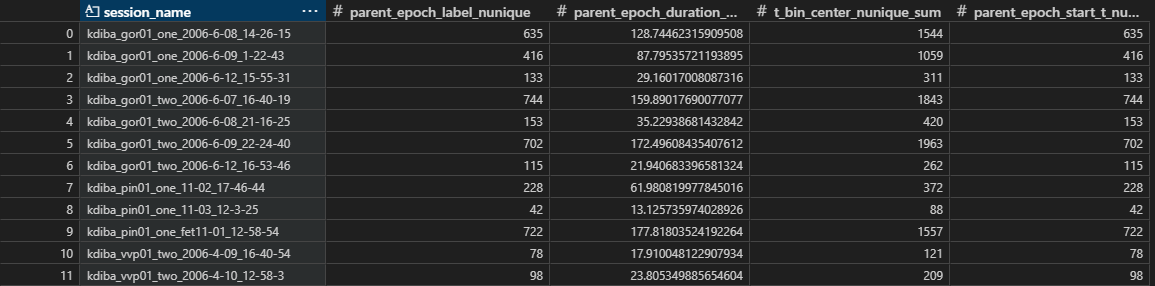

#### Filtered
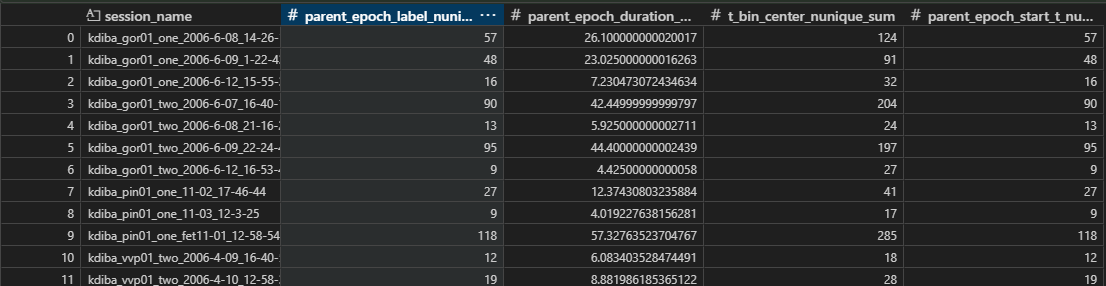

In [ ]:
active_df: pd.DataFrame = deepcopy(df_filter.filtered_df_dict['filtered_all_sessions_ripple_time_bin_df'])
# active_df: pd.DataFrame = deepcopy(df_filter.original_df_dict['all_sessions_ripple_time_bin_df'])
# active_df: pd.DataFrame = deepcopy(df_filter.filtered_df_dict['filtered_all_sessions_ripple_time_bin_df'])
active_df
session_parent_epochs_df: pd.DataFrame = active_df.groupby(['session_name', 'parent_epoch_start_t', 'parent_epoch_end_t', 'parent_epoch_label', 'parent_epoch_duration']).agg(t_bin_center_count=('t_bin_center', 'count'), t_bin_center_nunique=('t_bin_center', 'nunique')).reset_index()
session_parent_epochs_df

session_parent_epochs_df = session_parent_epochs_df.groupby(['session_name']).agg(parent_epoch_label_nunique=('parent_epoch_label', 'nunique'), parent_epoch_duration_sum=('parent_epoch_duration', 'sum'), t_bin_center_nunique_sum=('t_bin_center_nunique', 'sum'), parent_epoch_start_t_nunique=('parent_epoch_start_t', 'nunique')).reset_index()
session_parent_epochs_df

In [ ]:
## DURING LAPS:
## never matches more than 60% of the time bins within the parent epoch in question: 


In [ ]:

## get counts for each
# # Performed 4 aggregations grouped on column: 'session_name'
# active_df = active_df.groupby(['session_name']).agg(parent_epoch_start_t_nunique=('parent_epoch_start_t', 'nunique'), parent_epoch_id_nunique=('parent_epoch_id', 'nunique'), parent_epoch_label_count=('parent_epoch_label', 'count'), parent_epoch_id_nunique_2=('parent_epoch_id', 'nunique')).reset_index()
# Performed 4 aggregations grouped on column: 'session_name'
# active_df = active_df.groupby(['session_name']).agg(parent_epoch_start_t_nunique=('parent_epoch_start_t', 'nunique'), parent_epoch_id_nunique=('parent_epoch_id', 'nunique'), parent_epoch_label_count=('parent_epoch_label', 'count'), parent_epoch_df_idx_nunique=('parent_epoch_df_idx', 'nunique')).reset_index()
session_parent_epochs_df: pd.DataFrame = active_df.groupby(['session_name', 'parent_epoch_start_t', 'parent_epoch_end_t', 'parent_epoch_label', 'parent_epoch_duration']).agg(t_bin_center_count=('t_bin_center', 'count'), t_bin_center_nunique=('t_bin_center', 'nunique')).reset_index()
session_parent_epochs_df

In [ ]:
parent_epoch_start_t = deepcopy(np.unique(active_df[['parent_epoch_start_t', 'parent_epoch_end_t']], axis=1))
parent_epoch_start_t

np.shape(parent_epoch_start_t) # (613, 2)
n_parent_epochs: int = np.shape(parent_epoch_start_t)[0] # len(parent_epoch_start_t)
n_parent_epochs

In [ ]:
## show number of unique values in 'session_name' for filtered df
filter_col_name: str = 'session_name'

## show number of unique values in 'animal' for filtered df
filter_col_name: str = 'animal' ## see number of sessions

active_df: pd.DataFrame = deepcopy(df_filter.filtered_df_dict['filtered_all_sessions_laps_time_bin_df'])
# active_df: pd.DataFrame = deepcopy(df_filter.filtered_df_dict['filtered_all_sessions_laps_time_bin_df'])
# Performed 3 aggregations grouped on columns: 'animal', 'format_name'
active_df_counts_df: pd.DataFrame = active_df.groupby(['animal', 'format_name']).agg(session_name_nunique=('session_name', 'nunique'), time_bin_size_nunique=('time_bin_size', 'nunique'), exper_name_nunique=('exper_name', 'nunique')).reset_index()

# active_df
active_df_counts_df

animal_uniques: List[str] = np.unique(active_df_counts_df['animal'])
total_animal_nuniques: int = len(animal_uniques)
print(f'total_animal_nuniques: {total_animal_nuniques}')

total_active_session_names_nuniques: int = np.nansum(active_df_counts_df['session_name_nunique'])
print(f'total_active_session_names_nuniques: {total_active_session_names_nuniques}')

## OUTPUTS: total_animal_nuniques, total_active_session_names_nuniques
col_desc_names_dict = {'session_name_nunique': 'number unique sessions', 
    'exper_name_nunique': 'number unique experiment configurations (e.g. ["one", "two"])',
}


# total_animal_nuniques: 3
# total_active_session_names_nuniques: 7
# gor01: 5 sessions
# pin01, vvp01: 1 session each



In [ ]:
active_included_session_contexts: List[str] = np.unique(FAT_df['session_name']).tolist() # ['kdiba_gor01_one_2006-6-08_14-26-15', 'kdiba_gor01_one_2006-6-09_1-22-43', 'kdiba_gor01_one_2006-6-12_15-55-31', 'kdiba_gor01_two_2006-6-07_16-40-19', 'kdiba_gor01_two_2006-6-12_16-53-46', 'kdiba_pin01_one_11-03_12-3-25', 'kdiba_vvp01_two_2006-4-09_16-40-54']
# active_included_session_contexts: List[str] = np.unique(active_df['session_name']).tolist() # ['kdiba_gor01_one_2006-6-08_14-26-15', 'kdiba_gor01_one_2006-6-09_1-22-43', 'kdiba_gor01_one_2006-6-12_15-55-31', 'kdiba_gor01_two_2006-6-07_16-40-19', 'kdiba_gor01_two_2006-6-12_16-53-46', 'kdiba_pin01_one_11-03_12-3-25', 'kdiba_vvp01_two_2006-4-09_16-40-54']
active_included_session_contexts



In [ ]:
@function_attributes(short_name=None, tags=['across_sessions', 'filter', 'active_sessions'], input_requires=[], output_provides=[], uses=[], used_by=[], creation_date='2026-09-14 16:12', related_items=[])
def compare_active_filtered_sessions(active_included_session_contexts: List[str], expected_included_session_names_list: List[str], debug_warn_unmatched_sessions: bool = False, debug_print: bool = False):
    ## INPUTS: active_included_session_contexts, expected_included_session_names_list
    active_unmatched_sessions = set(deepcopy(active_included_session_contexts))
    missing_expected_sessions: List[str] = [] ## sessions missing from the active filter that were expected
    found_expective_active_session_names_dict: Dict[str, str] = {}

    for an_expected in expected_included_session_names_list:
        did_find: bool = False
        # for an_active in active_included_session_contexts:
        for an_active in active_unmatched_sessions:
            if (not did_find) and (an_expected in an_active):
                ## found
                if debug_print:
                    print(f'FOUND: an_expected: "{an_expected}", an_active: "{an_active}"')
                found_expective_active_session_names_dict[an_expected] = an_active
                active_unmatched_sessions.remove(an_active) ## modifies while iterating
                did_find = True
                break ## break from loop
        ## END for an_active in active_included_....
        if (not did_find):
            if debug_print:
                print(f'WARNING: failed to find an_expected: "{an_expected}" in active.')
            missing_expected_sessions.append(an_expected)
        # else:
        #     missing_sessions.pop(an_active)
    ## END for an_expected in expected_included_session_names_list...

    if len(active_unmatched_sessions) > 0:
        if (debug_print or debug_warn_unmatched_sessions):
            print(f'WARNING: never found {len(active_unmatched_sessions)} missing_sessions: {active_unmatched_sessions}')
    else:
        if (debug_print or debug_warn_unmatched_sessions):
            print(f'found ALL expected')


    if len(missing_expected_sessions) > 0:
        if debug_print:
            print(f'WARNING: missing {len(missing_expected_sessions)} missing_expected_sessions: {missing_expected_sessions} from active given expected.')
    else:
        if debug_print:
            print(f'active contains all expected sessions!')

    ## OUTPUTS: found_expective_active_session_names_dict, missing_expected_sessions
    return (found_expective_active_session_names_dict, missing_expected_sessions)

expected_included_session_contexts: List[IdentifyingContext] = [ 
    IdentifyingContext(format_name='kdiba',animal='gor01',exper_name='one',session_name='2006-6-08_14-26-15'), # 
    IdentifyingContext(format_name='kdiba',animal='gor01',exper_name='one',session_name='2006-6-09_1-22-43'), # 
    IdentifyingContext(format_name='kdiba',animal='gor01',exper_name='one',session_name='2006-6-12_15-55-31'), # 
    IdentifyingContext(format_name='kdiba',animal='gor01',exper_name='two',session_name='2006-6-07_16-40-19'), # 2025-07-17 02:23 DEFER- still finishing 'ProcessingScriptPhases.continued_run'
    IdentifyingContext(format_name='kdiba',animal='gor01',exper_name='two',session_name='2006-6-08_21-16-25'), # 
    IdentifyingContext(format_name='kdiba',animal='gor01',exper_name='two',session_name='2006-6-09_22-24-40'), # 2025-07-17 03:03 DONE with 'ProcessingScriptPhases.continued_run' #   2025-07-17 02:23 DEFER- still finishing 'ProcessingScriptPhases.continued_run'
    IdentifyingContext(format_name='kdiba',animal='gor01',exper_name='two',session_name='2006-6-12_16-53-46'), #
    # IdentifyingContext(format_name='kdiba',animal='vvp01',exper_name='one',session_name='2006-4-10_12-25-50'), # 2025-08-22 - Decided to discard because the positions are shifted between 'x' and 'lin_pos', and that manifests on the pf peaks.
    IdentifyingContext(format_name='kdiba',animal='vvp01',exper_name='two',session_name='2006-4-09_16-40-54'), #
    # IdentifyingContext(format_name='kdiba',animal='vvp01',exper_name='two',session_name='2006-4-10_12-58-3'), # 2025-08-22 - Decided that this session is bad. The context decoder returns short for nearly all non-lap period pre-delta, and additionally there aren't many replays.
    IdentifyingContext(format_name='kdiba',animal='vvp01',exper_name='two',session_name='2006-4-10_12-58-3'),
    IdentifyingContext(format_name='kdiba',animal='pin01',exper_name='one',session_name='fet11-01_12-58-54'), # 2025-10-20 - Fixed position tracking issues in MATLAB. 2024-10-04 - very bad position tracking data (jumping around everywhere at high frequency)
    IdentifyingContext(format_name='kdiba',animal='pin01',exper_name='one',session_name='11-02_17-46-44'), # 2025-10-20 - Fixed position tracking issues in MATLAB. 2024-10-01 - bad laps, Bad Laps "3"/"4" - don't see lap 1/2        
    IdentifyingContext(format_name='kdiba',animal='pin01',exper_name='one',session_name='11-03_12-3-25'), 
]
# expected_included_session_contexts

expected_included_session_names_list: List[str] = [k.session_name for k in expected_included_session_contexts]
# print(expected_included_session_names_list) # ['2006-6-08_14-26-15', '2006-6-09_1-22-43', '2006-6-12_15-55-31', '2006-6-07_16-40-19', '2006-6-08_21-16-25', '2006-6-09_22-24-40', '2006-6-12_16-53-46', '2006-4-09_16-40-54', '2006-4-10_12-58-3', 'fet11-01_12-58-54', '11-02_17-46-44', '11-03_12-3-25']

## OUTPUTS: expected_included_session_contexts, expected_included_session_names_list

# active_df: pd.DataFrame = deepcopy(all_sessions_laps_time_bin_df) ## LAPs
active_df: pd.DataFrame = deepcopy(all_sessions_ripple_time_bin_df) ## PBEs

## Get the unique 'session_name's from the `active_df`:
active_included_session_contexts: List[str] = np.unique(active_df['session_name']).tolist() # ['kdiba_gor01_one_2006-6-08_14-26-15', 'kdiba_gor01_one_2006-6-09_1-22-43', 'kdiba_gor01_one_2006-6-12_15-55-31', 'kdiba_gor01_two_2006-6-07_16-40-19', 'kdiba_gor01_two_2006-6-12_16-53-46', 'kdiba_pin01_one_11-03_12-3-25', 'kdiba_vvp01_two_2006-4-09_16-40-54']
print(active_included_session_contexts)

found_expective_active_session_names_dict, missing_expected_sessions = compare_active_filtered_sessions(active_included_session_contexts=active_included_session_contexts, expected_included_session_names_list=expected_included_session_names_list)
print(missing_expected_sessions) # ['2006-6-08_21-16-25', '2006-6-09_22-24-40', '2006-4-10_12-58-3', 'fet11-01_12-58-54', '11-02_17-46-44']

#TODO 2026-09-14 16:53: - [ ] Adding ['2006-6-08_21-16-25', '2006-6-09_22-24-40', '2006-4-10_12-58-3', 'fet11-01_12-58-54', '11-02_17-46-44']

## Inspecting filter flow figures

In [ ]:
fig = df_filter.build_filter_impact_flow_figure(
    # expand_vars=['trained_compute_epochs', 'known_named_decoding_epochs_type'],
    chart='sankey')
fig.show()


In [ ]:


fig = df_filter.build_filter_impact_flow_figure(chart='funnel')  # active path only
fig.show()

In [ ]:
## INPUTS: df_filter
merged_predicate_operations_df: pd.DataFrame = df_filter._build_merged_predicates_row_changed_df()
merged_predicate_operations_df

In [ ]:

## cummulative only
cummulative_only = {a_filtered_df_name:{k:v for k, v in a_dict.items() if k.startswith('CUM_')} for a_filtered_df_name, a_dict in df_filter.step_by_step_predicate_filtered_row_counts_dict.items()}
META_only = {a_filtered_df_name:{k:v for k, v in a_dict.items() if k.startswith('META_')} for a_filtered_df_name, a_dict in df_filter.step_by_step_predicate_filtered_row_counts_dict.items()}
individual_predicates_only = {a_filtered_df_name:{k:v for k, v in a_dict.items() if ((not k.startswith('META_')) and (not k.startswith('CUM_')))} for a_filtered_df_name, a_dict in df_filter.step_by_step_predicate_filtered_row_counts_dict.items()}


META_only
cummulative_only
individual_predicates_only

In [ ]:
a_filtered_df_name: str = 'filtered_all_sessions_ripple_time_bin_df'


In [ ]:
a_dict = cummulative_only[a_filtered_df_name]
individual_predicates_only_df: pd.DataFrame = pd.DataFrame({k:[v] for k, v in individual_predicates_only[a_filtered_df_name].items()}).T
individual_predicates_only_df.columns = ['n_predicate_true_rows']
# individual_predicates_only_df

# a_dict

n_unfiltered: int = META_only[a_filtered_df_name]['META_n_unfiltered']
n_post_filtered: int = META_only[a_filtered_df_name]['META_post_filters']

(n_unfiltered, n_post_filtered)
## OUTPUTS: n_unfiltered, n_post_filtered

# cummulative_only_df: pd.DataFrame = pd.DataFrame({k:[v] for k, v in a_dict.items()}).T
# cummulative_only_df.columns = ['n_remaining_rows']
# cummulative_only_df

individual_predicates_only_df['n_remaining_rows'] = cummulative_only[a_filtered_df_name].values()
cum_num_rows = [n_unfiltered, *individual_predicates_only_df['n_remaining_rows'].to_numpy().tolist()] # .cumsum()
cum_num_rows # [245837, 22846, 18632, 18632, 5228]
assert cum_num_rows[-1] == n_post_filtered, f"cum_num_rows[-1]: {cum_num_rows[-1]} should equal n_post_filtered: {n_post_filtered}, but it does not!"
cum_num_rows_diff = np.diff(cum_num_rows) ## number of rows each predicate was responsible for removing: array([-222991,   -4214,       0,  -13404])
cum_num_rows_diff
assert len(cum_num_rows_diff) == len(individual_predicates_only_df)
individual_predicates_only_df['n_pred_filtered_rows'] = cum_num_rows_diff
# cummulative_only_df
# cummulative_only_df['n_cum_rows'].cumsum()

individual_predicates_only_df

In [ ]:
def _build_predicates_row_changed_df(a_dict) -> pd.DataFrame:
    """ 
    builds counts for debugging the effect of applying each predicate sequentially

    """
    cummulative_only = {k:v for k, v in a_dict.items() if k.startswith('CUM_')}
    # META_only = {k:v for k, v in a_dict.items() if k.startswith('META_')}
    individual_predicates_only = {k:v for k, v in a_dict.items() if ((not k.startswith('META_')) and (not k.startswith('CUM_')))}

    individual_predicates_only_df: pd.DataFrame = pd.DataFrame({k:[v] for k, v in individual_predicates_only.items()}).T
    individual_predicates_only_df.columns = ['n_predicate_true_rows']
    # individual_predicates_only_df

    n_unfiltered: int = a_dict['META_n_unfiltered']
    n_post_filtered: int = a_dict['META_post_filters']

    (n_unfiltered, n_post_filtered)
    ## OUTPUTS: n_unfiltered, n_post_filtered


    individual_predicates_only_df['n_remaining_rows'] = cummulative_only.values()
    cum_num_rows = [n_unfiltered, *individual_predicates_only_df['n_remaining_rows'].to_numpy().tolist()] # .cumsum()
    cum_num_rows # [245837, 22846, 18632, 18632, 5228]
    assert cum_num_rows[-1] == n_post_filtered, f"cum_num_rows[-1]: {cum_num_rows[-1]} should equal n_post_filtered: {n_post_filtered}, but it does not!"
    cum_num_rows_diff = np.diff(cum_num_rows) ## number of rows each predicate was responsible for removing: array([-222991,   -4214,       0,  -13404])
    cum_num_rows_diff
    assert len(cum_num_rows_diff) == len(individual_predicates_only_df)
    individual_predicates_only_df['n_pred_filtered_rows'] = cum_num_rows_diff
    # cummulative_only_df
    individual_predicates_only_df['n_cum_filtered_rows'] = individual_predicates_only_df['n_pred_filtered_rows'].cumsum()

    return individual_predicates_only_df


## INPUTS: df_filter
# individual_predicates_only_df_dict: Dict[str, pd.DataFrame] = {a_filtered_df_name:_build_predicates_row_changed_df(a_dict=a_dict) for a_filtered_df_name, a_dict in df_filter.step_by_step_predicate_filtered_row_counts_dict.items()}
# individual_predicates_only_df_dict


predicate_operations_df_dict: Dict[str, pd.DataFrame] = {a_filtered_df_name:df_filter._build_single_predicates_row_changed_df(a_dict=a_dict) for a_filtered_df_name, a_dict in df_filter.step_by_step_predicate_filtered_row_counts_dict.items()}
predicate_operations_df_dict


In [ ]:
print(list(predicate_operations_df_dict['filtered_all_sessions_ripple_time_bin_df'].columns)) # ['n_predicate_true_rows', 'n_remaining_rows', 'n_pred_filtered_rows', 'n_cum_filtered_rows']

['predicate_name', 'n_predicate_true_rows', 'n_remaining_rows', 'n_pred_filtered_rows', 'n_cum_filtered_rows']


In [ ]:
## INPUTS: predicate_operations_df_dict
# print(list(predicate_operations_df_dict.keys())) # ['filtered_all_sessions_ripple_time_bin_df', 'filtered_all_sessions_laps_time_bin_df']
# [k.removeprefix('filtered_all_sessions_').removesuffix('_time_bin_df') for k in list(predicate_operations_df_dict.keys())] # ['ripple', 'laps']
predicate_operations_df_keys_to_shortkeys_dict: Dict[str, str] = {k:k.removeprefix('filtered_all_sessions_').removesuffix('_time_bin_df') for k in list(predicate_operations_df_dict.keys())} # ['ripple', 'laps']
predicate_operations_df_keys_to_shortkeys_dict


predicate_operations_df = []
# predicate_operations_df = pd.concat([df for name, df in predicate_operations_df_dict.items()])
# predicate_operations_df

for a_df_name, df in predicate_operations_df_dict.items():
    a_short_key: str = predicate_operations_df_keys_to_shortkeys_dict[a_df_name]
    for a_row in df.itertuples():
        # replacement_idx: str = f"{name}_{a_row[0]}" # "filtered_all_sessions_ripple_time_bin_df_time_bin_size"
        replacement_idx: str = f"{a_short_key}|{a_row[0]}" # "ripple_time_bin_size"
        predicate_operations_df.append((replacement_idx, *a_row[1:]))

predicate_operations_df = pd.DataFrame.from_records(predicate_operations_df)
predicate_operations_df

In [ ]:
# ['filtered_all_sessions_ripple_time_bin_df', 'filtered_all_sessions_laps_time_bin_df']
'filtered_all_sessions_laps_time_bin_df'.removeprefix('filtered_all_sessions_').removesuffix('_time_bin_df') ## 'laps'

In [ ]:
print(list(predicate_operations_df_dict.keys())) # ['filtered_all_sessions_ripple_time_bin_df', 'filtered_all_sessions_laps_time_bin_df']

[k.removeprefix('filtered_all_sessions_').removesuffix('_time_bin_df') for k in list(predicate_operations_df_dict.keys())] # ['ripple', 'laps']



In [ ]:
df_filter.filtered_size_info_df

In [ ]:
a_dict = df_filter.step_by_step_predicate_filtered_row_counts_dict[a_filtered_df_name]
a_dict

In [ ]:
px.scatter(all_sessions_ripple_time_bin_df, x='t_bin_center', facet_row='session_name', facet_row_spacing=0.01)

### Constraining values programmaticaly

In [ ]:
from pyphoplacecellanalysis.SpecificResults.PhoDiba2023Paper import DataFrameFilter

filter_widget_constrain_dict = df_filter.get_df_filter_active_constraint_dict()
filter_widget_constrain_dict
# df_filter.original_df_dict
# df_filter.filtered_df_dict


# df_filter.original_df_dict
df_filter._build_pho_constrain_df_code_str_from_filter_widget_constrain_dict(filter_widget_constrain_dict)


In [ ]:
## Save out all .csvs for analysis in external software


In [ ]:
all_sessions_laps_time_bin_df, all_sessions_ripple_time_bin_df


In [ ]:
export_parent_path = Path(r'E:\Dropbox (Personal)\Active\Kamran Diba Lab\Pho-Kamran-Meetings\2025-10-23_Pin01SessionInclusion\2025-11-04_AllSessions').resolve()

out_laps_path = export_parent_path.joinpath('all_sessions_laps_time_bin_df.csv')
all_sessions_laps_time_bin_df.to_csv(out_laps_path)
print(f'saved out to "{out_laps_path}"')



In [ ]:
out_PBEs_path = export_parent_path.joinpath('all_sessions_ripple_time_bin_df.csv')
all_sessions_ripple_time_bin_df.to_csv(out_PBEs_path)
print(f'saved out to "{out_PBEs_path}"')
out_PBEs_path

### Old (Pre 2025-10-15)

In [ ]:
# df = deepcopy(all_sessions_laps_time_bin_df).pho.constrain_df_cols(trained_compute_epochs="laps", decoder_identifier="pseudo2D", masked_time_bin_fill_type="dropped", replay_name="withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 8, 9]-frateThresh_2.0", time_bin_size=0.06)


# df = deepcopy(all_sessions_laps_time_bin_df).pho.constrain_df_cols(trained_compute_epochs="laps", decoder_identifier="pseudo2D", masked_time_bin_fill_type="dropped", custom_replay_name="withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 8, 9]-frateThresh_2.0", time_bin_size=0.06)
df: pd.DataFrame = deepcopy(all_sessions_laps_time_bin_df).pho.constrain_df_cols(trained_compute_epochs="laps", decoder_identifier="pseudo2D", masked_time_bin_fill_type='dropped', custom_replay_name="withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 8, 9]-frateThresh_2.0", time_bin_size=0.025)
df

In [ ]:
from pyphoplacecellanalysis.Pho2D.statistics_plotting_helpers import _perform_stats_tests
import scipy.stats as stats

df: pd.DataFrame = deepcopy(all_sessions_laps_time_bin_df).pho.constrain_df_cols(trained_compute_epochs="laps", decoder_identifier="pseudo2D", masked_time_bin_fill_type='dropped', custom_replay_name="withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 8, 9]-frateThresh_2.0", time_bin_size=0.025)
shuffle_results, shuffle_result_extras, p_value, f_value, (dof1, dof2), (variance1, variance2) = _perform_stats_tests(deepcopy(df), stats_variable_name='P_Short', n_shuffles=1000)


# stats_variable_name: "P_Long" -- actual_diff_means: -0.28949070814482547
# stats_variable_name: P_Long
# Statistics=430586010.50, p=0.00
# Reject Null Hypothesis (Significant difference between two samples)
# Variance 1: 0.05143822935506828
# Variance 2: 0.08773111653582448
# Degree of freedom 1: 26631
# Degree of freedom 2: 20769
# F-statistic: 0.5863168210570281
# p-value: 0.0


actual_pre_post_delta_counts_dict = shuffle_result_extras['distributions']['real']
_shuffled_pre_post_delta_counts_dict_list = actual_pre_post_delta_counts_dict = shuffle_result_extras['distributions']['shuffle']

_shuffled_pre_post_delta_counts_dict_list[0]



In [ ]:
from pyphocorehelpers.indexing_helpers import partition, partition_df, partition_df_dict
import scipy.stats as stats

stats_variable_name: str =' P_Short'

analysis_df = deepcopy(df[["delta_aligned_start_t", "pre_post_delta_category", stats_variable_name]]).dropna(subset=["pre_post_delta_category", stats_variable_name])
# partition_df(analysis_df, partitionColumn='pre_post_delta_category')

# _partition_values, (_pre_delta_df, _post_delta_df) = partition(analysis_df, partitionColumn='pre_post_delta_category') # use `valid_ripple_df` instead of the original dataframe to only get those which are valid.
_pre_post_delta_partition_df_dict = partition_df_dict(analysis_df, partitionColumn='pre_post_delta_category')
_pre_delta_df = _pre_post_delta_partition_df_dict['pre-delta']
_post_delta_df = _pre_post_delta_partition_df_dict['post-delta']

actual_diff_means = np.nanmean(_post_delta_df[stats_variable_name].to_numpy()) - np.nanmean(_pre_delta_df[stats_variable_name].to_numpy())
print(f'stats_variable_name: "{stats_variable_name}" -- actual_diff_means: {actual_diff_means}')
actual_diff_means

In [ ]:
shuffle_results
np.sum(np.abs(actual_diff_means) > np.abs(shuffle_results))

In [ ]:
from attrs import define, field, Factory

@define(slots=True, auto_attribs=True)
class ShuffleStats:
    actual_diff_means: float
    shuffle_results: NDArray # = field(default=Factory(list))
    p_value: float
    f_value: float
    dof1: float
    dof2: float
    variance1: float
    variance2: float


# shuffle_results, p_value, f_value, dof1, dof2, variance1, variance2

# shuffle_stats_result: ShuffleStats = ShuffleStats(actual_diff_means=actual_diff_means,
#     shuffle_results=[0.12, 0.34, 0.56],
#     p_value=0.03,
#     f_value=5.67,
#     dof1=1,
#     dof2=28,
#     variance1=0.42,
#     variance2=0.58
# )

shuffle_stats_result: ShuffleStats = ShuffleStats(actual_diff_means=actual_diff_means,
    shuffle_results=shuffle_results,
    p_value=p_value,
    f_value=f_value,
    dof1=dof1,
    dof2=dof2,
    variance1=variance1,
    variance2=variance2,
)

shuffle_stats_result

In [ ]:
# shuffle_stats_result


In [ ]:

# Calculate the sample variances
variance1 = np.var(group1, ddof=1)
variance2 = np.var(group2, ddof=1)

print('Variance 1:',variance1)
print('Variance 2:',variance2)

# Calculate the F-statistic
f_value = variance1 / variance2

# Calculate the degrees of freedom
dof1 = len(group1) - 1
dof2 = len(group2) - 1

# Calculate the p-value
p_value = stats.f.cdf(f_value, dof1, dof2)

# Print the results
print('Degree of freedom 1:',dof1)
print('Degree of freedom 2:',dof2)
print("F-statistic:", f_value)
print("p-value:", p_value)

In [ ]:
f_value

In [ ]:
np.shape(shuffle_results)


In [ ]:

df_filter.original_df_names

df_filter.replay_name # 'withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 8, 9]-frateThresh_2.0'
df_filter.active_plot_df_name # 'filtered_all_sessions_laps_time_bin_df'

In [ ]:
df.pho.constrain(**filter_widget_constrain_dict)

a_widget_metadata_dict = a_widget.metadata.__dict__['default_args'][0]
a_widget_metadata_dict['df_col_name']

a_widget.value

# {'desc': 'build_extra_dropdown_widget',
#  'df_col_name': 'trained_compute_epochs',
#  'name': 'trained_compute_epochs',
#  'widget_name': 'trained_compute_epochs_widget'}

## Get filter predicates dynamically from df_filter
# a_widget.metadata

# 'df_col_name'

In [ ]:
# df_filter.additional_filter_predicates['decoder_identifier_widget']

import inspect

code_line = inspect.getsource(df_filter.additional_filter_predicates['decoder_identifier_widget']).strip() # f'{a_widget_name}': (lambda df: (df[df_col_name].astype(str) == str(a_widget.value))),
print(code_line)



### _sanity_check_dropped_t_bins_per_session

In [ ]:
from pyphoplacecellanalysis.SpecificResults.AcrossSessionResults import AcrossSessionsVisualizations

def _subfn_plot_sanity_check(active_df: pd.DataFrame, export_suffix: str):
    # df = deepcopy(all_sessions_laps_time_bin_df).pho.constrain_df_cols(trained_compute_epochs="laps", decoder_identifier="pseudo2D", masked_time_bin_fill_type="dropped", custom_replay_name="withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 8, 9]-frateThresh_2.0", time_bin_size=0.06)
    acitve_dropped_df: pd.DataFrame = deepcopy(active_df).pho.constrain_df_cols(should_drop_constrained_columns=False, trained_compute_epochs="laps", decoder_identifier="pseudo2D", masked_time_bin_fill_type='dropped', custom_replay_name="withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 8, 9]-frateThresh_2.0", time_bin_size=time_bin_size)
    acitve_ignore_df: pd.DataFrame = deepcopy(active_df).pho.constrain_df_cols(should_drop_constrained_columns=False, trained_compute_epochs="laps", decoder_identifier="pseudo2D", masked_time_bin_fill_type='ignore', custom_replay_name="withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 8, 9]-frateThresh_2.0", time_bin_size=time_bin_size)

    ## OUTPUTS: acitve_dropped_df, acitve_ignore_df

    ## INPUTS: acitve_dropped_df, acitve_ignore_df
    acitve_counts_df, (acitve_ignore_counts_df, acitve_dropped_counts_df) = AcrossSessionsVisualizations._sanity_check_dropped_t_bins_per_session(acitve_dropped_df=acitve_dropped_df, acitve_ignore_df=acitve_ignore_df, export_suffix=export_suffix)
    return acitve_counts_df


# time_bin_size = 0.025
time_bin_size = 0.075
# time_bin_size = 0.5

# # # Laps _______________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________ #
# export_suffix: str = f'Laps - {time_bin_size}s'
# active_df: pd.DataFrame = all_sessions_laps_time_bin_df

# # # PBEs _______________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________ #
# export_suffix: str = f'PBEs - {time_bin_size}s'
# active_df: pd.DataFrame = all_sessions_ripple_time_bin_df

epochs_to_analyze_dict = {f'Laps - {time_bin_size}s': all_sessions_laps_time_bin_df,
          f'PBEs - {time_bin_size}s': all_sessions_ripple_time_bin_df,
}

_out_sanity_check = {}
for an_export_suffix, an_active_df in epochs_to_analyze_dict.items():
    _out_sanity_check[an_export_suffix] = _subfn_plot_sanity_check(active_df=an_active_df, export_suffix=an_export_suffix)


In [ ]:
df_filter.active_plot_df['session_name'].value_counts()

moderate_anticipation_sessions = ['kdiba_gor01_one_2006-6-08_14-26-15', 'kdiba_gor01_one_2006-6-09_1-22-43', ]
high_anticipation_sessions = ['kdiba_vvp01_two_2006-4-10_12-58-3', 'kdiba_gor01_two_2006-6-12_16-53-46']

In [ ]:
df_filter.active_plot_df

In [ ]:
is_decoded_post_short_track_body = df_filter.active_plot_df['is_decoded_pos_short_track_body']
is_decoded_post_short_track_body


In [ ]:
# df_filter.active_plot_df = df_filter.active_plot_df[is_decoded_post_short_track_body]
df_filter.active_plot_df = df_filter.filtered_df_dict[is_decoded_post_short_track_body]


### ALT: MATPLOTLIB Version - 2025-08-11

In [ ]:
import matplotlib as mpl
# print(mpl.rcParamsDefault['axes.linewidth'])  # 0.8

# from typing import NewType

# SeriesLetter = NewType('SeriesLetter', str) # a letter in ['a', 'b', 'c', 'd'] coresponding to one of the four configurations
# AnimalName = NewType('AnimalName', str) # an animal name in ['gor01', 'vvp01', ''] coresponding to one of the three animals

from pyphoplacecellanalysis.SpecificResults.PendingNotebookCode import SeriesLetter, AnimalName
from pyphoplacecellanalysis.SpecificResults.PhoDiba2023Paper import _perform_dual_hist_plot, _perform_matplotlib_pre_post_scatter, _perform_matplotlib_SINGLE_SERIES_pre_post_scatter
matplotlib.use('Qt5Agg')

# a_time_bin_size: float = 0.025
# a_time_bin_size: float = 0.050
a_time_bin_size: float = 0.075

_perform_matplotlib_SINGLE_SERIES_pre_post_scatter = partial(
	_perform_matplotlib_SINGLE_SERIES_pre_post_scatter,
    legend_groups_to_solo=[a_time_bin_size], legend_groups_to_hide=None,
)


## INPUTS: all_sessions_laps_time_bin_df, all_sessions_ripple_time_bin_df
active_all_sessions_laps_time_bin_df = deepcopy(all_sessions_laps_time_bin_df)
active_all_sessions_ripple_time_bin_df = deepcopy(all_sessions_ripple_time_bin_df)

# active_all_sessions_laps_time_bin_df = deepcopy(all_sessions_laps_time_bin_df[all_sessions_laps_time_bin_df['is_decoded_pos_long_track_body']])
# active_all_sessions_ripple_time_bin_df = deepcopy(all_sessions_ripple_time_bin_df[all_sessions_ripple_time_bin_df['is_decoded_pos_long_track_body']])

# active_all_sessions_laps_time_bin_df: pd.DataFrame = deepcopy(all_sessions_laps_time_bin_df[all_sessions_laps_time_bin_df['is_track_body']])
# active_all_sessions_ripple_time_bin_df: pd.DataFrame = deepcopy(all_sessions_ripple_time_bin_df[all_sessions_ripple_time_bin_df['is_track_body']])

# original_df_dict = {'all_sessions_laps_time_bin_df':all_sessions_laps_time_bin_df, 'all_sessions_ripple_time_bin_df': all_sessions_ripple_time_bin_df}

active_df_dict = {'all_sessions_laps_time_bin_df':active_all_sessions_laps_time_bin_df, 'all_sessions_ripple_time_bin_df': active_all_sessions_ripple_time_bin_df}

for k, original_df in original_df_dict.items():
    active_df = active_df_dict[k]
    v_counts = original_df['is_track_body'].value_counts().to_dict()
    print(f'{k}: is_track_body: {v_counts}')
    print(f'\toriginal: {len(original_df) }, filtered: {len(active_df)}, change: {len(active_df) - len(original_df)}')
    
    
# len(active_all_sessions_laps_time_bin_df)


## OUTPUTS: active_all_sessions_laps_time_bin_df, active_all_sessions_ripple_time_bin_df


In [ ]:
330628 - 657967



In [ ]:
active_all_sessions_laps_time_bin_df

### ❎ 2025-11-05 - meas_v_decoded_occupancy from FAT_df

In [ ]:
from neuropy.utils.result_context import IdentifyingContext

import matplotlib as mpl
import matplotlib.pyplot as plt
from flexitext import flexitext ## flexitext for formatted matplotlib text
from pyphocorehelpers.DataStructure.RenderPlots.MatplotLibRenderPlots import FigureCollector
from neuropy.utils.matplotlib_helpers import FormattedFigureText

from neuropy.utils.result_context import IdentifyingContext
from pyphoplacecellanalysis.General.Pipeline.Stages.ComputationFunctions.MultiContextComputationFunctions.DirectionalPlacefieldGlobalComputationFunctions import _helper_add_interpolated_position_columns_to_decoded_result_df

from pyphoplacecellanalysis.General.Pipeline.Stages.ComputationFunctions.EpochComputationFunctions import EpochComputationsComputationsContainer
from pyphoplacecellanalysis.Analysis.Decoder.context_dependent import GenericDecoderDictDecodedEpochsDictResult
from pyphoplacecellanalysis.General.Pipeline.Stages.ComputationFunctions.MultiContextComputationFunctions.DirectionalPlacefieldGlobalComputationFunctions import DirectionalLapsResult, TrackTemplates
from pyphoplacecellanalysis.SpecificResults.PendingNotebookCode import MeasuredVsDecodedOccupancy
from pyphoplacecellanalysis.SpecificResults.PhoDiba2023Paper import PhoPublicationFigureHelper

display_fn_name: str = 'meas_v_decoded_occupancy' # same as "short_name"

time_bin_size: float = 0.075
size=[3.5, 2]
dpi=100
prepare_for_publication=False
export_dpi_multiplier: float = 2.0
export_dpi: int = int(np.ceil(dpi * export_dpi_multiplier))

a_df: pd.DataFrame = deepcopy(active_all_sessions_laps_time_bin_df)
a_df = a_df.pho.constrain_df_cols(trained_compute_epochs="laps", decoder_identifier="pseudo2D", masked_time_bin_fill_type='dropped', custom_replay_name="withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 8, 9]-frateThresh_2.0", time_bin_size=time_bin_size)


a_df_dict = a_df.pho.partition_df_dict('pre_post_delta_category')

## all we have is the `most_likely_positions_1D`, which sucks, but I guess we can plot that (decoded position). 

a_pre_post_df = deepcopy(a_df_dict['pre-delta'])

a_pre_post_df.plot.hist('most_likely_positions_1D')



## 2025-11-05 - Main

In [ ]:
epochs_df: pd.DataFrame = deepcopy(active_all_sessions_laps_time_bin_df).pho.constrain_df_cols(trained_compute_epochs="laps", decoder_identifier="pseudo2D", masked_time_bin_fill_type='dropped', custom_replay_name="withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 8, 9]-frateThresh_2.0")
epochs_df['delta_aligned_start_t']
epochs_df['P_Long']

In [ ]:

## INPUTS: active_all_sessions_laps_time_bin_df, active_all_sessions_ripple_time_bin_df

# grainularity_desc: str = 'by-time-bin'
# laps_df: pd.DataFrame = all_sessions_laps_time_bin_df
# ripple_df: pd.DataFrame = all_sessions_ripple_time_bin_df
# _out_figs_dict = {}

_laps_histogram_out = _perform_matplotlib_SINGLE_SERIES_pre_post_scatter(grainularity_desc='by-time-bin',
																	epochs_df=deepcopy(active_all_sessions_laps_time_bin_df).pho.constrain_df_cols(trained_compute_epochs="laps", decoder_identifier="pseudo2D", masked_time_bin_fill_type='dropped', custom_replay_name="withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 8, 9]-frateThresh_2.0"), # , time_bin_size=a_time_bin_size
                                                                    time_column='delta_aligned_start_t',
                                                                    #   legend_groups_to_solo=[0.025], legend_groups_to_hide=None,
                                                                    #   legend_groups_to_solo=None, legend_groups_to_hide=[0.03, 0.0444, 0.05],
																	# subplot_by_column='session_name',
                                                                    )


In [ ]:

_ripple_histogram_out = _perform_matplotlib_SINGLE_SERIES_pre_post_scatter(grainularity_desc='by-time-bin',
                                                                    epochs_df=deepcopy(active_all_sessions_ripple_time_bin_df).pho.constrain_df_cols(trained_compute_epochs="laps", decoder_identifier="pseudo2D", masked_time_bin_fill_type='dropped', custom_replay_name="withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 8, 9]-frateThresh_2.0"), # , time_bin_size=a_time_bin_size
                                                                    time_column='delta_aligned_start_t',
                                                                    #   legend_groups_to_solo=[0.025], legend_groups_to_hide=None,
                                                                    #   legend_groups_to_solo=None, legend_groups_to_hide=[0.03, 0.0444, 0.05],
																	# subplot_by_column='session_name',
                                                                    )

# _out_figs_dict[_ripple_histogram_out.context.descriptor_str] = _ripple_histogram_out.figures[0]

In [ ]:
active_all_sessions_ripple_time_bin_df

### 2025-10-09 - Extracting Counts/Histogram info from figure outputs

In [ ]:
from neuropy.utils.indexing_helpers import transpose_nested_dict
from pyphoplacecellanalysis.SpecificResults.PendingNotebookCode import compute_hist_variables, fig4_hist_stats_pho, plot_fisher_z, plot_earthmovers, plot_kldivergence
from pyphoplacecellanalysis.SpecificResults.PendingNotebookCode import plot_by_animal_split_histogram_figure, plot_by_session_split_histogram_figure


hist_samples_df_dict: Dict[SeriesLetter, pd.DataFrame] = {'a': [], 'b': [], 'c': [], 'd': []}
hist_samples_df_dict['a'] = _laps_histogram_out.plots_data.hist['epochs_pre_delta'][a_time_bin_size]['df']
hist_samples_df_dict['b'] = _laps_histogram_out.plots_data.hist['epochs_post_delta'][a_time_bin_size]['df']
hist_samples_df_dict['c'] = _ripple_histogram_out.plots_data.hist['epochs_pre_delta'][a_time_bin_size]['df']
hist_samples_df_dict['d'] = _ripple_histogram_out.plots_data.hist['epochs_post_delta'][a_time_bin_size]['df']

# hist_samples_df_dict
hist_counts_dict = {'a': [], 'b': [], 'c': [], 'd': []}
hist_counts_dict['a'] = _laps_histogram_out.plots_data.hist['epochs_pre_delta'][a_time_bin_size]['counts']
hist_counts_dict['b'] = _laps_histogram_out.plots_data.hist['epochs_post_delta'][a_time_bin_size]['counts']
hist_counts_dict['c'] = _ripple_histogram_out.plots_data.hist['epochs_pre_delta'][a_time_bin_size]['counts']
hist_counts_dict['d'] = _ripple_histogram_out.plots_data.hist['epochs_post_delta'][a_time_bin_size]['counts']
hist_counts_dict

# {'a': array([8797, 4134, 3698, 2844, 2290, 1713, 1188,  804,  551,  341,  272], dtype=int64),
#  'b': array([1488, 1465, 1701, 2058, 2104, 2140, 1780, 1766, 1495, 1457, 3316], dtype=int64),
#  'c': array([1910,  753,  620,  554,  450,  328,  264,  213,  158,  172,  247], dtype=int64),
#  'd': array([1110,  576,  543,  547,  478,  380,  382,  322,  292,  304,  741], dtype=int64)}

hist_count_extremas_only_dict = {k:np.array([v[0], v[-1]]) for k, v in hist_counts_dict.items()}
hist_count_extrema_ratios = {k:(float(v[0])/float(v[-1])) for k, v in hist_counts_dict.items()}
hist_densities_dict = {k:(v.astype(float)/np.sum(v)) for k, v in hist_counts_dict.items()}

hist_count_extrema_ratios
hist_densities_dict

## OUTPUTS: hist_counts_dict, hist_densities_dict, hist_count_extremas_only_dict, hist_count_extrema_ratios
hist_count_extremas_only_dict


## INPUTS: hist_samples_df_dict 
# 'session_name', 'animal'

hist_animal_split_samples_df_dict: Dict[SeriesLetter, Dict[AnimalName, pd.DataFrame]] = {a_letter:a_df.pho.partition_df_dict('animal') for a_letter, a_df in hist_samples_df_dict.items()}
hist_animal_split_samples_df_dict: Dict[AnimalName, Dict[SeriesLetter, pd.DataFrame]] = transpose_nested_dict(hist_animal_split_samples_df_dict)
# hist_animal_split_samples_df_dict


# hist_counts_dict, hist_count_extremas_only_dict, hist_count_extrema_ratios, hist_densities_dict, (bin_edges, bin_values) = compute_hist_variables(hist_samples_df_dict=hist_animal_split_samples_df_dict['gor01'])
# hist_count_extremas_only_dict
animal_bags: Dict[AnimalName, Dict[SeriesLetter, NDArray]] = {}

for an_animal_name, a_hist_samples_df_dict in hist_animal_split_samples_df_dict.items():
    hist_counts_dict, hist_count_extremas_only_dict, hist_count_extrema_ratios, hist_densities_dict, (bin_edges, bin_values) = compute_hist_variables(hist_samples_df_dict=a_hist_samples_df_dict)
    animal_bags[an_animal_name] = deepcopy(hist_count_extremas_only_dict)
    
# OUTPUTS: animal_bags

combined_img, collector = plot_by_animal_split_histogram_figure(active_all_sessions_laps_time_bin_df=active_all_sessions_laps_time_bin_df, active_all_sessions_ripple_time_bin_df=active_all_sessions_ripple_time_bin_df,
																 hist_animal_split_samples_df_dict=hist_animal_split_samples_df_dict, a_time_bin_size=0.075)



In [ ]:
from pyphoplacecellanalysis.SpecificResults.PendingNotebookCode import plot_by_animal_split_histogram_figure, plot_by_session_split_histogram_figure

hist_session_split_samples_df_dict: Dict[SeriesLetter, Dict[AnimalName, pd.DataFrame]] = {a_letter:a_df.pho.partition_df_dict('session_name') for a_letter, a_df in hist_samples_df_dict.items()}
hist_session_split_samples_df_dict: Dict[AnimalName, Dict[SeriesLetter, pd.DataFrame]] = transpose_nested_dict(hist_session_split_samples_df_dict)

combined_img, collector = plot_by_session_split_histogram_figure(active_all_sessions_laps_time_bin_df=active_all_sessions_laps_time_bin_df, active_all_sessions_ripple_time_bin_df=active_all_sessions_ripple_time_bin_df,
																 hist_animal_split_samples_df_dict=hist_session_split_samples_df_dict, a_time_bin_size=0.075)



In [ ]:
print_keys_if_possible('_ripple_histogram_out_by_animal', _ripple_histogram_out_by_animal['vvp01'], max_depth=3)

_ripple_histogram_out_by_animal['vvp01']

In [ ]:
a_container = _ripple_histogram_out_by_animal['gor01']
a_container


In [ ]:
# a_container.ax_dict
# a_container.plots_data
# a_container.params
a_container.plots.fig

In [ ]:
collector.post_hoc_append(figs=[a_container.fig], axes=(a_container.ax_dict or a_container.axes), contexts=[(a_container.plots.context or None)])

In [ ]:
new_figs_dict

In [ ]:
fig_man.close_all()

fig_man_reshown_figures_list = [fig_man.reshow_figure(a_fig) for a_fig in new_figs_dict.values()]
fig_man_reshown_figures_list


# fig_man.reshow_figure(new_figs_dict)

extant_figs_dict = fig_man.figures_dict
extant_fig_nums = fig_man.figure_nums
fig_num_figure_still_exists = [plt.fignum_exists(a_fig_num) for a_fig_num in extant_fig_nums]
fig_num_figure_still_exists #     # Figure is still opened or is closed
# if plt.fignum_exists(<figure number>):
#     # Figure is still opened
# else:
#     # Figure is closed
extant_figs_dict

In [ ]:
## Bootstrap per-animal
num_bootstrap_samples: int = 10000
sim_diffs_dict_per_animal = {}
simulation_results_df_per_animal = {}

for an_animal_name, a_hist_samples_df_dict in hist_animal_split_samples_df_dict.items():
    hist_counts_dict, hist_count_extremas_only_dict, hist_count_extrema_ratios, hist_densities_dict, (bin_edges, bin_values) = compute_hist_variables(hist_samples_df_dict=a_hist_samples_df_dict)
    animal_bags[an_animal_name] = deepcopy(hist_count_extremas_only_dict)
    sim_diffs_dict, simulation_results_df = fig4_hist_stats_pho(bags=animal_bags[an_animal_name], num_bootstrap_samples = num_bootstrap_samples, confidence_level = 0.95)
    sim_diffs_dict_per_animal[an_animal_name] = sim_diffs_dict
    simulation_results_df_per_animal[an_animal_name] = simulation_results_df
    
## OUTPUTS: animal_bags, sim_diffs_dict_per_animal, simulation_results_df_per_animal


In [ ]:
# simulation_results_df_per_animal['gor01']
list(simulation_results_df_per_animal.keys())


In [ ]:
from pyphoplacecellanalysis.SpecificResults.PendingNotebookCode import plot_earthmovers, plot_kldivergence, plot_fisher_z

for an_animal, sim_diffs_dict in sim_diffs_dict_per_animal.items():
    # fig, ax = plot_kldivergence(sim_diffs_dict['KLDIV'], num_bootstrap_samples=num_bootstrap_samples, extra_title=f'{an_animal}: ')
    fig, ax = plot_earthmovers(sim_diffs_dict['EARTHMOVERS'], num_bootstrap_samples=num_bootstrap_samples, extra_title=f'{an_animal}: ')
    # fig, ax = plot_fisher_z(sim_diffs_dict['EARTHMOVERS'], num_bootstrap_samples=num_bootstrap_samples, extra_title=f'{an_animal}: ')
    plt.suptitle(f'Animal: {an_animal}')
    

### 2025-10-16 - Across Animal Bootstrapping (from 2025-10-15)

In [ ]:
from pyphoplacecellanalysis.SpecificResults.PendingNotebookCode import fig4_hist_stats_pho, plot_fisher_z, plot_earthmovers, plot_kldivergence

num_bootstrap_samples: int = 10000
bags: Dict[SeriesLetter, NDArray] = {
    'a': np.array([9558, 312], dtype=int),
    'b': np.array([1514, 3767], dtype=int),
    'c': np.array([1616, 282], dtype=int),
    'd': np.array([906, 721], dtype=int)
}
sim_diffs_dict, simulation_results_df = fig4_hist_stats_pho(bags=bags, num_bootstrap_samples = num_bootstrap_samples, confidence_level = 0.95)
sim_diffs_dict

In [ ]:
fig, ax = plot_earthmovers(sim_diffs_dict['EARTHMOVERS'], num_bootstrap_samples=num_bootstrap_samples)

In [ ]:
fig, ax = plot_kldivergence(sim_diffs_dict['KLDIV'], num_bootstrap_samples=num_bootstrap_samples)


In [ ]:
np.sum(sim_diffs_dict['KLDIV'] <= 0.0)
# np.sum(sim_diffs_dict['EARTHMOVERS'] <= 0.0)

82 / 10000

In [ ]:
# {k:stats.ttest_1samp(v, popmean=0, nan_policy='propagate', alternative='two-sided') for k, v in sim_diffs_dict.items()}

{k:stats.ttest_1samp(v[:100], popmean=0) for k, v in sim_diffs_dict.items()}


1.3014216942541338e-43

In [ ]:
bags = {
    'a': np.array([9558, 312], dtype=int),
    'b': np.array([1514, 3767], dtype=int),
    'c': np.array([1616, 282], dtype=int),
    'd': np.array([906, 721], dtype=int)
}
confidence_level: float = 0.95
# num_draws: int = 1024
# num_draws: int = 10000
num_bootstrap_samples: int = 10000

## INPUTS: bags, confidence_level, num_simulations
alpha: float = 1.0 - confidence_level
simulated_samples_by_bag = {}
simulated_counts_by_bag = {}
simulation_results_by_bag = {}
simulation_results = []

samples = []

means = []
# n = len(data)
for _ in range(num_bootstrap_samples):

    for bag_name, ball_counts in bags.items():
        if bag_name not in simulated_samples_by_bag:
            simulated_samples_by_bag[bag_name] = []
            simulated_counts_by_bag[bag_name] = []
            
        num_red, num_blue = ball_counts
        # print(f"Simulating Bag '{bag_name}': Red balls = {ball_counts[0]}, Blue balls = {ball_counts[1]}")
        # mean, std_dev, lower_ci, upper_ci, samples = bootstrap_mean_ci(num_red, num_blue, num_bootstrap_samples=num_simulations)
        # curr_num_draws = num_draws
        curr_num_draws = num_red + num_blue
        sample = simulate_draws(num_red=num_red, num_blue=num_blue, num_draws=curr_num_draws)
        # sample = simulate_draws(num_red=num_red, num_blue=num_blue, num_draws=num_draws)
        simulated_samples_by_bag[bag_name].append(sample)
        ## Get the counts from the sample:
        obs_num_red: int = np.sum(sample)
        obs_num_blue: int = curr_num_draws - obs_num_red
        simulated_counts_by_bag[bag_name].append((obs_num_red, obs_num_blue))
        
    ## END for bag_name, ball...
    
    ## Get most recent sample of pre-delta: ('a', 'c') and do the test
    a_simulation_result = {}
    # a_simulation_result['pre_delta'] = chi2_contingency(simulated_samples_by_bag['a'][-1], simulated_samples_by_bag['c'][-1])
    # a_simulation_result['post_delta'] = chi2_contingency(simulated_samples_by_bag['b'][-1], simulated_samples_by_bag['d'][-1])
    
    # a_simulation_result['pre_delta'] = chi2_contingency(simulated_counts_by_bag['a'][-1], simulated_counts_by_bag['c'][-1])
    # a_simulation_result['post_delta'] = chi2_contingency(simulated_counts_by_bag['b'][-1], simulated_counts_by_bag['d'][-1])
    
    a_simulation_result['pre_delta'] = chi2_contingency([simulated_counts_by_bag['a'][-1], simulated_counts_by_bag['c'][-1]])
    a_simulation_result['post_delta'] = chi2_contingency([simulated_counts_by_bag['b'][-1], simulated_counts_by_bag['d'][-1]])

    a_simulation_result['diff'] = a_simulation_result['post_delta'].statistic - a_simulation_result['pre_delta'].statistic
    simulation_results.append(a_simulation_result)


sim_diffs = np.array([a_sim['diff'] for a_sim in simulation_results])
## OUTPUTS: simulation_results, sim_diffs
np.shape(sim_diffs)
sim_diffs


In [ ]:
fig_title: str = f'chi2 bootstrap: num_bootstrap_samples: {num_bootstrap_samples}, num_draws: realistic'
fig, ax = plt.subplots(num=fig_title, clear=True)
ax.hist(sim_diffs, bins=25)
plt.title(fig_title)
plt.xlabel('chi2(post) - chi2(pre)')
plt.ylabel('counts')
plt.axvline(0.0, color='red', alpha=0.7)

### 2025-10-10 - Change from Chi2 to FisherZ from teams

In [ ]:
from scipy.special import rel_entr

def compute_fisher_z(total_n_per_bag: Dict, an_observed_n_red_sample: Dict, a_simulated_prob_by_bag: Dict, k1: str, k2: str):
    """ captures: nothing 
    k1, k2: bag_name strings to be compared
    """
    n1 = total_n_per_bag[k1]
    n2 = total_n_per_bag[k2]
    an_X1 = an_observed_n_red_sample[k1]
    an_X2 = an_observed_n_red_sample[k2]
    p1 = a_simulated_prob_by_bag[k1]
    p2 = a_simulated_prob_by_bag[k2]
    
    a_pooled_prob: bool = (an_X1 + an_X2) / (n1 + n2) # booled over the Laps/PBEs for a given result
    a_z: float = (p1 - p2) / np.sqrt( a_pooled_prob * (1.0 - a_pooled_prob) * ((1.0/n1) + (1.0/n2)) )
    return a_z, a_pooled_prob, (n1, n2), (an_X1, an_X2), (p1, p2)


def plot_fisher_z(sim_diffs, num_bootstrap_samples, curr_num_draws):
    fig_title: str = f'fisherZ (from Teams) bootstrap: num_bootstrap_samples: {num_bootstrap_samples}, num_draws: {curr_num_draws}'
    fig, ax = plt.subplots(num=fig_title, clear=True)
    ax.hist(sim_diffs, bins=25)
    plt.title(fig_title)
    plt.xlabel('fisherZ(post) - fisherZ(pre)')
    plt.ylabel('counts')
    plt.axvline(0.0, color='red', alpha=0.7)
    return fig, ax

def plot_earthmovers(sim_diffs, num_bootstrap_samples):
    fig_title: str = f'EarthMovers bootstrap: num_bootstrap_samples: {num_bootstrap_samples}, num_draws: realistic'
    fig, ax = plt.subplots(num=fig_title, clear=True)
    ax.hist(sim_diffs, bins=25)
    plt.title(fig_title)
    plt.xlabel('EarthMovers(post) - EarthMovers(pre)')
    plt.ylabel('counts')
    plt.axvline(0.0, color='red', alpha=0.7)
    return fig, ax


def plot_kldivergence(sim_diffs, num_bootstrap_samples):
    fig_title: str = f'KLDiv bootstrap: num_bootstrap_samples: {num_bootstrap_samples}, num_draws: realistic'
    fig, ax = plt.subplots(num=fig_title, clear=True)
    ax.hist(sim_diffs, bins=25)
    plt.title(fig_title)
    plt.xlabel('KLDiv(post) - KLDiv(pre)')
    plt.ylabel('counts')
    plt.axvline(0.0, color='red', alpha=0.7)
    return fig, ax



bags = {
    'a': np.array([9558, 312], dtype=int),
    'b': np.array([1514, 3767], dtype=int),
    'c': np.array([1616, 282], dtype=int),
    'd': np.array([906, 721], dtype=int)
}
confidence_level: float = 0.95
# num_draws: int = 1024
# num_draws: int = 10000
num_bootstrap_samples: int = 10000

## INPUTS: bags, confidence_level, num_simulations
alpha: float = 1.0 - confidence_level
simulated_samples_by_bag = {}
simulated_counts_by_bag = {}
# simulation_results_by_bag = {}
simulation_results: List[Dict] = []

total_n_per_bag: Dict = {bag_name:np.sum(ball_counts) for bag_name, ball_counts in bags.items()}

for _ in range(num_bootstrap_samples):
    
    an_observed_n_red_sample = {}

    for bag_name, ball_counts in bags.items():
        if bag_name not in simulated_samples_by_bag:
            simulated_samples_by_bag[bag_name] = []
            simulated_counts_by_bag[bag_name] = []
            
        num_red, num_blue = ball_counts
        
        # ## override curr_num_draws
        # curr_num_draws = 1024
        # total_n_per_bag[bag_name] = curr_num_draws
        
        ## typical (non-overriden) curr_num_draws:
        curr_num_draws = num_red + num_blue
        
        sample = simulate_draws(num_red=num_red, num_blue=num_blue, num_draws=curr_num_draws)
        # sample = simulate_draws(num_red=num_red, num_blue=num_blue, num_draws=num_draws)
        simulated_samples_by_bag[bag_name].append(sample)
        ## Get the counts from the sample:
        obs_num_red: int = np.sum(sample)
        obs_num_blue: int = curr_num_draws - obs_num_red
        
        an_observed_n_red_sample[bag_name] = obs_num_red
        simulated_counts_by_bag[bag_name].append((obs_num_red, obs_num_blue))
        
    ## END for bag_name, ball...
    
    ## Get most recent sample of pre-delta: ('a', 'c') and do the test
    a_simulation_result = {}

    a_simulated_prob_by_bag = {k:(v[-1][0] / np.sum(v[-1])) for k, v in simulated_counts_by_bag.items()}  ## -1 refers to only the last sample, [0] refers to the top extrema
    a_simulated_prob_dist_by_bag = {k:(v[-1] / np.sum(v[-1])) for k, v in simulated_counts_by_bag.items()}  ## -1 refers to only the last sample, [0] refers to the top extrema
    

    ## INPUTS: total_n_per_bag, an_observed_n_red_sample, a_simulated_prob_by_bag, k1, k2
    a_simulation_result.update(**a_simulated_prob_by_bag)
    # a_simulation_result['p_pooled'] = # a_z, a_pooled_prob, (n1, n2), (an_X1, an_X2), (p1, p2)
    # a_simulation_result['pre_delta'] = compute_fisher_z(total_n_per_bag=total_n_per_bag, an_observed_n_red_sample=an_observed_n_red_sample, a_simulated_prob_by_bag=a_simulated_prob_by_bag, k1='a', k2='c')
    # a_simulation_result['post_delta'] = compute_fisher_z(total_n_per_bag=total_n_per_bag, an_observed_n_red_sample=an_observed_n_red_sample, a_simulated_prob_by_bag=a_simulated_prob_by_bag, k1='b', k2='d')
    # a_simulation_result['diff'] = np.abs(a_simulation_result['post_delta'][0]) - np.abs(a_simulation_result['pre_delta'][0]) ## [0] is inexing into the tuple (a_z, a_pooled_prob, (n1, n2), (an_X1, an_X2), (p1, p2))

    ## EARTHMOVERS
    # a_simulation_result['pre_delta'] = stats.wasserstein_distance(a_simulated_prob_dist_by_bag['a'], a_simulated_prob_dist_by_bag['c']) 
    # a_simulation_result['post_delta'] = stats.wasserstein_distance(a_simulated_prob_dist_by_bag['b'], a_simulated_prob_dist_by_bag['d'])
    
    ## KL Divergence
    a_simulation_result['pre_delta'] = np.sum(rel_entr(a_simulated_prob_dist_by_bag['a'], a_simulated_prob_dist_by_bag['c'])) 
    a_simulation_result['post_delta'] = np.sum(rel_entr(a_simulated_prob_dist_by_bag['b'], a_simulated_prob_dist_by_bag['d']))

    ## Broken EARTHMOVERS: ValueError: Value and weight array-likes for the same empirical distribution must be of the same size.
    # a_simulation_result['pre_delta'] = stats.wasserstein_distance(simulated_samples_by_bag['a'][-1], simulated_samples_by_bag['c'][-1], a_simulated_prob_dist_by_bag['a'], a_simulated_prob_dist_by_bag['c']) # compute_fisher_z(total_n_per_bag=total_n_per_bag, an_observed_n_red_sample=an_observed_n_red_sample, a_simulated_prob_by_bag=a_simulated_prob_by_bag, k1='a', k2='c')
    # a_simulation_result['post_delta'] = stats.wasserstein_distance(simulated_samples_by_bag['b'][-1], simulated_samples_by_bag['d'][-1], a_simulated_prob_dist_by_bag['b'], a_simulated_prob_dist_by_bag['d'])
    
    # simulated_samples_by_bag[bag_name]
    
    # a_simulation_result['diff'] = np.abs(a_simulation_result['post_delta']) - np.abs(a_simulation_result['pre_delta']) ## [0] is inexing into the tuple (a_z, a_pooled_prob, (n1, n2), (an_X1, an_X2), (p1, p2))
    a_simulation_result['diff'] = a_simulation_result['post_delta'] - a_simulation_result['pre_delta'] ## [0] is inexing into the tuple (a_z, a_pooled_prob, (n1, n2), (an_X1, an_X2), (p1, p2))
    simulation_results.append(a_simulation_result)


sim_diffs = np.array([a_sim['diff'] for a_sim in simulation_results])
## OUTPUTS: simulation_results, sim_diffs
np.shape(sim_diffs)
sim_diffs


In [ ]:
simulation_results_df: pd.DataFrame = pd.DataFrame(simulation_results)
simulation_results_df

In [ ]:
fig, ax = plot_kldivergence(sim_diffs=sim_diffs, num_bootstrap_samples=num_bootstrap_samples)


In [ ]:

fig_title: str = f'EarthMovers bootstrap: num_bootstrap_samples: {num_bootstrap_samples}, num_draws: realistic'
fig, ax = plt.subplots(num=fig_title, clear=True)
ax.hist(sim_diffs, bins=25)
plt.title(fig_title)
plt.xlabel('EarthMovers(post) - EarthMovers(pre)')
plt.ylabel('counts')
plt.axvline(0.0, color='red', alpha=0.7)

In [ ]:
## INPUTS: simulated_counts_by_bag
for i, samples in enumerate(simulated_counts_by_bag[bag_name]): 
    simulated_samples_by_bag


### 2025-10-10 - Fresh start end

In [ ]:
import numpy as np

data = np.array([7, 9, 10, 10, 12, 14, 15, 16, 16, 17, 19, 20, 21, 21, 23])
n_resamples = 10000
bootstrap_medians = []

for _ in range(n_resamples):
    resample_indices = np.random.choice(len(data), size=len(data), replace=True)
    bootstrap_sample = data[resample_indices]
    bootstrap_medians.append(np.median(bootstrap_sample))

# Calculate confidence interval from bootstrap_medians
lower_bound = np.percentile(bootstrap_medians, 2.5)
upper_bound = np.percentile(bootstrap_medians, 97.5)
print(f"95% Confidence Interval: [{lower_bound}, {upper_bound}]")

In [ ]:


print(f'ac_contingency_observed_freqs:\n{ac_contingency_observed_freqs}')

chi2, p, dof, expected = chi2_contingency(ac_contingency_observed_freqs)[0]
print(f'chi2: {chi2}, p: {p}, dof: {dof}') # , expected: {expected}



In [ ]:

(chisquare(hist_count_extremas_only_dict['a'], hist_count_extremas_only_dict['c'])[0] - chisquare(hist_count_extremas_only_dict['b'], hist_count_extremas_only_dict['d'])[0])



In [ ]:
hist_counts_dict

In [ ]:
## need to normalize each pair by the difference in total bins between long/short. This is partially accomplished by normalizing both to one, but is this the best?
hist_total_num_events_dict = {k: np.sum(v) for k, v in hist_counts_dict.items()} # {'a': 26632, 'b': 20770, 'c': 5669, 'd': 5675}
hist_total_num_events_dict

a_b_ratio = hist_total_num_events_dict['a'] / hist_total_num_events_dict['b']

c_d_ratio = hist_total_num_events_dict['c'] / hist_total_num_events_dict['d']

## OUTPUTS: a_b_ratio, c_d_ratio
hist_quantity_equalized_counts_dict = {k: deepcopy(v) for k, v in hist_counts_dict.items()}
hist_quantity_equalized_counts_dict['b'] = (hist_quantity_equalized_counts_dict['b'] * a_b_ratio) ## make the smaller one bigger
hist_quantity_equalized_counts_dict['d'] = (hist_quantity_equalized_counts_dict['d'] * c_d_ratio) ## make the bigger one smaller
hist_quantity_equalized_counts_dict

In [ ]:


# Also, the sum of the observed and expected frequencies must be the same for the test to be valid; chisquare raises an error if the sums do not agree within a relative tolerance of 1e-8.

	
# observed frequencies
obs1 = hist_quantity_equalized_counts_dict['a']
obs2 = hist_quantity_equalized_counts_dict['b']
# calculate the Chi-Squared distance
chi2, p = chisquare(obs1, obs2)
p
print(chi2)

In [ ]:
from pyemd import emd

# histogram bin centers
bins1 = bin_values
bins2 = bin_values

# histogram frequencies
freq1 = hist_quantity_equalized_counts_dict['a'] # [10, 20, 30, 40]
freq2 = hist_quantity_equalized_counts_dict['b'] # [15, 25, 35, 45]

# calculate the EMD
emd_val = emd(bins1, bins2, freq1, freq2)

print(emd_val)

In [ ]:
from pyphoplacecellanalysis.Pho2D.statistics_plotting_helpers import _perform_stats_tests
import scipy.stats as stats

## Calls `_perform_stats_tests` on both laps/pbe dataframes to get the shuffles:
stats_variable_name: str = 'P_Short'
n_shuffles = 2000

epoch_names_options = ['laps', 'pbe']
pre_post_delta_options = ['pre-delta', 'post-delta']

letter_to_nested_key_tuples_map = {'a': ['laps', 'pre-delta'], 'b': ['laps', 'post-delta'], 'c': ['pbe', 'pre-delta'], 'd': ['pbe', 'post-delta']}
df_dict = {'laps': deepcopy(all_sessions_laps_time_bin_df).pho.constrain_df_cols(trained_compute_epochs="laps", decoder_identifier="pseudo2D", masked_time_bin_fill_type='dropped', custom_replay_name="withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 8, 9]-frateThresh_2.0", time_bin_size=0.025),
            'pbe': deepcopy(all_sessions_ripple_time_bin_df).pho.constrain_df_cols(trained_compute_epochs="laps", decoder_identifier="pseudo2D", masked_time_bin_fill_type='dropped', custom_replay_name="withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 8, 9]-frateThresh_2.0", time_bin_size=0.025),
}
df_dict = {k:deepcopy(df[["delta_aligned_start_t", "pre_post_delta_category", stats_variable_name]]).dropna(subset=["pre_post_delta_category", stats_variable_name], inplace=False) for k, df in df_dict.items()}

_out_stats_tuples = {}

for an_epoch_name, df in df_dict.items():
    _stats_tuple = _perform_stats_tests(deepcopy(df), stats_variable_name=stats_variable_name, n_shuffles=n_shuffles)
    shuffle_results, shuffle_result_extras, p_value, f_value, (dof1, dof2), (variance1, variance2) = _stats_tuple
    _out_stats_tuples[an_epoch_name] = _stats_tuple
    actual_pre_post_delta_counts_dict = shuffle_result_extras['distributions']['real']
    _shuffled_pre_post_delta_counts_dict_list = actual_pre_post_delta_counts_dict = shuffle_result_extras['distributions']['shuffle']


# stats_variable_name: "P_Long" -- actual_diff_means: -0.28949070814482547
# stats_variable_name: P_Long
# Statistics=430586010.50, p=0.00
# Reject Null Hypothesis (Significant difference between two samples)
# Variance 1: 0.05143822935506828
# Variance 2: 0.08773111653582448
# Degree of freedom 1: 26631
# Degree of freedom 2: 20769
# F-statistic: 0.5863168210570281
# p-value: 0.0

actual_pre_post_delta_counts_dict = shuffle_result_extras['distributions']['real']
_shuffled_pre_post_delta_counts_dict_list = shuffle_result_extras['distributions']['shuffle']
_shuffled_pre_post_delta_counts_dict_list[0]



### 2025-10-09 - Plotting shuffled dists

In [ ]:
from pyphoplacecellanalysis.SpecificResults.PendingNotebookCode import HistDistributionPlotterTest

## INPUTS: bin_values
# hist_data_array_dict = deepcopy(hist_counts_dict)
hist_data_array_dict = deepcopy(hist_densities_dict)
bin_values = _laps_histogram_out.plots_data.hist['epochs_pre_delta'][a_time_bin_size]['bin_values']
bin_edges = _laps_histogram_out.plots_data.hist['epochs_pre_delta'][a_time_bin_size]['bin_edges']
# hist_range_min_max = _laps_histogram_out.plots_data.hist['epochs_pre_delta'][a_time_bin_size]['hist_range_min_max']
# n_bins: int = _laps_histogram_out.plots_data.hist['epochs_pre_delta'][a_time_bin_size]['n_bins']
hist_range_min_max = (bin_values[0], bin_values[-1])
n_bins: int = len(bin_values)

use_density: bool = False
plotter = HistDistributionPlotterTest()

plot_hists_kwargs = dict(bin_edges=bin_edges, bin_values=bin_values, n_bins=n_bins)
collector = plotter.plot_hists(hist_data_array_dict, **plot_hists_kwargs)
collector

In [ ]:
## Adds the sample shuffled histograms to the plot:
## INPUTS: _out_stats_tuples, letter_to_nested_key_tuples_map, collector

n_shuffled_samples_to_show: int = 512
histogram_kwargs = dict(orientation="vertical", color='black', alpha=0.1)

letter_dist_results = {}
letter_dist_shuffle_results = {}
## INPUTS: collector.axes_dict

for letter_key, (epoch_name, pre_post_delta_key) in letter_to_nested_key_tuples_map.items():
    shuffle_results, shuffle_result_extras, p_value, f_value, (dof1, dof2), (variance1, variance2) = _out_stats_tuples[epoch_name]
    actual_pre_post_delta_counts_dict = shuffle_result_extras['distributions']['real']
    _shuffled_pre_post_delta_counts_dict_list = shuffle_result_extras['distributions']['shuffle']
    letter_dist_results[letter_key] =  actual_pre_post_delta_counts_dict[pre_post_delta_key]

    sample_shuffled_results = _shuffled_pre_post_delta_counts_dict_list[:n_shuffled_samples_to_show]
    letter_dist_shuffle_results[letter_key] = np.vstack([a_shuffled_dist_dict[pre_post_delta_key] for i, a_shuffled_dist_dict in enumerate(sample_shuffled_results)])
    for i, a_shuffled_dist_dict in enumerate(sample_shuffled_results):
        # for a_pre_post_delta_name, a_shuffled_dist in a_shuffled_dist_dict.items():
        a_shuffled_dist: NDArray = a_shuffled_dist_dict[pre_post_delta_key] ## counts
        # hist_count_extrema_ratios = {k:(float(v[0])/float(v[-1])) for k, v in hist_counts_dict.items()}
        a_shuffled_hist_density = a_shuffled_dist.astype(float)/np.nansum(a_shuffled_dist)
                               
        # active_hist_data = a_shuffled_dist
        active_hist_data = a_shuffled_hist_density
        # collector.axes_dict[letter_key].hist(bin_values, weights=a_shuffled_dist, alpha=0.1, color='black', label=f"shuff[{i}]", **{k: v for k, v in histogram_kwargs.items() if k not in ['bins', 'range', 'density']})
        _out_temp = collector.axes_dict[letter_key].stairs(active_hist_data, bin_edges, label=f"shuff[{i}]", **{k: v for k, v in histogram_kwargs.items() if k not in ['bins', 'range', 'density']})
        
        ### END for a_pre_post_delta_name, a_shuffled_dist in a_shuffled_...
    ## END for i, a_shuffled_dist_dict in enumerate(sample_shuffled_results)...

    # collector.axes_dict[letter_key].stairs(actual_pre_post_delta_counts_dict[pre_post_delta_key], bin_edges, alpha=1.0, color='blue', label=f"meas", **{k: v for k, v in histogram_kwargs.items() if k not in ['bins', 'range', 'density']})
    # collector.axes_dict[letter_key].stairs(actual_pre_post_delta_counts_dict[pre_post_delta_key], bin_edges, alpha=0.5, color='blue', fill=True, label=f"meas", **{k: v for k, v in histogram_kwargs.items() if k not in ['bins', 'range', 'density']})

# letter_dist_results
# letter_dist_shuffle_results

In [ ]:
import numpy as np
from scipy.stats import chisquare, ks_2samp, wasserstein_distance, bootstrap
from scipy.spatial.distance import cdist
from scipy.spatial import distance # for Jensen-Shannon distance in `_subfn_compute_leave_one_out_analysis`
# from PendingNotebookCode import _scramble_curve

# hist_data_array_dict = deepcopy(hist_counts_dict)
# hist_data_array_dict = deepcopy(hist_densities_dict)



In [ ]:
## 2025-09-10 - Kamran Sampling-with-replacement bootstrapping comparison

# 1. For each distribution, compute the Chi-squared distribution for a random sample drawn with replacement.
data = (np.array([7, 9, 10, 10, 12, 14, 15, 16, 16, 17, 19, 20, 21, 21, 23]),)

# bootstrap_ci = bootstrap(data, np.median, confidence_level=0.95, random_state=1, method='percentile')
bootstrap_ci = bootstrap(data, chisquare, confidence_level=0.95, random_state=1, method='percentile')
print(bootstrap_ci.confidence_interval)

# 2. 

# D = 

In [ ]:


# Also, the sum of the observed and expected frequencies must be the same for the test to be valid; chisquare raises an error if the sums do not agree within a relative tolerance of 1e-8.

	
# observed frequencies
obs1 = [10, 20, 30, 40]
obs2 = [15, 25, 35, 45]


chi2, p = chisquare(obs1, obs2) # calculate the Chi-Squared distance

print(chi2)

In [ ]:
from scipy.stats import chisquare
from scipy.stats import ks_2samp
from scipy.spatial.distance import cdist
from scipy.spatial import distance # for Jensen-Shannon distance in `_subfn_compute_leave_one_out_analysis`
# from PendingNotebookCode import _scramble_curve
from scipy.stats import wasserstein_distance

## INPUTS: hist_data_array_dict

## INPUTS: hist_samples_df_dict
# hist_data_array_dict = {k:deepcopy(df['P_Long'].dropna().to_numpy()) for k, df in hist_samples_df_dict.items()}

hist_data_array_dict = deepcopy(hist_counts_dict)
# hist_data_array_dict = deepcopy(hist_densities_dict)

hist_data_array_dict

# sample1 = hist_counts_dict['a'] # np.random.normal(0, 1, 100)
# sample2 = hist_counts_dict['c'] # np.random.normal(0.5, 1.5, 120)

## fail:
# sample1 = hist_counts_dict['a']
# sample2 = hist_counts_dict['b'] 

# sample1 = hist_counts_dict['b'] 
# sample2 = hist_counts_dict['c'] 

# sample1 = hist_counts_dict['b'] 
# sample2 = hist_counts_dict['d'] 

# ## fail:
# sample1 = hist_counts_dict['c'] 
# sample2 = hist_counts_dict['d'] 

alpha = 0.05
comparisons = [('a','b'), ('c', 'd'), ('a', 'c'), ('b', 'd')]
out_stats_results = {}
for (s1, s2) in comparisons:
    sample1 = hist_data_array_dict[s1]
    sample2 = hist_data_array_dict[s2]
    test_key: str = f'({s1}, {s2})'
    
    # a_statistic = wasserstein_distance(sample1, sample2) ## yields no p-value
    # a_statistic
    # a_statistic = wasserstein_distance(bin_values, bin_values, sample1, sample2) ## these are much better
    # a_statistic, p_value = ks_2samp(sample1, sample2)
    # a_statistic, p_value = chisquare(sample1, sample2) # calculate the Chi-Squared distance
    # a_statistic
    curr_data = (sample1, sample2)
    bootstrap_ci = bootstrap(curr_data, chisquare, confidence_level=0.95, random_state=1, method='percentile')
    bootstrap_ci.bootstrap_distribution
    bootstrap_ci.confidence_interval
    bootstrap_ci.standard_error
    
    # should_reject_null: bool = (p_value < alpha)
    # out_stats_results[test_key] = (a_statistic, p_value, should_reject_null)
    
    should_reject_null: bool = (p_value < alpha)
    out_stats_results[test_key] = (a_statistic, p_value, should_reject_null)
    
    
out_stats_results


In [ ]:
print(f"Kolmogorov–Smirnov Statistic: {ks_statistic}")
print(f"P-value: {p_value}")


if p_value < alpha:
    print("Reject the null hypothesis. The two samples come from different distributions.")
else:
    print("Fail to reject the null hypothesis. There is not enough evidence to suggest different distributions.")

In [ ]:

df_tbs[column_name].hist(ax=ax_dict['epochs_post_delta'], label=str(time_bin_size), **histogram_kwargs) 


##### Add each sessions' start/stop time so I can see where they overlap and how this relates to the "anticipation"

In [ ]:
from pyphoplacecellanalysis.SpecificResults.AcrossSessionResults import AcrossSessionHelpers

fig, ax = AcrossSessionHelpers.plot_session_delta_relative_start_stop_times(t_delta_df=t_delta_df, plot_delta_t_rel=True)


In [ ]:
t_delta_df

### Remove excess info for publication figure

In [ ]:
[earliest_delta_aligned_t_start, latest_delta_aligned_t_end]

In [ ]:
[-1300, 1400]

df_filter.filtered_size_info_df


In [ ]:
# df_filter.figure_widget.update_xaxes(col=2, range=[earliest_delta_aligned_t_start, latest_delta_aligned_t_end]) ## surprisingly this does fix it!
df_filter.figure_widget = df_filter.figure_widget.update_xaxes(col=2, range=[-1220, 1420])

# # df_filter.figure_widget = df_filter.figure_widget.update_yaxes(row=1, col=1, range=[-0.05, 5])
# df_filter.figure_widget = df_filter.figure_widget.update_yaxes(row=1, col=2, range=[-0.05, 5], autorange=False, fixedrange=True)
# df_filter.figure_widget
# df_filter.figure_widget = df_filter.figure_widget.update_yaxes(row=1, range=[-0.05, 1.05], autorange=False, fixedrange=True)
# # df_filter.figure_widget = df_filter.figure_widget.update_yaxes(col=3, range=[-0.05, 1.05])
# # # df_filter.figure_widget = df_filter.figure_widget.update_yaxes(col=2, range=[0.0, 1.0])
# # df_filter.figure_widget = df_filter.figure_widget.update_yaxes(col=2, range=[0.0, 5.0])
# # # fig.update_layout(yaxis=dict(range=forced_range_y), barmode='overlay')
# df_filter.figure_widget
# # df_filter.figure_widget.update_xaxes(col=2, range=[-2000, 1500])
# df_filter.display()

In [ ]:
## INPUTS: fig4_export_folder, export_suffix

# _out_paths = df_filter.export_for_publication(figures_parent_folder=figure_4_parent_folder, export_suffix='Laps', export_html=False)
# _out_paths = df_filter.export_for_publication(figures_parent_folder=figure_4_parent_folder, export_suffix='PBEs', export_html=False)
_out_paths = df_filter.export_for_publication(figures_parent_folder=fig4_export_folder, export_suffix=export_suffix, export_html=False)
_out_paths


In [ ]:
# _fig_4_replay_path = Path("E:/Dropbox (Personal)/Active/Kamran Diba Lab/Pho-Kamran-Meetings/2025-06-06 - EXPORTS FOR PUBLICATION/Figure 4 - P_Short Scatter over Time/ScatterOverTime_PBEs.pdf")
# _fig_4_laps_path = Path("E:/Dropbox (Personal)/Active/Kamran Diba Lab/Pho-Kamran-Meetings/2025-06-06 - EXPORTS FOR PUBLICATION/Figure 4 - P_Short Scatter over Time/ScatterOverTime_Laps.pdf")

fig4_final_export_path = fig4_export_folder.joinpath(f'fig4_final.pdf')

_fig_4_laps_path = fig4_export_folder.joinpath("ScatterOverTime_Laps.pdf")
_fig_4_replay_path = fig4_export_folder.joinpath("ScatterOverTime_PBEs.pdf")

Assert.path_exists(_fig_4_laps_path)
Assert.path_exists(_fig_4_replay_path)

PDFHelpers.concatenate_pdfs_vertically((_fig_4_laps_path, _fig_4_replay_path), fig4_final_export_path)


## 2025-08-14 - Load Exported Posterior HDF5 files to filter points that occur on the endcaps

In [ ]:
from pyphoplacecellanalysis.SpecificResults.AcrossSessionResults import H5FileAggregator
from pyphoplacecellanalysis.Pho2D.data_exporting import PosteriorExporting
from neuropy.utils.result_context import DisplaySpecifyingIdentifyingContext
from pyphoplacecellanalysis.Pho2D.data_exporting import LoadedPosteriorContainer
from neuropy.utils.indexing_helpers import flatten, flatten_dict
from pyphoplacecellanalysis.SpecificResults.AcrossSessionResults import AcrossSessionIdentityDataframeAccessor

# ## INPUTS: parsed_h5_files_df
decoded_posteriors_parsed_h5_files_df = parsed_h5_files_df[parsed_h5_files_df['file_type'] == 'decoded_posteriors']
# print(decoded_posteriors_parsed_h5_files_df['custom_replay_name'].unique())
# # matching_custom_replay_name_str: str = "withNormalComputedReplays-frateThresh_5.0-qclu_[1, 2]"
# # matching_custom_replay_name_str: str = "withNormalComputedReplays-frateThresh_5.0-qclu_[1, 2, 4, 6, 7, 9]"
# matching_custom_replay_name_str: str = 'withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 9]-frateThresh_5.0'
# decoded_posteriors_parsed_h5_files_df = decoded_posteriors_parsed_h5_files_df[decoded_posteriors_parsed_h5_files_df['custom_replay_name'] == matching_custom_replay_name_str]
# decoded_posteriors_parsed_h5_files_df
decoded_posteriors_h5_files = [Path(v.as_posix()).resolve() for v in decoded_posteriors_parsed_h5_files_df['path'].to_list()]
# decoded_posteriors_h5_files
## OUTPUTS: decoded_posteriors_h5_files
# decoded_posteriors_h5_files

# # a_posterior_hdf5_path = Path("C:/Users/pho/repos/Spike3DWorkEnv/Spike3D/output/collected_outputs/2025-08-14_0330PM-kdiba_gor01_one_2006-6-09_1-22-43__withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 9]-frateThresh_5.0-(decoded_posteriors)_tbin-0.05.h5").resolve()
# a_posterior_hdf5_path = Path("K:/scratch/collected_outputs/2025-08-14_0340PM-kdiba_gor01_two_2006-6-12_16-53-46__withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 8, 9]-frateThresh_0.2-(decoded_posteriors)_tbin-0.05.h5").resolve()

# decoded_posteriors_h5_files = [a_posterior_hdf5_path]

all_sessions_exported_posteriors_dict, all_sessions_exported_posteriors_data_only_dict = LoadedPosteriorContainer.load_batch_hdf5_exports(exported_posterior_data_h5_files=decoded_posteriors_h5_files)
## OUTPUTS: all_sessions_exported_posteriors_dict, all_sessions_exported_posteriors_data_only_dict

In [ ]:
from pyphoplacecellanalysis.Pho2D.data_exporting import LoadedPosteriorContainer
from pyphoplacecellanalysis.Pho2D.track_shape_drawing import LinearTrackInstance
from neuropy.core.user_annotations import UserAnnotationsManager


loaded_track_limits = {'long_xlim': np.array([59.0774, 228.69]),
 'long_unit_xlim': np.array([0.205294, 0.794698]),
 'short_xlim': np.array([94.0156, 193.757]),
 'short_unit_xlim': np.array([0.326704, 0.673304]),
 'long_ylim': np.array([138.164, 146.12]),
 'long_unit_ylim': np.array([0.48012, 0.507766]),
 'short_ylim': np.array([138.021, 146.263]),
 'short_unit_ylim': np.array([0.479622, 0.508264])
}

long_track_inst, short_track_inst = LinearTrackInstance.init_LS_tracks_from_loaded_track_limits(loaded_track_limits=loaded_track_limits)

# a_posterior_container: LoadedPosteriorContainer = all_sessions_exported_posteriors_dict['/kdiba/gor01/two/2006-6-12_16-53-46']

most_likely_positions_from_most_likely_decoder_classification_df = []
for a_sess_path, a_posterior_container in all_sessions_exported_posteriors_dict.items():
    # a_sess_name: '/kdiba/vvp01/two/2006-4-10_12-58-3'
    # print(f'a_sess_path: "{a_sess_path}"')
    a_sess_ctxt: IdentifyingContext = IdentifyingContext.try_init_from_session_key(a_sess_path.removeprefix('/'), separator='/')
    a_sess_global_uid = a_sess_ctxt.get_description_as_session_global_uid() # kdiba|gor01|one|2006-6-08_14-26-15
    # print(f'a_sess_ctxt: {a_sess_global_uid}')
    # a_sess_path_parts = Path(a_sess_path).parts # .split('/')
    # if len(a_sess_path_parts) == 4:
        # a_sess = IdentifyingContext.try_init_from_session_key(a_sess_path, separator='/')
        
    # list(a_posterior_container.ripple_data_field_dict.keys()) # list(a_posterior_container.ripple_data_field_dict.keys()): ['p_x_given_n', 'p_x_given_n_grey', 'most_likely_positions', 'most_likely_position_indicies', 'time_bin_edges', 't_bin_centers']

    most_likely_positions_dict: Dict[types.DecoderName, List[NDArray]] = a_posterior_container.ripple_data_field_dict['most_likely_positions']
    p_x_given_n_dict: Dict[types.DecoderName, List[NDArray]] = a_posterior_container.ripple_data_field_dict['p_x_given_n']

    t_bin_centers: List[NDArray] = list(a_posterior_container.ripple_data_field_dict['t_bin_centers'].values())[0] ## they're all the same for each decoder, so just get the first decoder's values

    # p_x_given_n_dict
    # t_bin_centers

    t_bin_centers_flat = np.concatenate(t_bin_centers)
    n_time_bins: int = len(t_bin_centers_flat)

    # print(f'n_time_bins: {n_time_bins}') ## 639? Not so many

    most_likely_positions_flat = np.stack([np.concatenate(a_most_likely_positions) for a_most_likely_positions in most_likely_positions_dict.values()]) # (4, 639) - (n_decoders, n_time_bins)
    p_x_given_n_flat = np.stack([np.concatenate(a_p_x_given_n, axis=-1) for a_p_x_given_n in p_x_given_n_dict.values()])  # .shape (4, 59, 639) - (n_decoders, n_pos_bins, n_time_bins)
    # np.nansum(p_x_given_n_flat, axis=1) #.shape -- all ones because it's normalized to each decoder independently, have to undo this normalization (like we would when building the Pseudo2D representation from 4 separate decoded probabilities
    _decoder_rel_renormalized_p_x_given_n_flat = deepcopy(p_x_given_n_flat)
    _decoder_rel_renormalized_p_x_given_n_flat = _decoder_rel_renormalized_p_x_given_n_flat / np.nansum(_decoder_rel_renormalized_p_x_given_n_flat, axis=0, keepdims=True) #.shape - (59, 639) -- sum over each decoder to find out the likelihood of each
    # decoder_rel_renormalized_p_x_given_n_flat.shape # (4, 59, 639)
    # np.nansum(decoder_rel_renormalized_p_x_given_n_flat, axis=1).shape #.shape -- (4, 639)
    most_likely_decoder_idx = np.argmax(np.nanmax(_decoder_rel_renormalized_p_x_given_n_flat, axis=1), axis=0) #.shape -- (639,) - (n_time_bins, )
    most_likely_positions_from_most_likely_decoder_flat = np.concatenate([np.atleast_1d(most_likely_positions_flat[a_most_likely_idx, i]) for i, a_most_likely_idx in enumerate(most_likely_decoder_idx)]) ## one for each time bin #.shape (639,)
    
    
    a_most_likely_positions_from_most_likely_decoder_classification_df: pd.DataFrame = long_track_inst.build_x_position_classification_df(x_arr=most_likely_positions_from_most_likely_decoder_flat)
    a_most_likely_positions_from_most_likely_decoder_classification_df = a_most_likely_positions_from_most_likely_decoder_classification_df.across_session_identity.add_session_df_columns(session_name=a_sess_global_uid)
    a_most_likely_positions_from_most_likely_decoder_classification_df['session_uid'] = a_sess_global_uid
    a_most_likely_positions_from_most_likely_decoder_classification_df = a_most_likely_positions_from_most_likely_decoder_classification_df.across_session_identity.split_session_key_col_to_fmt_animal_exper_cols(session_key_col='session_uid', separator='|')
    # a_most_likely_positions_from_most_likely_decoder_classification_df['session_name'] = a_sess_ctxt.session_name # '2006-6-08_14-26-15' -- makes logical sense but isn't what the other df does
    a_most_likely_positions_from_most_likely_decoder_classification_df['session_name'] = a_sess_ctxt.get_description(separator='_') # 'kdiba_gor01_one_2006-6-08_14-26-15' -- matches the active_plot_df
    ## Add in the other important columns
    a_most_likely_positions_from_most_likely_decoder_classification_df['t_bin_center'] = deepcopy(t_bin_centers_flat)
    
    
    # Always apply the transformation
    # a_most_likely_positions_from_most_likely_decoder_classification_df = a_most_likely_positions_from_most_likely_decoder_classification_df.across_session_identity.split_session_key_col_to_fmt_animal_exper_cols(session_key_col='session_name')
    # FAT_df = FAT_df.across_session_identity.split_session_key_col_to_fmt_animal_exper_cols(session_key_col='session_name')

    most_likely_positions_from_most_likely_decoder_classification_df.append(a_most_likely_positions_from_most_likely_decoder_classification_df)
    ## FINAL OUTPUT: most_likely_positions_from_most_likely_decoder_flat

most_likely_positions_from_most_likely_decoder_classification_df: pd.DataFrame = pd.concat(most_likely_positions_from_most_likely_decoder_classification_df)
most_likely_positions_from_most_likely_decoder_classification_df

## OUTPUTS: most_likely_positions_from_most_likely_decoder_classification_df
# a_most_likely_positions_from_most_likely_decoder_classification_df.across_session_identity.perform_add_session_df_columns()


In [ ]:
active_df['most_likely_positions_1D']

In [ ]:
## INPUTS: most_likely_positions_from_most_likely_decoder_classification_df, active_df
active_df: pd.DataFrame = deepcopy(df_filter.active_plot_df)
active_df = active_df.set_index(['session_name', 't_bin_center'])
active_df


In [ ]:
from pyphoplacecellanalysis.Pho2D.data_exporting import LoadedPosteriorContainer
from pyphoplacecellanalysis.Pho2D.track_shape_drawing import LinearTrackInstance
from neuropy.core.user_annotations import UserAnnotationsManager


loaded_track_limits = {'long_xlim': np.array([59.0774, 228.69]),
 'long_unit_xlim': np.array([0.205294, 0.794698]),
 'short_xlim': np.array([94.0156, 193.757]),
 'short_unit_xlim': np.array([0.326704, 0.673304]),
 'long_ylim': np.array([138.164, 146.12]),
 'long_unit_ylim': np.array([0.48012, 0.507766]),
 'short_ylim': np.array([138.021, 146.263]),
 'short_unit_ylim': np.array([0.479622, 0.508264])
}

long_track_inst, short_track_inst = LinearTrackInstance.init_LS_tracks_from_loaded_track_limits(loaded_track_limits=loaded_track_limits)

active_df: pd.DataFrame = deepcopy(df_filter.active_plot_df)
a_most_likely_positions_from_most_likely_decoder_classification_df: pd.DataFrame = long_track_inst.build_x_position_classification_df(x_arr=active_df['most_likely_positions_1D'])
# a_most_likely_positions_from_most_likely_decoder_classification_df
active_df['is_decoded_pos_track_body'] = np.logical_and(np.logical_not(a_most_likely_positions_from_most_likely_decoder_classification_df['is_endcap']), a_most_likely_positions_from_most_likely_decoder_classification_df['is_on_maze'])
active_df

In [ ]:
## INPUTS: most_likely_positions_from_most_likely_decoder_classification_df
col_name:str = 'is_decoded_endcap_pos'

active_df = active_df.drop(columns=[col_name], inplace=False)
# on_maze_only_df = deepcopy(most_likely_positions_from_most_likely_decoder_classification_df[most_likely_positions_from_most_likely_decoder_classification_df['is_on_maze']])
on_maze_body_only_df = deepcopy(most_likely_positions_from_most_likely_decoder_classification_df[~most_likely_positions_from_most_likely_decoder_classification_df['is_endcap']])

on_maze_body_only_df
if col_name not in active_df.columns:
    active_df[col_name] = True ## default to True to throw them out
    # matching_indicies = active_df.epochs.find_data_indicies_from_epoch_times(most_likely_positions_from_most_likely_decoder_classification_df['t_bin_center'].values)
    matching_indicies = active_df.epochs.find_data_indicies_from_epoch_times(on_maze_body_only_df['t_bin_center'].values)
    active_df.loc[matching_indicies, col_name] = False #  most_likely_positions_from_most_likely_decoder_classification_df['is_on_maze']
    # most_likely_positions_from_most_likely_decoder_classification_df
    

# ['session_uid', 't_bin_center']
# np.sum(np.logical_not(active_df['is_decoded_endcap_pos']))



In [ ]:

# rel_decoer_likelihoods = np.nansum(decoder_rel_renormalized_p_x_given_n_flat, axis=1) / np.nansum(decoder_rel_renormalized_p_x_given_n_flat, axis=(0,1), keepdims=True) #.shape -- (4, 639)
# rel_decoer_likelihoods.shape

# np.nansum(rel_decoer_likelihoods, axis=1) #.shape

# a_p_x_given_n = np.squeeze(np.sum(p_x_given_n_flat, axis=1)) # sum over all x. Result should be (4, n_epoch_t_bins[i])
# a_p_x_given_n = a_p_x_given_n / np.sum(a_p_x_given_n, axis=0, keepdims=True) # sum over all four decoders for each time_bin (so there's a normalized distribution at each timestep)

# most_likely_positions_flat.shape

In [ ]:
from pyphoplacecellanalysis.Pho2D.track_shape_drawing import LinearTrackInstance
from neuropy.core.user_annotations import UserAnnotationsManager


loaded_track_limits = {'long_xlim': np.array([59.0774, 228.69]),
 'long_unit_xlim': np.array([0.205294, 0.794698]),
 'short_xlim': np.array([94.0156, 193.757]),
 'short_unit_xlim': np.array([0.326704, 0.673304]),
 'long_ylim': np.array([138.164, 146.12]),
 'long_unit_ylim': np.array([0.48012, 0.507766]),
 'short_ylim': np.array([138.021, 146.263]),
 'short_unit_ylim': np.array([0.479622, 0.508264])
}

long_track_inst, short_track_inst = LinearTrackInstance.init_LS_tracks_from_loaded_track_limits(loaded_track_limits=loaded_track_limits)

pos_bin_classification_df: pd.DataFrame = long_track_inst.build_x_position_classification_df(x_arr=most_likely_positions_from_most_likely_decoder_flat)
pos_bin_classification_df



Kamran states needs for modifications very matter-of-factly:

I think the issue is that the "motivations" or "interest" come to Kamran very easily, so much so that it seems obvious what they should be to him, so it seems unkthinkable that people would not produce them with similar ease.
Kamran's students are training/practicing to master this skill, and hopefully can attain the same level of expertise as Kamran with sufficient training and practice. Unfortunately, this requires much more data/information.



"We ran some simulations", never say that, you have to explain why people should be interested in your simulations. Like <Kamran provides detailed example that meets his criteria>. 

These are no obvious to me, and it seems to Atanas 
"Don't make it so philsophical", say something like "could gap junctions arise from modeling of neurons <rest of explanation, too fast for me to get>"

Goals to me and Atinas are philsophical, we are motivated by philsophical ideals, and that that's what keeps on the track.




"say how you do it, not how they do it"






## Unsorted 2025-06-12

In [ ]:
from pyphoplacecellanalysis.SpecificResults.PhoDiba2023Paper import _helper_perform_plot_pre_post_delta_scatter
from pyphoplacecellanalysis.Pho2D.plotly.Extensions.plotly_helpers import plotly_pre_post_delta_scatter
from pyphoplacecellanalysis.SpecificResults.PhoDiba2023Paper import DataFrameFilter

## INPUTS: all_sessions_ripple_df, all_sessions_ripple_time_bin_df, all_sessions_laps_df, all_sessions_laps_time_bin_df, all_sessions_nonPBE_endcap_df, all_sessions_nonPBE_endcap_time_bin_df, 

# is_publication_ready_figure: bool = True
is_publication_ready_figure = False

# # Laps _______________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________ #
export_suffix: str = 'Laps'
active_plot_df_name: str ='filtered_all_sessions_laps_time_bin_df'

# # PBEs _______________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________ #
# export_suffix: str = 'PBEs'
# active_plot_df_name: str ='filtered_all_sessions_ripple_time_bin_df' # all_sessions_ripple_time_bin_df

# ==================================================================================================================================================================================================================================================================================== #
# Begin Function Body                                                                                                                                                                                                                                                                  #
# ==================================================================================================================================================================================================================================================================================== #
# main_title = 'Decoded likelihood that time bins during running occur on the the Short Track'
main_title = f'Short-track Decoded Likelihood during {export_suffix}'

additional_filter_predicates = {}

## ensure that the qclu is always before the frateThresh, reversing them if needed:
replay_name: str = 'withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 8, 9]-frateThresh_5.0'
# replay_name: str = 'withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 8, 9]-frateThresh_2.0'
# time_bin_size: float = 0.06
# time_bin_size: float = 0.05
time_bin_size: float = 0.025
# time_bin_size: Tuple[float] = (0.025, 0.058)
# time_bin_size: Tuple[float] = (0.025, 0.050)


# split_by_column: str = 'animal'
split_by_kwargs: str = {
    # 'color': 'session_name',
    'color': 'animal',
	# 'color': 'session_experience_rank',
    # 'size': 'session_experience_rank', 'size_max': 10,
    # 'size': 'duration', 'size_max': 10,
}

additional_fig_layout_kwargs = None
_build_filter_changed_plotly_plotting_callback_fn = DataFrameFilter._build_plot_callback(earliest_delta_aligned_t_start=earliest_delta_aligned_t_start, latest_delta_aligned_t_end=latest_delta_aligned_t_end, save_plotly=plotly_helpers.save_plotly,
                                                                                          resolution_multiplier=resolution_multiplier,
                                            px_scatter_kwargs = {
												# 'render_mode': 'webgl',  # Add WebGL rendering
												'render_mode': 'svg',
												'size_max': 1,
                                                **split_by_kwargs,
											},
											 hist_kwargs = {
												 'nbins': 11, ## number of bins
												**split_by_kwargs,
                                            },
											common_plot_kwargs = {
                                                'color_discrete_sequence': ['black'],					
                                            },
                                            additional_fig_layout_kwargs=additional_fig_layout_kwargs,
											is_publication_ready_figure=is_publication_ready_figure, main_title=main_title,
)
 
df_filter: DataFrameFilter = DataFrameFilter(
	original_df_dict=dict(
        all_sessions_ripple_df=all_sessions_ripple_df,
        all_sessions_ripple_time_bin_df=all_sessions_ripple_time_bin_df,
        all_sessions_laps_df=all_sessions_laps_df,
        all_sessions_laps_time_bin_df=all_sessions_laps_time_bin_df,
		# all_sessions_nonPBE_endcap_df=all_sessions_nonPBE_endcap_df,
		all_sessions_nonPBE_endcap_time_bin_df=all_sessions_nonPBE_endcap_time_bin_df, 
    ),
	# original_df_dict=dict(
    #     FAT_df=FAT_df, # FAT only mode
    # ),
    additional_filter_predicates=additional_filter_predicates,
    on_filtered_dataframes_changed_callback_fns={'build_filter_changed_plotly_plotting_callback_fn': _build_filter_changed_plotly_plotting_callback_fn},
    active_plot_df_name=active_plot_df_name,
	# active_plot_df_name='filtered_FAT_df',
)

# , initial_selection_mode=InitialSelectionModeEnum

# Add additional columns _____________________________________________________________________________________________ #
# _a_time_bin_size_widget = df_filter.build_extra_selectMultiple_widget(a_name='time_bin_size', df_col_name='time_bin_size', a_widget_label='Time Bin Size:')

_a_dropdown = df_filter.build_extra_dropdown_widget(a_name='trained_compute_epochs', df_col_name='trained_compute_epochs', a_widget_label='TrainedComputeEpochs :', custom_initial_selection='laps')
_a_dropdown = df_filter.build_extra_dropdown_widget(a_name='decoder_identifier', df_col_name='decoder_identifier', a_widget_label='decoder_identifier:', custom_initial_selection='pseudo2D')
_a_selectMultiple = df_filter.build_extra_selectMultiple_widget(a_name='masked_time_bin_fill_type', df_col_name='masked_time_bin_fill_type', a_widget_label='masked_time_bin_fill_type:', initial_selection_mode=InitialSelectionModeEnum.FIRST_SELECTED)
# _a_selectMultiple_experience_index = df_filter.build_extra_selectMultiple_widget(a_name='session_experience_rank', df_col_name='session_experience_rank', a_widget_label='session_experience_rank:', initial_selection_mode=InitialSelectionModeEnum.ALL_SELECTED)

# Set initial values: ________________________________________________________________________________________________ #
df_filter.replay_name = replay_name # 'withNormalComputedReplays-frateThresh_5.0-qclu_[1, 2, 4, 6, 7, 9]'
df_filter.time_bin_size = time_bin_size

# df_filter.figure_widget.update_traces(marker=dict(size=30))
df_filter.update_filters()
df_filter.display()

In [ ]:
from neuropy.utils.indexing_helpers import flatten, NumpyHelpers, PandasHelpers
from pyphoplacecellanalysis.SpecificResults.PhoDiba2023Paper import DataFrameFilter, InitialSelectionModeEnum

## INPUTS: all_sessions_ripple_df, all_sessions_ripple_time_bin_df, all_sessions_laps_df, all_sessions_laps_time_bin_df, all_sessions_nonPBE_endcap_df, all_sessions_nonPBE_endcap_time_bin_df, 

additional_filter_predicates = {}

## ensure that the qclu is always before the frateThresh, reversing them if needed:
replay_name: str = 'withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 8, 9]-frateThresh_2.0'
# time_bin_size: float = 0.025
time_bin_size: float = 0.060
# time_bin_size: Tuple[float] = (0.025, 0.058)
# time_bin_size: Tuple[float] = (0.025, 0.050)


# split_by_column: str = 'animal'
split_by_kwargs: str = {
    # 'color': 'session_name',
    # 'color': 'animal',
	'color': 'session_experience_rank',
    # 'size': 'session_experience_rank', #'size_max': 10,
    # 'size': 'duration', 'size_max': 10,
}

_build_filter_changed_plotly_plotting_callback_fn = DataFrameFilter._build_plot_callback(earliest_delta_aligned_t_start=earliest_delta_aligned_t_start, latest_delta_aligned_t_end=latest_delta_aligned_t_end, save_plotly=plotly_helpers.save_plotly,
                                                                                          resolution_multiplier=resolution_multiplier,
																						#   px_scatter_kwargs = {'symbol': 'session_name'},
																						# px_scatter_kwargs = {'color': 'session_name', 'facet_row': 'time_bin_size'}, hist_kwargs = {'color': 'session_name', 'facet_row': 'time_bin_size'},
																						# px_scatter_kwargs = {'color': 'session_name'}, hist_kwargs = {'color': 'session_name'}, ## Split by session_name
                                            px_scatter_kwargs = {
                                                # 'color': 'session_name',
												# 'color': 'black',
												# 'color_discrete_sequence': ['black']
    										    # 'size': 'session_experience_rank', 'size_max': 10,
												# 'size': 'session_novelty_rank', 'size_max': 10,
												# 'size': 'duration', 'size_max': 10,
												# 'render_mode': 'webgl',  # Add WebGL rendering
                                                # 'render_mode': 'svg',  # Add Vectorized but slower rendering

                                                **split_by_kwargs,
											},
											 hist_kwargs = {
												**split_by_kwargs,
                                            }, ## Split by session_name
																						  
)
 
df_filter: DataFrameFilter = DataFrameFilter(
	is_figure_widget_mode = True, ## Disable the actual figure
	# is_figure_widget_mode = False, ## Disable the actual figure
	original_df_dict=dict(
        FAT_df=FAT_df, # FAT only mode
    ),	
    additional_filter_predicates=additional_filter_predicates,
    on_filtered_dataframes_changed_callback_fns={'build_filter_changed_plotly_plotting_callback_fn': _build_filter_changed_plotly_plotting_callback_fn},
    # active_plot_df_name='filtered_all_sessions_laps_time_bin_df',
	active_plot_df_name='filtered_FAT_df',
)


# Add additional columns _____________________________________________________________________________________________ #
_active_ctrl_fn = lambda *arg, **kwargs: df_filter.build_extra_dropdown_widget(*arg, **kwargs, initial_selection_mode=InitialSelectionModeEnum.FIRST_SELECTED)
# _active_ctrl_fn = lambda *arg, **kwargs: df_filter.build_extra_selectMultiple_widget(*arg, **kwargs, initial_selection_mode=InitialSelectionModeEnum.FIRST_SELECTED)

_a_dropdown = _active_ctrl_fn(a_name='trained_compute_epochs', df_col_name='trained_compute_epochs', a_widget_label='TrainedComputeEpochs :')
_a_dropdown = _active_ctrl_fn(a_name='pfND_ndim', df_col_name='pfND_ndim', a_widget_label='pfND_ndim:')
_a_dropdown = _active_ctrl_fn(a_name='decoder_identifier', df_col_name='decoder_identifier', a_widget_label='decoder_identifier:', custom_initial_selection='pseudo2D')
_a_dropdown = _active_ctrl_fn(a_name='data_grain', df_col_name='data_grain', a_widget_label='data_grain:', custom_initial_selection='per_time_bin')
# _a_dropdown = _active_ctrl_fn(a_name='masked_time_bin_fill_type', df_col_name='masked_time_bin_fill_type', a_widget_label='masked_time_bin_fill_type:')
_a_dropdown = _active_ctrl_fn(a_name='known_named_decoding_epochs_type', df_col_name='known_named_decoding_epochs_type', a_widget_label='known_named_decoding_epochs_type:') # , initial_selection_mode=InitialSelectionModeEnum.FIRST_SELECTED

_a_selectMultiple = df_filter.build_extra_selectMultiple_widget(a_name='masked_time_bin_fill_type', df_col_name='masked_time_bin_fill_type', a_widget_label='masked_time_bin_fill_type:', initial_selection_mode=InitialSelectionModeEnum.FIRST_SELECTED)


# _a_selectMultiple_experience_index = df_filter.build_extra_selectMultiple_widget(a_name='session_experience_rank', df_col_name='session_experience_rank', a_widget_label='session_experience_rank:', initial_selection_mode=InitialSelectionModeEnum.ALL_SELECTED)


# Set initial values: ________________________________________________________________________________________________ #
df_filter.replay_name = replay_name # 'withNormalComputedReplays-frateThresh_5.0-qclu_[1, 2, 4, 6, 7, 9]'
df_filter.time_bin_size = time_bin_size
df_filter.update_filters()

## ~25 sec
df_filter.display()

In [ ]:
df_filter.show()

In [ ]:
## INPUTS: all_neuron_stats_table
long_short_fr_indicies_analysis_table = deepcopy(all_neuron_stats_table)

# Does its own additions to `long_short_fr_indicies_analysis_table` table based on the user labeled LxC/SxCs
annotation_man = UserAnnotationsManager()
# Hardcoded included_session_contexts:
included_session_contexts = annotation_man.get_hardcoded_good_sessions()

if output_override_path is None:
    output_override_path = Path('output').resolve()
    output_override_path.mkdir(parents=True, exist_ok=True)
    

LxC_uids = []
SxC_uids = []

for a_ctxt in included_session_contexts:
    session_uid = a_ctxt.get_description(separator="|", include_property_names=False)
    session_cell_exclusivity: SessionCellExclusivityRecord = annotation_man.annotations[a_ctxt].get('session_cell_exclusivity', None)
    LxC_uids.extend([f"{session_uid}|{aclu}" for aclu in session_cell_exclusivity.LxC])
    SxC_uids.extend([f"{session_uid}|{aclu}" for aclu in session_cell_exclusivity.SxC])

# [a_ctxt.get_description(separator="|", include_property_names=False) for a_ctxt in included_session_contexts]

if 'XxC_status' not in long_short_fr_indicies_analysis_table:
    long_short_fr_indicies_analysis_table['XxC_status'] = 'Shared'
    long_short_fr_indicies_analysis_table.loc[np.isin(long_short_fr_indicies_analysis_table.neuron_uid, LxC_uids), 'XxC_status'] = 'LxC'
    long_short_fr_indicies_analysis_table.loc[np.isin(long_short_fr_indicies_analysis_table.neuron_uid, SxC_uids), 'XxC_status'] = 'SxC'

## 2023-10-11 - Get the long peak location
if 'long_pf_peak_x' not in long_short_fr_indicies_analysis_table:
    long_short_fr_indicies_analysis_table['long_pf_peak_x'] = neuron_replay_stats_table['long_pf_peak_x']
# long_short_fr_indicies_analysis_table
long_short_fr_indicies_analysis_table

In [ ]:
## INPUTS: across_session_inst_fr_computation_shell_obj, long_short_fr_indicies_analysis_table

## Plotting:
graphics_output_dict = {}
if plotting_enabled:
    # matplotlib_configuration_update(is_interactive=True, backend='Qt5Agg')

    long_short_fr_indicies_analysis_table.plot.scatter(x='long_pf_peak_x', y='x_frs_index', title='Pf Peak position vs. LapsFRI', ylabel='Lap FRI')
    long_short_fr_indicies_analysis_table.plot.scatter(x='long_pf_peak_x', y='y_frs_index', title='Pf Peak position vs. ReplayFRI', ylabel='Replay FRI')

    ## 2023-10-04 - Run `AcrossSessionsVisualizations` corresponding to the PhoDibaPaper2023 figures for all sessions
    ## Hacks the `PaperFigureTwo` and `InstantaneousSpikeRateGroupsComputation`
    global_multi_session_context, _out_aggregate_fig_2 = AcrossSessionsVisualizations.across_sessions_bar_graphs(across_session_inst_fr_computation_shell_obj, num_sessions=num_sessions, enable_tiny_point_labels=False, enable_hover_labels=False, write_vector_format=True)


# 2026-09-02 - Checking historical 'P_Short' values using `compare_historical_FAT_P_Short_across_exports`

In [ ]:
## INPUTS: FAT_df
## INPUTS: all_sessions_laps_time_bin_df

constraining_context = IdentifyingContext(
                                            format_name='kdiba', animal='pin01', exper_name='one', session_name='kdiba_pin01_one_11-03_12-3-25', # session_name='fet11-01_12-58-54', ## session params
                                            trained_compute_epochs="laps", decoder_identifier="pseudo2D", masked_time_bin_fill_type='dropped', 
                                            # custom_replay_name="withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 8, 9]-frateThresh_2.0", time_bin_size=0.025, ## compute params
                                            # _comparable_custom_replay_name='withNormalComputedReplays-qclu-[1, 2, 4, 6, 7, 8, 9]-frateThresh-2.0', decoding_time_bin_size_str=0.075,
                                        )
constraining_context

df: pd.DataFrame = deepcopy(all_sessions_laps_time_bin_df).pho.constrain_df_cols(**constraining_context.to_dict())
df


In [ ]:
## Historical FAT P_Short drift comparison (laps only) — find breaking export windows
from neuropy.utils.result_context import IdentifyingContext
from pyphoplacecellanalysis.SpecificResults.PendingNotebookCode import compare_historical_FAT_P_Short_across_exports

## INPUTS: collected_outputs_directory, optional all_parsed_csv_files_df, cuttoff_date
## Also search archived historical CSVs under K:\scratch\pre-2026
## Optional context filter example: epochs/data_grain/animal/qclu/...
data_context = IdentifyingContext(epochs_name='laps', data_grain='per_time_bin')  # , animal='gor01', qclu=[1, 2, 4, 6, 7, 8, 9]
pairwise_FAT_P_Short_compare_df, FAT_P_Short_break_candidates_df = compare_historical_FAT_P_Short_across_exports(
    collected_outputs_directories=[collected_outputs_directory, r'K:\scratch\pre-2026'],
    all_parsed_csv_files_df=None,  # rediscover across all search folders (includes nested pre-2026 archives)
    search_recursively=True,
    cutoff_date=cuttoff_date,  # only exports with export_datetime >= cutoff_date
    data_context=data_context,
    atol=1e-6,
    debug_print=True,
)
display(FAT_P_Short_break_candidates_df)
display(pairwise_FAT_P_Short_compare_df)


In [ ]:
from pyphoplacecellanalysis.SpecificResults.PendingNotebookCode import compare_historical_FAT_P_Short_across_exports

## Optional context filter example: epochs/data_grain/animal/qclu/...
data_context = IdentifyingContext(epochs_name='laps', data_grain='per_time_bin', trained_compute_epochs="laps", decoder_identifier="pseudo2D", masked_time_bin_fill_type='dropped',
                                            format_name='kdiba', animal='pin01', exper_name='one', # session_name='kdiba_pin01_one_11-03_12-3-25', # session_name='fet11-01_12-58-54', ## session params
                                            session='kdiba_pin01_one_11-03_12-3-25',
                                            # qclu=[1, 2, 4, 6, 7, 8, 9],
                                            # custom_replay_name="withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 8, 9]-frateThresh_2.0", time_bin_size=0.025, ## compute params
                                            # _comparable_custom_replay_name='withNormalComputedReplays-qclu-[1, 2, 4, 6, 7, 8, 9]-frateThresh-2.0', decoding_time_bin_size_str=0.075,
                                        )


fat_files_df, pairwise_FAT_P_Short_compare_df, FAT_P_Short_break_candidates_df = compare_historical_FAT_P_Short_across_exports(
    collected_outputs_directories=[
        collected_outputs_directory,
        # r'K:\\scratch\\pre-2026',
    ],
    atol=1e-6, debug_print=True, search_recursively=False,
    cutoff_date=cuttoff_date,  # only exports with export_datetime >= cutoff_date
    data_context=data_context,
    )

fat_files_df
FAT_P_Short_break_candidates_df
pairwise_FAT_P_Short_compare_df

In [ ]:
FAT_P_Short_break_candidates_df

In [ ]:
pairwise_FAT_P_Short_compare_df

In [ ]:
P>